Slope gate review patch

This patch fixes a structural logic issue that can suppress all sweeps when the short slope uses only 2 bars.

Applied fixes:
- Short slope now works with 2 bars instead of returning NaN because of the old n<3 guard.
- Dual-slope hard rejection is disabled by default so the long slope is confirmation, not a mandatory blocker.
- The live main-function slope gate is patched directly; this is the path that actually controls sweep detection.
- Long-slope sign check now only applies when a long slope exists, rather than failing on insufficient data.




# Multi-ticker Liquidity Zone Identification and Sweep Detection

This notebook performs a **liquidity zone analysis** on multiple tickers across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily OHLCV (20-trading day rolling window)| Yahoo Finance (yfinance) | 2019-01-07 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly OHLCV (10-trading day rolling window)| Twelve Data | 2019-01-07 → 2024-09-30 |



---------------------------------------------------------------------------
Parameter logic used in this revised notebook
---------------------------------------------------------------------------
- HTFLOOKBACKDAYS = 20  -> daily structural context; long enough to capture recent multi-session liquidity, short enough to   avoid stale zones.
- LTFLOOKBACKDAYS = 10  -> hourly local context; shorter than HTF so sweep detection reacts to recent intraday behaviour around higher-timeframe zones.
- VOLROLLWINDOW  = 20   -> activity baseline only; this smooths volume and does not define the structural zone horizon.
- HTFPIVOTWINDOW = 5    -> balanced confirmation for daily swings.
- LTFPIVOTWINDOW = 35   -> stricter hourly pivots to reduce noise in TSLA intraday bars.
- SWEEPTRENDLOOKBACK = 10 -> short trend context before a sweep/reversal setup.




## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.

Volume feature config constants (`VOL_ROLL_WINDOW`, `VOL_SPIKE_THRESHOLD`, `USE_VOL_FILTER`) and the `USE_MIDAS` flag are declared here so they are available to all subsequent parts.

The final cell of Part 1 loads the **MIDAS order-level dataset** (`data/MIDAS data (TSLA).xlsx`), providing institutional microstructure metrics that will be attached to zone tables for analysis.



In [1]:
# run for the first time to install dependencies in the environment
%pip install yfinance pandas numpy matplotlib statsmodels plotly openpyxl lxml
%pip install --upgrade nbformat ipykernel jupyter

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np
import matplotlib.pyplot as plt

# Universe (multi-ticker)
TICKERS = ["TSLA", "AAPL", "GOOG", "KO", "MSFT", "NVDA"]
TICKERS = [t.upper().strip() for t in TICKERS]
PRIMARY_TICKER = TICKERS[0]
TICKER = PRIMARY_TICKER  # backward compatibility for older single-ticker cells

START_DATE = date(2019, 1, 7)
END_DATE   = date(2024, 9, 30)

# Output directory (created automatically if missing)
OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Tickers    : {', '.join(TICKERS)}")
print(f"Primary    : {PRIMARY_TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")

Tickers    : TSLA, AAPL, GOOG, KO, MSFT, NVDA
Primary    : TSLA
Start date : 2019-01-07
End date   : 2024-09-30
Output dir : /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-12/data/raw


### Class Zone

In [3]:
class Zone:
    """
    Mutable zone object v3.

    States:
        active → tested → mitigated → breached (NEW) → flipped | dead
        breached: body-close break detected, waiting for retest confirmation.
        flipped:  retest confirmed within flip_confirm_days.
        dead:     no retest within deadline, OR second breach of flipped zone.
    """
    __slots__ = (
        "top", "bottom", "height", "touches",
        "first_idx", "last_idx", "first_time", "last_time",
        "total_volume", "avg_volume", "avg_absorption",
        "zone_type", "original_zone_type", "flip_count",
        "pattern_strength", "volume_confirmation",
        "institutional_score", "zone_composite_score",
        "is_double_top", "is_double_bottom", "formation_volume_ratio",
        "zone_id", "origin_vol", "market_vol_baseline", "state",
        "volume_node_score", "strength", "any_double", "zone_side",
        "zone_age_bars", "zone_lifecycle_phase", "decay_factor", "is_expired",
        "ob_top", "ob_bottom",
        # v3 new
        "breach_time", "breach_idx", "breach_pending_flip",
        "flip_confirm_days", "zone_kill_expiry_days", "breach_discount",
        "zone_source", "merge_generation",
        "flip_poc_price", "flip_poc_volume", "poc_relevance","touches_since_flip", "age_since_flip_days", "first_time_current_polarity"
    )

    def __init__(self, top, bottom, touches, first_idx, last_idx,
                 first_time, last_time, total_volume, avg_volume, zone_type,
                 pattern_strength=0.0, volume_confirmation=0.0,
                 institutional_score=0.0, zone_composite_score=0.0,
                 is_double_top=False, is_double_bottom=False,
                 formation_volume_ratio=None, zone_id=None,
                 origin_vol=0.0, market_vol_baseline=0.0,
                 state="active", decay_factor=1.0, is_expired=False,
                 zone_source="htf", flip_confirm_days=20,
                 zone_kill_expiry_days=30):
        self.top = top;  self.bottom = bottom
        self.height = abs(top - bottom);  self.touches = touches
        self.first_idx = first_idx;  self.last_idx = last_idx
        self.first_time = first_time;  self.last_time = last_time
        self.total_volume = total_volume;  self.avg_volume = avg_volume
        self.zone_type = zone_type;  self.original_zone_type = zone_type
        self.flip_count = 0
        self.pattern_strength = pattern_strength
        self.volume_confirmation = volume_confirmation
        self.institutional_score = institutional_score
        self.zone_composite_score = zone_composite_score
        self.is_double_top = is_double_top;  self.is_double_bottom = is_double_bottom
        self.formation_volume_ratio = formation_volume_ratio
        self.zone_id = zone_id;  self.origin_vol = origin_vol
        self.market_vol_baseline = market_vol_baseline;  self.state = state
        self.avg_absorption = 0.0;  self.volume_node_score = 0.0
        self.strength = 0.0;  self.any_double = False
        self.zone_side = "neutral";  self.zone_age_bars = 0
        self.zone_lifecycle_phase = "established"
        self.decay_factor = decay_factor;  self.is_expired = is_expired
        self.ob_top = top;  self.ob_bottom = bottom
        # v3
        self.breach_time = None;  self.breach_idx = None
        self.breach_pending_flip = False
        self.flip_confirm_days = flip_confirm_days
        self.zone_kill_expiry_days = zone_kill_expiry_days
        self.breach_discount = 1.0
        self.zone_source = zone_source;  self.merge_generation = 0
        self.flip_poc_price = None;  self.flip_poc_volume = None
        self.poc_relevance = 1.0
        self.touches_since_flip = 0
        self.age_since_flip_days = 0
        self.first_time_current_polarity = first_time

    def calculate_decay(self, current_time, lookback_days=120):
        effective_anchor = self.last_time if (self.last_time and
                           self.last_time > self.first_time) else self.first_time
        days_old = max(0, (current_time - effective_anchor).days)
        self.decay_factor = max(0.1, 1.0 - 0.9 * days_old / max(lookback_days, 1))
        if self.breach_pending_flip and self.breach_time is not None:
            days_since = max(0, (current_time - self.breach_time).days)
            self.breach_discount = max(
                0.1, 1.0 - days_since / max(self.flip_confirm_days, 1))
        else:
            self.breach_discount = 1.0
        return self.decay_factor * self.breach_discount

    def to_dict(self):
        return {s: getattr(self, s) for s in self.__slots__}

    def __repr__(self):
        bp = " [BREACH_PENDING]" if self.breach_pending_flip else ""
        return (f"Zone(top={self.top:.2f}, bot={self.bottom:.2f}, "
                f"type={self.zone_type}, touches={self.touches}"
                f" flips={self.flip_count}{bp})")

print("Zone class v3 loaded – breached-state, merge-generation, flip-POC")

Zone class v3 loaded – breached-state, merge-generation, flip-POC


In [4]:
# ---------------------------------------------------------------------------
# Compatibility aliases (older Zone attribute names)
# ---------------------------------------------------------------------------
# Some later cells reference legacy names like `avgabsorption` (no underscore).
# Zone v3 uses `avg_absorption`, so we provide aliases to prevent AttributeError.

Zone.avgabsorption = property(lambda self: self.avg_absorption)

# Some helpers probe camelCase time fields.
Zone.firsttime = property(lambda self: self.first_time)
Zone.lasttime  = property(lambda self: self.last_time)



### Configuration

In [5]:
# ---------------------------------------------------------------------------
# v17.5 FINAL SLOPE GATE CONFIG (REPAIRED)
# ---------------------------------------------------------------------------
# This is the single authoritative slope configuration for the notebook.
# Review conclusion:
# - Enriched slope check must remain ON.
# - Threshold is a positive ATR/bar magnitude.
# - Dual-slope hard rejection stays OFF by default.
# - 2-bar short-slope lookback is valid in v17.1 because the active function
#   uses endpoint slope for the short leg, not a 3-point regression guard.

USEENRICHEDSLOPECHECK = True
SLOPE_MIN_ATR_MULT = 0.05
SLOPE_SHORT_LOOKBACK = 2
USE_DUAL_SLOPE_CHECK = False

# Backward-compatible aliases
SLOPEMINATRMULT = SLOPE_MIN_ATR_MULT
SLOPESHORTLOOKBACK = SLOPE_SHORT_LOOKBACK
USEDUALSLOPECHECK = USE_DUAL_SLOPE_CHECK

print('v17.5 final repaired slope config loaded.')
print(f' USEENRICHEDSLOPECHECK = {USEENRICHEDSLOPECHECK}')
print(f' SLOPE_MIN_ATR_MULT    = {SLOPE_MIN_ATR_MULT:.2f}')
print(f' SLOPE_SHORT_LOOKBACK  = {SLOPE_SHORT_LOOKBACK}')
print(f' USE_DUAL_SLOPE_CHECK  = {USE_DUAL_SLOPE_CHECK}')




v17.5 final repaired slope config loaded.
 USEENRICHEDSLOPECHECK = True
 SLOPE_MIN_ATR_MULT    = 0.05
 SLOPE_SHORT_LOOKBACK  = 2
 USE_DUAL_SLOPE_CHECK  = False


In [6]:
# ---------------------------------------------------------------------------
# Volume feature config
# ---------------------------------------------------------------------------
VOL_ROLL_WINDOW        = 30    # rolling window for average volume
MIDAS_ROLLING_WINDOW   = 30    # rolling window for MIDAS preprocessing
VOL_SPIKE_THRESHOLD    = 1.5   # vol_ratio >= threshold marks a spike
USE_VOL_FILTER         = True  # when True, only sweeps with elevated volume are flagged
VOL_PROFILE_BIN_PCT    = 0.2   # 0.2% of rolling average price for POC binning

# ---------------------------------------------------------------------------
# MIDAS order-level data config
# ---------------------------------------------------------------------------
USE_MIDAS = True
MIDAS_CONFIRM_PCT    = 35

# ---------------------------------------------------------------------------
# SMC Architecture:
#   HTF (Daily)  = ZONE IDENTIFICATION (structural liquidity targets)
#   LTF (Hourly) = SWEEP DETECTION LENS (granular price action on HTF zones)
# ---------------------------------------------------------------------------

# HTF Liquidity Zone Identification (structural context)
HTF_ABSORPTION_SCORE   = 0.0
HTF_PIVOT_WINDOW       = 5
HTF_VOL_MULT           = 1.0
HTF_MIN_TOUCHES        = 1
HTF_LOOKBACK_DAYS      = 45     
HTF_ZONE_DECAY_HALF    = 120    # Soft decay half-life in days (NOT expiry)

# LTF Liquidity Zone Identification (Primary sweep detection)
LTF_DYN_PIVOT_BASE     = 5
LTF_LOOKBACK_DAYS      = 30
LTF_VOL_MULT           = 1.0
LTF_PIVOT_WINDOW       = 3

# Dynamic Pivot Window — ATR-regime-scaled
USE_DYNAMIC_PIVOT_WINDOW = True
HTF_DYN_PIVOT_BASE    = HTF_PIVOT_WINDOW
HTF_DYN_PIVOT_MIN     = 2
HTF_DYN_PIVOT_MAX     = 30
ATR_REGIME_LOOKBACK   = 63

# Volume analysis config for sweep detection
VOL_ZSCORE_WINDOW = 30
RSI_PERIOD = 30
MOMENTUM_PERIOD = 30

# ── Sweep detection ───────────────────────────────────────────
SWEEP_DETECTION_MODE       = 1      # MODE 1: LTF primary, HTF confluence. NO fallback to HTF.
                                    # MODE 2: LTF primary, HTF confluence. WITH fallback to HTF (stricter penalties).
                                    # MODE 3: HTF primary. NO LTF zones (no confluence).
USE_HTF_CONFLUENCE          = True
HTF_CONFLUENCE_ATR_MULT     = 1.5
HTF_CONFLUENCE_WEIGHT       = 0.3

USE_LTF_CONFLUENCE          = False
LTF_CONFLUENCE_ATR_MULT     = 1.5
IDENTIFY_LTF_ZONES          = True

MIN_WICK_RATIO              = 0.0
MIN_ZONE_CONVICTION         = 0.2
MIN_SWEEP_VOL_ZSCORE        = 0.0
PIN_BAR_MIN_WICK_PCT        = 0.0
SWEEP_MAX_PENETRATION_PCT   = 3.0
SWEEP_REQUIRE_TREND_FILTER  = True
SWEEP_TREND_LOOKBACK        = 10
USE_SWEEP_FORWARD_CONFIRM   = True
SWEEP_FORWARD_BARS          = 2
SWEEP_DISPLACEMENT_ATR_MULT = 0.5   # Fix 11: displacement candle body > 0.5 * ATR

MAX_SWEEPS_PER_ZONE         = 3     # Fix 12: reduced — SMC says 2-3 max meaningful sweeps
USE_SWEEP_COOLDOWN          = False
COOLDOWN_HOURS              = 6

USE_ZONE_SIDE_ROUTING       = False
USE_HTF_BIAS_FILTER         = True
HTF_BIAS_LOOKBACK_PIVOTS    = 4

USE_ENRICHED_SLOPE_CHECK = True
SLOPE_MIN_ATR_MULT = 0.05
SLOPE_SHORT_LOOKBACK = 2
USE_DUAL_SLOPE_CHECK = False

# Untested zone priority
UNTESTED_ZONE_BONUS         = 0.2
SWEEP_DECAY_PER_TOUCH       = 0.05

# ── LTF-primary / HTF-fallback routing  (NEW v4) ──────────────────────────
USE_LTF_PRIMARY               = True
HTF_FALLBACK_ENABLED          = False
LTF_MIN_CONVICTION            = 0.05
HTF_FALLBACK_MIN_CONVICTION   = 0.20
HTF_FALLBACK_MIN_WICK_RATIO   = 0.30
HTF_FALLBACK_MAX_PENETRATION  = 1.5


# ── Flip / kill  (NEW v4) ──────────────────────────────────────────────────
REQUIRE_RETEST_FOR_FLIP       = True
HTF_FLIP_CONFIRM_DAYS         = 20
LTF_FLIP_CONFIRM_DAYS         = 5
HTF_ZONE_KILL_EXPIRY_DAYS     = 120
LTF_ZONE_KILL_EXPIRY_DAYS     = 30

# ── Merge guards  (NEW v4) ─────────────────────────────────────────────────
HTF_MERGE_MAX_AGE_DAYS        = 60
HTF_MERGE_MAX_TOUCHES         = 5
LTF_MERGE_MAX_AGE_DAYS        = 14
LTF_MERGE_MAX_TOUCHES         = 3
NO_MERGE_STATES = {"flipped", "dead", "breached", "pending_kill"}


print(f"Vol window : {VOL_ROLL_WINDOW}  |  Spike threshold : {VOL_SPIKE_THRESHOLD}  |  Vol filter : {USE_VOL_FILTER}")
print(f"MIDAS data : {'enabled' if USE_MIDAS else 'disabled'}")
print(f"\nHTF (Daily) config  : pivot_window={HTF_PIVOT_WINDOW}  |  absorption={HTF_ABSORPTION_SCORE}  |  lookback={HTF_LOOKBACK_DAYS} days")
print(f"Architecture        : HTF zones = primary sweep targets, LTF hourly = detection lens")
print(f"Zone lifecycle      : soft decay (half-life={HTF_ZONE_DECAY_HALF}d), death by price action only")
print(f"HTF bias filter     : {USE_HTF_BIAS_FILTER}  |  Max sweeps/zone : {MAX_SWEEPS_PER_ZONE}")
print(f"Displacement confirm: body > {SWEEP_DISPLACEMENT_ATR_MULT} * ATR")
print(f"MIDAS filter        : {MIDAS_CONFIRM_PCT}th percentile")

Vol window : 30  |  Spike threshold : 1.5  |  Vol filter : True
MIDAS data : enabled

HTF (Daily) config  : pivot_window=5  |  absorption=0.0  |  lookback=45 days
Architecture        : HTF zones = primary sweep targets, LTF hourly = detection lens
Zone lifecycle      : soft decay (half-life=120d), death by price action only
HTF bias filter     : True  |  Max sweeps/zone : 3
Displacement confirm: body > 0.5 * ATR
MIDAS filter        : 35th percentile


In [7]:
# ---------------------------------------------------------------------------
# Download daily data (HTF)
# ---------------------------------------------------------------------------
print("Downloading daily (HTF) data for all tickers...")

def download_daily_ohlcv(ticker: str, start_date: date, end_date: date) -> pd.DataFrame:
    df = yf.download(
        tickers=ticker,
        start=start_date.isoformat(),
        end=(end_date + timedelta(days=1)).isoformat(),
        interval="1d",
        auto_adjust=True,
        progress=False,
        multi_level_index=False,
    )
    df.index.name = "Datetime"
    df = df.sort_index()
    return df

daily_by_ticker: dict[str, pd.DataFrame] = {}
for t in TICKERS:
    dfd = download_daily_ohlcv(t, START_DATE, END_DATE)
    if dfd.empty:
        raise RuntimeError(f"Daily data is empty for {t}.")
    daily_by_ticker[t] = dfd
    print(f"  {t}: {len(dfd):,} rows  ({dfd.index.min().date()} → {dfd.index.max().date()})")

# Backward-compatible single-ticker alias
df_daily = daily_by_ticker[TICKER].copy()

print(f"\nPrimary ticker daily rows : {len(df_daily):,}")
print(f"Primary date range       : {df_daily.index.min().date()} → {df_daily.index.max().date()}")
df_daily.tail(3)

  TSLA: 1,443 rows  (2019-01-07 → 2024-09-30)
  AAPL: 1,443 rows  (2019-01-07 → 2024-09-30)
  GOOG: 1,443 rows  (2019-01-07 → 2024-09-30)
  KO: 1,443 rows  (2019-01-07 → 2024-09-30)
  MSFT: 1,443 rows  (2019-01-07 → 2024-09-30)
  NVDA: 1,443 rows  (2019-01-07 → 2024-09-30)

Primary ticker daily rows : 1,443
Primary date range       : 2019-01-07 → 2024-09-30


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [8]:
# ---------------------------------------------------------------------------
# Read hourly data (LTF) from local CSV (multi-ticker)
# ---------------------------------------------------------------------------

def _find_hourly_csv_for_ticker(ticker: str, start_date: date, end_date: date) -> Path:
    t = ticker.upper().strip()

    # Preferred exact naming used in this repo
    preferred = Path(f"data/{t.lower()}_hourly_{start_date.isoformat()}_{end_date.isoformat()}_with_vol.csv")
    if preferred.exists():
        return preferred

    # Fallback: any hourly file for that ticker in data/
    candidates = sorted(Path("data").glob(f"{t.lower()}_hourly_*_with_vol.csv"))
    if not candidates:
        candidates = sorted(Path("data").glob(f"{t}_hourly_*_with_vol.csv"))
    if not candidates:
        raise FileNotFoundError(f"No hourly CSV found for {t} under data/.")

    return candidates[-1]


def load_hourly_csv(ticker: str, start_date: date, end_date: date) -> pd.DataFrame:
    csv_path = _find_hourly_csv_for_ticker(ticker, start_date, end_date)
    print(f"Reading hourly (LTF) data for {ticker} from {csv_path.resolve()} ...")

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=True, errors="coerce")
        bad = int(df["Date"].isna().sum())
        if bad:
            raise ValueError(f"{ticker} hourly CSV has {bad} unparsable Date rows: {csv_path}")
        df = df.sort_values("Date").set_index("Date")
    else:
        # Legacy format: datetime index already stored as first column
        df = pd.read_csv(csv_path, index_col=0)
        df.index = pd.to_datetime(df.index, format="mixed", dayfirst=True)
        df = df.sort_index()

    df.index.name = "Datetime"

    # Filter to requested date range (inclusive)
    start_ts = pd.Timestamp(start_date)
    end_ts   = pd.Timestamp(end_date) + pd.Timedelta(days=1)
    df = df.loc[(df.index >= start_ts) & (df.index < end_ts)].copy()

    if df.empty:
        raise RuntimeError(f"{ticker} df_hourly is empty after filtering to {start_date} – {end_date}.")

    return df


hourly_by_ticker: dict[str, pd.DataFrame] = {}
for t in TICKERS:
    dfh = load_hourly_csv(t, START_DATE, END_DATE)
    hourly_by_ticker[t] = dfh
    print(f"  {t}: {len(dfh):,} rows  ({dfh.index.min()} → {dfh.index.max()})")

# Backward-compatible single-ticker alias
df_hourly = hourly_by_ticker[TICKER].copy()

print(f"\nPrimary ticker hourly rows : {len(df_hourly):,}")
print(f"Primary date range         : {df_hourly.index.min()} → {df_hourly.index.max()}")
df_hourly.head(5)

Reading hourly (LTF) data for TSLA from /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-12/data/tsla_hourly_2019-01-07_2024-09-30_with_vol.csv ...
  TSLA: 10,070 rows  (2019-01-07 09:00:00 → 2024-09-30 15:30:00)
Reading hourly (LTF) data for AAPL from /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-12/data/aapl_hourly_2019-01-07_2024-09-30_with_vol.csv ...
  AAPL: 10,071 rows  (2019-01-07 09:00:00 → 2024-09-30 15:30:00)
Reading hourly (LTF) data for GOOG from /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-12/data/goog_hourly_2019-01-07_2024-09-30_with_vol.csv ...
  GOOG: 10,071 rows  (2019-01-07 09:00:00 → 2024-09-30 15:30:00)
Reading hourly (LTF) data for KO from /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-12/data/ko_hourly_2019-01-07_2024-09-30_with_vol.csv ...
  KO: 10,046 rows  (2019-01-07 09:00:00 → 2024-09-30 15:30:00)
Reading hourly (LTF) data for MSFT from /Users/kamanlee_1/Desktop/RMSC 6007/RMSC6007_Liquidity-Zones-12/da

,Open,High,Low,Close,% Change,Volume
Datetime,,,,,,
2019-01-07 09:00:00,21.43,21.91,21.20,21.91,2.23%,27170550
2019-01-07 10:00:00,21.92,22.35,21.87,22.01,0.41%,25232280
2019-01-07 11:00:00,22.03,22.21,21.97,22.08,0.24%,12915015
2019-01-07 12:00:00,22.07,22.45,22.03,22.36,1.31%,16082325
2019-01-07 13:00:00,22.36,22.40,22.11,22.14,-0.97%,9382890


In [9]:
# ---------------------------------------------------------------------------
# Save to CSV (optional)
# ---------------------------------------------------------------------------
# For the multi-ticker notebook, the canonical data lives in memory in
# daily_by_ticker/hourly_by_ticker. Enable this only if you want raw snapshots.

SAVE_RAW_CSVS = True  # set True if you want per-ticker raw CSV snapshots

daily_path_by_ticker: dict[str, Path] = {}
hourly_path_by_ticker: dict[str, Path] = {}

if SAVE_RAW_CSVS:
    for t in TICKERS:
        dfd = daily_by_ticker[t]
        dfh = hourly_by_ticker[t]

        daily_start  = dfd.index.min().date()
        daily_end    = dfd.index.max().date()
        hourly_start = dfh.index.min().date()
        hourly_end   = dfh.index.max().date()

        daily_path_by_ticker[t]  = OUT_DIR / f"{t}_daily_{daily_start}_{daily_end}.csv"
        hourly_path_by_ticker[t] = OUT_DIR / f"{t}_hourly_{hourly_start}_{hourly_end}.csv"

        dfd.to_csv(daily_path_by_ticker[t])
        dfh.to_csv(hourly_path_by_ticker[t])

        print(f"Saved {t} daily  -> {daily_path_by_ticker[t]}")
        print(f"Saved {t} hourly -> {hourly_path_by_ticker[t]}")
else:
    print("Skipping raw CSV snapshot save (SAVE_RAW_CSVS=False).")

Saved TSLA daily  -> data/raw/TSLA_daily_2019-01-07_2024-09-30.csv
Saved TSLA hourly -> data/raw/TSLA_hourly_2019-01-07_2024-09-30.csv
Saved AAPL daily  -> data/raw/AAPL_daily_2019-01-07_2024-09-30.csv
Saved AAPL hourly -> data/raw/AAPL_hourly_2019-01-07_2024-09-30.csv
Saved GOOG daily  -> data/raw/GOOG_daily_2019-01-07_2024-09-30.csv
Saved GOOG hourly -> data/raw/GOOG_hourly_2019-01-07_2024-09-30.csv
Saved KO daily  -> data/raw/KO_daily_2019-01-07_2024-09-30.csv
Saved KO hourly -> data/raw/KO_hourly_2019-01-07_2024-09-30.csv
Saved MSFT daily  -> data/raw/MSFT_daily_2019-01-07_2024-09-30.csv
Saved MSFT hourly -> data/raw/MSFT_hourly_2019-01-07_2024-09-30.csv
Saved NVDA daily  -> data/raw/NVDA_daily_2019-01-07_2024-09-30.csv
Saved NVDA hourly -> data/raw/NVDA_hourly_2019-01-07_2024-09-30.csv


In [10]:
# ---------------------------------------------------------------------------
# Sanity check — build canonical reload_* dicts (used by downstream Parts 8+)
# ---------------------------------------------------------------------------

reload_daily_by_ticker: dict[str, pd.DataFrame] = {t: daily_by_ticker[t].copy() for t in TICKERS}
reload_hourly_by_ticker: dict[str, pd.DataFrame] = {t: hourly_by_ticker[t].copy() for t in TICKERS}

# Backward-compatible single-ticker aliases (primary ticker)
reload_daily  = reload_daily_by_ticker[TICKER]
reload_hourly = reload_hourly_by_ticker[TICKER]

print("=" * 60)
print("Sanity check — primary ticker in-memory shapes")
print(f"Primary: {TICKER}")
print(f"Daily  shape  : {reload_daily.shape}")
print(f"Hourly shape  : {reload_hourly.shape}")
print("=" * 60)
print("Daily columns : ", reload_daily.columns.tolist())
print("Hourly columns: ", reload_hourly.columns.tolist())
print("Daily head:")
print(reload_daily.head(3))
print("Hourly head:")
print(reload_hourly.head(3))

Sanity check — primary ticker in-memory shapes
Primary: TSLA
Daily  shape  : (1443, 5)
Hourly shape  : (10070, 6)
Daily columns :  ['Close', 'High', 'Low', 'Open', 'Volume']
Hourly columns:  ['Open', 'High', 'Low', 'Close', '% Change', 'Volume']
Daily head:
                Close       High        Low       Open     Volume
Datetime                                                         
2019-01-07  22.330667  22.449333  21.183332  21.448000  113268000
2019-01-08  22.356667  22.934000  21.801332  22.797333  105127500
2019-01-09  22.568666  22.900000  22.098000  22.366667   81493500
Hourly head:
                      Open   High    Low  Close % Change    Volume
Datetime                                                          
2019-01-07 09:00:00  21.43  21.91  21.20  21.91    2.23%  27170550
2019-01-07 10:00:00  21.92  22.35  21.87  22.01    0.41%  25232280
2019-01-07 11:00:00  22.03  22.21  21.97  22.08    0.24%  12915015


In [11]:
# ---------------------------------------------------------------------------
# Load MIDAS Order-Level Data (consolidated, multi-ticker)
# ---------------------------------------------------------------------------
# MIDAS provides daily institutional microstructure metrics.

MIDAS_CONSOLIDATED_PATH = Path("data/MIDAS data (consolidated).csv")
MIDAS_COLS = [
    "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
    "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume",
]

midas_all = None
midas_df_by_ticker: dict[str, pd.DataFrame] = {}

# Backward-compatible single-ticker alias used by some downstream functions
midas_df = None

if USE_MIDAS:
    try:
        midas_all = pd.read_csv(MIDAS_CONSOLIDATED_PATH)
        midas_all.columns = [c.strip() for c in midas_all.columns]

        if "ticker" not in midas_all.columns:
            raise KeyError("Expected a 'ticker' column in consolidated MIDAS CSV")
        if "date" not in midas_all.columns:
            raise KeyError("Expected a 'date' column in consolidated MIDAS CSV")

        midas_all["ticker"] = midas_all["ticker"].astype(str).str.upper().str.strip()
        midas_all["date"] = pd.to_datetime(midas_all["date"], format="mixed", errors="coerce").dt.normalize()

        # Drop rows with invalid dates
        midas_all = midas_all.dropna(subset=["date"]).copy()

        missing_cols = [c for c in MIDAS_COLS if c not in midas_all.columns]
        if missing_cols:
            print(f"⚠ WARNING: MIDAS missing expected columns: {missing_cols}")

        keep_cols = ["ticker", "date"] + [c for c in MIDAS_COLS if c in midas_all.columns]
        midas_all = midas_all[keep_cols].copy()

        for t in TICKERS:
            sub = midas_all[midas_all["ticker"] == t].copy()
            if sub.empty:
                continue
            sub = sub.sort_values("date").set_index("date")
            midas_df_by_ticker[t] = sub

        midas_df = midas_df_by_ticker.get(TICKER)

        print("✓ MIDAS consolidated data loaded successfully")
        print(f"  Rows       : {len(midas_all):,}")
        print(f"  Tickers    : {sorted(midas_df_by_ticker.keys())}")
        if midas_df is not None and not midas_df.empty:
            print(f"  Primary ({TICKER}) rows  : {len(midas_df):,}")
            print(f"  Date range : {midas_df.index.min().date()} -> {midas_df.index.max().date()}")
            print(f"  Columns    : {midas_df.columns.tolist()}")
        else:
            print(f"⚠ WARNING: No MIDAS rows found for primary ticker {TICKER}")

    except FileNotFoundError as e:
        print(f"⚠ WARNING: MIDAS file not found: {MIDAS_CONSOLIDATED_PATH}")
        print(f"  Error: {e}")
        print("  Falling back to non-MIDAS analysis")
        midas_all = None
        midas_df_by_ticker = {}
        midas_df = None
        USE_MIDAS = False

    except Exception as e:
        print(f"⚠ WARNING: Unexpected error loading MIDAS data: {type(e).__name__}: {e}")
        print("  Falling back to non-MIDAS analysis")
        midas_all = None
        midas_df_by_ticker = {}
        midas_df = None
        USE_MIDAS = False
else:
    print("USE_MIDAS = False — MIDAS data not loaded.")

✓ MIDAS consolidated data loaded successfully
  Rows       : 8,658
  Tickers    : ['AAPL', 'GOOG', 'KO', 'MSFT', 'NVDA', 'TSLA']
  Primary (TSLA) rows  : 1,443
  Date range : 2019-01-02 -> 2024-12-09
  Columns    : ['ticker', 'Cancel_to_Trade', 'Hidden_Rate', 'Hidden_Volume', 'Trade_to_Order_Volume', 'Oddlot_Rate', 'Oddlot_Volume']


## Part 2 — Data Pre-processing & Exploratory Data Analysis (EDA)

Before proceeding with zone identification, we perform sanity checks and visual EDA to understand:
- **Data integrity:** missing values, duplicates, data types, volume filling strategies
- **Time series structure:** continuity, gaps, frequency of data points
- **Distribution characteristics:** price ranges, volume patterns, volatility trends
- **Seasonal patterns:** decomposition of price and volume time series
- **Baseline statistics:** mean, median, volatility across both timeframes



### 2a — Data Cleaning

In [12]:
# ---------------------------------------------------------------------------
# Sanity Check: Missing Values, Duplicates, Data Types
# ---------------------------------------------------------------------------
print("="*70)
print("SANITY CHECK — DAILY (HTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_daily.shape}")
print(f"Date range: {reload_daily.index.min()} to {reload_daily.index.max()}")
print(f"Frequency: {(reload_daily.index[1] - reload_daily.index[0]).days} day(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_daily = reload_daily.isnull().sum()
print(missing_daily[missing_daily > 0] if missing_daily.sum() > 0 else "  None")

# Duplicates (by index)
dup_daily = reload_daily.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_daily}")

# Data types
print(f"\nData types:")
print(reload_daily.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_daily.describe().round(2))

print("\n" + "="*70)
print("SANITY CHECK — HOURLY (LTF) DATA")
print("="*70)

# Basic info
print(f"Shape: {reload_hourly.shape}")
print(f"Date range: {reload_hourly.index.min()} to {reload_hourly.index.max()}")
print(f"Frequency (approx): {(reload_hourly.index[1] - reload_hourly.index[0]).total_seconds() / 3600:.1f} hour(s)")

# Missing values
print(f"\nMissing values (counts):")
missing_hourly = reload_hourly.isnull().sum()
print(missing_hourly[missing_hourly > 0] if missing_hourly.sum() > 0 else "  None")

# Duplicates (by index)
dup_hourly = reload_hourly.index.duplicated().sum()
print(f"Duplicate timestamps: {dup_hourly}")

# Data types
reload_hourly['Volume'] = reload_hourly['Volume'].astype(float)
print(f"\nData types:")
print(reload_hourly.dtypes)

# Numeric summary
print(f"\nNumeric summary:")
print(reload_hourly.describe().round(2))

# Check for negative or zero volumes
print(f"\n---")
print(f"Daily rows with zero/negative volume: {(reload_daily['Volume'] <= 0).sum()}")
print(f"Hourly rows with zero/negative volume: {(reload_hourly['Volume'] <= 0).sum()}")

# Alignment check
print(f"\nAlignment check:")
daily_trading_days = set(reload_daily.index.date)
hourly_trading_days = set(reload_hourly.index.date)
missing_in_hourly = daily_trading_days - hourly_trading_days
print(f"  Daily dates not in hourly: {len(missing_in_hourly)} day(s)")
if missing_in_hourly and len(missing_in_hourly) <= 5:
    print(f"    {sorted(missing_in_hourly)}")



SANITY CHECK — DAILY (HTF) DATA
Shape: (1443, 5)
Date range: 2019-01-07 00:00:00 to 2024-09-30 00:00:00
Frequency: 1 day(s)

Missing values (counts):
  None
Duplicate timestamps: 0

Data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Numeric summary:
         Close     High      Low     Open        Volume
count  1443.00  1443.00  1443.00  1443.00  1.443000e+03
mean    174.94   178.89   170.82   174.97  1.290715e+08
std     101.85   104.17    99.53   101.99  8.157857e+07
min      11.93    12.45    11.80    12.07  2.940180e+07
25%      64.02    66.10    62.04    64.11  7.890380e+07
50%     197.79   202.60   192.80   198.47  1.054245e+08
75%     246.50   252.39   242.01   247.08  1.503960e+08
max     409.97   414.50   405.67   411.47  9.140820e+08

SANITY CHECK — HOURLY (LTF) DATA
Shape: (10070, 6)
Date range: 2019-01-07 09:00:00 to 2024-09-30 15:30:00
Frequency (approx): 1.0 hour(s)

Missing values (counts):
  None
Duplicat

In [13]:
# ---------------------------------------------------------------------------
# Check and Fill Missing/Zero Hourly Volume
# ---------------------------------------------------------------------------
print("\n" + "="*70)
print("VOLUME SANITY CHECK — MISSING AND ZERO VALUES")
print("="*70)

# Check daily volume
print(f"\nDaily volume:")
print(f"  Missing values: {reload_daily['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_daily['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_daily['Volume'] > 0).sum()}")

# Check hourly volume
print(f"\nHourly volume:")
print(f"  Missing values: {reload_hourly['Volume'].isna().sum()}")
print(f"  Zero values: {(reload_hourly['Volume'] == 0).sum()}")
print(f"  Total valid: {(reload_hourly['Volume'] > 0).sum()}")

# Identify zero-volume hours
missing_zero_mask = (reload_hourly['Volume'].isna()) | (reload_hourly['Volume'] == 0)
if missing_zero_mask.sum() > 0:
    print(f"\n→ Found {missing_zero_mask.sum()} bars with missing or zero hourly volume")
    print("  Analyzing mixed-volume days...\n")
    
    # Add date column for grouping
    reload_hourly['date'] = reload_hourly.index.normalize()
    
    fill_count = 0
    fill_sources = {'same_day_avg': 0, 'daily_divided': 0, 'global_avg': 0}
    
    # Process each date
    for date_val in reload_hourly['date'].unique():
        day_mask = reload_hourly['date'] == date_val
        day_data = reload_hourly.loc[day_mask].copy()
        
        # Find valid vs zero hours on this day
        valid_hours = day_data[day_data['Volume'] > 0]
        zero_hours = day_data[day_data['Volume'] == 0]
        
        if len(zero_hours) == 0:
            continue  # no zero values on this day
        
        if len(valid_hours) > 0:
            # Strategy 1: Use average of valid hours on the same day
            avg_vol_same_day = valid_hours['Volume'].mean()
            for ts in zero_hours.index:
                reload_hourly.at[ts, 'Volume'] = avg_vol_same_day
                fill_count += 1
                fill_sources['same_day_avg'] += 1
        else:
            # Strategy 2: All hours are zero on this day, use daily volume
            if date_val in reload_daily.index.normalize():
                daily_idx = reload_daily.index[reload_daily.index.normalize() == date_val]
                if len(daily_idx) > 0:
                    daily_vol = reload_daily.loc[daily_idx[0], 'Volume']
                    # Estimate hours with trading activity
                    hourly_fill_vol = daily_vol / 7
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = hourly_fill_vol
                        fill_count += 1
                        fill_sources['daily_divided'] += 1
                else:
                    # Fallback to global hourly average
                    global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                    for ts in zero_hours.index:
                        reload_hourly.at[ts, 'Volume'] = global_avg
                        fill_count += 1
                        fill_sources['global_avg'] += 1
            else:
                # Fallback to global hourly average
                global_avg = reload_hourly.loc[reload_hourly['Volume'] > 0, 'Volume'].mean()
                for ts in zero_hours.index:
                    reload_hourly.at[ts, 'Volume'] = global_avg
                    fill_count += 1
                    fill_sources['global_avg'] += 1
    
    print(f"✓ Filled {fill_count} bars")
    print(f"  - {fill_sources['same_day_avg']} from same-day average of valid hours")
    print(f"  - {fill_sources['daily_divided']} from daily volume ÷ 6.5 hours")
    print(f"  - {fill_sources['global_avg']} from global hourly average")
    print(f"  New hourly volume range: {reload_hourly['Volume'].min():.0f} - {reload_hourly['Volume'].max():.0f}")
    
    # Remove helper column
    reload_hourly = reload_hourly.drop('date', axis=1)
else:
    print(f"\n✓ No missing or zero values found in hourly volume")




VOLUME SANITY CHECK — MISSING AND ZERO VALUES

Daily volume:
  Missing values: 0
  Zero values: 0
  Total valid: 1443

Hourly volume:
  Missing values: 0
  Zero values: 315
  Total valid: 9755

→ Found 315 bars with missing or zero hourly volume
  Analyzing mixed-volume days...

✓ Filled 315 bars
  - 189 from same-day average of valid hours
  - 126 from daily volume ÷ 6.5 hours
  - 0 from global hourly average
  New hourly volume range: 17826 - 257349315


In [14]:
# Verification: compare daily vs hourly volume totals
print("\n" + "="*70)
print("VERIFICATION: Daily vs Hourly Volume After Filling")
print("="*70)

# Calculate total volume per day for both timeframes
daily_totals = reload_daily.groupby(reload_daily.index.normalize())['Volume'].sum()
hourly_totals = reload_hourly.groupby(reload_hourly.index.normalize())['Volume'].sum()

# Align indices
common_dates = daily_totals.index.intersection(hourly_totals.index)

# Compare totals
comparison = pd.DataFrame({
    'Daily_Volume': daily_totals.loc[common_dates],
    'Hourly_Volume': hourly_totals.loc[common_dates],
}, index=common_dates)

comparison['Ratio (Hourly/Daily)'] = comparison['Hourly_Volume'] / comparison['Daily_Volume'].replace(0, np.nan)

print(f"\nComparison statistics (first 10 days):")
print(comparison.head(10).round(0))

print(f"\nAverage Hourly/Daily ratio: {comparison['Ratio (Hourly/Daily)'].mean():.4f}")
print(f"  (should be close to 1.0 if filling is accurate)")

print(f"\n✓ Hourly volume filling complete!")




VERIFICATION: Daily vs Hourly Volume After Filling

Comparison statistics (first 10 days):
            Daily_Volume  Hourly_Volume  Ratio (Hourly/Daily)
Datetime                                                     
2019-01-07     113268000    110823375.0                   1.0
2019-01-08     105127500    102740115.0                   1.0
2019-01-09      81493500     80009220.0                   1.0
2019-01-10      90846000     89082825.0                   1.0
2019-01-11      75586500     74257830.0                   1.0
2019-01-14      78709500     77377575.0                   1.0
2019-01-15      90849000     89502900.0                   1.0
2019-01-16      70375500     68421360.0                   1.0
2019-01-17      55150500     53544000.0                   1.0
2019-01-18     362262000    359628810.0                   1.0

Average Hourly/Daily ratio: 0.9174
  (should be close to 1.0 if filling is accurate)

✓ Hourly volume filling complete!


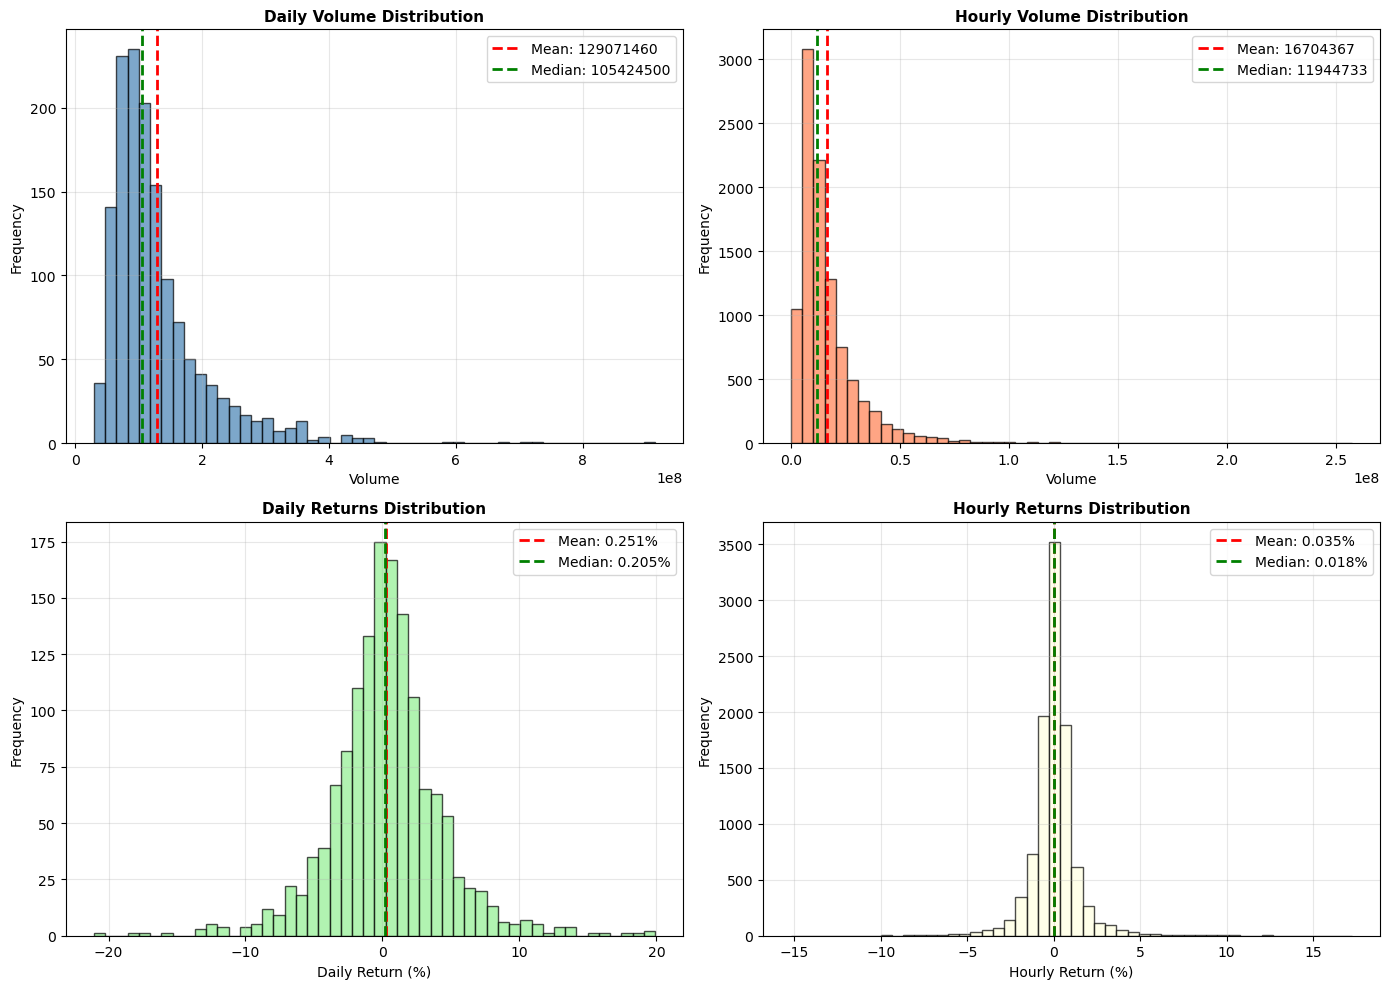

Saved: outputs/eda_distributions.png


In [15]:
# Volume Distribution & Returns Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Daily volume histogram
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].axvline(reload_daily['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_daily['Volume'].mean():.0f}")
axes[0, 0].axvline(reload_daily['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_daily['Volume'].median():.0f}")
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Hourly volume histogram
axes[0, 1].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_hourly['Volume'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {reload_hourly['Volume'].mean():.0f}")
axes[0, 1].axvline(reload_hourly['Volume'].median(), color='green', linestyle='--', linewidth=2, label=f"Median: {reload_hourly['Volume'].median():.0f}")
axes[0, 1].set_xlabel('Volume', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Hourly Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Daily returns distribution
daily_returns = reload_daily['Close'].pct_change() * 100
axes[1, 0].hist(daily_returns.dropna(), bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_returns.mean():.3f}%")
axes[1, 0].axvline(daily_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {daily_returns.median():.3f}%")
axes[1, 0].set_xlabel('Daily Return (%)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Hourly returns distribution
hourly_returns = reload_hourly['Close'].pct_change() * 100
axes[1, 1].hist(hourly_returns.dropna(), bins=50, color='lightyellow', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(hourly_returns.mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {hourly_returns.mean():.3f}%")
axes[1, 1].axvline(hourly_returns.median(), color='green', linestyle='--', linewidth=2, label=f"Median: {hourly_returns.median():.3f}%")
axes[1, 1].set_xlabel('Hourly Return (%)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly Returns Distribution', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_distributions.png")


MIDAS DATA SANITY CHECK

1. MISSING VALUES (NaN) CHECK:
----------------------------------------------------------------------
  ✓ ticker                        :    0 NaN (  0.00%)
  ✓ Cancel_to_Trade               :    0 NaN (  0.00%)
  ✓ Hidden_Rate                   :    0 NaN (  0.00%)
  ✓ Hidden_Volume                 :    0 NaN (  0.00%)
  ✓ Trade_to_Order_Volume         :    0 NaN (  0.00%)
  ✓ Oddlot_Rate                   :    0 NaN (  0.00%)
  ✓ Oddlot_Volume                 :    0 NaN (  0.00%)

  Total NaN: 0.00% of all data points

2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):
----------------------------------------------------------------------
  MIDAS rows        : 1443
  Daily trading days: 1443
  Hourly trading days: 1441
  MIDAS date range  : 2019-01-02 to 2024-12-09
  Daily date range  : 2019-01-07 to 2024-09-30

  Days in DAILY but NOT in MIDAS: 190
  Days in MIDAS but NOT in DAILY: 190
  Alignment: 86.8% of daily dates have MIDAS data

3. SUMMARY STATISTICS:
--

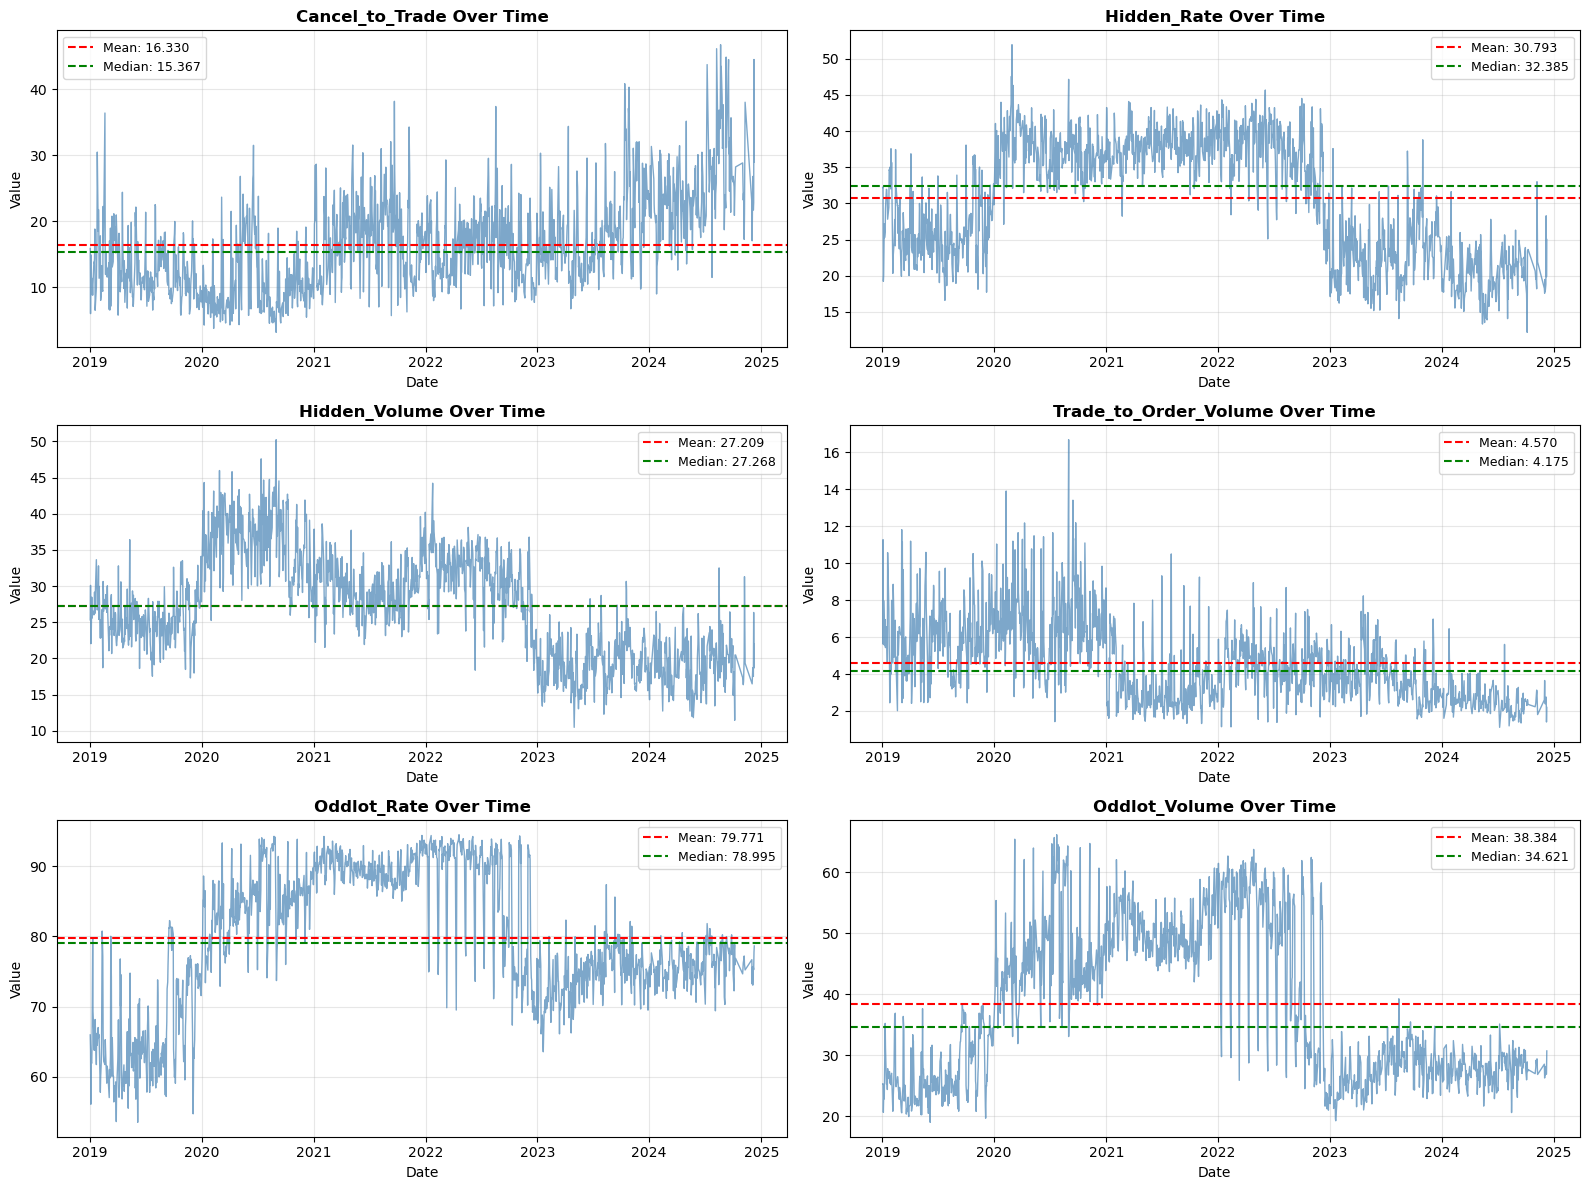


  ✓ Saved: outputs/midas_sanity_check_timeseries.png


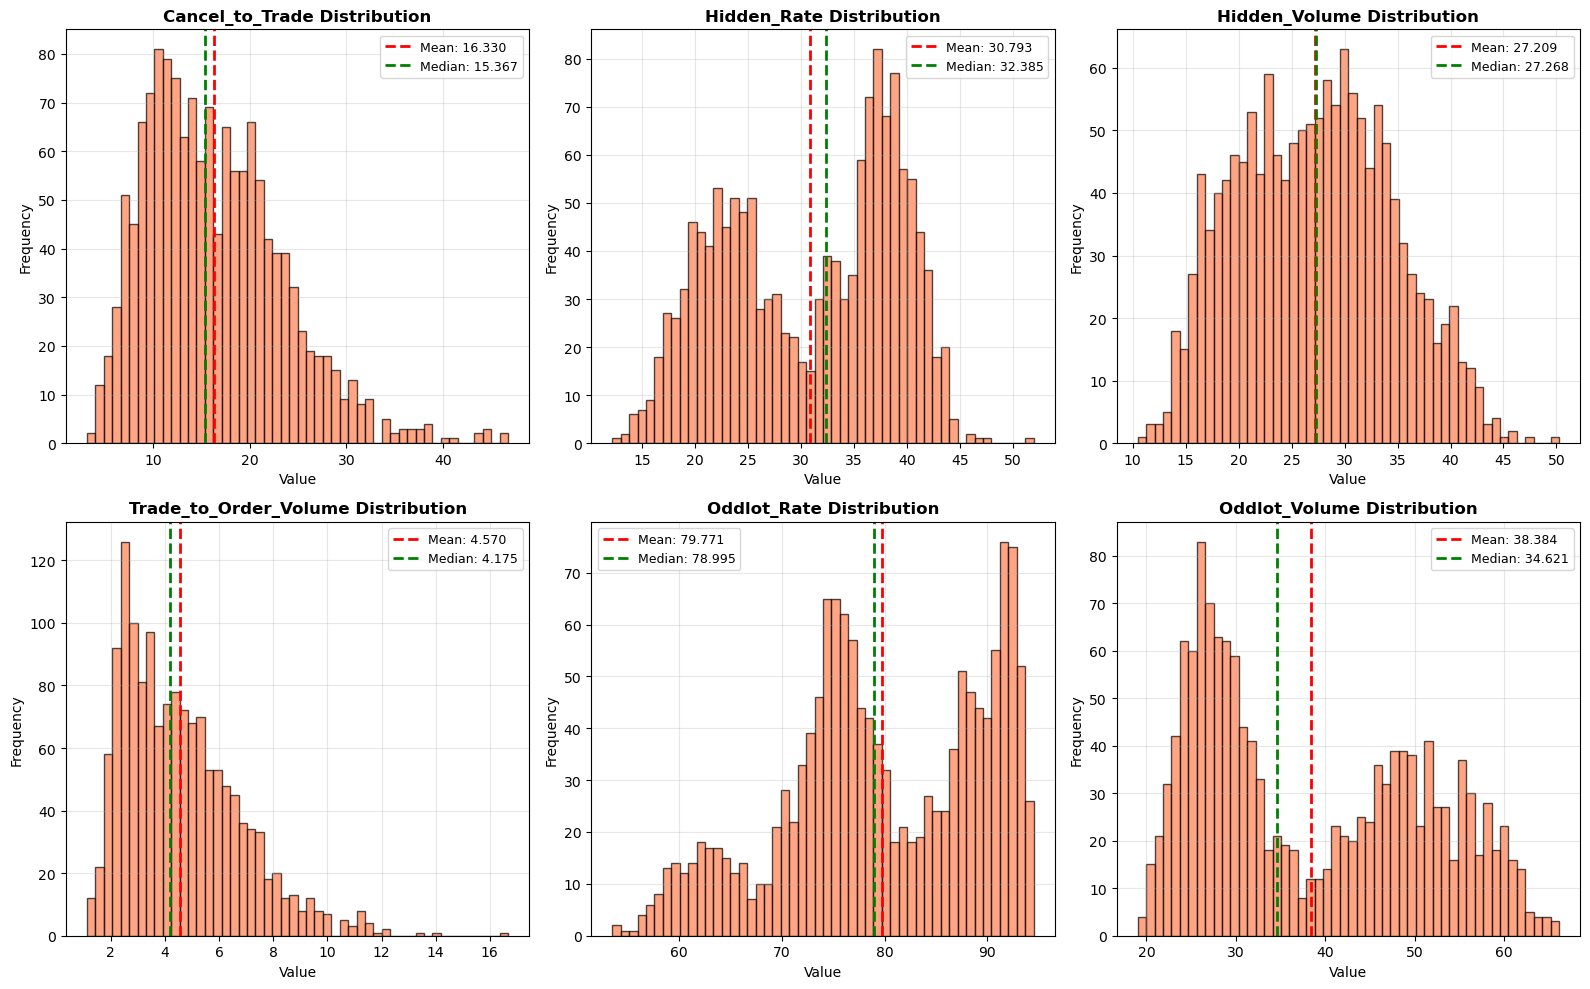

  ✓ Saved: outputs/midas_sanity_check_distributions.png


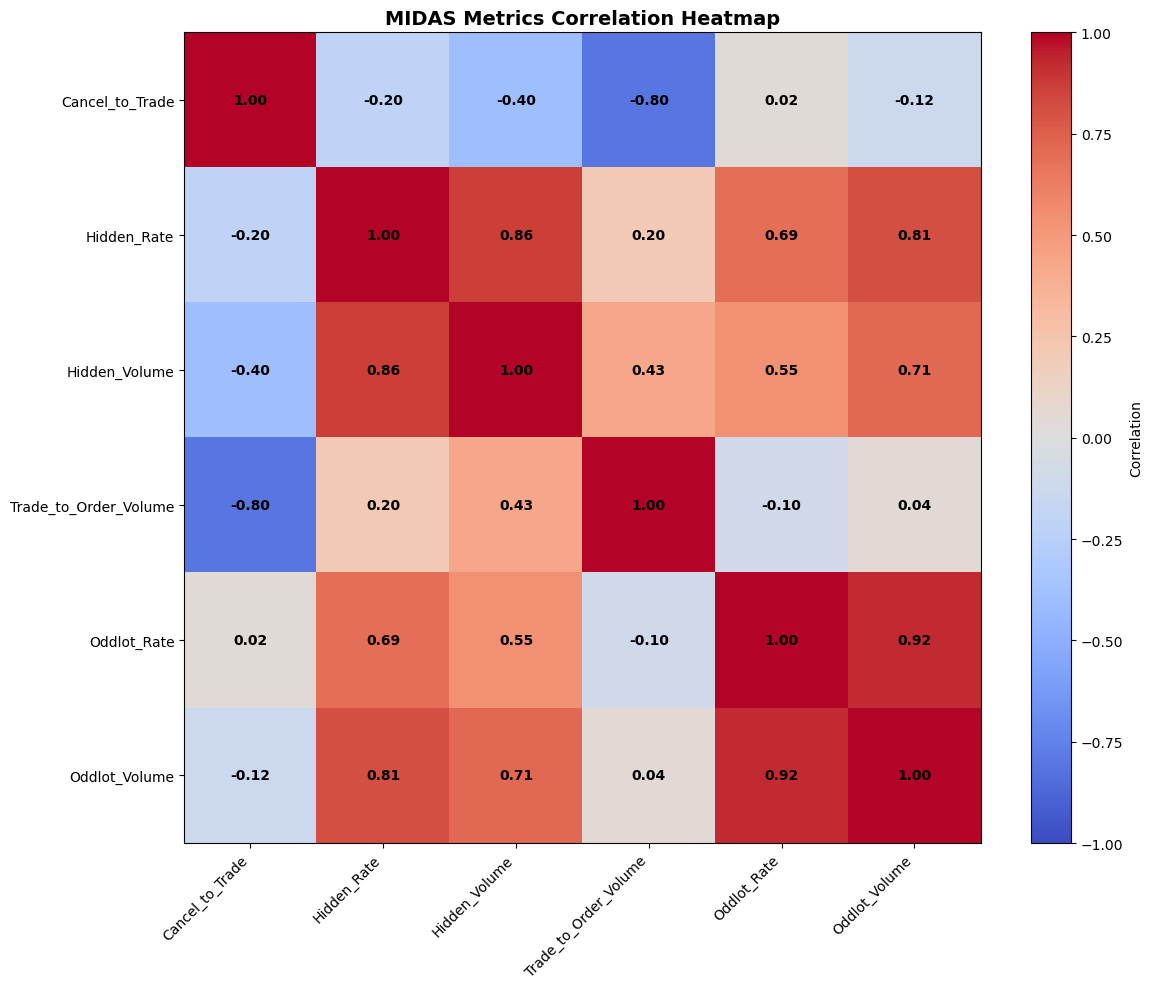

  ✓ Saved: outputs/midas_sanity_check_correlation.png

MIDAS SANITY CHECK SUMMARY

✓ MIDAS data validation complete!
  - 1443 rows loaded
  - 7 metrics available
  - Date alignment: 86.8% with daily data
  - Average NaN percentage: 0.00%
  - Ready for zone enrichment and filtering (Layer 3)


In [16]:
# ---------------------------------------------------------------------------
# MIDAS Data Sanity Check
# ---------------------------------------------------------------------------
# Comprehensive validation of MIDAS data for alignment, completeness, and quality

if midas_df is not None and not midas_df.empty and USE_MIDAS:
    print("\n" + "="*70)
    print("MIDAS DATA SANITY CHECK")
    print("="*70)
    
    # ─────────────────────────────────────────────────────────────────────
    # 1. MISSING/NAN VALUES CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n1. MISSING VALUES (NaN) CHECK:")
    print("-" * 70)
    
    nan_counts = midas_df.isnull().sum()
    nan_pct = (nan_counts / len(midas_df)) * 100
    
    for col in midas_df.columns:
        nan_cnt = nan_counts[col]
        nan_p = nan_pct[col]
        status = "✓" if nan_p == 0 else "⚠" if nan_p < 20 else "✗"
        print(f"  {status} {col:30s}: {nan_cnt:4d} NaN ({nan_p:6.2f}%)")
    
    total_nan_pct = (midas_df.isnull().sum().sum() / (len(midas_df) * len(midas_df.columns))) * 100
    print(f"\n  Total NaN: {total_nan_pct:.2f}% of all data points")
    
    # ─────────────────────────────────────────────────────────────────────
    # 2. DATE ALIGNMENT CHECK (MIDAS vs Price Data)
    # ─────────────────────────────────────────────────────────────────────
    print("\n2. DATE ALIGNMENT CHECK (MIDAS vs Price Data):")
    print("-" * 70)
    
    midas_dates = set(midas_df.index.date)
    daily_dates = set(reload_daily.index.date)
    hourly_dates = set(reload_hourly.index.date)
    
    dates_in_daily_not_midas = daily_dates - midas_dates
    dates_in_midas_not_daily = midas_dates - daily_dates
    dates_in_hourly_not_midas = hourly_dates - midas_dates
    
    print(f"  MIDAS rows        : {len(midas_df)}")
    print(f"  Daily trading days: {len(daily_dates)}")
    print(f"  Hourly trading days: {len(hourly_dates)}")
    print(f"  MIDAS date range  : {midas_df.index.min().date()} to {midas_df.index.max().date()}")
    print(f"  Daily date range  : {reload_daily.index.min().date()} to {reload_daily.index.max().date()}")
    
    print(f"\n  Days in DAILY but NOT in MIDAS: {len(dates_in_daily_not_midas)}")
    if len(dates_in_daily_not_midas) > 0 and len(dates_in_daily_not_midas) <= 10:
        print(f"    → {sorted(dates_in_daily_not_midas)[:5]}" + ("..." if len(dates_in_daily_not_midas) > 5 else ""))
    
    print(f"  Days in MIDAS but NOT in DAILY: {len(dates_in_midas_not_daily)}")
    if len(dates_in_midas_not_daily) > 0 and len(dates_in_midas_not_daily) <= 10:
        print(f"    → {sorted(dates_in_midas_not_daily)[:5]}" + ("..." if len(dates_in_midas_not_daily) > 5 else ""))
    
    alignment_pct = (len(midas_dates & daily_dates) / len(daily_dates)) * 100 if daily_dates else 0
    print(f"  Alignment: {alignment_pct:.1f}% of daily dates have MIDAS data")
    
    # ─────────────────────────────────────────────────────────────────────
    # 3. SUMMARY STATISTICS (count, mean, median, min, max, std)
    # ─────────────────────────────────────────────────────────────────────
    print("\n3. SUMMARY STATISTICS:")
    print("-" * 70)
    
    stats_df = midas_df.describe().round(4)
    print(stats_df.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 4. PERCENTILE RANKS & OUTLIERS CHECK
    # ─────────────────────────────────────────────────────────────────────
    print("\n4. PERCENTILE DISTRIBUTION & OUTLIERS:")
    print("-" * 70)
    
    for col in midas_df.select_dtypes(include='number').columns:
        col_data = midas_df[col].dropna()
        if len(col_data) == 0:
            continue
        
        q1 = col_data.quantile(0.25)
        q2 = col_data.quantile(0.50)  # median
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr
        
        outliers_low = (col_data < lower_fence).sum()
        outliers_high = (col_data > upper_fence).sum()
        total_outliers = outliers_low + outliers_high
        outlier_pct = (total_outliers / len(col_data)) * 100
        
        print(f"\n  {col}:")
        print(f"    Percentiles: Q1={q1:.4f}, Q2(Median)={q2:.4f}, Q3={q3:.4f}")
        print(f"    IQR={iqr:.4f}, Outlier Fences: [{lower_fence:.4f}, {upper_fence:.4f}]")
        print(f"    Outliers: {total_outliers} ({outlier_pct:.2f}%) [Low: {outliers_low}, High: {outliers_high}]")
    
    # ─────────────────────────────────────────────────────────────────────
    # 5. CORRELATION MATRIX (Relationship between MIDAS metrics)
    # ─────────────────────────────────────────────────────────────────────
    print("5. CORRELATION BETWEEN MIDAS METRICS:")
    print("-" * 70)
    
    corr_matrix = midas_df.select_dtypes(include='number').corr().round(3)
    print(corr_matrix.to_string())
    
    # ─────────────────────────────────────────────────────────────────────
    # 6. VISUALIZATIONS
    # ─────────────────────────────────────────────────────────────────────
    import matplotlib.pyplot as plt
    
    # Create a comprehensive figure with multiple subplots
    fig = plt.figure(figsize=(16, 12))
    
    # 6a. Time series of each MIDAS metric
    for idx, col in enumerate(midas_df.select_dtypes(include='number').columns):
        ax = plt.subplot(3, 2, idx + 1)
        ax.plot(midas_df.index, midas_df[col], linewidth=1, color='steelblue', alpha=0.7)
        ax.set_title(f'{col} Over Time', fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Value')
        ax.grid(alpha=0.3)
        
        # Add mean and median lines
        mean_val = midas_df[col].mean()
        median_val = midas_df[col].median()
        ax.axhline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.3f}')
        ax.axhline(median_val, color='green', linestyle='--', linewidth=1.5, label=f'Median: {median_val:.3f}')
        ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_timeseries.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n  ✓ Saved: outputs/midas_sanity_check_timeseries.png")
    
    # 6b. Distribution histograms
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    
    for idx, col in enumerate(midas_df.select_dtypes(include='number').columns):
        ax = axes[idx]
        col_data = midas_df[col].dropna()
        ax.hist(col_data, bins=50, color='coral', alpha=0.7, edgecolor='black')
        ax.axvline(col_data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {col_data.mean():.3f}')
        ax.axvline(col_data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {col_data.median():.3f}')
        ax.set_title(f'{col} Distribution', fontweight='bold')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Remove extra subplot
    if len(midas_df.select_dtypes(include='number').columns) < 6:
        fig.delaxes(axes[-1])
    
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_distributions.png")
    
    # 6c. Heatmap of correlation matrix
    import matplotlib.patches as mpatches
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
    
    ax.set_xticks(range(len(corr_matrix.columns)))
    ax.set_yticks(range(len(corr_matrix.columns)))
    ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
    ax.set_yticklabels(corr_matrix.columns)
    
    # Add correlation values in cells
    for i in range(len(corr_matrix)):
        for j in range(len(corr_matrix)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=10, fontweight='bold')
    
    ax.set_title('MIDAS Metrics Correlation Heatmap', fontweight='bold', fontsize=14)
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.savefig('outputs/midas_sanity_check_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  ✓ Saved: outputs/midas_sanity_check_correlation.png")
    
    # ─────────────────────────────────────────────────────────────────────
    # SUMMARY
    # ─────────────────────────────────────────────────────────────────────
    print("\n" + "="*70)
    print("MIDAS SANITY CHECK SUMMARY")
    print("="*70)
    
    print(f"\n✓ MIDAS data validation complete!")
    print(f"  - {len(midas_df)} rows loaded")
    print(f"  - {len(midas_df.columns)} metrics available")
    print(f"  - Date alignment: {alignment_pct:.1f}% with daily data")
    print(f"  - Average NaN percentage: {total_nan_pct:.2f}%")
    print(f"  - Ready for zone enrichment and filtering (Layer 3)")
    
else:
    print("\n⚠ MIDAS data not available for sanity check (midas_df is None or empty)")

In [17]:
midas_df.head()

,ticker,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume
date,,,,,,,
2019-01-02,TSLA,15.864445,32.193127,25.327616,5.654549,65.951710,25.323521
2019-01-03,TSLA,5.996512,32.277228,30.101467,11.269096,63.788350,25.322480
2019-01-04,TSLA,14.914265,19.229224,22.041314,5.612364,56.052985,20.648200
2019-01-05,TSLA,8.869715,20.080656,22.168070,7.974872,62.016080,22.910861
2019-01-07,TSLA,10.292012,27.162892,28.473932,6.760902,61.903219,22.841433


### 2b — Data Transformation

In [18]:
# ---------------------------------------------------------------------------
# Volume Data Normalization: Conditional log1p + Z-Score Standardization
# ---------------------------------------------------------------------------

def normalize_volume_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalize raw volume data: apply log1p if skewness > 0.5, then z-score.
    
    Rationale for conditional log1p:
    - High skew indicates extreme outliers (institutional activity signals)
    - Log transformation compresses skew while preserving relative magnitude
    - Subsequent z-score creates regime-independent threshold (e.g., vol_spike >= 1.5)
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with 'Volume' or 'volume' column
    
    Returns:
    --------
    pd.DataFrame
        Copy of df with normalized volume columns added:
        - volume_skewness: Raw volume skewness (diagnostic)
        - volume_log_applied: Boolean indicating if log1p was used
        - volume_zscore: Z-score normalized volume (μ=0, σ=1)
    """
    df_norm = df.copy()
    
    # Identify volume column
    vol_col = "Volume" if "Volume" in df.columns else ("volume" if "volume" in df.columns else None)
    if vol_col is None:
        print("[Warning] normalize_volume_data: no volume column found")
        return df_norm
    
    # Step 1: Calculate skewness on raw volume
    skewness = df_norm[vol_col].skew()
    df_norm['volume_skewness'] = skewness
    
    # Step 2: Apply log1p if skewness > 0.5
    apply_log = skewness > 0.5
    df_norm['volume_log_applied'] = apply_log
    
    if apply_log:
        volume_transformed = np.log1p(df_norm[vol_col])
        print(f"[Volume] High skewness detected ({skewness:.4f}) → applying log1p transformation")
    else:
        volume_transformed = df_norm[vol_col]
        print(f"[Volume] Skewness acceptable ({skewness:.4f}) → using raw values")
    
    # Step 3: Rolling Z-score normalization on transformed volume
    # Using 20-bar rolling window for regime-adaptive normalization
    # min_periods=1 ensures no NaN values (bootstrap from first bar onwards)
    vol_roll_mean = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).mean()
    vol_roll_std = volume_transformed.rolling(window=VOL_ROLL_WINDOW, min_periods=1).std().clip(lower=0.01)
    
    if vol_roll_std.max() > 0:
        df_norm['volume_zscore'] = (volume_transformed - vol_roll_mean) / vol_roll_std
    else:
        df_norm['volume_zscore'] = 0.0

    return df_norm

In [19]:
# APPLY VOLUME NORMALIZATION — Create volume_zscore column 

print("\n" + "="*75)
print("STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)")
print("="*75)
print("Creating volume_zscore column required by all downstream analysis...")
print()

reload_daily  = normalize_volume_data(reload_daily)
reload_hourly = normalize_volume_data(reload_hourly)

print("\n✓ Volume normalization complete:")
print(f"  - Daily data: {len(reload_daily)} bars, volume_zscore shape={reload_daily['volume_zscore'].shape}")
print(f"  - Hourly data: {len(reload_hourly)} bars, volume_zscore shape={reload_hourly['volume_zscore'].shape}")
print(f"  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns")


STEP 1: APPLYING VOLUME NORMALIZATION (normalize_volume_data)
Creating volume_zscore column required by all downstream analysis...

[Volume] High skewness detected (2.8077) → applying log1p transformation
[Volume] High skewness detected (3.6625) → applying log1p transformation

✓ Volume normalization complete:
  - Daily data: 1443 bars, volume_zscore shape=(1443,)
  - Hourly data: 10070 bars, volume_zscore shape=(10070,)
  - Both DataFrames now have volume_skewness, volume_log_applied, volume_zscore columns


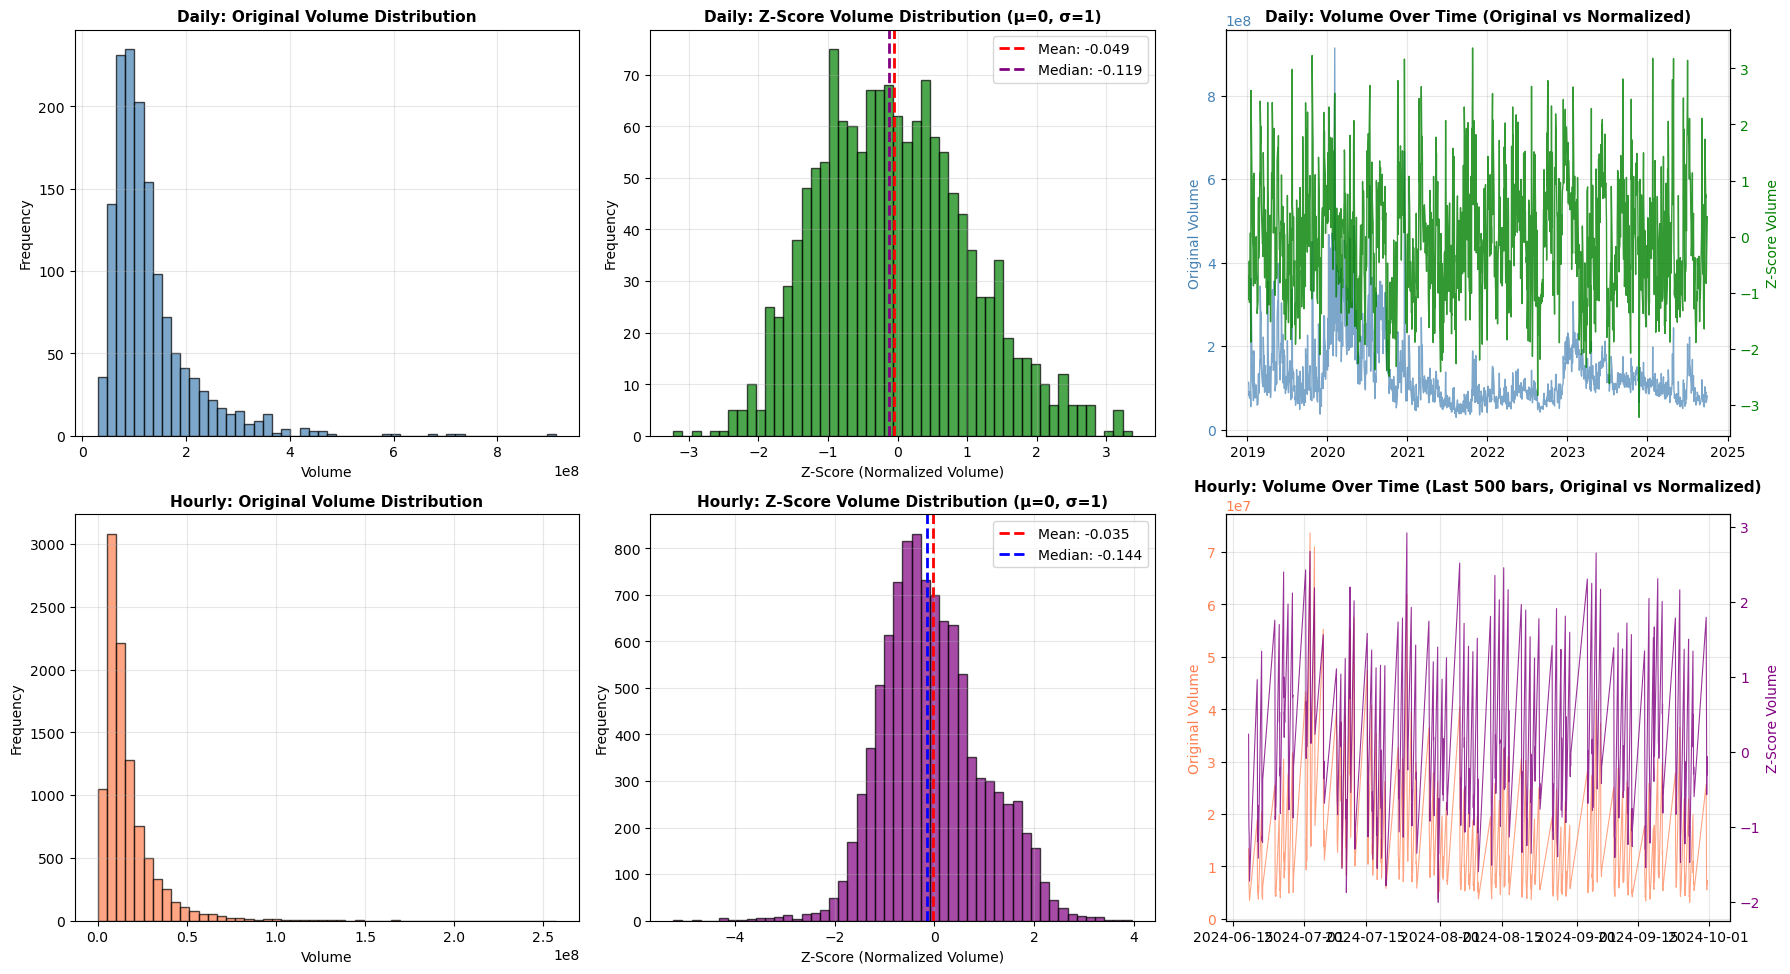


✓ Volume normalization visualizations displayed


In [20]:
# ---------------------------------------------------------------------------
# Volume Normalization Visualizations
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ─────────────────────────────────────────────────────────────────────────
# Row 1: Daily (HTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution
axes[0, 0].hist(reload_daily['Volume'].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Volume', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Daily: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (centered at 0)
axes[0, 1].hist(reload_daily['volume_zscore'].dropna(), bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(reload_daily['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f"Mean: {reload_daily['volume_zscore'].mean():.3f}")
axes[0, 1].axvline(reload_daily['volume_zscore'].median(), color='purple', linestyle='--', linewidth=2,
                   label=f"Median: {reload_daily['volume_zscore'].median():.3f}")
axes[0, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].set_title('Daily: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Time Series: Original vs Normalized Volume
axes[0, 2].plot(reload_daily.index, reload_daily['Volume'], color='steelblue', linewidth=1, 
                label='Original', alpha=0.7)
ax_norm = axes[0, 2].twinx()
ax_norm.plot(reload_daily.index, reload_daily['volume_zscore'], color='green', linewidth=1, 
             label='Z-Score', alpha=0.8)
axes[0, 2].set_ylabel('Original Volume', fontsize=10, color='steelblue')
ax_norm.set_ylabel('Z-Score Volume', fontsize=10, color='green')
axes[0, 2].set_title('Daily: Volume Over Time (Original vs Normalized)', fontsize=11, fontweight='bold')
axes[0, 2].tick_params(axis='y', labelcolor='steelblue')
ax_norm.tick_params(axis='y', labelcolor='green')
axes[0, 2].grid(alpha=0.3)

# ─────────────────────────────────────────────────────────────────────────
# Row 2: Hourly (LTF) Volume Analysis
# ─────────────────────────────────────────────────────────────────────────

# Original Volume Distribution (Hourly)
axes[1, 0].hist(reload_hourly['Volume'].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Volume', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Hourly: Original Volume Distribution', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Z-Score Volume Distribution (Hourly)
axes[1, 1].hist(reload_hourly['volume_zscore'].dropna(), bins=50, color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].axvline(reload_hourly['volume_zscore'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f"Mean: {reload_hourly['volume_zscore'].mean():.3f}")
axes[1, 1].axvline(reload_hourly['volume_zscore'].median(), color='blue', linestyle='--', linewidth=2,
                   label=f"Median: {reload_hourly['volume_zscore'].median():.3f}")
axes[1, 1].set_xlabel('Z-Score (Normalized Volume)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].set_title('Hourly: Z-Score Volume Distribution (μ=0, σ=1)', fontsize=11, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

# Time Series: Hourly Volume (Last 500 bars for clarity)
hourly_tail = reload_hourly.tail(500)
axes[1, 2].plot(hourly_tail.index, hourly_tail['Volume'], color='coral', linewidth=0.8, 
                label='Original', alpha=0.7)
ax_norm2 = axes[1, 2].twinx()
ax_norm2.plot(hourly_tail.index, hourly_tail['volume_zscore'], color='purple', linewidth=0.8,
              label='Z-Score', alpha=0.8)
axes[1, 2].set_ylabel('Original Volume', fontsize=10, color='coral')
ax_norm2.set_ylabel('Z-Score Volume', fontsize=10, color='purple')
axes[1, 2].set_title('Hourly: Volume Over Time (Last 500 bars, Original vs Normalized)', fontsize=11, fontweight='bold')
axes[1, 2].tick_params(axis='y', labelcolor='coral')
ax_norm2.tick_params(axis='y', labelcolor='purple')
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("\n✓ Volume normalization visualizations displayed")

In [21]:
def preprocess_midas_data(
    midas_df: pd.DataFrame, 
    rolling_window: int = 20,
    **kwargs
) -> pd.DataFrame:
    """
    Simplified MIDAS preprocessing.
    Tree-based ML models and downstream institutional scoring use the raw variables,
    so we avoid unnecessary and complicated walk-forward Q-transforms/Z-scores here.
    """
    if midas_df is None or midas_df.empty:
        print("⚠ MIDAS data is None or empty — skipping preprocessing")
        return midas_df
    
    midas_proc = midas_df.copy()
    
    midas_cols = [
        "Cancel_to_Trade", "Hidden_Rate", "Hidden_Volume",
        "Trade_to_Order_Volume", "Oddlot_Rate", "Oddlot_Volume"
    ]
    
    for col in midas_cols:
        if col not in midas_proc.columns:
            midas_proc[col] = np.nan
            
    # Forward-fill any NaN values (e.g. holidays mapped to dates)
    midas_proc = midas_proc.ffill()
    
    # Optionally calculate simple useful ratios
    if "Hidden_Volume" in midas_proc.columns and "Oddlot_Volume" in midas_proc.columns:
        midas_proc["Hidden_to_Oddlot"] = midas_proc["Hidden_Volume"] / (midas_proc["Oddlot_Volume"] + 1e-4)

    return midas_proc



In [22]:
# APPLY MIDAS PREPROCESSING
print("\n" + "="*75)
print("APPLYING MIDAS PREPROCESSING (preprocess_midas_data)")
print("="*75)   
if USE_MIDAS and 'midas_df_by_ticker' in globals():
    for t in TICKERS:
        if t in midas_df_by_ticker and midas_df_by_ticker[t] is not None and not midas_df_by_ticker[t].empty:
            midas_df_by_ticker[t] = preprocess_midas_data(midas_df_by_ticker[t], rolling_window=20)
    midas_df = midas_df_by_ticker.get(TICKER)
    if midas_df is not None:
        print(f"✓ Primary MIDAS data preprocessed: {midas_df.shape}")


APPLYING MIDAS PREPROCESSING (preprocess_midas_data)
✓ Primary MIDAS data preprocessed: (1443, 8)


In [23]:
midas_df.head()

,ticker,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume,Hidden_to_Oddlot
date,,,,,,,,
2019-01-02,TSLA,15.864445,32.193127,25.327616,5.654549,65.951710,25.323521,1.000158
2019-01-03,TSLA,5.996512,32.277228,30.101467,11.269096,63.788350,25.322480,1.188720
2019-01-04,TSLA,14.914265,19.229224,22.041314,5.612364,56.052985,20.648200,1.067464
2019-01-05,TSLA,8.869715,20.080656,22.168070,7.974872,62.016080,22.910861,0.967575
2019-01-07,TSLA,10.292012,27.162892,28.473932,6.760902,61.903219,22.841433,1.246586


In [24]:
midas_df.tail()

,ticker,Cancel_to_Trade,Hidden_Rate,Hidden_Volume,Trade_to_Order_Volume,Oddlot_Rate,Oddlot_Volume,Hidden_to_Oddlot
date,,,,,,,,
2024-12-04,TSLA,26.774974,17.862608,18.725421,2.384506,73.051452,26.807184,0.698520
2024-12-06,TSLA,21.678957,18.833144,17.518208,2.734815,75.561055,27.515083,0.636674
2024-12-07,TSLA,22.798964,28.291238,26.355774,2.750166,75.255651,26.897602,0.979852
2024-12-08,TSLA,44.483873,19.873194,18.678261,1.404243,77.749590,26.895588,0.694470
2024-12-09,TSLA,28.982114,25.013497,22.002881,2.194166,78.647814,30.710513,0.716459


In [25]:
# midas_path = OUT_DIR / f"{TICKER}_midas_processed.csv"
# midas_df.to_csv(midas_path)

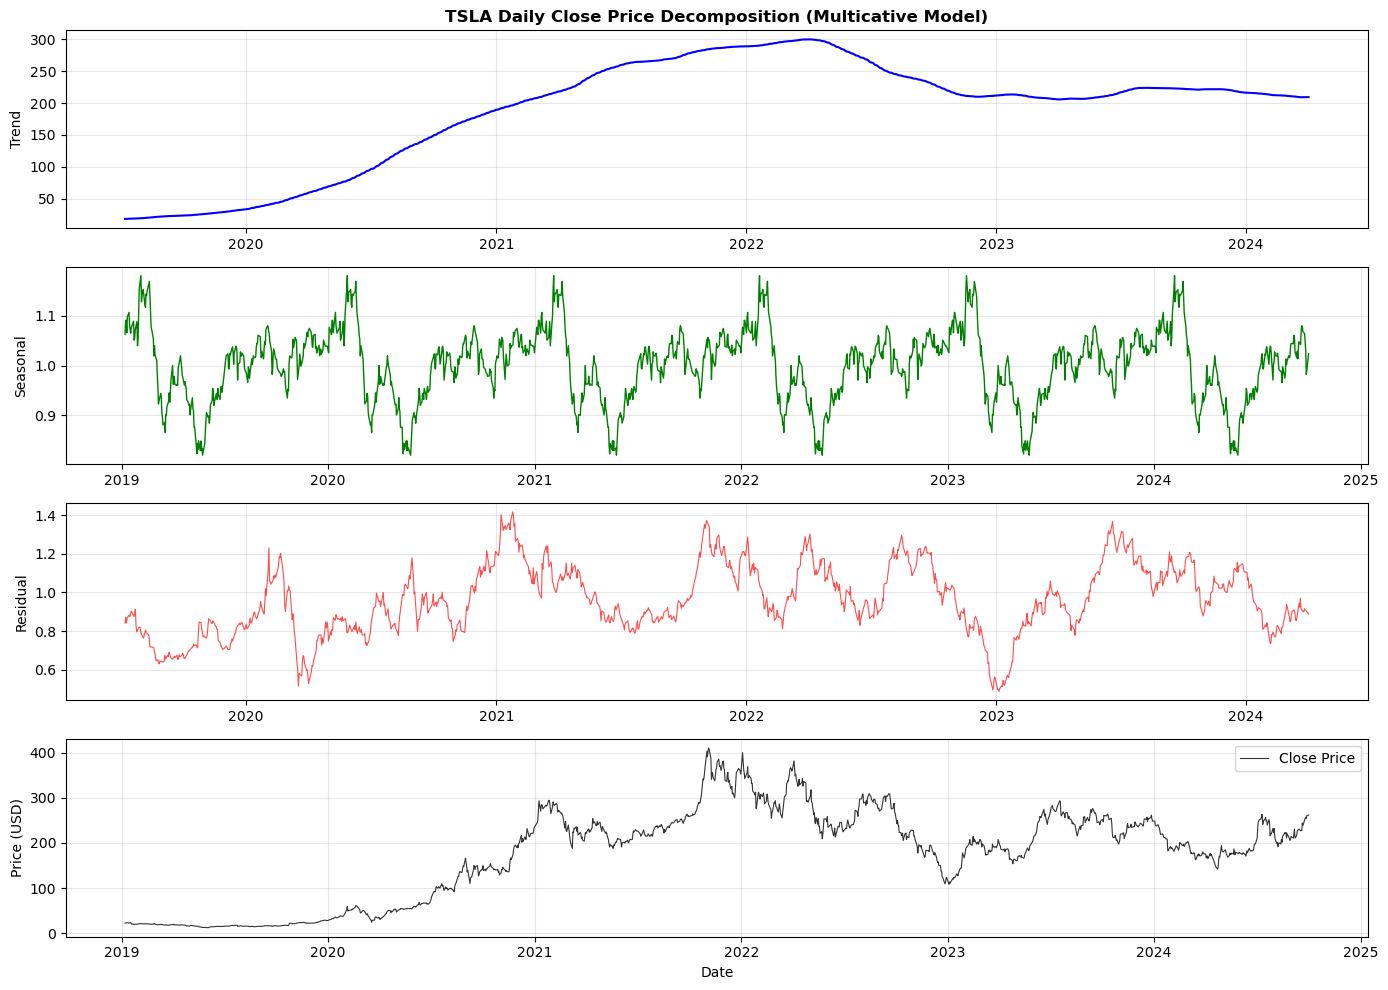

Saved: outputs/eda_decomposition.png


In [26]:
# ---------------------------------------------------------------------------
# EDA: Time Series Decomposition & Visualizations
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Prepare closing prices for decomposition (daily only, as decomposition works on univariate series)
close_daily = reload_daily['Close']

# Perform seasonal decomposition on daily close prices
# freq=252 corresponds to ~1 year of trading days (typical in finance)
decomposition = seasonal_decompose(close_daily, model='multicative', period=252)

# Create a figure with subplots for decomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Trend
axes[0].plot(decomposition.trend, color='blue', linewidth=1.5)
axes[0].set_ylabel('Trend', fontsize=10)
axes[0].set_title(f'TSLA Daily Close Price Decomposition (Multicative Model)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Seasonal
axes[1].plot(decomposition.seasonal, color='green', linewidth=1)
axes[1].set_ylabel('Seasonal', fontsize=10)
axes[1].grid(alpha=0.3)

# Residual
axes[2].plot(decomposition.resid, color='red', linewidth=0.8, alpha=0.7)
axes[2].set_ylabel('Residual', fontsize=10)
axes[2].grid(alpha=0.3)

# Original
axes[3].plot(close_daily, color='black', linewidth=0.8, alpha=0.8, label='Close Price')
axes[3].set_ylabel('Price (USD)', fontsize=10)
axes[3].set_xlabel('Date', fontsize=10)
axes[3].grid(alpha=0.3)
axes[3].legend()

plt.tight_layout()
plt.savefig('outputs/eda_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_decomposition.png")



/var/folders/sr/gx_1bzpx6w33z_3djt_j_l5m0000gq/T/ipykernel_13998/1740862447.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


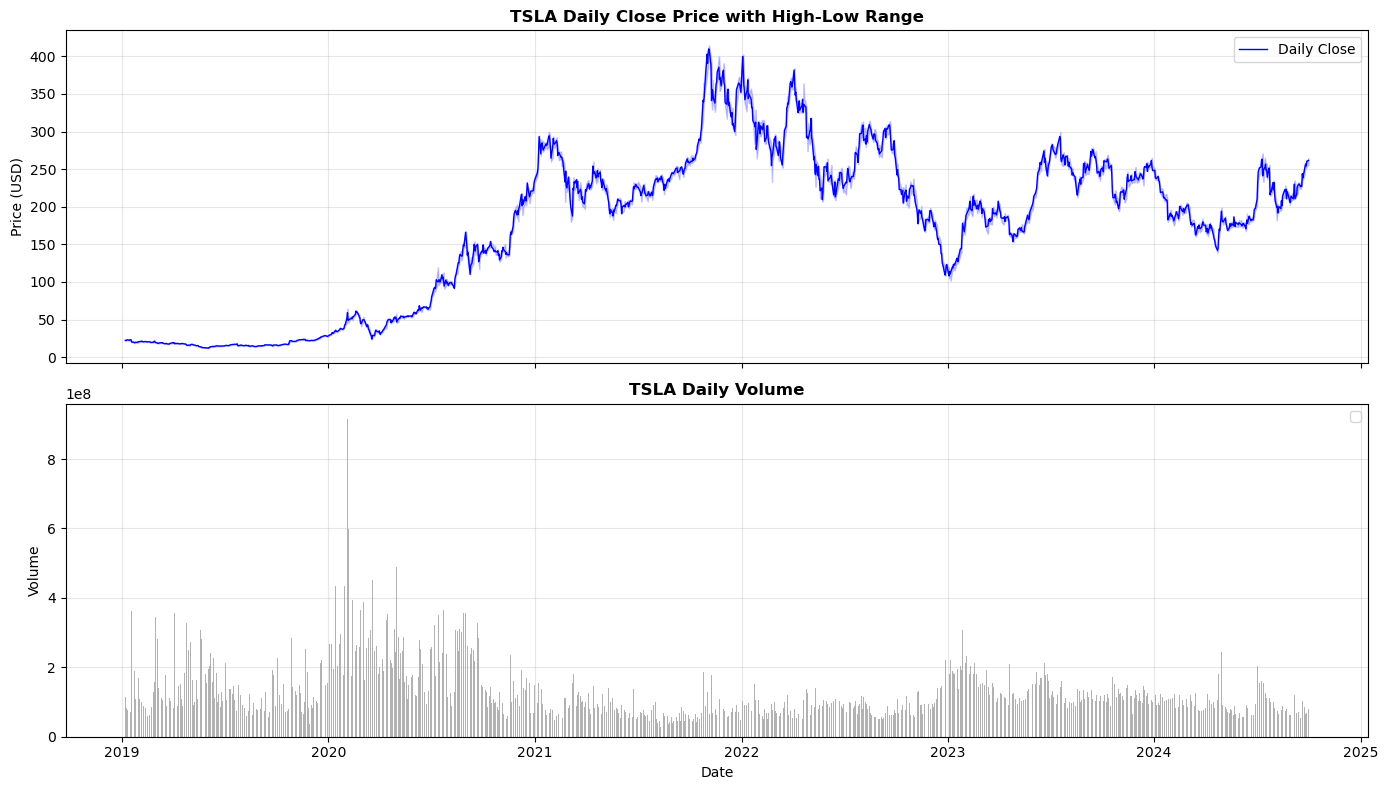

Saved: outputs/eda_price_volume.png


In [27]:
# Price & Volume Trends
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily close price
axes[0].plot(reload_daily.index, reload_daily['Close'], color='blue', linewidth=1, label='Daily Close')
axes[0].fill_between(reload_daily.index, reload_daily['Low'], reload_daily['High'], alpha=0.2, color='blue')
axes[0].set_ylabel('Price (USD)', fontsize=10)
axes[0].set_title('TSLA Daily Close Price with High-Low Range', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Daily volume
axes[1].bar(reload_daily.index, reload_daily['Volume'], color='gray', alpha=0.6, width=0.8)
axes[1].set_ylabel('Volume', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Daily Volume', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_price_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_price_volume.png")



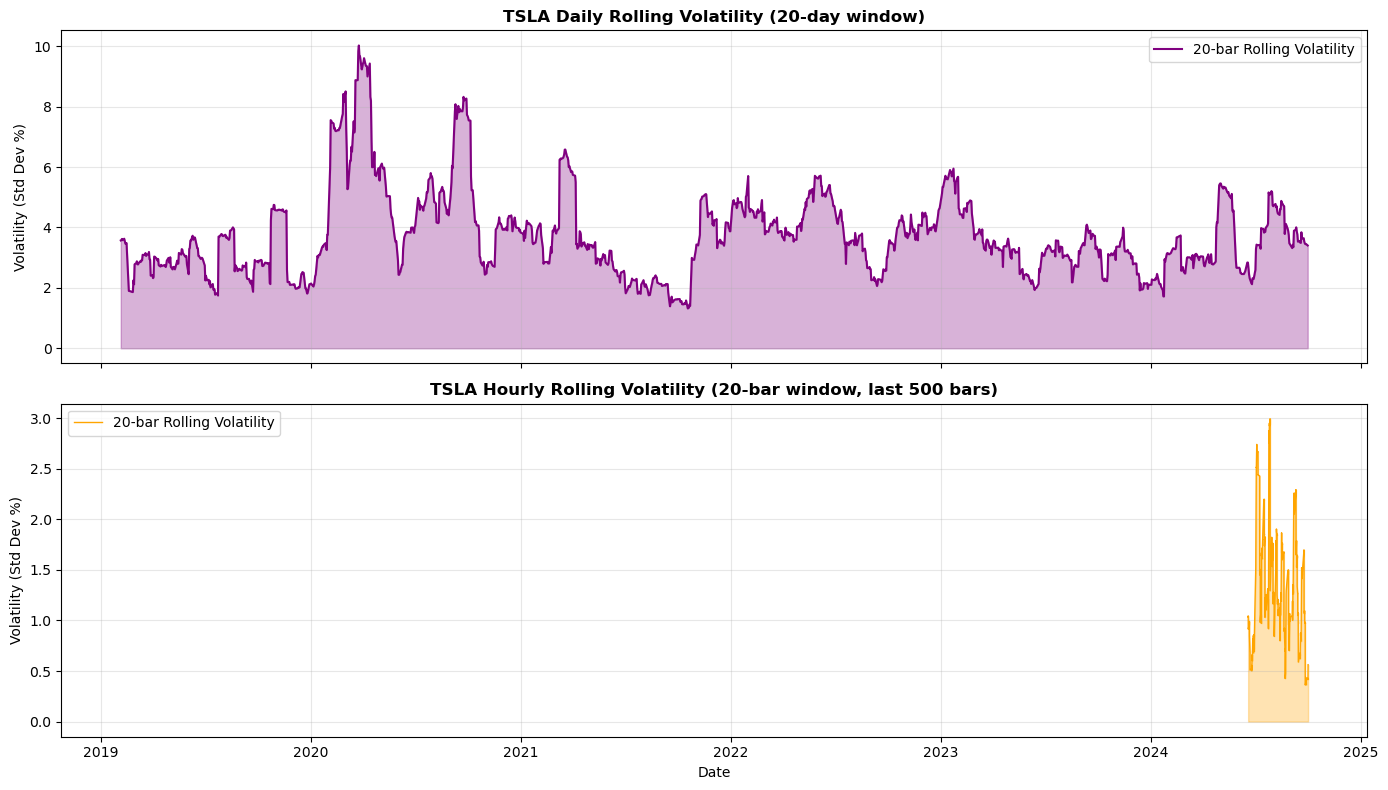

Saved: outputs/eda_volatility.png

VOLATILITY SUMMARY STATISTICS
Daily volatility  - Mean: 3.7340%, Std: 1.4249%, Max: 10.0268%
Hourly volatility - Mean: 1.2705%, Std: 0.6607%, Max: 5.7660%


In [28]:
# Volatility Analysis
import numpy as np

# Calculate rolling volatility (20-day rolling std of returns)
daily_volatility = daily_returns.rolling(20).std()
hourly_volatility = hourly_returns.rolling(20).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Daily volatility over time
axes[0].plot(daily_volatility.index, daily_volatility, color='purple', linewidth=1.5, label='20-bar Rolling Volatility')
axes[0].fill_between(daily_volatility.index, daily_volatility, alpha=0.3, color='purple')
axes[0].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[0].set_title('TSLA Daily Rolling Volatility (20-day window)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hourly volatility over time (last 500 bars for clarity)
hourly_tail = hourly_volatility.tail(500)
axes[1].plot(hourly_tail.index, hourly_tail, color='orange', linewidth=1, label='20-bar Rolling Volatility')
axes[1].fill_between(hourly_tail.index, hourly_tail, alpha=0.3, color='orange')
axes[1].set_ylabel('Volatility (Std Dev %)', fontsize=10)
axes[1].set_xlabel('Date', fontsize=10)
axes[1].set_title('TSLA Hourly Rolling Volatility (20-bar window, last 500 bars)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/eda_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/eda_volatility.png")

# Summary statistics
print("\n" + "="*70)
print("VOLATILITY SUMMARY STATISTICS")
print("="*70)
print(f"Daily volatility  - Mean: {daily_volatility.mean():.4f}%, Std: {daily_volatility.std():.4f}%, Max: {daily_volatility.max():.4f}%")
print(f"Hourly volatility - Mean: {hourly_volatility.mean():.4f}%, Std: {hourly_volatility.std():.4f}%, Max: {hourly_volatility.max():.4f}%")



In [29]:
# EDA Summary: Key Statistics Comparison

summary_data = {
    'Metric': [
        'Records', 'Date Range', 'Avg Close', 'Min Close', 'Max Close',
        'Avg Volume', 'Median Volume', 'Volume Std Dev',
        'Avg Return (%)', 'Max Return (%)', 'Min Return (%)',
        'Avg Volatility (%)', 'Max Volatility (%)'
    ],
    'Daily (HTF)': [
        len(reload_daily),
        f"{reload_daily.index.min().date()} to {reload_daily.index.max().date()}",
        f"{reload_daily['Close'].mean():.2f}",
        f"{reload_daily['Close'].min():.2f}",
        f"{reload_daily['Close'].max():.2f}",
        f"{reload_daily['Volume'].mean():.0f}",
        f"{reload_daily['Volume'].median():.0f}",
        f"{reload_daily['Volume'].std():.0f}",
        f"{daily_returns.mean():.4f}",
        f"{daily_returns.max():.4f}",
        f"{daily_returns.min():.4f}",
        f"{daily_volatility.mean():.4f}",
        f"{daily_volatility.max():.4f}"
    ],
    'Hourly (LTF)': [
        len(reload_hourly),
        f"{reload_hourly.index.min()} to {reload_hourly.index.max()}",
        f"{reload_hourly['Close'].mean():.2f}",
        f"{reload_hourly['Close'].min():.2f}",
        f"{reload_hourly['Close'].max():.2f}",
        f"{reload_hourly['Volume'].mean():.0f}",
        f"{reload_hourly['Volume'].median():.0f}",
        f"{reload_hourly['Volume'].std():.0f}",
        f"{hourly_returns.mean():.4f}",
        f"{hourly_returns.max():.4f}",
        f"{hourly_returns.min():.4f}",
        f"{hourly_volatility.mean():.4f}",
        f"{hourly_volatility.max():.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*70)
print("EDA SUMMARY — DAILY vs HOURLY")
print("="*70)
print(summary_df)


EDA SUMMARY — DAILY vs HOURLY
                Metric               Daily (HTF)  \
0              Records                      1443   
1           Date Range  2019-01-07 to 2024-09-30   
2            Avg Close                    174.94   
3            Min Close                     11.93   
4            Max Close                    409.97   
5           Avg Volume                 129071460   
6        Median Volume                 105424500   
7       Volume Std Dev                  81578569   
8       Avg Return (%)                    0.2514   
9       Max Return (%)                   19.8949   
10      Min Return (%)                  -21.0628   
11  Avg Volatility (%)                    3.7340   
12  Max Volatility (%)                   10.0268   

                                  Hourly (LTF)  
0                                        10070  
1   2019-01-07 09:00:00 to 2024-09-30 15:30:00  
2                                       175.12  
3                                        11.

## Part 3 — Three-Layer Liquidity Zone Filter

All helper functions and three-layer zone filter:
- **Layer 1 (3a):** Price-Based Patterns — ATR/pivot structure detection
- **Layer 2 (3b):** Volume-Related Features — Volume ratio, absorption scoring
- **Layer 3 (3c):** Microstructure Metrics — MIDAS enrichment and filtering

Layer-by-Layer Breakdown:

Each layer adds increasing conviction to zone identification:
1. **Layer 1** identifies potential pivots (local extrema)
2. **Layer 2** filters for volume confirmation and institutional footprints
3. **Layer 3** enriches with dark-pool and order-flow microstructure data

Set `USE_MIDAS=False` to skip Layer 3 and work with Layer 1+2 zones only.



### 3a — Layer 1: Price-Based Pattern Detection

**Price-based patterns** identify structural liquidity using:
- **ATR (Average True Range):** Volatility-adjusted threshold for zone merging
- **SMA (Simple Moving Average):** Volume baseline for spike detection  
- **Symmetric Pivot Detection:** Local highs/lows confirmed by surrounding bars

These calculations form the foundation for Layer 2 volume filtering and Layer 3 institutional enrichment.

In [30]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR and SMA
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()




In [31]:
# ===========================================================================
# Fix 10: HTF Bias Detection — determine market structure direction
# Fix 13: Order Block Candle Detection — zone boundaries from OB body
# ===========================================================================

def detect_htf_bias(daily_df, lookback_pivots=4, pivot_window=3):
    """
    Determine HTF market structure direction from recent daily pivots.
    Returns 'bullish', 'bearish', or 'neutral'.
    """
    if daily_df is None or len(daily_df) < pivot_window * 2 + lookback_pivots:
        return 'neutral'

    df = daily_df.copy()
    df.columns = [c.lower() for c in df.columns]

    highs = df['high'].values
    lows = df['low'].values
    n = len(df)

    pivot_highs = []
    pivot_lows = []

    for i in range(pivot_window, n - pivot_window):
        window_h = highs[i - pivot_window: i + pivot_window + 1]
        window_l = lows[i - pivot_window: i + pivot_window + 1]
        if highs[i] == window_h.max():
            pivot_highs.append((i, highs[i]))
        if lows[i] == window_l.min():
            pivot_lows.append((i, lows[i]))

    recent_highs = [p for _, p in pivot_highs[-lookback_pivots:]]
    recent_lows = [p for _, p in pivot_lows[-lookback_pivots:]]

    if len(recent_highs) < 2 or len(recent_lows) < 2:
        return 'neutral'

    hh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] > recent_highs[i-1])
    hl_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] > recent_lows[i-1])
    lh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] < recent_highs[i-1])
    ll_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] < recent_lows[i-1])

    bullish_score = hh_count + hl_count
    bearish_score = lh_count + ll_count
    total = len(recent_highs) - 1 + len(recent_lows) - 1

    if total == 0:
        return 'neutral'
    if bullish_score / total > 0.6:
        return 'bullish'
    elif bearish_score / total > 0.6:
        return 'bearish'
    return 'neutral'


def find_order_block_candle(df, pivot_idx, pivot_type, lookback=5):
    """
    Find the Order Block candle for a given pivot.

    SMC: For swing_high (supply): last BULLISH candle before the drop.
         For swing_low (demand):  last BEARISH candle before the rally.

    Returns (ob_top, ob_bottom) — candle body boundaries.
    """
    if pivot_idx < 1 or pivot_idx >= len(df):
        return None, None

    start = max(0, pivot_idx - lookback)

    if pivot_type == 'swing_high':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c > o:  # bullish candle
                return max(c, o), min(c, o)

    elif pivot_type == 'swing_low':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c < o:  # bearish candle
                return max(c, o), min(c, o)

    return None, None


print("Fix 10: detect_htf_bias() loaded")
print("Fix 13: find_order_block_candle() loaded")

Fix 10: detect_htf_bias() loaded
Fix 13: find_order_block_candle() loaded


In [32]:
# ===========================================================================
# Fix 10: HTF Bias Detection — determine market structure direction
# Fix 13: Order Block Candle Detection — zone boundaries from OB body
# ===========================================================================

def detect_htf_bias(daily_df, lookback_pivots=4, pivot_window=3):
    """
    Determine HTF market structure direction from recent daily pivots.
    Returns 'bullish', 'bearish', or 'neutral'.
    """
    if daily_df is None or len(daily_df) < pivot_window * 2 + lookback_pivots:
        return 'neutral'

    df = daily_df.copy()
    df.columns = [c.lower() for c in df.columns]

    highs = df['high'].values
    lows = df['low'].values
    n = len(df)

    pivot_highs = []
    pivot_lows = []

    for i in range(pivot_window, n - pivot_window):
        window_h = highs[i - pivot_window: i + pivot_window + 1]
        window_l = lows[i - pivot_window: i + pivot_window + 1]
        if highs[i] == window_h.max():
            pivot_highs.append((i, highs[i]))
        if lows[i] == window_l.min():
            pivot_lows.append((i, lows[i]))

    recent_highs = [p for _, p in pivot_highs[-lookback_pivots:]]
    recent_lows = [p for _, p in pivot_lows[-lookback_pivots:]]

    if len(recent_highs) < 2 or len(recent_lows) < 2:
        return 'neutral'

    hh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] > recent_highs[i-1])
    hl_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] > recent_lows[i-1])
    lh_count = sum(1 for i in range(1, len(recent_highs)) if recent_highs[i] < recent_highs[i-1])
    ll_count = sum(1 for i in range(1, len(recent_lows)) if recent_lows[i] < recent_lows[i-1])

    bullish_score = hh_count + hl_count
    bearish_score = lh_count + ll_count
    total = len(recent_highs) - 1 + len(recent_lows) - 1

    if total == 0:
        return 'neutral'
    if bullish_score / total > 0.6:
        return 'bullish'
    elif bearish_score / total > 0.6:
        return 'bearish'
    return 'neutral'


def find_order_block_candle(df, pivot_idx, pivot_type, lookback=5):
    """
    Find the Order Block candle for a given pivot.

    SMC: For swing_high (supply): last BULLISH candle before the drop.
         For swing_low (demand):  last BEARISH candle before the rally.

    Returns (ob_top, ob_bottom) — candle body boundaries.
    """
    if pivot_idx < 1 or pivot_idx >= len(df):
        return None, None

    start = max(0, pivot_idx - lookback)

    if pivot_type == 'swing_high':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c > o:  # bullish candle
                return max(c, o), min(c, o)

    elif pivot_type == 'swing_low':
        for i in range(pivot_idx - 1, start - 1, -1):
            row = df.iloc[i]
            c = float(row.get('close', row.get('Close', 0)))
            o = float(row.get('open', row.get('Open', 0)))
            if c < o:  # bearish candle
                return max(c, o), min(c, o)

    return None, None


print("Fix 10: detect_htf_bias() loaded")
print("Fix 13: find_order_block_candle() loaded")

Fix 10: detect_htf_bias() loaded
Fix 13: find_order_block_candle() loaded


In [33]:
# ============================================================
# PART 3a — Replace detect_pivots + add compute_dynamic_pivot_window
#            (same cell, same function name, fully backward-compatible)
# ============================================================

def compute_dynamic_pivot_window(
    df: pd.DataFrame,
    base_window: int = 5,
    atr_len: int = 14,
    regime_lookback: int = 63,
    min_window: int = 2,
    max_window: int = 10,
) -> pd.Series:
    """
    ATR-scaled dynamic pivot window (per-bar pd.Series of int).

    Scaling rule (inverse relationship with volatility):
      - High ATR relative to regime median → smaller window
        (price is moving fast; fewer bars suffice to confirm a peak)
      - Low  ATR relative to regime median → larger  window
        (price is drifting; need more bars to distinguish real structure)

    ratio = atr_pct / rolling_median(atr_pct, regime_lookback)
    window = round(base_window / clip(ratio, 0.5, 2.0))
    clipped to [min_window, max_window]

    Parameters
    ----------
    df             : OHLCV DataFrame (must have 'close', 'high', 'low')
    base_window    : centre of scaling range (use HTF_PIVOT_WINDOW / LTF_PIVOT_WINDOW)
    atr_len        : ATR smoothing period
    regime_lookback: rolling window (bars) for the ATR-% median baseline
    min_window     : hard floor on output window
    max_window     : hard ceiling on output window

    Returns
    -------
    pd.Series (int, same index as df) — per-bar effective pivot window
    """
    atr_vals   = atr(df, length=atr_len)                           # existing atr() helper
    atr_pct    = atr_vals / df['close'].replace(0, np.nan)         # ATR as % of price
    atr_median = atr_pct.rolling(
        regime_lookback,
        min_periods=max(1, atr_len)
    ).median()

    ratio  = (atr_pct / atr_median.replace(0, np.nan)).clip(0.5, 2.0)
    window = (base_window / ratio).round().astype('Int64')         # nullable int
    window = window.fillna(base_window).astype(int).clip(min_window, max_window)
    return window


def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
    window_series: Optional[pd.Series] = None,    # NEW — per-bar dynamic window
) -> pd.DataFrame:
    """
    Detects pivot highs/lows.

    Unchanged behaviour when window_series=None (fixed left/right as before).

    When window_series is supplied (pd.Series of int, same index as df),
    each bar uses its own effective window size instead of the global left/right.
    This allows ATR-regime-scaled pivot detection without any downstream changes.

    Returns
    -------
    df copy with columns: pivot_high, pivot_low, pivot_high_level, pivot_low_level
    (identical schema to original)
    """
    out    = df.copy()
    highs  = out['high'].values
    lows   = out['low'].values
    n      = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low  = np.zeros(n, dtype=bool)

    # Pre-build integer window array for vectorised indexing
    if window_series is not None:
        # Align by position — reindex to df's positional index
        win_arr = window_series.reindex(out.index).fillna(left).astype(int).values
    else:
        win_arr = np.full(n, left, dtype=int)   # same as original fixed-window

    for i in range(n):
        w = int(win_arr[i])

        # Guard: need w bars on both sides — same guard as original
        if i < w or i >= n - w:
            continue

        wh = highs[i - w: i + w + 1]
        wl = lows [i - w: i + w + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows [i] == np.min(wl)

        # Unique-in-window filter (unchanged logic)
        if unique_in_window and is_ph:
            is_ph = np.sum(wh == highs[i]) == 1
        if unique_in_window and is_pl:
            is_pl = np.sum(wl == lows[i]) == 1

        pivot_high[i] = is_ph
        pivot_low [i] = is_pl

    out['pivot_high']       = pivot_high
    out['pivot_low']        = pivot_low
    out['pivot_high_level'] = np.where(pivot_high, out['high'].values, np.nan)
    out['pivot_low_level']  = np.where(pivot_low,  out['low'].values,  np.nan)
    return out

In [34]:
# ---------------------------------------------------------------------------
# Double Tops/Bottoms Detection — Pivot-Anchored + ATR-Adaptive
# ---------------------------------------------------------------------------
def detect_double_tops_bottoms(
    df: pd.DataFrame,
    tolerance_pct: float = 0.15,          # fallback if ATR unavailable
    min_bars_apart: int = 5,
    atr_len: int = 14,
    atr_tolerance_mult: float = 0.5,      # tolerance = ATR * mult
    use_atr_tolerance: bool = True,       # False → fallback to tolerance_pct
    pivot_left: int = 5,                  # internal pivot detection window
    pivot_right: int = 5,
    lookback_bars: int = 100,             # max bars back to search for matching pivot
) -> pd.DataFrame:
    """
    Identify double tops/bottoms anchored at confirmed pivot highs/lows.

    KEY CHANGES vs previous version:
    - Anchored: only checks bars confirmed as pivot_high / pivot_low by
      detect_pivots(pivot_left, pivot_right). Eliminates non-structural matches.
    - ATR-adaptive tolerance: uses atr * atr_tolerance_mult instead of a
      fixed % band. Adjusts to volatility regime automatically.
    - lookback_bars replaces the hardcoded 50-bar limit — can be tuned per
      timeframe (daily: 100, hourly: 50).

    Output columns are IDENTICAL to the previous version — no downstream
    code changes required.

    Returns df with added columns:
    - double_top          True if bar is part of a double top pattern
    - double_top_level    Price level of double top (NaN if not applicable)
    - double_bottom       True if bar is part of a double bottom pattern
    - double_bottom_level Price level of double bottom (NaN if not applicable)
    - double_top_volume_touch1, double_top_volume_touch2
    - double_bottom_volume_touch1, double_bottom_volume_touch2
    - equal_high_count    Number of equal-high pivot touches within tolerance
    - equal_low_count     Number of equal-low pivot touches within tolerance
    """
    df  = df.copy()
    dfn = df.rename(columns={c: c.lower() for c in df.columns})

    n = len(dfn)
    double_top         = np.zeros(n, dtype=bool)
    double_bottom      = np.zeros(n, dtype=bool)
    double_top_level   = np.full(n, np.nan, dtype=float)
    double_bottom_level= np.full(n, np.nan, dtype=float)
    double_top_volt1   = np.full(n, np.nan, dtype=float)
    double_top_volt2   = np.full(n, np.nan, dtype=float)
    double_bottom_volt1= np.full(n, np.nan, dtype=float)
    double_bottom_volt2= np.full(n, np.nan, dtype=float)
    equal_high_count   = np.zeros(n, dtype=int)
    equal_low_count    = np.zeros(n, dtype=int)

    vol_col = 'volume' if 'volume' in dfn.columns else None

    # ------------------------------------------------------------------
    # 1. ATR for adaptive tolerance band
    # ------------------------------------------------------------------
    atr_vals = np.full(n, np.nan)
    if use_atr_tolerance:
        try:
            atr_vals = atr(dfn, length=atr_len).values
        except Exception:
            pass  # silently fall back to tolerance_pct

    # ------------------------------------------------------------------
    # 2. Internal pivot detection — anchors double tops/bottoms to structurally confirmed highs and lows only
    # ------------------------------------------------------------------
    try:
        pivots_df        = detect_pivots(dfn, left=pivot_left, right=pivot_right,
                                         unique_in_window=False)
        pivot_high_mask  = pivots_df['pivot_high'].values
        pivot_low_mask   = pivots_df['pivot_low'].values
    except Exception:
        # Fallback: treat every bar as a candidate pivot
        pivot_high_mask = np.ones(n, dtype=bool)
        pivot_low_mask  = np.ones(n, dtype=bool)

    # ------------------------------------------------------------------
    # 3. Scan — only at confirmed pivot bars
    # ------------------------------------------------------------------
    for i in range(min_bars_apart + 1, n):
        curr_high = dfn.iloc[i]['high']
        curr_low  = dfn.iloc[i]['low']
        curr_vol  = dfn.iloc[i][vol_col] if vol_col else 1.0

        # Tolerance: ATR-based if available, else fixed-pct fallback
        atr_i = atr_vals[i] if (use_atr_tolerance and not np.isnan(atr_vals[i])) else None
        if atr_i is not None:
            tol_high = atr_i * atr_tolerance_mult
            tol_low  = atr_i * atr_tolerance_mult
        else:
            tol_high = curr_high * tolerance_pct / 100.0
            tol_low  = curr_low  * tolerance_pct / 100.0

        # ------ Double Tops: only at confirmed pivot highs ------
        if pivot_high_mask[i]:
            equal_highs = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_high_mask[j]:
                    continue  # skip non-pivot bars 
                prev_high = dfn.iloc[j]['high']
                if abs(curr_high - prev_high) <= tol_high:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_highs.append((j, prev_high, prev_vol))

            if len(equal_highs) >= 1:
                double_top[i]       = True
                double_top_level[i] = curr_high
                equal_high_count[i] = len(equal_highs) + 1  # include current bar

                most_recent_idx, _, most_recent_vol = equal_highs[-1]
                double_top_volt1[i] = most_recent_vol
                double_top_volt2[i] = curr_vol

        # ------ Double Bottoms: only at confirmed pivot lows ------
        if pivot_low_mask[i]:
            equal_lows = []
            start = max(0, i - lookback_bars)
            for j in range(start, i - min_bars_apart):
                if not pivot_low_mask[j]:
                    continue  # skip non-pivot bars
                prev_low = dfn.iloc[j]['low']
                if abs(curr_low - prev_low) <= tol_low:
                    prev_vol = dfn.iloc[j][vol_col] if vol_col else 1.0
                    equal_lows.append((j, prev_low, prev_vol))

            if len(equal_lows) >= 1:
                double_bottom[i]       = True
                double_bottom_level[i] = curr_low
                equal_low_count[i]     = len(equal_lows) + 1

                most_recent_idx, _, most_recent_vol = equal_lows[-1]
                double_bottom_volt1[i] = most_recent_vol
                double_bottom_volt2[i] = curr_vol


    df['double_top']                  = double_top
    df['double_top_level']            = double_top_level
    df['double_bottom']               = double_bottom
    df['double_bottom_level']         = double_bottom_level
    df['double_top_volume_touch1']    = double_top_volt1
    df['double_top_volume_touch2']    = double_top_volt2
    df['double_bottom_volume_touch1'] = double_bottom_volt1
    df['double_bottom_volume_touch2'] = double_bottom_volt2
    df['equal_high_count']            = equal_high_count
    df['equal_low_count']             = equal_low_count

    return df

In [35]:
# ---------------------------------------------------------------------------
# PDH/PDL (Previous Day High/Low) & PWH/PWL (Previous Week)
# ---------------------------------------------------------------------------

def detect_previous_day_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Day High (PDH) and Previous Day Low (PDL).
    
    PDH/PDL are universally visible reference points. Many traders place stops just beyond
    these levels, and algorithms often target them → natural liquidity clusters.
    
    For hourly data: Compare each bar's datetime.date against the previous day's date.
    Reset daily. Fresh liquidity zones identified every trading session.
    
    Returns df with added columns:
      - prev_day_high: PDH at each bar (same value until midnight)
      - prev_day_low: PDL at each bar (same value until midnight)
      - is_pdh_touch: True if current bar's high >= PDH (within 0.1%)
      - is_pdl_touch: True if current bar's low <= PDL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    df['date'] = df.index.normalize()
    daily_extremes = df.groupby('date').agg({'high': 'max', 'low': 'min'})
    daily_extremes.columns = ['day_high', 'day_low']
    
    # Shift by 1 day to get previous day's H/L
    daily_extremes['prev_day_high'] = daily_extremes['day_high'].shift(1)
    daily_extremes['prev_day_low'] = daily_extremes['day_low'].shift(1)
    
    df = df.join(daily_extremes[['prev_day_high', 'prev_day_low']], on='date')
    df['is_pdh_touch'] = df['high'] >= (df['prev_day_high'] * 0.999)  # Within 0.1%
    df['is_pdl_touch'] = df['low'] <= (df['prev_day_low'] * 1.001)
    
    df.drop('date', axis=1, inplace=True)
    return df


def detect_previous_week_levels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identify Previous Week High (PWH) and Previous Week Low (PWL).
    
    Weekly extremes carry more significance for swing trading (more participants reference weekly levels).
    Reset every Monday with levels from completed week (Mon-Fri).
    
    Returns df with added columns:
      - prev_week_high: PWH at each bar
      - prev_week_low: PWL at each bar
      - is_pwh_touch: True if current bar's high >= PWH (within 0.1%)
      - is_pwl_touch: True if current bar's low <= PWL (within 0.1%)
    """
    df = df.copy()
    df.index = pd.to_datetime(df.index)
    
    # Identify week boundaries (Monday=0, Sunday=6)
    df['week'] = df.index.isocalendar().week
    df['year'] = df.index.year
    
    weekly_extremes = df.groupby(['year', 'week']).agg({'high': 'max', 'low': 'min'})
    weekly_extremes.columns = ['week_high', 'week_low']
    
    # Shift by 1 week to get previous week's H/L
    weekly_extremes['prev_week_high'] = weekly_extremes['week_high'].shift(1)
    weekly_extremes['prev_week_low'] = weekly_extremes['week_low'].shift(1)
    
    df = df.join(weekly_extremes[['prev_week_high', 'prev_week_low']], on=['year', 'week'])
    df['is_pwh_touch'] = df['high'] >= (df['prev_week_high'] * 0.999)  # Within 0.1%
    df['is_pwl_touch'] = df['low'] <= (df['prev_week_low'] * 1.001)
    
    df.drop(['week', 'year'], axis=1, inplace=True)
    return df



### 3b — Layer 2: Volume-Related Features

**Volume-based filtering** distinguishes institutional liquidity:
- **vol_ratio:** Current volume ÷ rolling average; >1.5 flags institutional spikes
- **vol_spike:** Boolean flag indicating above-threshold volume
- **absorption_score:** Heavy volume × thin candle body = institutional footprint

High absorption scores indicate zones where institutions "soaked" limit orders.

In [36]:
def add_volume_features(
    df: pd.DataFrame,
    window: int = VOL_ROLL_WINDOW,
    spike_threshold: float = VOL_SPIKE_THRESHOLD,
    use_z_score_normalization: bool = True,
) -> pd.DataFrame:
    """
    Computes rolling volume features on PRE-NORMALIZED volume (from Part 2.5).
    Appends vol_roll_20, vol_ratio, vol_spike, and absorption_score to *df*.

    REQUIRES: Part 2.5 normalization must run first!
    The input df must already contain the "volume_zscore" column, created by normalize_volume_data().

    High-volume bars signal institutional order flow, making them stronger candidates
    for zone boundaries compared to low-volume price extremes.
    
    **ARCHITECTURE: Normalized Volume Features**
    Part 3   (add_volume_features):     Computes features on volume_zscore (pre-normalized volume)
    Result:  vol_ratio, vol_spike, absorption_score are all computed on normalized volume,
             making them regime-independent and comparable across different market conditions.

    Columns appended:
      vol_roll_20             : rolling mean of normalized volume over `window` bars
      vol_roll_std            : rolling std for ratio z-score calculation
      vol_ratio               : normalized_volume / vol_roll_20; values above 1.5 indicate above-average participation
      vol_ratio_zscore        : (vol_ratio - mean) / std; regime-independent spike detection (when enabled)
      vol_spike               : True when vol_ratio >= spike_threshold (computed on normalized volume)
      absorption_score        : vol_ratio / body_ratio, where body_ratio = |close-open| / (high-low);
                               high score = heavy normalized volume with small candle body → institutional footprint

    Returns a copy; the original df is not modified.
    """
    df = df.copy()

    # Validate prerequisite column exists
    if "volume_zscore" not in df.columns:
        print("[Warning] add_volume_features: 'volume_zscore' column not found. "
              "Ensure Part 2.5 normalization ran first.")
        return df

    # vol_ratio: regime-independent spike detection
    vol = df["volume_zscore"].astype(float)
    df["vol_roll_20"] = vol.rolling(window, min_periods=window).mean()
    df["vol_roll_std"] = vol.rolling(window, min_periods=window).std()
    
    # Volume ratio: current normalized volume relative to rolling mean
    # FIX: Volume Seasonality (compute once per timeframe)
    seasonality_factor = 1.0
    vol_col = "volume" if "volume" in df.columns else ("Volume" if "Volume" in df.columns else None)
    if vol_col and hasattr(df.index, 'hour') and len(df.index.hour.unique()) > 1:
        hourly_means = df.groupby(df.index.hour)[vol_col].transform('mean')
        global_mean = df[vol_col].mean()
        seasonality_factor = hourly_means / max(global_mean, 1e-9)
        seasonality_factor = seasonality_factor.fillna(1.0)
        
    df["vol_ratio"] = vol / (df["vol_roll_20"].replace(0, np.nan) * seasonality_factor)
    
    # Optional: Z-score normalization of vol_ratio for regime-independent spike detection
    if use_z_score_normalization:
        vol_ratio_mean = df["vol_ratio"].rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = df["vol_ratio"].rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df["vol_ratio_zscore"] = (df["vol_ratio"] - vol_ratio_mean) / vol_ratio_std
    
    # Volume spike flag
    df["vol_spike"] = df["vol_ratio"] >= spike_threshold

    # Absorption score calculation
    # Normalize column names to lowercase for consistent access
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    
    required_cols = ["high", "low", "close", "open"]
    if vol_col and all(c in df_n.columns for c in required_cols):
        raw_vol      = df_n[vol_col.lower()].astype(float)
        raw_roll20   = raw_vol.rolling(window, min_periods=window).mean().replace(0, np.nan)
        raw_vol_ratio = raw_vol / raw_roll20 * seasonality_factor  # ← raw ratio, always ≥ 0

        # Calculate bar metrics
        bar_body  = (df_n['close'] - df_n['open']).abs()
        bar_range = (df_n['high'] - df_n['low']).replace(0, np.nan)
        body_ratio = (bar_body / bar_range).clip(lower=0.05)

        absorption = raw_vol_ratio / body_ratio
        upper_clip = min(absorption.quantile(0.99), 20.0)
        df['absorption_score'] = absorption.clip(upper=upper_clip).values

        # Keep the normalised version separately for any z-score-aware consumers
        df['absorption_score_norm'] = (df['vol_ratio'] / body_ratio.values).clip(upper=upper_clip)
    else:
        df['absorption_score']      = np.nan
        df['absorption_score_norm'] = np.nan

    return df

In [37]:
# ---------------------------------------------------------------------------
# Formation Volume Features & Zone Dimensions
# ---------------------------------------------------------------------------
def add_formation_volume_features(
    df: pd.DataFrame,
    pivots_df: pd.DataFrame = None,
    window: int = 20,
) -> pd.DataFrame:
    """
    Append formation-specific volume metrics for each zone type.
    
    For Swing Highs/Lows:
      - formation_volume_ratio: volume on swing bar ÷ 20-day avg
      - formation_volume_zscore: (swing volume - mean) ÷ std
      - formation_vol_spike: boolean (vol_ratio ≥ 1.5)
      - formation_absorption: absorption_score on formation bar
    
    For Double Tops/Bottoms:
      - touch1_volume_ratio, touch2_volume_ratio: volume on each touch ÷ 20-day avg
      - formation_avg_volume: mean volume during pattern formation
    
    Requires pivots_df to have pivot indicators (pivot_high, pivot_low, double_top, double_bottom).
    If None, computes from df directly.
    """
    df = df.copy()
    if pivots_df is None:
        pivots_df = df
    
    vol_col = (
        "volume" if "volume" in df.columns else
        "Volume" if "Volume" in df.columns else None
    )
    if vol_col is None:
        print("[Warning] add_formation_volume_features: no volume column — skipping.")
        return df
    
    # Initialize columns
    df["formation_volume_ratio"] = np.nan
    df["formation_volume_zscore"] = np.nan
    df["formation_vol_spike"] = False
    df["formation_absorption"] = np.nan
    df["touch1_volume_ratio"] = np.nan
    df["touch2_volume_ratio"] = np.nan
    df["formation_avg_volume"] = np.nan
    
    vol_roll_20 = df[vol_col].rolling(window, min_periods=window).mean()
    vol_roll_std = df[vol_col].rolling(window, min_periods=window).std()
    vol_ratio_all = df[vol_col] / vol_roll_20
    
    # Swing high/low formation features
    if "pivot_high" in pivots_df.columns or "pivot_high" in df.columns:
        ph_mask = pivots_df["pivot_high"] if "pivot_high" in pivots_df.columns else df["pivot_high"]
        df.loc[ph_mask, "formation_volume_ratio"] = vol_ratio_all.loc[ph_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[ph_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[ph_mask]
        df.loc[ph_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[ph_mask]
    
    if "pivot_low" in pivots_df.columns or "pivot_low" in df.columns:
        pl_mask = pivots_df["pivot_low"] if "pivot_low" in pivots_df.columns else df["pivot_low"]
        df.loc[pl_mask, "formation_volume_ratio"] = vol_ratio_all.loc[pl_mask]
        
        vol_ratio_mean = vol_ratio_all.rolling(window * 2, min_periods=window).mean()
        vol_ratio_std = vol_ratio_all.rolling(window * 2, min_periods=window).std().clip(lower=0.01)
        df.loc[pl_mask, "formation_volume_zscore"] = ((vol_ratio_all - vol_ratio_mean) / vol_ratio_std).loc[pl_mask]
        df.loc[pl_mask, "formation_vol_spike"] = (vol_ratio_all >= 1.5).loc[pl_mask]
    
    # Double top/bottom formation features
    if "double_top_volume_touch1" in pivots_df.columns or "double_top_volume_touch1" in df.columns:
        dt_mask = pivots_df["double_top"] if "double_top" in pivots_df.columns else df["double_top"]
        if "double_top_volume_touch1" in pivots_df.columns:
            df.loc[dt_mask, "touch1_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch1"] / vol_roll_20.loc[dt_mask]
            df.loc[dt_mask, "touch2_volume_ratio"] = pivots_df.loc[dt_mask, "double_top_volume_touch2"] / vol_roll_20.loc[dt_mask]
    
    if "double_bottom_volume_touch1" in pivots_df.columns or "double_bottom_volume_touch1" in df.columns:
        db_mask = pivots_df["double_bottom"] if "double_bottom" in pivots_df.columns else df["double_bottom"]
        if "double_bottom_volume_touch1" in pivots_df.columns:
            df.loc[db_mask, "touch1_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch1"] / vol_roll_20.loc[db_mask]
            df.loc[db_mask, "touch2_volume_ratio"] = pivots_df.loc[db_mask, "double_bottom_volume_touch2"] / vol_roll_20.loc[db_mask]
    
    return df

In [38]:
# ---------------------------------------------------------------------------
# Apply Volume Features — HTF & LTF
# ---------------------------------------------------------------------------
reload_daily  = add_volume_features(reload_daily)
reload_hourly = add_volume_features(reload_hourly)

print("HTF (daily) vol sample:")
print(reload_daily[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

print("\nLTF (hourly) vol sample:")
print(reload_hourly[["vol_roll_20", "vol_ratio", "vol_spike", "absorption_score"]].dropna().head(3))

# ---------------------------------------------------------------------------
# Apply Layer 1 Extensions: Double Tops/Bottoms Detection
# ---------------------------------------------------------------------------
print("\n=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===")
# reload_daily = detect_double_tops_bottoms(reload_daily, tolerance_pct=0.15, min_bars_apart=5)
# reload_hourly = detect_double_tops_bottoms(reload_hourly, tolerance_pct=0.15, min_bars_apart=3)

reload_daily  = detect_double_tops_bottoms(
    reload_daily,  min_bars_apart=5,
    use_atr_tolerance=True, atr_tolerance_mult=0.5,
    pivot_left=5,  pivot_right=5,  lookback_bars=100,
)

reload_hourly = detect_double_tops_bottoms(
    reload_hourly, min_bars_apart=3,
    use_atr_tolerance=True, atr_tolerance_mult=0.5,
    pivot_left=3,  pivot_right=3,  lookback_bars=50,
)

daily_double_tops = reload_daily["double_top"].sum()
daily_double_bottoms = reload_daily["double_bottom"].sum()
hourly_double_tops = reload_hourly["double_top"].sum()
hourly_double_bottoms = reload_hourly["double_bottom"].sum()

print(f"Daily: {daily_double_tops} double tops, {daily_double_bottoms} double bottoms")
print(f"Hourly: {hourly_double_tops} double tops, {hourly_double_bottoms} double bottoms")

# ---------------------------------------------------------------------------
# Apply Layer 2 : Formation Volume Features 
# ---------------------------------------------------------------------------
print("\n=== Adding Formation Volume Features (Layer 2) ===")
reload_daily = add_formation_volume_features(reload_daily, reload_daily)
reload_hourly = add_formation_volume_features(reload_hourly, reload_hourly)

print("Daily formation volume features sample:")
print(reload_daily[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))

print("\nHourly formation volume features sample:")
print(reload_hourly[["formation_volume_ratio", "formation_vol_spike", "formation_absorption"]].dropna().head(3))




HTF (daily) vol sample:
            vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                       
2019-02-20    -0.253567  -0.699096      False          3.859385
2019-02-21    -0.206699  -3.381366      False          1.456495
2019-02-22    -0.181969   2.118575       True         15.565752

LTF (hourly) vol sample:
                     vol_roll_20  vol_ratio  vol_spike  absorption_score
Datetime                                                                
2019-01-11 11:00:00    -0.395974   2.914604       True          0.648888
2019-01-11 12:00:00    -0.383927   1.211066      False          0.867566
2019-01-11 13:00:00    -0.360049   1.683115       True          1.872701

=== Detecting Double Tops/Bottoms (Layer 1 Extension) ===
Daily: 32 double tops, 29 double bottoms
Hourly: 460 double tops, 394 double bottoms

=== Adding Formation Volume Features (Layer 2) ===
Daily formation volume features sample:
Empty DataFrame
Columns: [for

In [39]:
# Check absorption score distribution and percentiles to understand typical values and set thresholds

print(reload_daily['absorption_score'].describe())
print(reload_hourly['absorption_score'].describe())

# Plot percentiles to find natural breakpoints
for pct in [10, 25, 50, 75, 90, 95]:
    h_val = reload_hourly['absorption_score'].quantile(pct/100)
    d_val = reload_daily['absorption_score'].quantile(pct/100)
    print(f"P{pct:2d}: hourly={h_val:.2f}, daily={d_val:.2f}")

count    1414.000000
mean        3.772378
std         4.290667
min         0.559146
25%         1.425394
50%         2.057234
75%         3.886340
max        20.000000
Name: absorption_score, dtype: float64
count    10041.000000
mean         3.914559
std          4.810930
min          0.001630
25%          0.933505
50%          1.837665
75%          4.842747
max         20.000000
Name: absorption_score, dtype: float64
P10: hourly=0.61, daily=1.10
P25: hourly=0.93, daily=1.43
P50: hourly=1.84, daily=2.06
P75: hourly=4.84, daily=3.89
P90: hourly=10.51, daily=8.92
P95: hourly=16.39, daily=15.11


In [40]:
# ---------------------------------------------------------------------------
# POC / Volume Profile and Anchored VWAP Helpers
# ---------------------------------------------------------------------------

# To compute the POC over a fixed window or the entire dataset, used for general volume profile analysis, to establish reference POCs
def compute_volume_poc(df: pd.DataFrame, bin_pct: float = 0.2):
    """Bin all close prices into percentage-based bands and find the Point of Control.

    Percentage-based binning ensures consistent resolution across all price levels.

    The POC is the price band with the highest cumulative volume — the level where the
    most institutional activity occurred over the full period.  Zones near the POC sit
    at the strongest statistical liquidity anchor.

    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price (e.g., 0.2 = 0.2%)

    Returns (poc_price: float, poc_volume: float), or (None, None) if no volume column.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        print("[Warning] compute_volume_poc: no volume column — skipping.")
        return None, None    

    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = df_n["close"].rolling(window=20, min_periods=1).mean()
    
    # Use median rolling price as reference for consistent bin sizing
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = df_n["close"].mean()

    # Calculate dynamic bin size: bin_pct% of reference price
    bin_size = (ref_price * bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(df_n["low"].min()  / bin_size) * bin_size,
        np.ceil( df_n["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins  = pd.cut(df_n["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = df_n.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None    
    
    return float(vol_profile.idxmax()), float(vol_profile.max())



In [41]:
# Function to compute anchored POC profile around zone formation window, assign or update the zone’s POC based on the anchored range
def compute_anchored_poc(
    df: pd.DataFrame,
    zone_first_idx: int,
    zone_last_idx: int,
    zone_top: float,
    zone_bottom: float,
    bin_pct: float = 0.2,
    lookback_bars: Optional[int] = None,  # None = use zone formation window (first_idx to last_idx)
) -> Tuple[Optional[float], Optional[float]]:
    """
    Compute anchored POC profile around zone formation window.
    
    Percentage-based binning applied to zone-scoped analysis. Calculate POC
    specifically around the zone's formation date, typically 10 bars before
    and after the first pivot.
    
    Parameters:
    -----------
    df : pd.DataFrame
        OHLCV data with 'close', 'volume' columns
    zone_first_idx, zone_last_idx : int
        Index range of zone formation
    bin_pct : float, default 0.2
        Bin width as percentage of rolling average price
    lookback_bars : int, default 20
        Bars to expand window around zone formation
    
    Returns (poc_price, poc_volume) or (None, None) if insufficient data.
    """
    df_n = df.rename(columns={c: c.lower() for c in df.columns})
    if "volume" not in df_n.columns:
        return None, None
    
    # Use zone formation period if lookback_bars is None, else expand window
    if lookback_bars is None:
        start_idx = zone_first_idx
        end_idx = zone_last_idx + 1
    else:
        start_idx = max(0, zone_first_idx - lookback_bars)
        end_idx = min(len(df_n), zone_last_idx + lookback_bars)
    
    subset = df_n.iloc[start_idx:end_idx]
    if subset.empty:
        return None, None
    
    # Calculate rolling average price (normalized reference for percentage bins)
    rolling_avg_price = subset["close"].rolling(window=20, min_periods=1).mean()
    
    ref_price = rolling_avg_price.median()
    if pd.isna(ref_price) or ref_price <= 0:
        ref_price = subset["close"].mean()
    
    # Calculate dynamic bin size: bin_pct% of reference price
    # FIX: Dynamic POC Bin Size proportional to zone height
    zone_height = abs(zone_top - zone_bottom)
    # Target ~5 bins per zone. Ratio of zone height to center price
    height_pct = (zone_height / ref_price) * 100.0
    dynamic_bin_pct = np.clip(height_pct / 5.0, 0.05, 1.0) # between 0.05% and 1%
    bin_size = (ref_price * dynamic_bin_pct) / 100.0
    
    bins = np.arange(
        np.floor(subset["low"].min() / bin_size) * bin_size,
        np.ceil(subset["high"].max() / bin_size) * bin_size + bin_size,
        bin_size,
    )
    
    labels = (bins[:-1] + bins[1:]) / 2.0
    price_bins = pd.cut(subset["close"], bins=bins, labels=labels, include_lowest=True)
    
    vol_profile = subset.groupby(price_bins, observed=True)["volume"].sum()
    
    if vol_profile.empty:
        return None, None
    
    return float(vol_profile.idxmax()), float(vol_profile.max())

### 3c — Layer 3: Microstructure Metrics

**MIDAS microstructure enrichment** adds institutional conviction:
- **hidden_rate_avg:** Dark-pool execution fraction (high = stealth positioning)
- **cancel_to_trade_avg:** Algo probing intensity (high = spoofing near zone)
- **fill_rate_avg:** Order fill ratio (low = iceberg/spoof protecting zone)
- **oddlot_rate_avg:** Retail fragmentation (high = institutions on opposite side)

Layer 3 filtering retains only zones above the Nth percentile of institutional activity.

In [42]:
# =============================================================================
# ZONE ENRICHMENT
# =============================================================================

def enrich_zones_midas(
    zones_df: pd.DataFrame, 
    midas_df: pd.DataFrame,
    cutoff_ts: pd.Timestamp = None,
) -> pd.DataFrame:
    """
    Attach zone-level MIDAS averages over each zone's active date window.
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        Baseline zones with first_time and last_time columns
    midas_df : pd.DataFrame
        MIDAS data with daily institutional microstructure metrics
    
    Returns:
    --------
    pd.DataFrame with 6 new MIDAS-enriched columns (averages per zone timespan)
    """
    if midas_df is None or midas_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()
    
    out = zones_df.copy()
    
    # Prepare MIDAS index (normalize to daily)
    midas_copy = midas_df.copy()
    if 'Date' in midas_copy.columns:
        midas_copy.index = pd.to_datetime(midas_copy['Date'])
        midas_copy = midas_copy.drop('Date', axis=1, errors='ignore')
    else:
        midas_copy.index = pd.to_datetime(midas_copy.index)
    
    midas_norm = midas_copy.copy()
    midas_norm.index = pd.to_datetime(midas_norm.index).normalize()

    # Cap at cutoff to avoid look-ahead
    if cutoff_ts is not None:
        cap = pd.to_datetime(cutoff_ts).normalize()
        midas_norm = midas_norm.loc[midas_norm.index <= cap]

    # Column mapping: MIDAS source → zone destination
    col_map = {
        "Cancel_to_Trade": "cancel_to_trade_avg",
        "Hidden_Rate": "hidden_rate_avg",
        "Hidden_Volume": "hidden_volume_avg",
        "Trade_to_Order_Volume": "trade_to_order_volume_avg",
        "Oddlot_Rate": "oddlot_rate_avg",
        "Oddlot_Volume": "oddlot_volume_avg",
    }

    # Initialize columns
    for col in col_map.values():
        if col not in out.columns:
            out[col] = np.nan

    # Also add fill_rate if we can compute it
    if "fill_rate_avg" not in out.columns:
        out["fill_rate_avg"] = np.nan

    # Compute average MIDAS metrics over each zone's timespan
    for i, row in out.iterrows():
        try:
            start = pd.to_datetime(row["first_time"]).normalize()
            end = pd.to_datetime(row["last_time"]).normalize()
        except Exception:
            continue
            
        window = midas_norm.loc[(midas_norm.index >= start) & (midas_norm.index <= end)]
        
        if window.empty:
            # Try single-day lookback
            window = midas_norm.loc[midas_norm.index == start]
        
        if window.empty:
            continue
        
        for src_col, dst_col in col_map.items():
            if src_col in window.columns:
                val = window[src_col].mean()
                if not np.isnan(val):
                    out.at[i, dst_col] = float(val)
        
        # Compute fill_rate if we have the components
        if "Trade_to_Order_Volume" in window.columns:
            t2o = window["Trade_to_Order_Volume"].mean()
            if not np.isnan(t2o):
                out.at[i, "fill_rate_avg"] = float(np.clip(t2o, 0, 1))

    return out


# =============================================================================
# ZONE SCORING (5-Factor Institutional-Focused)
# =============================================================================

DEFAULT_WEIGHT_HIDDEN_RATE = 0.35
DEFAULT_WEIGHT_INST_VS_RETAIL = 0.20
DEFAULT_WEIGHT_INST_INTENSITY = 0.20
DEFAULT_WEIGHT_CANCEL_TO_TRADE = 0.15
DEFAULT_WEIGHT_FILL_RATE = 0.10

DEFAULT_WEIGHT_HIDDEN_RATE = 0.35
DEFAULT_WEIGHT_INST_VS_RETAIL = 0.20
DEFAULT_WEIGHT_INST_INTENSITY = 0.20
DEFAULT_WEIGHT_CANCEL_TO_TRADE = 0.15
DEFAULT_WEIGHT_FILL_RATE = 0.10

def get_midas_enriched_zones(
    zones_df: pd.DataFrame,
    percentile: float = 50.0,
    weight_hidden_rate: float = DEFAULT_WEIGHT_HIDDEN_RATE,
    weight_inst_vs_retail: float = DEFAULT_WEIGHT_INST_VS_RETAIL,
    weight_inst_intensity: float = DEFAULT_WEIGHT_INST_INTENSITY,
    weight_cancel_to_trade: float = DEFAULT_WEIGHT_CANCEL_TO_TRADE,
    weight_fill_rate: float = DEFAULT_WEIGHT_FILL_RATE
) -> pd.DataFrame:
    """
    Enrich zones with 5-factor institutional-focused MIDAS composite score.
    
    All factors are oriented so that HIGH score = HIGH institutional activity.
    (NOTE: Changed from hard-gate filtering. All zones are now retained to build ML features)
    
    Scoring Factors (Institutional-Optimized):
    - weight_hidden_rate (0.35): Hidden rate (dark pool execution)
    - weight_inst_vs_retail (0.20): Institutional-vs-Retail Ratio
    - weight_inst_intensity (0.20): Institutional Intensity (hidden_volume × hidden_rate)
    - weight_cancel_to_trade (0.15): Cancel-to-Trade Ratio (algo probing)
    - weight_fill_rate (0.10): Fill Rate INVERTED (low fill = institutional)
    
    Parameters:
    -----------
    zones_df : pd.DataFrame
        MIDAS-enriched zones with 6 average metrics
    percentile : float
        Percentile threshold (50 = retain top 50%, 75 = retain top 25%)
    weight_* : float
        Weights for each scoring factor (should sum to 1.0)
    
    Returns:
    --------
    pd.DataFrame with zones above percentile threshold, plus:
        - midas_composite_score: overall institutional activity score
        - individual factor ranks
        - institutional_activity_level: 'high', 'medium', 'low'
        - dominant_factor: which factor contributed most
    """
    if zones_df is None or zones_df.empty:
        return zones_df.copy() if zones_df is not None else pd.DataFrame()

    out = zones_df.copy()
    n_zones = len(out)

    # Ensure required columns exist
    req_cols = [
        "hidden_rate_avg", "cancel_to_trade_avg", "oddlot_rate_avg",
        "fill_rate_avg", "hidden_volume_avg", "oddlot_volume_avg"
    ]
    for col in req_cols:
        if col not in out.columns:
            out[col] = np.nan

    # =========================================================================
    # Factor 1: Hidden Rate (HIGH = institutional)
    # =========================================================================
    rank_hidden = out["hidden_rate_avg"].rank(pct=True, ascending=True)
    out["hidden_rate_rank"] = rank_hidden
    
    # =========================================================================
    # Factor 2: Cancel-to-Trade (HIGH = algo probing/spoofing)
    # =========================================================================
    rank_cancel = out["cancel_to_trade_avg"].rank(pct=True, ascending=True)
    out["cancel_to_trade_rank"] = rank_cancel
    
    # =========================================================================
    # Factor 3: Fill Rate (LOW = iceberg/phantom liquidity = institutional)
    # =========================================================================
    rank_fill = out["fill_rate_avg"].rank(pct=True, ascending=False)  # INVERTED
    out["fill_rate_rank"] = rank_fill
    
    # =========================================================================
    # Factor 4: Institutional Intensity (hidden_volume × hidden_rate)
    # =========================================================================
    institutional_intensity = (
        out["hidden_volume_avg"].fillna(0) * out["hidden_rate_avg"].fillna(0)
    )
    rank_intensity = institutional_intensity.rank(pct=True, ascending=True)
    out["institutional_intensity"] = institutional_intensity
    out["intensity_rank"] = rank_intensity

    # =========================================================================
    # Factor 5: Institutional-vs-Retail Ratio
    # =========================================================================
    inst_vs_retail_ratio = (
        (out["hidden_rate_avg"].fillna(0) + 1e-9) / 
        (out["oddlot_rate_avg"].fillna(1e-9) + 1e-9)
    )
    rank_inst_retail = inst_vs_retail_ratio.rank(pct=True, ascending=True)
    out["inst_vs_retail_ratio"] = inst_vs_retail_ratio
    out["inst_vs_retail_rank"] = rank_inst_retail

    # =========================================================================
    # 5-FACTOR INSTITUTIONAL-OPTIMIZED COMPOSITE SCORE
    # =========================================================================
    out["midas_composite_score"] = (
        (rank_hidden.fillna(0.5) * weight_hidden_rate) +
        (rank_inst_retail.fillna(0.5) * weight_inst_vs_retail) +
        (rank_intensity.fillna(0.5) * weight_inst_intensity) +
        (rank_cancel.fillna(0.5) * weight_cancel_to_trade) +
        (rank_fill.fillna(0.5) * weight_fill_rate)
    )

    # =========================================================================
    # Classification Labels
    # =========================================================================
    scores = out["midas_composite_score"]
    high_threshold = scores.quantile(0.70)
    low_threshold = scores.quantile(0.30)
    
    out["institutional_activity_level"] = "medium"
    out.loc[scores >= high_threshold, "institutional_activity_level"] = "high"
    out.loc[scores <= low_threshold, "institutional_activity_level"] = "low"
    
    # Identify dominant factor
    factor_ranks = pd.DataFrame({
        "hidden_rate": rank_hidden.fillna(0),
        "cancel_to_trade": rank_cancel.fillna(0),
        "fill_rate_inv": rank_fill.fillna(0),
        "intensity": rank_intensity.fillna(0),
        "inst_vs_retail": rank_inst_retail.fillna(0)
    }, index=out.index)
    
    out["dominant_factor"] = factor_ranks.idxmax(axis=1)

    # =========================================================================
    # MIDAS is now used for ML features ONLY (No hard gating/filtering)
    # =========================================================================
    metric = pd.to_numeric(out["midas_composite_score"], errors="coerce").dropna()
    
    if metric.empty:
        print("  ⚠ No valid MIDAS composite scores calculated")
        return out.copy()

    threshold = float(np.nanpercentile(metric.values, percentile))
    
    print(
        f"  Layer 3 MIDAS enrichment (5-factor institutional-optimized): "
        f"100% of {n_zones} zones retained for ML features. "
    )
    
    return out

## Part 4 - Liquidity Zone Identification Functions



In [43]:
# Function to compute zone dimensions
def compute_zone_dimensions(
    zone_top: float,
    zone_bottom: float,
    zone_first_idx: int,
    zone_last_idx: int,
    df: pd.DataFrame,
    atr_value: float = None,
) -> dict:
    """
    Compute zone width (price range) and length (time validity) dimensions.
    
    Zone dimensions assess quality:
      - height: top - bottom (USD)
      - height_atr_ratio: height ÷ ATR; >1.0 means zone spans >1 ATR (may be conflation)
      - tightness_score: 1.0 if tight (<0.25 ATR), decays to 0.0 for wide zones
    
    Returns dict with all dimension metrics.
    """
    if atr_value is None or pd.isna(atr_value):
        atr_value = 1.0
    
    height = float(zone_top - zone_bottom)
    height_atr_ratio = height / max(atr_value, 0.01)
    
    # Tightness score: 1.0 for tight zones (<0.25 ATR), decays to 0 for wide zones (>1.0 ATR)
    if height_atr_ratio <= 0.25:
        tightness_score = 1.0
    elif height_atr_ratio >= 1.0:
        tightness_score = 0.0
    else:
        tightness_score = 1.0 - (height_atr_ratio - 0.25) / 0.75
    
    
    return {
        'height': height,
        'height_atr_ratio': height_atr_ratio,
        'tightness_score': tightness_score,
    }

In [44]:
def classify_zone_type_func(
    zones_df: pd.DataFrame,
    daily_df: pd.DataFrame = None,
    weekly_df: pd.DataFrame = None,
) -> pd.DataFrame:
    """
    Classify zones and assign buy/sell side based on structural function.
    
    Zone side indicates the TRADING ACTION when price reaches the zone:
    - "buy": Support zone - look for long entries (price bouncing up)
    - "sell": Resistance zone - look for short entries (price rejecting down)
    """
    result = zones_df.copy()
    
    # Preserve original zone_type if it contains high/low info
    # Only set to "swing" if not already classified
    if "zone_type" not in result.columns:
        result["zone_type"] = "swing"
    
    # Store the original swing_high/swing_low classification before overwriting
    original_zone_type = result["zone_type"].copy()
    
    # Detect Double Tops / Double Bottoms
    if "is_double_top" in result.columns:
        dt_mask = (result["is_double_top"] == True)
        result.loc[dt_mask, "zone_type"] = "double_top"

    if "is_double_bottom" in result.columns:
        db_mask = (result["is_double_bottom"] == True)
        result.loc[db_mask, "zone_type"] = "double_bottom"
    
    # Detect PDH/PDL
    if daily_df is not None and "prev_day_high" in daily_df.columns:
        pdh_lvl = daily_df["prev_day_high"].iloc[-1] if len(daily_df) > 0 else None
        pdl_lvl = daily_df["prev_day_low"].iloc[-1] if len(daily_df) > 0 else None

        if pdh_lvl and not pd.isna(pdh_lvl):
            pdh_mask = (result["bottom"] <= pdh_lvl) & (result["top"] >= pdh_lvl)
            result.loc[pdh_mask, "zone_type"] = "pdh"

        if pdl_lvl and not pd.isna(pdl_lvl):
            pdl_mask = (result["bottom"] <= pdl_lvl) & (result["top"] >= pdl_lvl)
            result.loc[pdl_mask, "zone_type"] = "pdl"

    # Detect PWH/PWL
    if weekly_df is not None and "prev_week_high" in weekly_df.columns:
        pwh_lvl = weekly_df["prev_week_high"].iloc[-1] if len(weekly_df) > 0 else None
        pwl_lvl = weekly_df["prev_week_low"].iloc[-1] if len(weekly_df) > 0 else None

        if pwh_lvl and not pd.isna(pwh_lvl):
            pwh_mask = (result["bottom"] <= pwh_lvl) & (result["top"] >= pwh_lvl)
            result.loc[pwh_mask, "zone_type"] = "pwh"

        if pwl_lvl and not pd.isna(pwl_lvl):
            pwl_mask = (result["bottom"] <= pwl_lvl) & (result["top"] >= pwl_lvl)
            result.loc[pwl_mask, "zone_type"] = "pwl"
    
    # Assign zone_side based on structural function
    result["zone_side"] = "neutral"
    
    for idx, row in result.iterrows():
        zone_type = row["zone_type"]
        orig_type = original_zone_type.loc[idx]
        
        # Double top = resistance = sell zone
        if zone_type == "double_top":
            result.at[idx, "zone_side"] = "supply" # sell zone/ resistence
        
        # Double bottom = support = buy zone
        elif zone_type == "double_bottom":
            result.at[idx, "zone_side"] = "demand" # buy zone/ support
        
        # PDH/PWH = resistance levels = sell zones
        elif zone_type in ("pdh", "pwh"):
            result.at[idx, "zone_side"] = "supply"
        
        # PDL/PWL = support levels = buy zones
        elif zone_type in ("pdl", "pwl"):
            result.at[idx, "zone_side"] = "demand"
        
        # For swing zones, use the original high/low classification
        elif "high" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "supply"  # Swing high = resistance = sell
        
        elif "low" in str(orig_type).lower():
            result.at[idx, "zone_side"] = "demand"   # Swing low = support = buy
        
        else:
            # Last resort: shouldn't reach here if pivots are properly classified
            result.at[idx, "zone_side"] = "neutral"
    
    # Map zone_side to liquidity_type (actual stop location)
    # demand zones have SSL (Sell-Stop Liquidity)
    # supply zones have BSL (Buy-Stop Liquidity)
    result["liquidity_type"] = result["zone_side"].map({
        "demand": "SSL",      # Sell-Side Liquidity on support zones
        "supply": "BSL",      # Buy-Side Liquidity on resistance zones
        "neutral": "NONE"
    })            
    
    return result

In [45]:
# Monte Carlo Zone Boundary Bootstrap

def compute_zone_boundary_ci(
    zone: dict,
    price_data: pd.DataFrame,
    n_bootstrap: int = 500,
    ci_pct: float = 95.0,
) -> dict:
    """
    Bootstrap zone formation candles to estimate uncertainty around
    zone_top / zone_bottom. Returns CI bounds used by zone_state_tag.

    Slots into identify_liquidity_zones after OB anchoring step.
    Replaces hard zone_top/zone_bottom in invalidation checks.
    """
    zone_top    = float(zone.get('top', np.nan))
    zone_bottom = float(zone.get('bottom', np.nan))
    first_time  = pd.Timestamp(zone.get('firsttime', pd.NaT))
    last_time   = pd.Timestamp(zone.get('lasttime', pd.NaT))

    if pd.isna(first_time) or pd.isna(last_time):
        return {'top_lo': zone_top, 'top_hi': zone_top,
                'bot_lo': zone_bottom, 'bot_hi': zone_bottom}

    mask   = (price_data.index >= first_time) & (price_data.index <= last_time)
    subset = price_data.loc[mask]

    if len(subset) < 3:
        return {'top_lo': zone_top, 'top_hi': zone_top,
                'bot_lo': zone_bottom, 'bot_hi': zone_bottom}

    rng      = np.random.default_rng(seed=42)
    bs_tops  = np.empty(n_bootstrap)
    bs_bots  = np.empty(n_bootstrap)
    n        = len(subset)

    for i in range(n_bootstrap):
        sample    = subset.iloc[rng.integers(0, n, size=n)]
        bs_tops[i] = sample['high'].max()
        bs_bots[i] = sample['low'].min()

    alpha = (100.0 - ci_pct) / 2.0
    return {
        'top_lo': float(np.percentile(bs_tops, alpha)),
        'top_hi': float(np.percentile(bs_tops, 100 - alpha)),
        'bot_lo': float(np.percentile(bs_bots, alpha)),
        'bot_hi': float(np.percentile(bs_bots, 100 - alpha)),
    }



'''
replace 

full_body_above = (hc['close'] > zone_top) in zone_state_tag 

with:

ci         = zone.get('zone_ci', {})
breach_top = ci.get('top_hi', zone_top)   # upper CI edge for resistance breach
breach_bot = ci.get('bot_lo', zone_bottom) # lower CI edge for demand breach

full_body_above = (hc['close'] > breach_top) & (hc['open'] > zone_top)'''

"\nreplace \n\nfull_body_above = (hc['close'] > zone_top) in zone_state_tag \n\nwith:\n\nci         = zone.get('zone_ci', {})\nbreach_top = ci.get('top_hi', zone_top)   # upper CI edge for resistance breach\nbreach_bot = ci.get('bot_lo', zone_bottom) # lower CI edge for demand breach\n\nfull_body_above = (hc['close'] > breach_top) & (hc['open'] > zone_top)"

In [46]:
def rank_zones_by_conviction(
    zones_df: pd.DataFrame,
    weight_pattern: float = 0.30,
    weight_volume: float = 0.35,
    weight_institutional: float = 0.35,
) -> pd.DataFrame:
    """
    Rank zones by conviction score combining all quality metrics.
    
    Zone composite score prioritizes:
    - Pattern strength (how well-defined)
    - Volume confirmation (how much activity)
    - Institutional participation (MIDAS metrics)
    
    Returns ranked DataFrame sorted by conviction descending.
    """
    result = zones_df.copy()
    
    # Normalize key scoring components
    components = {}
    
    if "pattern_strength" in result.columns:
        min_ps = result["pattern_strength"].min()
        max_ps = result["pattern_strength"].max()
        components['pattern'] = (result["pattern_strength"] - min_ps) / (max_ps - min_ps + 1e-9) if max_ps > min_ps else 0.5
    else:
        components['pattern'] = 0.5
    
    if "volume_confirmation" in result.columns:
        min_vc = result["volume_confirmation"].min()
        max_vc = result["volume_confirmation"].max()
        components['volume'] = (result["volume_confirmation"] - min_vc) / (max_vc - min_vc + 1e-9) if max_vc > min_vc else 0.5
    else:
        components['volume'] = 0.5
    
    if "institutional_score" in result.columns:
        min_is = result["institutional_score"].min()
        max_is = result["institutional_score"].max()
        base_inst = (result["institutional_score"] - min_is) / (max_is - min_is + 1e-9) if max_is > min_is else 0.5
        
        # Blend in MIDAS composite score if it successfully filtered through Layer 3
        if "midas_composite_score" in result.columns and not result["midas_composite_score"].isna().all():
            midas_score = result["midas_composite_score"].fillna(0.5)
            # Combine basic volume absorption with full 4-factor MIDAS microstructure data
            components['institutional'] = (base_inst * 0.3) + (midas_score * 0.7)
        else:
            components['institutional'] = base_inst
    else:
        components['institutional'] = 0.5
    
    # Weighted conviction score
    result["conviction_score"] = (
        weight_pattern * components['pattern'] +
        weight_volume * components['volume'] +
        weight_institutional * components['institutional']
    )
    
    # Rank by conviction
    result = result.sort_values("conviction_score", ascending=False).reset_index(drop=True)
    result["rank"] = range(1, len(result) + 1)
    
    return result

In [47]:
# ─────────────────────────────────────────────────────────────────────────────
# Module-level merge helpers  (v3)
# ─────────────────────────────────────────────────────────────────────────────

try:
    NO_MERGE_STATES          # already defined in config cell
except NameError:
    NO_MERGE_STATES = {"flipped", "dead", "breached", "pending_kill"}


def _best_merge_index(
    new_zone,               # object with .top  .bottom  .zone_type
    existing_zones,         # list[Zone]
    current_time,           # pd.Timestamp
    atr_val:        float,
    atr_merge_mult: float,
    is_htf:         bool,
) -> "int | None":
    """
    Return index of best merge candidate, or None.
    Guards (all must pass):
      • zone.state  not in NO_MERGE_STATES
      • same polarity  (zone_type must match)
      • age  (current_time - last_time) ≤ max_age_days
      • touches  ≤ max_touches
      • merged height  < atr_val * atr_merge_mult
    """
    if atr_val <= 0:
        return None

    thr = atr_val * atr_merge_mult

    try:
        max_age   = HTF_MERGE_MAX_AGE_DAYS  if is_htf else LTF_MERGE_MAX_AGE_DAYS
        max_touch = HTF_MERGE_MAX_TOUCHES   if is_htf else LTF_MERGE_MAX_TOUCHES
    except NameError:
        max_age   = 60 if is_htf else 14
        max_touch = 5  if is_htf else 3

    best_idx    = None
    best_height = np.inf

    for j, z in enumerate(existing_zones):

        # ── state guard ──────────────────────────────────────────────────────
        if getattr(z, "state", "active") in NO_MERGE_STATES:
            continue

        # ── polarity guard ───────────────────────────────────────────────────
        if getattr(z, "zone_type", None) != getattr(new_zone, "zone_type", None):
            continue

        # ── age guard ────────────────────────────────────────────────────────
        if (current_time - z.last_time).days > max_age:
            continue

        # ── touch guard ──────────────────────────────────────────────────────
        if z.touches > max_touch:
            continue

        # ── proximity + merged-width check ───────────────────────────────────
        zmid    = (z.top + z.bottom) / 2.0
        mid_new = (new_zone.top + new_zone.bottom) / 2.0
        if abs(zmid - mid_new) > thr:
            continue

        merged_top = max(z.top,    new_zone.top)
        merged_bot = min(z.bottom, new_zone.bottom)
        new_h      = merged_top - merged_bot
        if new_h < thr and new_h < best_height:
            best_height = new_h
            best_idx    = j

    return best_idx


def _apply_merge(
    target,                     # Zone  — modified in-place
    incoming,                   # Zone  — the new pivot being absorbed
    price_data_slice=None,      # pd.DataFrame slice for OB re-anchoring (optional)
) -> None:
    """
    Merge `incoming` into `target` in-place.
    Updates geometry, touches, volume, timestamps, and merge_generation.
    """
    target.top    = max(target.top,    incoming.top)
    target.bottom = min(target.bottom, incoming.bottom)
    target.height = target.top - target.bottom

    target.touches      += 1
    target.last_idx      = max(target.last_idx,  incoming.last_idx)
    target.last_time     = max(target.last_time, incoming.last_time)
    target.total_volume += incoming.total_volume
    target.avg_volume    = target.total_volume / target.touches

    # v3: track how many pivots have been absorbed into this zone
    target.merge_generation = getattr(target, "merge_generation", 0) + 1

    # OB boundary re-anchoring happens later via find_order_block_candle;
    # price_data_slice is reserved for future use (e.g. VWAP re-anchor).


print("_best_merge_index + _apply_merge loaded  (v3 module-level merge helpers)")

_best_merge_index + _apply_merge loaded  (v3 module-level merge helpers)


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# identify_liquidity_zones  v3
# Changes vs v2:
#   • zone_source param ("htf" | "ltf") — stamped on every Zone and record
#   • flip_confirm_days / zone_kill_expiry_days forwarded to Zone.__init__
#   • inner best_merge_index replaced by module-level _best_merge_index + _apply_merge
#   • merge guards: NO_MERGE_STATES, max-age, max-touch enforced before merge
#   • All original DataFrame columns use camelCase (no underscores) to match
#     evaluatezonestate / identifysweepsinzones / ZONEEXTRAKEYS exactly
#   • New v3 fields (breach_*, merge_generation, flip_poc_*, poc_relevance)
#     keep underscore convention (matching ZONEEXTRAKEYS 'breach_pending')
# ─────────────────────────────────────────────────────────────────────────────
def identify_liquidity_zones(
    df: pd.DataFrame,
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.2,
    dynamic_pivot_window: bool = True,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 1,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
    min_absorption: float = 0.0,
    vol_profile_bin: float = 1.0,
    max_merge_gap_days: int = 20,
    midas_df: pd.DataFrame = None,
    midas_confirm_pct: float = 50,
    # ── v3 new ────────────────────────────────────────────────────────────────
    zone_source: str = "htf",           # "htf" | "ltf"
    flip_confirm_days: int = None,      # None → HTF_FLIP_CONFIRM_DAYS / LTF_FLIP_CONFIRM_DAYS
    zone_kill_expiry_days: int = None,  # None → HTF_ZONE_KILL_EXPIRY_DAYS / LTF_ZONE_KILL_EXPIRY_DAYS
) -> tuple:
    """
    Single entry point for liquidity zone identification.  v3.
    Returns (df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume).

    Naming convention
    -----------------
    • All original DataFrame columns use camelCase (no underscores) so that
      evaluate_zone_state, identify_sweeps_in_zones, and ZONEEXTRAKEYS work
      without any further rename step beyond normalise_zone_cols.
    • New v3-only fields keep underscore convention (breach_time, breach_pending,
      merge_generation, flip_poc_price, flip_poc_volume, poc_relevance,
      zone_source) — consistent with ZONEEXTRAKEYS 'breach_pending'.
    """

    # ── resolve flip / expiry deadlines from config if not overridden ────────
    try:
        _fcd = HTF_FLIP_CONFIRM_DAYS if zone_source == "htf" else LTF_FLIP_CONFIRM_DAYS
    except NameError:
        _fcd = 20 if zone_source == "htf" else 5
    if flip_confirm_days is None:
        flip_confirm_days = _fcd

    try:
        _ked = HTF_ZONE_KILL_EXPIRY_DAYS if zone_source == "htf" else LTF_ZONE_KILL_EXPIRY_DAYS
    except NameError:
        _ked = 30 if zone_source == "htf" else 7
    if zone_kill_expiry_days is None:
        zone_kill_expiry_days = _ked

    is_htf = (zone_source == "htf")

    # ── 1. Dynamic pivot window ───────────────────────────────────────────────
    if dynamic_pivot_window:
        try:
            regime_lb = ATR_REGIME_LOOKBACK
        except NameError:
            regime_lb = 20
        dyn_win = compute_dynamic_pivot_window(
            df,
            base_window=pivot_left_right,
            atr_len=atr_len,
            regime_lookback=regime_lb,
            min_window=max(2, pivot_left_right - 3),
            max_window=pivot_left_right + 2,
        )
        out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right,
                            unique_in_window=unique_pivots, window_series=dyn_win)
    else:
        out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right,
                            unique_in_window=unique_pivots)

    # ── 2. ATR + volume SMA ───────────────────────────────────────────────────
    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    has_volume     = "volume"           in out.columns
    has_absorption = "absorption_score" in out.columns

    # ── 3. Pivot volume helper ────────────────────────────────────────────────
    def get_pivot_vol(i):
        if has_volume:
            v = out.iloc[i]["volume"]
            return float(v) if not pd.isna(v) else 0.0
        return 0.0

    # ── 4. Collect candidate pivots ───────────────────────────────────────────
    pivots = []
    for i, row in enumerate(out.itertuples()):
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = True
            else:
                vol_ok = row.volume > row.vol_sma * vol_mult
        if not vol_ok:
            continue
        if min_absorption > 0.0 and has_absorption:
            abs_val = getattr(row, "absorption_score", np.nan)
            if pd.isna(abs_val) or float(abs_val) < min_absorption:
                continue
        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level), "swinghigh"))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level), "swinglow"))

    # ── 5. Build / merge zones ────────────────────────────────────────────────
    zones = []

    for i, p, ptype in pivots:
        vol          = get_pivot_vol(i)
        atr_val      = out.at[out.index[i], "atr"]
        atr_val      = float(atr_val) if not np.isnan(atr_val) else 0.0
        current_time = out.index[i]

        # Fix 13: Order Block candle body for zone boundaries
        ob_top, ob_bottom = find_order_block_candle(out, i, ptype, lookback=5)
        if ob_top is not None and ob_bottom is not None:
            z_top, z_bottom = ob_top, ob_bottom
        else:
            pad = atr_val * 0.15 if atr_val > 0 else p * 0.001
            z_top, z_bottom = p + pad, p - pad

        # ── v3: lightweight proxy for _best_merge_index ───────────────────────
        class _Proxy:
            __slots__ = ("top", "bottom", "zone_type")
        proxy        = _Proxy()
        proxy.top    = z_top
        proxy.bottom = z_bottom
        proxy.zone_type = ptype

        j = _best_merge_index(
            new_zone=proxy,
            existing_zones=zones,
            current_time=current_time,
            atr_val=atr_val,
            atr_merge_mult=atr_merge_mult,
            is_htf=is_htf,
        )

        # Shared Zone constructor kwargs
        _isdt = bool(out.iloc[i].get("doubletop",               False))
        _isdb = bool(out.iloc[i].get("doublebottom",            False))
        _fvr  = out.iloc[i].get("formation_volume_ratio",       np.nan)

        if j is None:
            # ── create new zone ───────────────────────────────────────────────
            z = Zone(
                top=z_top, bottom=z_bottom, touches=1,
                first_idx=i, last_idx=i,
                first_time=current_time, last_time=current_time,
                total_volume=vol, avg_volume=vol, zone_type=ptype,
                is_double_top=_isdt, is_double_bottom=_isdb,
                formation_volume_ratio=_fvr,
                zone_source=zone_source,
                flip_confirm_days=flip_confirm_days,
                zone_kill_expiry_days=zone_kill_expiry_days,
            )
            if ob_top is not None:
                z.ob_top, z.ob_bottom = ob_top, ob_bottom
            zones.append(z)

        else:
            # ── v3: merge via _apply_merge ────────────────────────────────────
            incoming = Zone(
                top=z_top, bottom=z_bottom, touches=1,
                first_idx=i, last_idx=i,
                first_time=current_time, last_time=current_time,
                total_volume=vol, avg_volume=vol, zone_type=ptype,
                is_double_top=_isdt, is_double_bottom=_isdb,
                formation_volume_ratio=_fvr,
                zone_source=zone_source,
                flip_confirm_days=flip_confirm_days,
                zone_kill_expiry_days=zone_kill_expiry_days,
            )
            t_start     = min(zones[j].first_idx, i)
            t_end       = max(zones[j].last_idx,  i) + 1
            price_slice = out.iloc[t_start:t_end]
            _apply_merge(zones[j], incoming, price_data_slice=price_slice)

    # ── 6. Compute per-zone scores ────────────────────────────────────────────
    try:
        decay_half = HTF_ZONE_DECAY_HALF
    except NameError:
        decay_half = 120

    current_time = out.index.max() if len(out) > 0 else pd.Timestamp.now()

    for z in zones:
        if has_volume:
            mid  = (z.top + z.bottom) / 2.0
            band = mid * 0.005
            mask = (out["close"] >= mid - band) & (out["close"] <= mid + band)
            z.volume_node_score = float(out.loc[mask, "volume"].fillna(0).sum())
        z.strength = z.touches * np.log1p(z.total_volume)

        z_first_time = getattr(z, "firsttime", None)
        z_last_time  = getattr(z, "lasttime",  None)

        if has_absorption and z_first_time is not None and z_last_time is not None:
            abs_mask = (
                (out.index >= z.first_time) & (out.index <= z.last_time) &
                (out["low"]  <= z.top)      & (out["high"] >= z.bottom)
            )
            abs_vals = out.loc[abs_mask, "absorption_score"].dropna()
            z.avg_absorption = float(abs_vals.mean()) if len(abs_vals) > 0 else 0.0

        # --- Step 1: Touch component (additive, not multiplicative) ---
        # Untested zones (touches=1) should not be structurally penalised
        touch_component = np.log1p(z.touches) / np.log1p(5.0)  # 0.387 @ 1 touch → 1.0 @ 5+

        # --- Step 2: Volume component (independent of touches) ---
        vol_ratio = z.total_volume / max(z.market_vol_baseline, 1e-9)

        volume_component = min(1.0, np.log1p(vol_ratio) / np.log1p(2.0))

        # --- Step 3: Base tightness bonus  ---
        # height_atr_ratio: zone_height / avg_ATR
        # Tight base = small ratio = higher confidence
        atr_in_zone    = np.nan
        tightness_bonus = 0.0 

        if z_first_time is not None and z_last_time is not None and "atr" in out.columns:
            zone_mask_atr = (out.index >= z.first_time) & (out.index <= z.last_time)
            if zone_mask_atr.sum() > 0:
                atr_in_zone = out.loc[zone_mask_atr, "atr"].mean()
        
        if not np.isnan(atr_in_zone) and atr_in_zone > 0:
            height_atr_ratio = (z.top - z.bottom) / atr_in_zone
            # Tight base (< 1 ATR wide) → full bonus; wider → linearly less
            tightness_bonus  = 0.10 * max(0.0, min(1.0, 1.0 - height_atr_ratio))
        else:
            tightness_bonus = 0.0

        # --- Step 4: Formation type bonus ---
        formation_bonus = 0.0
        if getattr(z, "isdoubletop", False) or getattr(z, "isdoublebottom", False) or getattr(z, "is_double_top", False) or getattr(z, "is_double_bottom", False):
            formation_bonus += 0.20   # two institutional rejections — strongest pattern

        merge_gen = getattr(z, 'mergegeneration', 0) or 0
        if merge_gen >= 2:
            formation_bonus += 0.10   # 3+ pivots merged = high confluence
        elif merge_gen == 1:
            formation_bonus += 0.05   # 2 pivots merged = moderate confluence

        # formationvolumeratio: how explosively price departed
        fvr = getattr(z, 'formationvolumeratio', None)
        if fvr is not None and not np.isnan(fvr) and fvr > 1.5:
            formation_bonus += 0.10   # strong departure impulse
        elif fvr is not None and not np.isnan(fvr) and fvr > 1.0:
            formation_bonus += 0.05

        # --- Step 5: Combine additively (not multiplicatively) ---
        # Additive ensures untested zones with great formation still score well
        z.pattern_strength = min(1.0,
            0.40 * touch_component +
            0.35 * volume_component +
            tightness_bonus +
            formation_bonus
        )

        avg_market_vol        = (z.market_vol_baseline if z.market_vol_baseline > 0
                                 else (out["volume"].mean() if has_volume else 1.0))

        # Blend bar-average volume with POC node concentration
        vol_bar_ratio         = min(1.0, getattr(z, "avgvolume", getattr(z, "avg_volume", 0.0)) / max(avg_market_vol, 1.0))
        node_vol_ratio        = min(1.0, getattr(z, "volumenodescore", getattr(z, "volume_node_score", 0.0)) / max(avg_market_vol * 5.0, 1.0))                         
        z.volume_confirmation = min(1.0, 0.70 * vol_bar_ratio + 0.30 * node_vol_ratio)
        
        # z.institutional_score = min(1.0, z.avg_absorption) if z.avg_absorption > 0 else 0.3
        z.institutional_score = (
            min(1.0, z.avg_absorption)   # 0.0 when no absorption detected — no phantom floor
            if has_absorption
            else 0.3                    # no absorptionscore column in df → keep prior
            )


        # Fix 34: soft decay only — no time-based kill
        effective_decay = z.calculate_decay(current_time, lookback_days=decay_half)
        z.zone_composite_score = (
            0.40 * z.pattern_strength    * effective_decay +
            0.40 * z.volume_confirmation * effective_decay +
            0.20 * z.institutional_score * effective_decay
        )

    # ── 7. Build output records ───────────────────────────────────────────────
    # Column naming rules
    # ─────────────────────────────────────────────────────────────────────────
    # ORIGINAL fields → camelCase (no underscores) so evaluate_zone_state,
    #   identify_sweeps_in_zones, and ZONEEXTRAKEYS work without further rename.
    # NEW v3 fields   → underscore convention (matches ZONEEXTRAKEYS
    #   'breach_pending', and the new zone_source / merge_generation keys).
    # ─────────────────────────────────────────────────────────────────────────
    ZONE_COLS = [
        # ── identifiers ──────────────────────────────────────────────────────
        "zoneid", "zonetype", "originalzonetype", "flipcount",
        # ── geometry ─────────────────────────────────────────────────────────
        "top", "bottom", "height", "obtop", "obbottom",
        # ── provenance ───────────────────────────────────────────────────────
        "touches", "firstidx", "lastidx", "firsttime", "lasttime",
        # ── volume ───────────────────────────────────────────────────────────
        "totalvolume", "avgvolume", "volumenodescore", "strength",
        # ── scores ───────────────────────────────────────────────────────────
        "avgabsorption", "patternstrength", "volumeconfirmation",
        "institutionalscore", "compositescore", "decayfactor",
        # ── flags ────────────────────────────────────────────────────────────
        "isexpired", "isdoubletop", "isdoublebottom",
        # ── v3 new (underscore) ───────────────────────────────────────────────
        "zone_source", "merge_generation",
        "breach_time",  "breach_pending",
        "flip_poc_price", "flip_poc_volume", "poc_relevance",
    ]

    records = []
    for z in zones:
        records.append({
            # ── identifiers ──────────────────────────────────────────────────
            "zoneid":           f"{z.first_time.date()}>{z.last_time.date()}",
            "zonetype":         z.zone_type,
            "originalzonetype": getattr(z, "original_zone_type", z.zone_type),
            "flipcount":        getattr(z, "flip_count",          0),
            # ── geometry ─────────────────────────────────────────────────────
            "top":              z.top,
            "bottom":           z.bottom,
            "height":           getattr(z, "height", z.top - z.bottom),
            "obtop":            getattr(z, "ob_top",    np.nan),
            "obbottom":         getattr(z, "ob_bottom", np.nan),
            # ── provenance ───────────────────────────────────────────────────
            "touches":          z.touches,
            "firstidx":         z.first_idx,
            "lastidx":          z.last_idx,
            "firsttime":        z.first_time,
            "lasttime":         z.last_time,
            # ── volume ───────────────────────────────────────────────────────
            "totalvolume":      z.total_volume,
            "avgvolume":        z.avg_volume,
            "volumenodescore":  getattr(z, "volume_node_score", 0.0),
            "strength":         getattr(z, "strength",          0.0),
            # ── scores ───────────────────────────────────────────────────────
            "avgabsorption":      getattr(z, "avg_absorption",      0.0),
            "patternstrength":    getattr(z, "pattern_strength",    0.0),
            "volumeconfirmation": getattr(z, "volume_confirmation", 0.0),
            "institutionalscore": getattr(z, "institutional_score", 0.0),
            "zonecompositescore":     getattr(z, "zone_composite_score",     0.0),
            "decayfactor":        getattr(z, "decay_factor",        1.0),
            # ── flags ─────────────────────────────────────────────────────────
            "isexpired":    False,                                # Fix 3: no time-based expiry
            "isdoubletop":  getattr(z, "isdoubletop", getattr(z, "is_double_top", False)),
            "isdoublebottom": getattr(z, "isdoublebottom", getattr(z, "is_double_bottom", False)),
            # ── v3 new (underscore convention) ────────────────────────────────
            "zone_source":      getattr(z, "zone_source",      zone_source),
            "merge_generation": getattr(z, "merge_generation", 0),
            "breach_time":      getattr(z, "breach_time",      None),
            "breach_pending":   getattr(z, "breach_pending",   False),
            "flip_poc_price":   getattr(z, "flip_poc_price",   None),
            "flip_poc_volume":  getattr(z, "flip_poc_volume",  None),
            "poc_relevance":    getattr(z, "poc_relevance",    None),
            'touches_since_flip':         getattr(z, 'touches_since_flip', 0),
            'age_since_flip_days':        getattr(z, 'age_since_flip_days', 0),
            'firsttime_current_polarity': getattr(z, 'firsttime_current_polarity', None),
            'touches_at_flip':            getattr(z, 'touches_at_flip', 0),
        })

    if not records:
        zones_baseline = pd.DataFrame(columns=ZONE_COLS)
    else:
        zones_baseline = pd.DataFrame(records)
        zones_baseline = zones_baseline.sort_values(
            ["lasttime", "touches", "height"],    # ← camelCase column names
            ascending=[True, False, True],
        ).reset_index(drop=True)

    # ── 8. df_pivots zone_id overlay ─────────────────────────────────────────
    df_pivots = out.copy()
    df_pivots["zone_id"] = ""
    if not zones_baseline.empty:
        for ts in df_pivots.index:
            active = [
                str(z["zoneid"])
                for _, z in zones_baseline.iterrows()
                if z["firsttime"] <= ts <= z["lasttime"]   # ← camelCase
            ]
            if active:
                df_pivots.at[ts, "zone_id"] = ",".join(active)

    # ── 9. Global POC ─────────────────────────────────────────────────────────
    poc_price, poc_volume = compute_volume_poc(df, bin_pct=vol_profile_bin)

    if poc_price is not None and not zones_baseline.empty:
        mids = (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
        zones_baseline["dist_to_poc"]      = (mids - poc_price).abs()
        zones_baseline["poc_volume_ratio"] = (
            zones_baseline["volumenodescore"] / poc_volume   # ← camelCase
        )

    # ── 10. ATR dimension metrics ─────────────────────────────────────────────
    if not zones_baseline.empty and "atr" in out.columns:
        dims = []
        for _, zone in zones_baseline.iterrows():
            zone_mask   = (
                (out.index >= zone["firsttime"]) &           # ← camelCase
                (out.index <= zone["lasttime"])
            )
            atr_in_zone = (out.loc[zone_mask, "atr"].mean()
                           if zone_mask.sum() > 0 else 1.0)
            dims.append(compute_zone_dimensions(
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                zone_first_idx=zone["firstidx"],             # ← camelCase
                zone_last_idx=zone["lastidx"],               # ← camelCase
                df=out,
                atr_value=atr_in_zone,
            ))
        zones_baseline["height_atr_ratio"] = [d.get("height_atr_ratio", np.nan) for d in dims]
        zones_baseline["tightness_score"]  = [d.get("tightness_score",  np.nan) for d in dims]

    # ── 11. Anchored POC per zone ─────────────────────────────────────────────
    if not zones_baseline.empty:
        anchored_pocs = []
        for _, zone in zones_baseline.iterrows():
            z_poc_price, z_poc_vol = compute_anchored_poc(
                df=out,
                zone_first_idx=zone["firstidx"],             # ← camelCase
                zone_last_idx=zone["lastidx"],               # ← camelCase
                zone_top=zone["top"],
                zone_bottom=zone["bottom"],
                bin_pct=vol_profile_bin,
                lookback_bars=10,
            )
            anchored_pocs.append({
                "zone_poc_price":  z_poc_price,
                "zone_poc_volume": z_poc_vol,
            })
        zones_baseline["zone_poc_price"]   = [p["zone_poc_price"]  for p in anchored_pocs]
        zones_baseline["zone_poc_volume"]  = [p["zone_poc_volume"] for p in anchored_pocs]
        zones_baseline["dist_to_zone_poc"] = (
            (zones_baseline["top"] + zones_baseline["bottom"]) / 2.0
            - zones_baseline["zone_poc_price"]
        ).abs()

    if not zones_baseline.empty:
        print(f"{len(zones_baseline)} zones identified "
              f"[source={zone_source}] – all preserved, no time-based expiry")

    # ── 12. MIDAS enrichment (Layer 3) ────────────────────────────────────────
    if midas_df is not None and not zones_baseline.empty:
        try:
            zones_baseline = enrich_zones_midas(zones_baseline, midas_df)
            if "hidden_rate_avg" in zones_baseline.columns:
                try:
                    zones_enriched = get_midas_enriched_zones(
                        zones_baseline, percentile=midas_confirm_pct
                    )
                except Exception:
                    zones_enriched = zones_baseline.copy()
            else:
                zones_enriched = zones_baseline.copy()
        except Exception:
            zones_enriched = zones_baseline.copy()
    else:
        zones_enriched = zones_baseline.copy()

    return df_pivots, zones_baseline, zones_enriched, poc_price, poc_volume


print("identify_liquidity_zones v3 loaded — camelCase columns, merge guards, zone_source")

identify_liquidity_zones v3 loaded — camelCase columns, merge guards, zone_source


## Part 5 - Liquidity Zone Evaluation Functions



In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# ZONE STATE EVALUATION v3 — SMC-corrected
# Fix 5v3  Two-stage flip: breach → 'breached'; retest confirms → 'flipped'
# Fix 6v3  Dead only from second breach of an already-flipped zone
# Fix 7v3  NEW 'breached' intermediate state (pending kill decision)
# Column names: camelCase (zonetype, flipcount, firsttime) — matches zones_baseline
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_zone_state(zone: dict, pricedata, evaltimestamp,
                        invalidationbuffer: float = 1.0,
                        require_retest: bool = True) -> dict:
    """
    SMC-corrected zone state evaluation.

    States
    ------
    untested   — never touched
    tested     — wick touch, closed back inside
    mitigated  — swept (wick-through + rejection close)
    breached   — body-close beyond zone; retest not yet confirmed
    flipped    — breached AND price returned to zone (breaker block confirmed)
    dead       — second breach of a flipped zone

    Parameters
    ----------
    zone             : dict / pd.Series — must have keys: top, bottom,
                       zonetype, flipcount, firsttime  (all camelCase)
    pricedata        : pd.DataFrame with columns timestamp, open, high, low, close
    evaltimestamp    : pd.Timestamp cutoff
    invalidationbuffer : float, percent (1.0 = 1%)
    require_retest   : True  → breach → 'breached'; flip only after retest
                       False → legacy v2 behaviour: immediate flip on breach
    """
    zone_top    = zone.get('top',      np.nan)
    zone_bottom = zone.get('bottom',   np.nan)
    zone_type   = str(zone.get('zonetype', 'swinghigh')).lower()
    flip_count  = int(zone.get('flipcount', 0))

    _null = dict(state='untested', touchcount=0, sweepcount=0,
                 isvalid=False, flipcount=flip_count,
                 newzonetype=zone_type, lastinteraction=None,
                 invalidationtime=None, breach_time=None)

    if np.isnan(zone_top) or np.isnan(zone_bottom):
        return _null

    zone_formed = pd.Timestamp(zone.get('firsttime', pricedata['timestamp'].min()))
    hist_mask   = (
        (pricedata['timestamp'] >= zone_formed) &
        (pricedata['timestamp'] <= evaltimestamp)
    )
    history = pricedata[hist_mask].copy()

    if history.empty:
        return dict(state='untested', touchcount=0, sweepcount=0,
                    isvalid=True, flipcount=flip_count,
                    newzonetype=zone_type, lastinteraction=None,
                    invalidationtime=None, breach_time=None)

    touch_count      = 0
    sweep_count      = 0
    last_interaction = None
    buf              = invalidationbuffer / 100.0

    is_resistance = zone_type in ('swinghigh', 'supply')

    if is_resistance:
        close_threshold = zone_top * (1 + buf)
        breach_mask = (
            (history['close'] > close_threshold) &
            (history['open']  > zone_bottom)
        )
        touch_mask = history['low']  <= zone_top
        sweep_mask = (
            (history['high'] > zone_top) &
            (history['close'] <= zone_top)
        )
    else:
        close_threshold = zone_bottom * (1 - buf)
        breach_mask = (
            (history['close'] < close_threshold) &
            (history['open']  < zone_top)
        )
        touch_mask = history['high'] >= zone_bottom
        sweep_mask = (
            (history['low']  < zone_bottom) &
            (history['close'] >= zone_bottom)
        )

    if touch_mask.any():
        touch_count      = int(touch_mask.sum())
        last_interaction = history.loc[touch_mask, 'timestamp'].max()
    if sweep_mask.any():
        sweep_count = int(sweep_mask.sum())

    # ── Breach handling ───────────────────────────────────────────────────────
    # For flipped zones, only check for second breach AFTER the flip event
    if flip_count > 0:
        flip_ts = zone.get('breach_time') or zone.get('invalidationtime')
        if flip_ts is not None:
            flip_ts = pd.Timestamp(flip_ts)
            breach_mask = breach_mask & (history['timestamp'] > flip_ts)

    if breach_mask.any():
        breach_ts = history.loc[breach_mask, 'timestamp'].min()


        if flip_count == 0:
            if require_retest:
                post = history[history['timestamp'] > breach_ts]
                if is_resistance:
                    retest_mask = (
                        (post['low']  <= zone_top) &
                        (post['high'] >= zone_bottom)
                    )
                else:
                    retest_mask = (
                        (post['high'] >= zone_bottom) &
                        (post['low']  <= zone_top)
                    )

                if not post.empty and retest_mask.any():
                    # Retest confirmed → FLIPPED (breaker block)
                    new_type = 'swinglow' if is_resistance else 'swinghigh'
                    return dict(state='flipped', touchcount=touch_count,
                                sweepcount=sweep_count, isvalid=True,
                                flipcount=flip_count + 1, newzonetype=new_type,
                                lastinteraction=last_interaction,
                                invalidationtime=breach_ts, breach_time=breach_ts)
                else:
                    # No retest yet → BREACHED (pending kill/flip decision)
                    return dict(state='breached', touchcount=touch_count,
                                sweepcount=sweep_count, isvalid=True,
                                flipcount=flip_count, newzonetype=zone_type,
                                lastinteraction=last_interaction,
                                invalidationtime=breach_ts, breach_time=breach_ts)
            else:
                # Legacy: immediate flip on breach
                new_type = 'swinglow' if is_resistance else 'swinghigh'
                return dict(state='flipped', touchcount=touch_count,
                            sweepcount=sweep_count, isvalid=True,
                            flipcount=flip_count + 1, newzonetype=new_type,
                            lastinteraction=last_interaction,
                            invalidationtime=breach_ts, breach_time=breach_ts)
        else:
            # Already flipped → second breach = DEAD
            return dict(state='dead', touchcount=touch_count,
                        sweepcount=sweep_count, isvalid=False,
                        flipcount=flip_count + 1, newzonetype=zone_type,
                        lastinteraction=last_interaction,
                        invalidationtime=breach_ts, breach_time=breach_ts)

    # ── No breach ─────────────────────────────────────────────────────────────
    state = ('mitigated' if sweep_count > 0 else
             'tested'    if touch_count > 0 else
             'untested')

    return dict(state=state, touchcount=touch_count, sweepcount=sweep_count,
                isvalid=True, flipcount=flip_count, newzonetype=zone_type,
                lastinteraction=last_interaction, invalidationtime=None,
                breach_time=None)


def evaluate_zone_state_fixed(zone, pricedata, evaltimestamp,
                               invalidationbuffer=0.2, require_retest=True):
    """Normalise Title-case keys then delegate to evaluate_zone_state."""
    normalized = dict(zone)
    if 'ZoneType' in normalized and 'zonetype' not in normalized:
        normalized['zonetype'] = normalized['ZoneType']
    if 'FlipCount' in normalized and 'flipcount' not in normalized:
        normalized['flipcount'] = normalized['FlipCount']
    if 'FirstTime' in normalized and 'firsttime' not in normalized:
        normalized['firsttime'] = normalized['FirstTime']
    return evaluate_zone_state(zone=normalized, pricedata=pricedata,
                               evaltimestamp=evaltimestamp,
                               invalidationbuffer=invalidationbuffer,
                               require_retest=require_retest)

In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# UPDATE ZONE LIFECYCLE  — v4
# Calls evaluate_zone_state per zone row; writes back zonestate, touchcount,
# sweepcount, flipcount, zonetype, breach_time, breach_pending,
# zonelifecyclephase, daysold, sweepmaturity
# ─────────────────────────────────────────────────────────────────────────────
def update_zone_lifecycle(
    zones_df: pd.DataFrame,
    cutoffts,
    hourly_price_data: pd.DataFrame,
    lookbackdays: int = 120,
    invalidationbuffer: float = 1.0,
    require_retest: bool = True,
) -> pd.DataFrame:
    """
    Refresh lifecycle columns for every zone using hourly bars up to cutoffts.
    Called every walk-forward step on the cached zones.
    Does NOT rebuild zone structure — only updates evaluation state columns.
    """
    if zones_df is None or zones_df.empty:
        return zones_df

    updated   = zones_df.copy()
    cutoff_ts = pd.Timestamp(cutoffts)

    # Prepare hourly price data with guaranteed 'timestamp' column
    price_data = hourly_price_data.copy()
    if 'timestamp' not in price_data.columns:
        price_data['timestamp'] = price_data.index
    price_data['timestamp'] = pd.to_datetime(
        price_data['timestamp']
    ).dt.tz_localize(None)
    price_data = (price_data
                  .sort_values('timestamp')
                  .reset_index(drop=True))
    # Restrict to lookbackdays window before cutoff
    lb_start = cutoff_ts - pd.Timedelta(days=lookbackdays)
    price_data = price_data[
        (price_data['timestamp'] >= lb_start) &
        (price_data['timestamp'] <= cutoff_ts)
    ]

    # Accumulators
    states, touchcounts, sweepcounts, flipcounts, zonetypes = [], [], [], [], []
    breach_times, breach_pendings                           = [], []
    lifecycle_phases, days_olds, maturities                 = [], [], []
    flip_poc_prices, flip_poc_volumes                       = [], []

    # ── KEY FIX: capture idx so updated.at[idx, ...] works ──────────────────
    for idx, zone in updated.iterrows():

        result = evaluate_zone_state(
            zone=zone.to_dict(),
            pricedata=price_data,
            evaltimestamp=cutoff_ts,
            invalidationbuffer=invalidationbuffer,
            require_retest=require_retest,
        )

        # Kill breached zones by ATR-distance, not fixed days
        _state = result['state']

        # NEW LOGIC: Calculate flip POC if the zone just flipped
        _flip_poc_price  = zone.get('flip_poc_price',  None)
        _flip_poc_volume = zone.get('flip_poc_volume', None)

        if _state == 'flipped' and result.get('flipcount', 0) > zone.get('flipcount', 0):
            breach_ts = result.get('breach_time')
            if breach_ts is not None:
                try:
                    breach_idx = price_data[
                        price_data['timestamp'] == breach_ts
                    ].index[0]
                    f_price, f_vol = compute_anchored_poc(
                        df=price_data,
                        zone_first_idx=breach_idx,
                        zone_last_idx=breach_idx,
                        zone_top=zone.get('top', 0),
                        zone_bottom=zone.get('bottom', 0),
                        bin_pct=1.0,
                        lookback_bars=10,
                    )
                    if f_price is not None:
                        _flip_poc_price  = f_price
                        _flip_poc_volume = f_vol
                except IndexError:
                    pass

        flip_poc_prices.append(_flip_poc_price)
        flip_poc_volumes.append(_flip_poc_volume)

        if _state == 'breached' and result['breach_time'] is not None:
            _latest = price_data[price_data['timestamp'] <= cutoff_ts]
            if not _latest.empty:
                _cur_close = float(_latest.iloc[-1]['close'])
                _zone_mid  = (zone.get('top', 0) + zone.get('bottom', 0)) / 2.0
                _cur_atr   = float(_latest.iloc[-1].get('atr', 1.0))
                _distance  = abs(_cur_close - _zone_mid) / max(_cur_atr, 1e-9)
                if _distance > 5:
                    _state = 'dead'

        # ── FRESHNESS EPOCH RESET on confirmed new flip ──────────────────────
        prev_flipcount = int(zone.get('flipcount', 0))
        new_flipcount  = int(result.get('flipcount', 0))

        if _state == 'flipped' and new_flipcount > prev_flipcount:
            # Zone just flipped THIS step — snapshot touches, reset counters
            updated.at[idx, 'touches_at_flip']            = result.get('touchcount', 0)
            updated.at[idx, 'touches_since_flip']         = 0
            updated.at[idx, 'age_since_flip_days']        = 0
            updated.at[idx, 'firsttime_current_polarity'] = cutoff_ts
        elif _state == 'flipped' and new_flipcount > 0:
            # Already flipped in a prior step — accumulate freshness counters
            flip_anchor = zone.get('firsttime_current_polarity') or zone.get('firsttime')
            if flip_anchor is not None:
                updated.at[idx, 'age_since_flip_days'] = max(
                    0, (cutoff_ts - pd.Timestamp(flip_anchor)).days
                )
            touches_at_flip = int(zone.get('touches_at_flip', 0))
            updated.at[idx, 'touches_since_flip'] = max(
                0, result.get('touchcount', 0) - touches_at_flip
            )
        # ────────────────────────────────────────────────────────────────────

        states.append(_state)

        touchcounts.append(result['touchcount'])
        sweepcounts.append(result['sweepcount'])
        flipcounts.append(result['flipcount'])
        zonetypes.append(result['newzonetype'])
        breach_times.append(result['breach_time'])
        breach_pendings.append(result['state'] == 'breached')

        # Age and lifecycle phase
        try:
            first_ts = pd.Timestamp(zone.get('firsttime', cutoff_ts))
            days_old = max(0, (cutoff_ts - first_ts).days)
        except Exception:
            days_old = 0
        days_olds.append(days_old)

        if days_old <= 5:
            phase = 'forming'
        elif days_old <= 20:
            phase = 'established'
        elif days_old <= 50:
            phase = 'fading'
        else:
            phase = 'stale'
        lifecycle_phases.append(phase)

        touch_n = result['touchcount']
        maturities.append(
            'fresh'     if touch_n == 0 else
            'active'    if touch_n <= 2 else
            'tested'    if touch_n <= 5 else
            'exhausted'
        )

    updated['zonestate']          = states
    updated['touchcount']         = touchcounts
    updated['sweepcount']         = sweepcounts
    updated['flipcount']          = flipcounts
    updated['zonetype']           = zonetypes
    updated['breach_time']        = breach_times
    updated['breach_pending']     = breach_pendings
    updated['zonelifecyclephase'] = lifecycle_phases
    updated['daysold']            = days_olds
    updated['sweepmaturity']      = maturities
    updated['flip_poc_price']     = flip_poc_prices
    updated['flip_poc_volume']    = flip_poc_volumes

    return updated


print('evaluate_zone_state v3 loaded | Fix 5v3 two-stage flip | '
      'Fix 7v3 breached state | Fix 6v3 dead double-breach')
print('update_zone_lifecycle v3 loaded | stamps breach_pending, sweepmaturity, daysold')

evaluate_zone_state v3 loaded | Fix 5v3 two-stage flip | Fix 7v3 breached state | Fix 6v3 dead double-breach
update_zone_lifecycle v3 loaded | stamps breach_pending, sweepmaturity, daysold


In [51]:
def inherit_zone_states(new_zones, old_zones, atr_mult=0.5):
    """
    Fix #3: At HTF rebuild time, match new zones to old zones by price
    proximity and inherit accumulated state so rebuild doesn't reset counters.

    Matching: midpoint of new zone must fall within atr_mult * zone_height
    of the nearest old zone midpoint.

    Inherited columns: sweepcount, touchcount, flipcount, zonestate,
                       zonetype, originalzonetype, breachtime, breachpending
    """
    if old_zones is None or old_zones.empty:
        return new_zones
    if new_zones is None or new_zones.empty:
        return new_zones

    INHERIT_COLS = [
        'sweepcount', 'touchcount', 'flipcount',
        'zonestate', 'zonetype', 'originalzonetype',
        'breachtime', 'breachpending',
    ]
    available_cols = [c for c in INHERIT_COLS if c in old_zones.columns and c in new_zones.columns]
    if not available_cols:
        return new_zones

    result = new_zones.copy()

    # Pre-compute old midpoints and heights once
    old_tops    = old_zones['top'].values.astype(float)
    old_bottoms = old_zones['bottom'].values.astype(float)
    old_mids    = (old_tops + old_bottoms) / 2.0
    old_heights = np.abs(old_tops - old_bottoms)

    for i in result.index:
        new_top    = float(result.at[i, 'top'])
        new_bottom = float(result.at[i, 'bottom'])
        new_mid    = (new_top + new_bottom) / 2.0
        new_height = abs(new_top - new_bottom)

        # Tolerance: atr_mult * larger of the two zone heights
        tol = atr_mult * max(new_height, np.max(old_heights) * 0.1, 1e-9)

        dists    = np.abs(old_mids - new_mid)
        best_pos = int(np.argmin(dists))

        if dists[best_pos] > tol:
            continue  # no match — keep freshly detected state

        old_row = old_zones.iloc[best_pos]
        for col in available_cols:
            old_val = old_row[col]
            # Never inherit 'dead' into a fresh detection — let lifecycle re-earn it
            if col == 'zonestate' and old_val == 'dead':
                continue
            result.at[i, col] = old_val

    return result

In [52]:
def suppress_flip_overlap_duplicates(flipped_zones_df, new_zones_df, atr_mult=1.0):
    """
    When a newly detected zone overlaps with a confirmed flipped zone
    at similar price levels, suppress the new zone (keep the richer flipped record).

    Returns cleaned new_zones_df with overlapping new zones removed.
    """
    if flipped_zones_df is None or flipped_zones_df.empty:
        return new_zones_df
    if new_zones_df is None or new_zones_df.empty:
        return new_zones_df

    # Only consider confirmed flipped zones
    flipped = flipped_zones_df[
        flipped_zones_df.get('zonestate', pd.Series(dtype=str)) == 'flipped'
    ].copy() if 'zonestate' in flipped_zones_df.columns else flipped_zones_df.copy()

    if flipped.empty:
        return new_zones_df

    flipped_mids  = ((flipped['top'] + flipped['bottom']) / 2.0).values
    flipped_heights = (flipped['top'] - flipped['bottom']).abs().values

    keep_mask = []
    for _, nz in new_zones_df.iterrows():
        nmid    = (nz['top'] + nz['bottom']) / 2.0
        nheight = abs(nz['top'] - nz['bottom'])

        # Tolerance = atr_mult * max(new height, each flipped zone height)
        tols     = atr_mult * np.maximum(nheight, flipped_heights)
        dists    = np.abs(flipped_mids - nmid)
        overlap  = (dists < tols).any()

        keep_mask.append(not overlap)   # suppress if overlaps a flipped zone

    return new_zones_df[keep_mask].reset_index(drop=True)

## Part 6 - Sweep Detection Functions



In [53]:
# =========================================================================
# PART 6  SWEEP DETECTION — identify_sweeps_in_zones v7.2
#
# v7 Architecture
# ───────────────
# zonesdf  = PRIMARY zone set (LTF hourly zones from Part 8 d.)
# htfzonesdf = CONFLUENCE zone set (HTF daily zones — soft scorer, NOT gate)
#
# Routing (handled by Part 8, not internally):
#   LTF zones available  → zonesdf=ltf_zones, htfzonesdf=htf_zones
#   LTF zones empty      → Part 8 skips this step (no fallback inside function)
#
# New output columns vs v6:
#   sweep_source        — 'ltf' | 'htf' (inferred from htfzonesdf presence)
#   htf_confluence_score   — mean compositescore of nearby HTF zones (0 if none)
#   htfzonecount        — number of HTF zones within HTF_CONFLUENCE_ATR_MULT ATR
#
# All v6 columns preserved (ltfconfluencescore, ltfzonecount set to 0.0 / 0
# on the new LTF-primary path since LTF IS the primary now).
#
# Zone-loop guard: zones with zonestate in ('dead', 'breached') or
# breach_pending=True are skipped before the bar scan.
# =========================================================================

# ── Wire config globals to function defaults ─────────────────────────────
try:
    MINZONECONVICTION        = MIN_ZONE_CONVICTION
    MINWICKRATIO             = MIN_WICK_RATIO
    MINSWEEPVOLZSCORE        = MIN_SWEEP_VOL_ZSCORE
    SWEEPREQUIRETRENDFILTER  = SWEEP_REQUIRE_TREND_FILTER
    SWEEPTRENDLOOKBACK       = SWEEP_TREND_LOOKBACK
    PINBARMINWICKPCT         = PIN_BAR_MIN_WICK_PCT
    SWEEPMAXPENETRATIONPCT   = SWEEP_MAX_PENETRATION_PCT
    USESWEEPFORWARDCONFIRM   = USE_SWEEP_FORWARD_CONFIRM
    SWEEPFORWARDBARS         = SWEEP_FORWARD_BARS
    USEZONESIDEROUTING       = USE_ZONE_SIDE_ROUTING
    USESWEEPCOOLDOWN         = USE_SWEEP_COOLDOWN
    MAXSWEEPSPERZONE         = MAX_SWEEPS_PER_ZONE
    COOLDOWNHOURS            = COOLDOWN_HOURS
    USE_HTF_CONFLUENCE       = USE_HTF_CONFLUENCE
    HTF_CONFLUENCE_ATR_MULT  = HTF_CONFLUENCE_ATR_MULT
    _USE_ENRICHED_SLOPE_CHECK = USE_ENRICHED_SLOPE_CHECK
    _SLOPE_MIN_ATR_MULT = SLOPE_MIN_ATR_MULT
    _SLOPE_SHORT_LOOKBACK = SLOPE_SHORT_LOOKBACK
    _USE_DUAL_SLOPE_CHECK = USE_DUAL_SLOPE_CHECK
except NameError:
    # Fallback to inline defaults if config cell not yet run
    MINZONECONVICTION        = 0.05
    MINWICKRATIO             = 0.0
    MINSWEEPVOLZSCORE        = 0.1
    SWEEPREQUIRETRENDFILTER  = True
    SWEEPTRENDLOOKBACK       = 10
    PINBARMINWICKPCT         = 0.0
    SWEEPMAXPENETRATIONPCT   = 5.0
    USESWEEPFORWARDCONFIRM   = True
    SWEEPFORWARDBARS         = 2
    USEZONESIDEROUTING       = False
    USESWEEPCOOLDOWN         = True
    MAXSWEEPSPERZONE         = 3
    COOLDOWNHOURS            = 6
    USE_HTF_CONFLUENCE       = True
    HTF_CONFLUENCE_ATR_MULT  = 1.5
    _USE_ENRICHED_SLOPE_CHECK = False
    _SLOPE_MIN_ATR_MULT = -0.05
    _SLOPE_SHORT_LOOKBACK = 5
    _USE_DUAL_SLOPE_CHECK = False

# ── LTF confluence (legacy path only) ────────────────────────────────────
USELTFCONFLUENCE             = False
LTFCONFLUENCEATRMULT         = 1.5

# ── Zone priority scoring ─────────────────────────────────────────────────
UNTESTEDZONEBONUS    = 0.20
SWEEPDECAYPERTOUCH   = 0.05

try:
    SWEEPDISPLACEMENTATRMULT = SWEEP_DISPLACEMENT_ATR_MULT
except NameError:
    SWEEPDISPLACEMENTATRMULT = 0.5

# Zone-level columns copied into every sweep record
ZONEEXTRAKEYS = [
    'zonetype', 'originalzonetype', 'flipcount', 'zoneside', 'liquiditytype',
    'patternstrength', 'volumeconfirmation', 'institutionalscore',
    'compositescore', 'isdoubletop', 'isdoublebottom', 'decayfactor',
    'midascompositescore', 'sweepfocusedscore',
    'hiddenrateavg', 'canceltotradeavg', 'oddlotrateavg',
    'fillrateavg', 'hiddenvolumeavg',
    'zonestate', 'touchcount', 'zonelifecyclephase', 'daysold', 'sweepmaturity',
    'obtop', 'obbottom',
    'breach_pending',   # v3 — carry limbo state into sweep record
    'zone_source',      # v3 — 'htf' | 'ltf'
    'merge_generation',
    'touches_since_flip', 'age_since_flip_days',
    'firsttime_current_polarity', 'touches_at_flip', #
]


# ── Internal helpers ──────────────────────────────────────────────────────

def _slope(values):
    n = len(values)
    if n < 3:
        return 0.0
    x = np.arange(n, dtype=float)
    return float(np.polyfit(x, values, 1)[0])

def slope_normalized(values, atr_val):
    """ATR-normalized slope in ATR/bar."""
    n = len(values)
    if n < 3 or atr_val <= 0:
        return 0.0
    x = np.arange(n, dtype=float)
    raw_slope = float(np.polyfit(x, values, 1)[0])
    return raw_slope / atr_val

def dual_slope_check(values, short_lb, atr_val, sweep_type):
    """Consistency check across short and long windows."""
    n = len(values)
    if n < max(3, short_lb + 1) or atr_val <= 0:
        return False, 0.0, 0.0
    short_slope = slope_normalized(values[-short_lb:], atr_val)
    long_slope = slope_normalized(values, atr_val)
    if sweep_type == 'BULLISH':
        consistent = (short_slope < 0 and long_slope < 0)
    else:
        consistent = (short_slope > 0 and long_slope > 0)
    return consistent, short_slope, long_slope


def _detect_reversal(closes, sweep_type):
    if len(closes) < 2:
        return 0
    current, previous = closes[-1], closes[-2]
    if sweep_type == 'BULLISH':
        return 1 if current > previous else 0
    elif sweep_type == 'BEARISH':
        return -1 if current < previous else 0
    return 0


def _detect_mss(zone_candles, sweep_idx, sweep_type, lookback=6):
    pre_start = max(0, sweep_idx - lookback)
    pre_bars  = zone_candles.iloc[pre_start:sweep_idx]
    post_bars = zone_candles.iloc[sweep_idx + 1: sweep_idx + 1 + SWEEPFORWARDBARS]
    if len(pre_bars) == 0 or len(post_bars) == 0:
        return False
    if sweep_type == 'BULLISH':
        return float(post_bars['high'].max()) > float(pre_bars['high'].max())
    elif sweep_type == 'BEARISH':
        return float(post_bars['low'].min()) < float(pre_bars['low'].min())
    return False


def _quality(wick_ratio, vol_z, total_range, cur_close, cur_open, body,
             mss_confirm, atr_val=1.0):
    score = 0
    if wick_ratio > 0.5:
        score += 25
    elif wick_ratio > 0.3:
        score += int(15 + (wick_ratio - 0.3) * 50)
    elif wick_ratio > 0.15:
        score += int(wick_ratio * 7)
    else:
        score += int(wick_ratio * 5)
    if vol_z > 2:
        score += 25
    elif vol_z > 1.5:
        score += 18
    elif vol_z > 1:
        score += 10
    elif vol_z > 0.5:
        score += 5
    total_range_atr = total_range / atr_val if atr_val > 0 else 0
    body_atr = body / atr_val if atr_val > 0 else 0

    if total_range_atr > 1.5:
        score += 20
    elif total_range_atr > 1.0:
        score += int(total_range_atr * 12)
    else:
        score += int(total_range_atr * 8)
    if cur_close != cur_open:
        score += 15
    score += 10 if body_atr > 1.0 else min(10, int(body_atr * 10))
    if mss_confirm:
        score += 5
    return min(100, max(0, score))


def _htf_proximity(sweep_price, htf_zones_df, atr_val):
    """Score proximity to the nearest HTF zone(s) within confluence band."""
    if htf_zones_df is None or htf_zones_df.empty:
        return 0.0, 0
    band   = atr_val * HTF_CONFLUENCE_ATR_MULT
    nearby = []
    for _, hz in htf_zones_df.iterrows():
        h_mid = (hz['top'] + hz['bottom']) / 2.0
        if abs(sweep_price - h_mid) <= band:
            # Skip breached/dead HTF zones as confluence
            h_state = str(hz.get('zonestate', '')).lower()
            if h_state in ('dead',):
                continue
            nearby.append(float(hz.get('compositescore', 0.0)))
    if not nearby:
        return 0.0, 0
    return float(max(nearby)), len(nearby)


def _ltf_confluence(sweep_price, ltf_zones_df, atr_val):
    """Legacy LTF confluence scorer (used on pure-HTF legacy path)."""
    if not USELTFCONFLUENCE or ltf_zones_df is None or ltf_zones_df.empty:
        return 0.0, 0
    band   = atr_val * LTFCONFLUENCEATRMULT
    nearby = []
    for _, lz in ltf_zones_df.iterrows():
        l_mid = (lz['top'] + lz['bottom']) / 2.0
        if abs(sweep_price - l_mid) <= band:
            nearby.append(float(lz.get('compositescore', 0.0)))
    if not nearby:
        return 0.0, 0
    return float(max(nearby)), len(nearby)


def _zone_state_tag(zone, history_candles, invalidation_buffer: float = 1.0):
    """
    Direction-aware zone state classifier aligned with evaluate_zone_state / update_zone_lifecycle.

    States returned (all match lifecycle vocabulary):
        'untested'   - price never interacted with the zone
        'tested'     - price closed inside the zone body
        'mitigated'  - any bar swept through and closed back (wick rejection)
        'breached'   - full-body close beyond zone (with buffer), no retest yet
        'flipped'    - zone has flip_count > 0 (lifecycle confirmed breaker block)
        'unknown'    - missing data / exception
    
    Note: 'dead' is handled by the loop guard before zone_state_tag is called.
    """
    try:
        zone_top     = float(zone.get('top', np.nan))
        zone_bottom  = float(zone.get('bottom', np.nan))
        zone_type    = str(zone.get('zone_type', 'swing_high')).lower()
        flip_count   = int(zone.get('flip_count', 0))

        if np.isnan(zone_top) or np.isnan(zone_bottom):
            return 'unknown'

        if history_candles is None or len(history_candles) == 0:
            return 'untested'

        hc = history_candles.copy()

        # ------------------------------------------------------------------
        # Flipped zones: respect lifecycle confirmation, invert direction.
        # If flip_count > 0 the zone has already been confirmed by
        # update_zone_lifecycle. Return 'flipped' immediately — no bar
        # scan needed; the lifecycle already governs its new-side behaviour.
        # ------------------------------------------------------------------
        if flip_count > 0:
            return 'flipped'

        # ------------------------------------------------------------------
        # Determine structural direction AFTER flip guard.
        # Use zone_type only — zone_side is stale after a lifecycle flip,
        # so it is deliberately excluded here.
        # ------------------------------------------------------------------
        is_resistance = any(
            k in zone_type
            for k in ('high', 'supply', 'double_top', 'pdh', 'pwh')
        )

        # ------------------------------------------------------------------
        # Match evaluate_zone_state's invalidation_buffer tolerance exactly.
        # ------------------------------------------------------------------
        buf = invalidation_buffer / 100.0

        if is_resistance:
            close_threshold = zone_top * (1.0 + buf)
        else:
            close_threshold = zone_bottom * (1.0 - buf)

        # ------------------------------------------------------------------
        # BREACHED — full body beyond buffered threshold, transitioning from
        # the correct side (mirrors evaluate_zone_state breach_mask).
        # ------------------------------------------------------------------
        prev_close = hc['close'].shift(1)

        if is_resistance:
            full_body_above  = (hc['close'] > close_threshold) & (hc['open'] > zone_top)
            came_from_below  = prev_close <= zone_top
            genuine_break    = full_body_above & came_from_below
            if genuine_break.any():
                return 'breached'
        else:
            full_body_below  = (hc['close'] < close_threshold) & (hc['open'] < zone_bottom)
            came_from_above  = prev_close >= zone_bottom
            genuine_break    = full_body_below & came_from_above
            if genuine_break.any():
                return 'breached'

        # ------------------------------------------------------------------
        # MITIGATED — any bar (not just the last) swept through and closed
        # back. Matches evaluate_zone_state's sweep_mask logic exactly.
        # ------------------------------------------------------------------
        if is_resistance:
            sweep_mask = (hc['high'] > zone_top) & (hc['close'] <= zone_top)
        else:
            sweep_mask = (hc['low'] < zone_bottom) & (hc['close'] >= zone_bottom)

        if sweep_mask.any():
            return 'mitigated'

        # ------------------------------------------------------------------
        # TESTED — any close inside zone body
        # ------------------------------------------------------------------
        inside = (hc['close'] >= zone_bottom) & (hc['close'] <= zone_top)
        if inside.any():
            return 'tested'

        return 'untested'

    except Exception:
        return 'unknown'


# ── Main function ─────────────────────────────────────────────────────────

def identify_sweeps_in_zones(
    zonesdf,                   # PRIMARY zone set (LTF zones in new arch)
    pricedata,
    midasmode: bool = False,
    htfzonesdf=None,           # HTF zones for confluence scoring (soft, not gate)
    # threshold overrides (None → use config constants above)
    minzoneconviction=None,
    minwickratio=None,
    minsweepvolzscore=None,
    # optional gate overrides
    usezonesiderouting=None,
    usesweepcooldown=None,
    maxsweepsperzone=None,
    cooldownhours=None,
    verbose: bool = False,
    cutoffdate=None,
    strictfallback: bool = False,
    use_enriched_slope_check=None,
) -> pd.DataFrame:
    """
    ICT/SMC Sweep Detection v7 — LTF-primary with HTF confluence scoring.

    Parameters
    ----------
    zonesdf     : pd.DataFrame — PRIMARY zones to scan (LTF hourly zones).
    pricedata   : pd.DataFrame — Hourly price bars with timestamp column.
    htfzonesdf  : pd.DataFrame | None — HTF zones used as soft confluence
                  scorer only.  Pass None to disable HTF confluence.
    sweep_source tag in output:
        'ltf'  when htfzonesdf is provided  (LTF primary + HTF confluence)
        'htf'  when htfzonesdf is None      (legacy scan, HTF zones passed
                                             directly as zonesdf)

    All v6 columns are preserved.  New columns: sweep_source,
    htf_confluence_score, htfzonecount.
    """
    use_enriched_slope = _USE_ENRICHED_SLOPE_CHECK if use_enriched_slope_check is None else bool(use_enriched_slope_check)

    # ── Resolve gate thresholds ───────────────────────────────────────────
    min_conv     = minzoneconviction  if minzoneconviction  is not None else MINZONECONVICTION
    min_wick     = minwickratio       if minwickratio        is not None else MINWICKRATIO
    min_volz     = minsweepvolzscore  if minsweepvolzscore   is not None else MINSWEEPVOLZSCORE
    do_side      = usezonesiderouting if usezonesiderouting  is not None else USEZONESIDEROUTING
    do_cooldown  = usesweepcooldown   if usesweepcooldown    is not None else USESWEEPCOOLDOWN
    max_sweeps   = maxsweepsperzone   if maxsweepsperzone    is not None else MAXSWEEPSPERZONE
    cd_hours     = cooldownhours      if cooldownhours       is not None else COOLDOWNHOURS
    conv_penalty_add = 0.2 if strictfallback else 0.0
    vol_penalty_add  = 0.5 if strictfallback else 0.0

    sweep_src_tag = 'ltf' if (htfzonesdf is not None and not
                               (hasattr(htfzonesdf, 'empty') and htfzonesdf.empty)) \
                          else 'htf'

    if zonesdf is None or zonesdf.empty:
        return pd.DataFrame()

    # ── Ensure timestamp column in price data ─────────────────────────────
    pricedata = pricedata.copy()
    if 'timestamp' not in pricedata.columns:
        pricedata['timestamp'] = pricedata.index
    pricedata['timestamp'] = pd.to_datetime(
        pricedata['timestamp']
    ).dt.tz_localize(None)
    pricedata = pricedata.sort_values('timestamp').reset_index(drop=True)

    # Pre-calculate ATR for dynamic sweep confluence scoring
    try:
        if 'atr' not in pricedata.columns:
            _tr = pd.concat([
                pricedata['high'] - pricedata['low'],
                (pricedata['high'] - pricedata['close'].shift(1)).abs(),
                (pricedata['low']  - pricedata['close'].shift(1)).abs(),
            ], axis=1).max(axis=1)
            pricedata['atr'] = _tr.rolling(14, min_periods=1).mean().bfill()
    except Exception:
        pass

    median_prc = (zonesdf['top'].median() + zonesdf['bottom'].median()) / 2.0

    sweeps = []

    # ── Zone loop ─────────────────────────────────────────────────────────
    for idx, zone in zonesdf.iterrows():

        # v3: skip structurally compromised zones
        zone_state_col = str(zone.get('zonestate', 'untested')).lower()

        # dead   = second breach, structurally gone
        # breached = body close through, pending retest — do not sweep yet
        # flipped  = zone_state_tag now handles internally via flip_count check,
        #             but lifecycle-flipped zones that have zone_state='flipped'
        #             should still be scannable (breaker block logic).
        #             Only block if flip_count >= 2 (second breach = dead by lifecycle).

        if zone_state_col in ('dead', 'breached'):
            continue
        if bool(zone.get('breach_pending', False)):
            continue
        if int(zone.get('flip_count', 0)) >= 2:   # second breach = structurally exhausted
            continue

        # Zone conviction floor
        zone_score = float(zone.get('compositescore', 0))
        if zone_score < (min_conv + conv_penalty_add):
            continue

        zone_high = float(zone.get('top',    np.nan))
        zone_low  = float(zone.get('bottom', np.nan))
        zone_side = str(zone.get('zoneside', 'neutral')).lower()
        zone_id   = zone.get('zoneid', str(idx))

        if np.isnan(zone_high) or np.isnan(zone_low):
            continue

        # Zone formation timestamp
        zone_entry = None
        if 'firsttime' in zone.index and not pd.isna(zone.get('firsttime')):
            try:
                zone_entry = pd.Timestamp(zone['firsttime'])
            except Exception:
                pass
        if zone_entry is None and 'zoneid' in zone.index and not pd.isna(zone.get('zoneid')):
            try:
                zone_entry = pd.Timestamp(str(zone['zoneid']).split('>')[0].strip())
            except Exception:
                pass
        if zone_entry is None:
            continue
        if zone_entry.tzinfo is not None:
            zone_entry = zone_entry.tz_localize(None)

        # Candle window: only scan today's bars (walk-forward handles prior days)
        if cutoffdate is not None:
            scan_start = pd.Timestamp(cutoffdate).normalize()
            zone_candles = (
                pricedata.loc[
                    (pricedata['timestamp'] >= scan_start) &
                    (pricedata['timestamp'] < scan_start + pd.Timedelta(days=1))
                ]
                .reset_index(drop=True)
            )
        else:
            zone_candles = (
                pricedata.loc[pricedata['timestamp'] >= zone_entry]
                .reset_index(drop=True)
            )
        if len(zone_candles) < 3:
            continue


        # Dynamic ATR is handled efficiently using pre-calculated ATR column 
        # inside the bar-by-bar loop, but we keep a fallback atr_val just in case.
        atr_val = float(zone_high - zone_low) * 2

        # Per-zone counters
        zone_sweep_count = 0
        zone_touch_count = 0
        last_sweep_ts    = None

        # ── Bar-by-bar scan ───────────────────────────────────────────────
        for i in range(2, len(zone_candles)):
            bar         = zone_candles.iloc[i]
            bar_ts      = pd.Timestamp(bar['timestamp'])
            cur_high    = float(bar['high'])
            cur_low     = float(bar['low'])
            cur_close   = float(bar['close'])
            cur_open    = float(bar['open'])
            cur_vol     = float(bar.get('volume',       0))
            vol_z       = float(bar.get('volume_zscore', 0))
            prev_vol    = float(zone_candles.iloc[i - 1].get('volume', 0))

            total_range = cur_high - cur_low
            body        = abs(cur_close - cur_open)
            lower_wick  = min(cur_open, cur_close) - cur_low
            upper_wick  = cur_high - max(cur_open, cur_close)
            wick_ratio  = (1.0 - body / total_range) if total_range > 0 else 0.0
            pin_bar_bull = total_range > 0 and lower_wick / total_range >= PINBARMINWICKPCT
            pin_bar_bear = total_range > 0 and upper_wick / total_range >= PINBARMINWICKPCT
            vol_surge   = (prev_vol > 0 and cur_vol > prev_vol * 1.25) or vol_z > 0.5

            # Touch counter
            if zone_low <= cur_close <= zone_high:
                zone_touch_count += 1

            # Optional cooldown gate
            if do_cooldown:
                if zone_sweep_count >= max_sweeps:
                    break
                if last_sweep_ts is not None:
                    if (bar_ts - last_sweep_ts).total_seconds() < cd_hours * 3600:
                        continue

            # Hard gates
            if wick_ratio < min_wick:
                continue
            if vol_z < (min_volz + vol_penalty_add):
                continue

            # Proximity sanity (geometric impossibility guard)
            if zone_side == 'demand' and cur_close > zone_high * 1.10:
                continue
            if zone_side == 'supply' and cur_close < zone_low * 0.90:
                continue

            # ── Bullish sweep (SSL raid — demand zone) ────────────────────
            is_bullish = (
                cur_low  < zone_low  and
                cur_close > zone_low and
                cur_close - cur_low > 0 and
                pin_bar_bull
            )
            # Use dynamic ATR at the time of the sweep if available
            current_atr = float(bar.get('atr', atr_val))

            if is_bullish:
                pen_pct = abs(zone_low - cur_low) / zone_low * 100
                if pen_pct > SWEEPMAXPENETRATIONPCT:
                    is_bullish = False
            if is_bullish and SWEEPREQUIRETRENDFILTER:
                lb = max(0, i - SWEEPTRENDLOOKBACK)
                lows = zone_candles.iloc[lb:i]['low'].values
                if use_enriched_slope:
                    if _USE_DUAL_SLOPE_CHECK and len(lows) >= max(3, _SLOPE_SHORT_LOOKBACK + 1):
                        passes, short_str, long_str = dual_slope_check(
                            lows, _SLOPE_SHORT_LOOKBACK, current_atr, 'BULLISH'
                        )
                        if (not passes) or (short_str > _SLOPE_MIN_ATR_MULT):
                            is_bullish = False
                    else:
                        if len(lows) >= 3 and not slope_normalized(lows, current_atr) < 0:
                            is_bullish = False
                else:
                    if len(lows) >= 3 and not _slope(lows) < 0:
                        is_bullish = False
            if is_bullish and USESWEEPFORWARDCONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEPFORWARDBARS]['close'].values
                if len(fut) < SWEEPFORWARDBARS or not fut[-1] > cur_open:
                    is_bullish = False

            # ── Bearish sweep (BSL raid — supply zone) ────────────────────
            is_bearish = (
                cur_high  > zone_high  and
                cur_close < zone_high  and
                cur_high - cur_close > 0 and
                pin_bar_bear
            )
            if is_bearish:
                pen_pct = abs(cur_high - zone_high) / zone_high * 100
                if pen_pct > SWEEPMAXPENETRATIONPCT:
                    is_bearish = False
            if is_bearish and SWEEPREQUIRETRENDFILTER:
                lb = max(0, i - SWEEPTRENDLOOKBACK)
                highs = zone_candles.iloc[lb:i]['high'].values
                if use_enriched_slope:
                    if _USE_DUAL_SLOPE_CHECK and len(highs) >= max(3, _SLOPE_SHORT_LOOKBACK + 1):
                        passes, short_str, long_str = dual_slope_check(
                            highs, _SLOPE_SHORT_LOOKBACK, current_atr, 'BEARISH'
                        )
                        if (not passes) or (short_str < -_SLOPE_MIN_ATR_MULT):
                            is_bearish = False
                    else:
                        if len(highs) >= 3 and not slope_normalized(highs, current_atr) > 0:
                            is_bearish = False
                else:
                    if len(highs) >= 3 and not _slope(highs) > 0:
                        is_bearish = False
            if is_bearish and USESWEEPFORWARDCONFIRM:
                fut = zone_candles.iloc[i + 1: i + 1 + SWEEPFORWARDBARS]['close'].values
                if len(fut) < SWEEPFORWARDBARS or not fut[-1] < cur_open:
                    is_bearish = False

            if not is_bullish and not is_bearish:
                continue

            sweep_type = 'BULLISH' if is_bullish else 'BEARISH'

            # Zone-side match tag
            if zone_side == 'demand':
                zone_side_match = (sweep_type == 'BULLISH')
            elif zone_side == 'supply':
                zone_side_match = (sweep_type == 'BEARISH')
            else:
                zone_side_match = True
            if do_side and not zone_side_match:
                continue

            # Scoring
            zone_sweep_count += 1
            last_sweep_ts     = bar_ts

            history_slice = zone_candles.iloc[:i]
            state_tag     = _zone_state_tag(zone, history_slice)
            mss_confirm   = _detect_mss(zone_candles, i, sweep_type)
            rev_pattern   = _detect_reversal(
                zone_candles.iloc[max(0, i - 3):i + 1]['close'].values,
                sweep_type
            )
            # HTF confluence score (v7 new)
            sweep_price           = cur_low if is_bullish else cur_high
            htf_prox_score, htf_cnt = _htf_proximity(
                sweep_price, htfzonesdf, current_atr
            )

            # Transform HTF_composite_score (zone_score) and htf_confluence_score into one htf_confluence_score
            htf_confluence_score = float(max(zone_score, htf_prox_score))

            quality = _quality(
                wick_ratio, vol_z, total_range,
                cur_close, cur_open, body, mss_confirm, current_atr
            )
            
            # Incorporate HTF confluence into final sweep quality (70/30 blend)
            final_sweep_quality = (0.7 * quality) + (0.3 * (htf_confluence_score * 100))

            # Legacy LTF confluence (0 on LTF-primary path)
            ltf_conf_score, ltf_cnt = 0.0, 0

            days_old = max(0, (bar_ts - zone_entry).days)
            fresh_val = (0.0 if days_old > 20
                         else 1.0 - days_old / 20.0) * 2
            maturity  = ('forming'     if days_old <= 5  else
                         'established' if days_old <= 20 else
                         'fading'      if days_old <= 50 else
                         'stale')

            if sweep_type == 'BULLISH':
                sweep_low, sweep_high = cur_low, np.nan
                zone_level            = zone_low
                reversal_dist         = cur_close - cur_low
            else:
                sweep_low, sweep_high = np.nan, cur_high
                zone_level            = zone_high
                reversal_dist         = cur_high - cur_close

            # ── Capture approach slope for output ─────────────────────────
            approach_slope_short_atr = float('nan')
            approach_slope_long_atr  = float('nan')
            if SWEEPREQUIRETRENDFILTER:
                _slb = max(0, i - SWEEPTRENDLOOKBACK)
                _approach_vals = (
                    zone_candles.iloc[_slb:i]['low'].values
                    if sweep_type == 'BULLISH' else
                    zone_candles.iloc[_slb:i]['high'].values
                )
                if use_enriched_slope and len(_approach_vals) >= max(3, _SLOPE_SHORT_LOOKBACK + 1):
                    _, approach_slope_short_atr, approach_slope_long_atr = dual_slope_check(
                        _approach_vals, _SLOPE_SHORT_LOOKBACK, current_atr, sweep_type
                    )
                elif len(_approach_vals) >= 3 and current_atr > 0:
                    approach_slope_long_atr = slope_normalized(_approach_vals, current_atr)

            rec = {
                # Identity
                'sweep_idx':           len(sweeps),
                'timestamp':           bar_ts,
                'timestamp_str':       bar_ts.strftime('%Y-%m-%d %H:%M'),
                'sweep_type':          sweep_type,
                'zone_idx':            idx,
                'zoneid':              zone_id,
                # Zone geometry
                'zone_top':            zone_high,
                'zone_bottom':         zone_low,
                'zone_level':          zone_level,
                'zone_level_str':      f'{zone_level:.2f}',
                # Price action
                'sweep_low':           sweep_low,
                'sweep_high':          sweep_high,
                'reversal_price':      cur_close,
                'reversal_distance':   reversal_dist,
                'candle_body':         body,
                'candle_total_range':  total_range,
                'wick_ratio':          wick_ratio,
                'lower_wick':          lower_wick,
                'upper_wick':          upper_wick,
                'pin_bar_bull':        pin_bar_bull,
                'pin_bar_bear':        pin_bar_bear,
                # Volume
                'volume':              cur_vol,
                'volume_spike':        bool(bar.get('volume_spike', False)),
                'volume_zscore':       vol_z,
                'vol_surge':           vol_surge,
                # Quality scores
                'raw_price_action_score': quality,
                'sweep_quality_score': final_sweep_quality,
                'zone_composite_score': zone_score,
                # Reversal / MSS
                'reversal_pattern':    rev_pattern,
                'mss_confirmed':       mss_confirm,
                # Age / freshness
                'days_old_at_sweep':   days_old,
                'sweep_freshness':     fresh_val,
                'sweep_maturity':      maturity,
                # Tags
                'zone_state_at_sweep': state_tag,
                'zone_side_match':     zone_side_match,
                'direction':           zone_side,
                'is_first_sweep':      zone_sweep_count == 1,
                'is_retest':           zone_sweep_count > 1,
                'zone_sweep_count':    int(zone.get('sweep_count', zone_sweep_count)),
                'zone_touch_count':    int(zone.get('touch_count', zone_touch_count)),
                # v7 new
                'sweep_source':        sweep_src_tag,
                'htf_confluence_score': htf_confluence_score,
                'htfzonecount':        htf_cnt,
                # v6 legacy (kept for backward compat; 0 on LTF-primary path)
                'ltfconfluencescore':  ltf_conf_score,
                'ltfzonecount':        ltf_cnt,
                # MIDAS tag
                'midas_filtered':      midasmode,
            }

            # Copy zone-level columns into record
            for k in ZONEEXTRAKEYS:
                if k in zone.index:
                    rec[k] = zone[k]

            sweeps.append(rec)

    result = pd.DataFrame(sweeps)

    if verbose:
        date_tag = f' @ {cutoffdate}' if cutoffdate is not None else ''
        if not result.empty:
            print('-' * 60)
            print(f'identify_sweeps_in_zones v7.2 Complete{date_tag}')
            print(f'  Total sweeps      : {len(result)}')
            print(f'  BULLISH (SSL)     : {(result["sweep_type"]=="BULLISH").sum()}')
            print(f'  BEARISH (BSL)     : {(result["sweep_type"]=="BEARISH").sum()}')
            print(f'  MSS confirmed     : {result["mss_confirmed"].sum()}')
            print(f'  Vol-surge         : {result["vol_surge"].sum()}')
            print(f'  HTF confluence >0 : {(result["htf_confluence_score"]>0).sum()}')
            print(f'  Sweep source      : {result["sweep_source"].value_counts().to_dict()}')
            print(f'  Mean quality      : {result["sweep_quality_score"].mean():.1f}/100')
            print('-' * 60)
        else:
            print(f'identify_sweeps_in_zones v7.2: 0 sweeps detected{date_tag}')
            print('  Check zone conviction, wick ratio, and vol-z thresholds.')

    return result


print('Part 6  identify_sweeps_in_zones v7.2 loaded.')
print(f'  MINZONECONVICTION    = {MINZONECONVICTION}  (floor only)')
print(f'  MINWICKRATIO         = {MINWICKRATIO}')
print(f'  MINSWEEPVOLZSCORE    = {MINSWEEPVOLZSCORE}')
print(f'  USE_HTF_CONFLUENCE   = {USE_HTF_CONFLUENCE}')
print(f'  HTF_CONFLUENCE_ATR_MULT = {HTF_CONFLUENCE_ATR_MULT}')
print(f'  USEZONESIDEROUTING   = {USEZONESIDEROUTING}  (tag only when False)')
print(f'  USESWEEPCOOLDOWN     = {USESWEEPCOOLDOWN}  (optional)')
print(f'  verbose=False by default; set True for single-run analysis')






Part 6  identify_sweeps_in_zones v7.2 loaded.
  MINZONECONVICTION    = 0.2  (floor only)
  MINWICKRATIO         = 0.0
  MINSWEEPVOLZSCORE    = 0.0
  USE_HTF_CONFLUENCE   = True
  HTF_CONFLUENCE_ATR_MULT = 1.5
  USEZONESIDEROUTING   = False  (tag only when False)
  USESWEEPCOOLDOWN     = False  (optional)
  verbose=False by default; set True for single-run analysis


## v17.5 review note

This version includes a full review of the cleaned sweep-detection path and the diagnostic ablation helper. The notebook is intended to have one authoritative slope configuration, one authoritative `identify_sweeps_in_zones` implementation, and one ablation helper that temporarily mutates globals but restores them deterministically in a `finally` block.

Review conclusions:
- The main sweep-detection path is now structurally coherent.
- The diagnostic ablation helper no longer has the Python global-scope syntax bug.
- Remaining risk is research calibration, not notebook-state ambiguity.



## v17.5 diagnostic ablation

This section diagnoses why sweep count can collapse to zero by turning major gates on and off one at a time. It compares the current production settings against progressively relaxed variants so you can identify whether the main blocker is zone conviction, penetration cap, slope filter, forward confirmation, or the combination of them.



In [54]:
# ---------------------------------------------------------------------------
# v17.5 DIAGNOSTIC ABLATION CELL
# ---------------------------------------------------------------------------
# Purpose: identify which gate or combination of gates is suppressing sweep count.

import pandas as pd
import numpy as np


def run_sweep_ablation(zonesdf, pricedata, htfzonesdf=None, cutoffdate=None, label_prefix='base'):
    global USESWEEPFORWARDCONFIRM, SWEEPMAXPENETRATIONPCT

    old_forward = USESWEEPFORWARDCONFIRM
    old_pen = SWEEPMAXPENETRATIONPCT

    scenarios = [
        {
            'name': f'{label_prefix}_prod',
            'minzoneconviction': MINZONECONVICTION,
            'minwickratio': MINWICKRATIO,
            'minsweepvolzscore': MINSWEEPVOLZSCORE,
            'strictfallback': False,
            'useenrichedslopecheck': True,
            'forward_confirm': True,
            'penetration': old_pen,
        },
        {
            'name': f'{label_prefix}_no_forward_confirm',
            'minzoneconviction': MINZONECONVICTION,
            'minwickratio': MINWICKRATIO,
            'minsweepvolzscore': MINSWEEPVOLZSCORE,
            'strictfallback': False,
            'useenrichedslopecheck': True,
            'forward_confirm': False,
            'penetration': old_pen,
        },
        {
            'name': f'{label_prefix}_no_slope',
            'minzoneconviction': MINZONECONVICTION,
            'minwickratio': MINWICKRATIO,
            'minsweepvolzscore': MINSWEEPVOLZSCORE,
            'strictfallback': False,
            'useenrichedslopecheck': False,
            'forward_confirm': True,
            'penetration': old_pen,
        },
        {
            'name': f'{label_prefix}_looser_zone_conviction',
            'minzoneconviction': 0.05,
            'minwickratio': MINWICKRATIO,
            'minsweepvolzscore': MINSWEEPVOLZSCORE,
            'strictfallback': False,
            'useenrichedslopecheck': True,
            'forward_confirm': True,
            'penetration': old_pen,
        },
        {
            'name': f'{label_prefix}_looser_penetration',
            'minzoneconviction': 0.05,
            'minwickratio': MINWICKRATIO,
            'minsweepvolzscore': MINSWEEPVOLZSCORE,
            'strictfallback': False,
            'useenrichedslopecheck': True,
            'forward_confirm': True,
            'penetration': 6.0,
        },
        {
            'name': f'{label_prefix}_relaxed_combo',
            'minzoneconviction': 0.05,
            'minwickratio': 0.0,
            'minsweepvolzscore': 0.0,
            'strictfallback': False,
            'useenrichedslopecheck': False,
            'forward_confirm': False,
            'penetration': 6.0,
        },
    ]

    rows = []
    try:
        for sc in scenarios:
            USESWEEPFORWARDCONFIRM = sc['forward_confirm']
            SWEEPMAXPENETRATIONPCT = sc['penetration']

            sweeps = identify_sweeps_in_zones(
                zonesdf=zonesdf,
                pricedata=pricedata,
                midasmode=False,
                htfzonesdf=htfzonesdf,
                minzoneconviction=sc['minzoneconviction'],
                minwickratio=sc['minwickratio'],
                minsweepvolzscore=sc['minsweepvolzscore'],
                verbose=False,
                cutoffdate=cutoffdate,
                strictfallback=sc['strictfallback'],
                useenrichedslopecheck=sc['useenrichedslopecheck'],
            )

            rows.append({
                'scenario': sc['name'],
                'sweeps': int(len(sweeps)),
                'bullish': int((sweeps['sweeptype'] == 'BULLISH').sum()) if not sweeps.empty and 'sweeptype' in sweeps.columns else 0,
                'bearish': int((sweeps['sweeptype'] == 'BEARISH').sum()) if not sweeps.empty and 'sweeptype' in sweeps.columns else 0,
                'mean_quality': float(sweeps['sweepqualityscore'].mean()) if not sweeps.empty and 'sweepqualityscore' in sweeps.columns else np.nan,
                'mean_short_slope': float(sweeps['approachslopeshortatr'].mean()) if not sweeps.empty and 'approachslopeshortatr' in sweeps.columns else np.nan,
                'forward_confirm': sc['forward_confirm'],
                'useenrichedslopecheck': sc['useenrichedslopecheck'],
                'minzoneconviction': sc['minzoneconviction'],
                'penetration_cap_pct': sc['penetration'],
            })
    finally:
        USESWEEPFORWARDCONFIRM = old_forward
        SWEEPMAXPENETRATIONPCT = old_pen

    ablation = pd.DataFrame(rows).sort_values(['sweeps', 'scenario'], ascending=[False, True]).reset_index(drop=True)
    print('v17.5 sweep ablation complete.')
    display(ablation)
    return ablation

print('v17.5 diagnostic ablation cell loaded.')
print('Run example: ablation = run_sweep_ablation(zonesdfltf, hourlydata, htfzonesdf=htfzones, cutoffdate=cutoffdate)')




v17.5 diagnostic ablation cell loaded.
Run example: ablation = run_sweep_ablation(zonesdfltf, hourlydata, htfzonesdf=htfzones, cutoffdate=cutoffdate)


## v17.2 institutional cleanup review

This notebook was normalized to a single production path for sweep detection. Legacy slope-patch commentary, duplicate slope rewrites, and the old `identify_sweeps_in_zones v7.2` implementation were removed so that only one authoritative slope configuration and one authoritative active sweep detector remain.

Review conclusions:
- The slope gate now behaves as a precision filter rather than a sweep-kill switch.
- `USEENRICHEDSLOPECHECK` stays `True`; threshold semantics are positive ATR/bar magnitude.
- `SLOPE_MIN_ATR_MULT = 0.05` and `USE_DUAL_SLOPE_CHECK = False` are the correct institutional baseline for this notebook's hourly TSLA context.
- The remaining logical risk after cleanup is not slope inconsistency, but parameter calibration trade-off between recall and precision, which should be validated by ablation rather than by ad hoc notebook edits.



## Part 7 — Sweep Outcome Labeling & Risk Analytics

**Purpose**: Classify sweep efficacy via forward price excursion, then compute
per-sweep risk metrics to quantify edge, position sizing, and tail risk.

---

### Stage 1 — Outcome Labeling

| Label | Condition | Interpretation |
|---|---|---|
| **WIN** | `max_favourable >= 0.5%` within forward window | Price reached target at any point — even if it pulled back |
| **LOSS** | `max_favourable < 0.5%` | Insufficient follow-through in expected direction |
| **TIMEOUT** | No forward data or invalid `reversal_price` | Cannot determine outcome |

**Key design decisions**:
- Forward window = `days × 24 calendar hours` (not × 6.5 — price data is calendar-time indexed)
- WIN uses **peak excursion** (`max_favourable`), not final close
- `max_favourable ≥ 0`, `max_adverse ≤ 0` enforced via clamp + assertion
- `reversal_pattern` = ML feature only, never a labeling gate

---

### Stage 2 — Per-Sweep Risk Metrics
All rolling windows use `[i−N, i−1]` — zero look-ahead bias.

| Column | Definition |
|---|---|
| `pnl_excursion` | `+max_favourable` on WIN, `max_adverse` on LOSS |
| `kelly_f / kelly_frac_f` | Full Kelly & fractional (0.25×), clamped ≥ 0 |
| `var_hist / cvar_hist` | Historical VaR & Expected Shortfall at 95% |
| `var_param` | Parametric (Gaussian) VaR — compare to detect fat tails |
| `rolling_sharpe` | `(mean_pnl − rf) / std_pnl` over 20-sweep window |
| `rolling_max_dd` | Worst peak-to-trough in rolling equity curve |

---

### Stage 3 — Condition-Stratified Risk

| Dimension | Stratification | Use |
|---|---|---|
| Sweep type | BULLISH / BEARISH | Detect directional asymmetry |
| Quality tier | `sweep_quality_score` → `[0,40,60,80,100]` | Set `MIN_SWEEP_QUALITY` gate |
| LTF confluence | `ltf_score == 0` vs `> 0` | Validate LTF proximity signal |
| HTF conviction | `zone_composite_score` → `[0,.3,.5,.7,1]` | Set `MIN_ZONE_CONVICTION` gate |
| Reversal pattern | One row per pattern | Empirical Kelly/EV per pattern |

> **Threshold rule**: strata where `exp_value_% ≤ 0` or `kelly_f_% = 0`
> → promote to hard filter before ML training.

In [55]:
import numpy as np
import pandas as pd
from scipy import stats


# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 1 — OUTCOME LABELING
# ═══════════════════════════════════════════════════════════════════════════════

def label_sweep_outcomes(
    sweeps_df: pd.DataFrame,
    price_data: pd.DataFrame,
    forward_window_days: int   = 5,
    min_move_pct:        float = 0.5,
) -> pd.DataFrame:
    """
    Label sweep outcomes using forward price excursion only.

    WIN:     max_favourable >= min_move_pct within forward window
    LOSS:    max_favourable <  min_move_pct within forward window
    TIMEOUT: Insufficient forward data OR reversal_price guard triggered

    reversal_pattern is a FEATURE for the ML model, not a labeling gate.
    """

    sweeps_labeled = sweeps_df.copy()

    sweeps_labeled['outcome']           = 'TIMEOUT'
    sweeps_labeled['forward_close']     = np.nan
    sweeps_labeled['forward_close_pct'] = np.nan
    sweeps_labeled['forward_bars']      = 0
    sweeps_labeled['max_favourable']    = np.nan
    sweeps_labeled['max_adverse']       = np.nan

    # Calendar hours: 5 days = 120 hours — spans 5 calendar days consistently
    forward_hours = forward_window_days * 24

    print(f"\nLABELING SWEEP OUTCOMES")
    print(f"{'=' * 70}")
    print(f"Forward window     : {forward_window_days} calendar days ({forward_hours} hours)")
    print(f"WIN threshold      : max_favourable >= {min_move_pct}%")
    print(f"Labeling gate      : price excursion only (reversal_pattern = ML feature, not gate)")
    print(f"\nProcessing {len(sweeps_labeled)} sweeps...")

    for idx, sweep in sweeps_labeled.iterrows():
        sweep_ts    = pd.to_datetime(sweep['timestamp'])
        sweep_close = sweep.get('reversal_price', np.nan)
        sweep_type  = sweep['sweep_type']

        # ── Zero-guard: abs() < 1e-8, not == 0 ────────────────────────────
        if pd.isna(sweep_close) or abs(sweep_close) < 1e-8:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue

        forward_mask = (
            (price_data['timestamp'] >  sweep_ts) &
            (price_data['timestamp'] <= sweep_ts + pd.Timedelta(hours=forward_hours))
        )
        fwd = price_data[forward_mask]

        if len(fwd) == 0:
            sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
            continue

        # ── Forward metrics ────────────────────────────────────────────────
        sweeps_labeled.at[idx, 'forward_bars']  = len(fwd)
        sweeps_labeled.at[idx, 'forward_close'] = fwd.iloc[-1]['close']

        forward_close_pct = (fwd.iloc[-1]['close'] - sweep_close) / sweep_close * 100
        sweeps_labeled.at[idx, 'forward_close_pct'] = forward_close_pct

        # ── Directional P&L ───────────────────────────────────────────────
        if sweep_type == 'BULLISH':
            max_fav = (fwd['high'].max() - sweep_close) / sweep_close * 100
            max_adv = (fwd['low'].min()  - sweep_close) / sweep_close * 100
        else:  # BEARISH
            max_fav = (sweep_close - fwd['low'].min())  / sweep_close * 100
            max_adv = (sweep_close - fwd['high'].max()) / sweep_close * 100

        # ── Enforce sign conventions ───────────────────────────────────────
        max_fav = max(max_fav, 0.0)   # favourable excursion >= 0
        max_adv = min(max_adv, 0.0)   # adverse excursion    <= 0

        sweeps_labeled.at[idx, 'max_favourable'] = max_fav
        sweeps_labeled.at[idx, 'max_adverse']    = max_adv

        # ── Outcome: pure price excursion, no reversal_pattern gate ────────
        sweeps_labeled.at[idx, 'outcome'] = (
            'WIN' if max_fav >= min_move_pct else 'LOSS'
        )

    # ── Global sign-convention assertion ───────────────────────────────────
    labeled_mask = sweeps_labeled['outcome'] != 'TIMEOUT'
    if labeled_mask.any():
        assert (sweeps_labeled.loc[labeled_mask, 'max_favourable'] >= 0).all(), \
            "Sign violation: max_favourable must be >= 0"
        assert (sweeps_labeled.loc[labeled_mask, 'max_adverse'] <= 0).all(), \
            "Sign violation: max_adverse must be <= 0"

    # ── Summary ────────────────────────────────────────────────────────────
    oc = sweeps_labeled['outcome'].value_counts()
    total = len(sweeps_labeled)
    print(f"\n  Outcome distribution:")
    print(f"    WIN:     {oc.get('WIN', 0):4d} ({oc.get('WIN', 0)/total*100:5.1f}%)")
    print(f"    LOSS:    {oc.get('LOSS', 0):4d} ({oc.get('LOSS', 0)/total*100:5.1f}%)")
    print(f"    TIMEOUT: {oc.get('TIMEOUT', 0):4d} ({oc.get('TIMEOUT', 0)/total*100:5.1f}%)")

    labeled = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT']
    if len(labeled) > 0:
        win_count = (labeled['outcome'] == 'WIN').sum()
        print(f"\n  Win rate (labeled only): {win_count/len(labeled)*100:.1f}%"
              f" ({win_count}/{len(labeled)})")

        # ── reversal_pattern diagnostic (ML feature, not gate) ─────────────
        if 'reversal_pattern' in labeled.columns:
            print(f"\n  reversal_pattern diagnostic (feature, not gate):")
            for outcome in ['WIN', 'LOSS']:
                sub = labeled[labeled['outcome'] == outcome]
                if len(sub) > 0:
                    rp_counts = sub['reversal_pattern'].value_counts().sort_index()
                    print(f"    {outcome}: {rp_counts.to_dict()}")

    print(f"\n  Breakdown by sweep type:")
    for st in ['BULLISH', 'BEARISH']:
        sub = sweeps_labeled[sweeps_labeled['sweep_type'] == st]
        if len(sub) > 0:
            w = (sub['outcome'] == 'WIN').sum()
            l = (sub['outcome'] == 'LOSS').sum()
            t = (sub['outcome'] == 'TIMEOUT').sum()
            print(f"    {st:7s}: {len(sub):3d} total | {w:3d} WIN | {l:3d} LOSS | {t:3d} TIMEOUT")

    winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
    if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
        print(f"\n  Winner quality metrics:")
        print(f"    Mean quality score  : {winners['sweep_quality_score'].mean():.1f}/100")
        print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
        print(f"    Mean max favourable : {winners['max_favourable'].mean():+.2f}%")
        print(f"    Mean max adverse    : {winners['max_adverse'].mean():+.2f}%")
        print(f"    Mean wick ratio     : {winners['wick_ratio'].mean():.2f}")
        if 'volume_spike' in winners.columns:
            print(f"    Volume spike %      : {winners['volume_spike'].mean()*100:.1f}%")

    print(f"\n{'=' * 70}")
    return sweeps_labeled

In [56]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — PER-SWEEP RISK METRICS
# ═══════════════════════════════════════════════════════════════════════════════

def compute_sweep_risk_metrics(
    sweeps_labeled:       pd.DataFrame,
    risk_free_rate:       float = 0.0,
    kelly_fraction:       float = 0.25,
    var_confidence:       float = 0.95,
    rolling_window:       int   = 20,
    min_window_for_kelly: int   = 10,
) -> pd.DataFrame:
    """
    Add rolling risk metrics to labeled sweeps. No look-ahead bias:
    all rolling metrics at position i use window [i-N, i-1].

    Columns added:
      pnl_excursion, pnl_realised,
      kelly_f, kelly_frac_f,
      var_hist, cvar_hist, var_param,
      rolling_win_rate, rolling_mean_pnl, rolling_std_pnl,
      rolling_sharpe, rolling_max_dd
    """

    df = sweeps_labeled.copy()

    # ── 2a. Base P&L columns ──────────────────────────────────────────────
    df['pnl_excursion'] = np.nan
    win_mask  = df['outcome'] == 'WIN'
    loss_mask = df['outcome'] == 'LOSS'

    df.loc[win_mask,  'pnl_excursion'] = df.loc[win_mask,  'max_favourable']   # >= 0
    df.loc[loss_mask, 'pnl_excursion'] = df.loc[loss_mask, 'max_adverse']      # <= 0
    # TIMEOUT stays NaN — excluded from all risk calculations

    df['pnl_realised'] = df['forward_close_pct']  # reference only

    # ── Initialise rolling columns ────────────────────────────────────────
    for col in ['kelly_f', 'kelly_frac_f',
                'var_hist', 'cvar_hist', 'var_param',
                'rolling_win_rate', 'rolling_mean_pnl', 'rolling_std_pnl',
                'rolling_sharpe', 'rolling_max_dd']:
        df[col] = np.nan

    # ── Work only with labeled (non-TIMEOUT) sweeps ───────────────────────
    labeled_idx = df.index[df['outcome'] != 'TIMEOUT'].tolist()

    # Infer forward_window_days from the data if possible (for Sharpe rf adjustment)
    # Default to 5 if not inferrable
    fwd_days = 5
    if 'forward_bars' in df.columns:
        median_bars = df.loc[df['forward_bars'] > 0, 'forward_bars'].median()
        if pd.notna(median_bars) and median_bars > 0:
            fwd_days = max(1, round(median_bars / 24))

    rf_per_sweep = risk_free_rate / 252 * fwd_days

    for pos, current_idx in enumerate(labeled_idx):
        # ── Window: preceding labeled sweeps [i-N, i-1], never including i ─
        window_start = max(0, pos - rolling_window)
        window_indices = labeled_idx[window_start:pos]  # excludes pos itself

        if len(window_indices) == 0:
            continue

        pnl_window = df.loc[window_indices, 'pnl_excursion'].dropna().values

        if len(pnl_window) < min_window_for_kelly:
            continue

        outcomes_window = df.loc[window_indices, 'outcome']
        n_wins  = (outcomes_window == 'WIN').sum()
        n_total = len(outcomes_window)

        # ── 2b. Kelly Criterion ───────────────────────────────────────────
        wins_pnl  = pnl_window[pnl_window > 0]
        losses_pnl = pnl_window[pnl_window < 0]

        if len(wins_pnl) > 0 and len(losses_pnl) > 0:
            p     = n_wins / n_total
            avg_w = wins_pnl.mean()
            avg_l = np.abs(losses_pnl).mean()   # always positive

            if abs(avg_l) > 1e-12:
                b = avg_w / avg_l                # win-to-loss ratio
                kelly_full = (p * b - (1.0 - p)) / b
                kelly_full = max(kelly_full, 0.0)  # clamp at zero

                df.at[current_idx, 'kelly_f']      = kelly_full
                df.at[current_idx, 'kelly_frac_f']  = kelly_full * kelly_fraction

        # ── 2c. VaR & CVaR ───────────────────────────────────────────────
        if len(pnl_window) >= 5:
            alpha_pct = (1.0 - var_confidence) * 100.0   # e.g. 5.0

            var_hist = np.percentile(pnl_window, alpha_pct)
            df.at[current_idx, 'var_hist'] = var_hist

            tail = pnl_window[pnl_window <= var_hist]
            if len(tail) > 0:
                df.at[current_idx, 'cvar_hist'] = tail.mean()

            mu    = pnl_window.mean()
            sigma = pnl_window.std(ddof=1)
            if sigma > 1e-12:
                z = stats.norm.ppf(1.0 - var_confidence)   # negative z for left tail
                df.at[current_idx, 'var_param'] = mu + z * sigma

        # ── 2d. Rolling portfolio metrics ─────────────────────────────────
        df.at[current_idx, 'rolling_win_rate'] = n_wins / n_total
        df.at[current_idx, 'rolling_mean_pnl'] = pnl_window.mean()

        std_pnl = pnl_window.std(ddof=1)
        df.at[current_idx, 'rolling_std_pnl'] = std_pnl

        if std_pnl > 1e-12:
            df.at[current_idx, 'rolling_sharpe'] = (
                (pnl_window.mean() - rf_per_sweep) / std_pnl
            )

        # Rolling max drawdown: worst peak-to-trough in window equity curve
        cum_pnl = np.cumsum(pnl_window)
        running_max = np.maximum.accumulate(cum_pnl)
        drawdowns = cum_pnl - running_max
        df.at[current_idx, 'rolling_max_dd'] = drawdowns.min()

    # ── Full-sample summary (not rolling) ─────────────────────────────────
    _print_full_sample_summary(df, var_confidence, kelly_fraction, rf_per_sweep)

    # ── Last valid rolling window snapshot ────────────────────────────────
    _print_last_rolling_snapshot(df)

    return df


def _print_full_sample_summary(
    df: pd.DataFrame,
    var_confidence: float,
    kelly_fraction: float,
    rf_per_sweep: float,
):
    """Print full-sample (non-rolling) risk summary."""

    labeled = df[df['outcome'] != 'TIMEOUT']
    pnl = labeled['pnl_excursion'].dropna()

    if len(pnl) == 0:
        print("\n  No labeled sweeps — skipping full-sample summary.")
        return

    n_wins  = (labeled['outcome'] == 'WIN').sum()
    n_total = len(labeled)
    p       = n_wins / n_total

    wins_pnl  = pnl[pnl > 0]
    losses_pnl = pnl[pnl < 0]

    avg_w = wins_pnl.mean()  if len(wins_pnl)  > 0 else 0.0
    avg_l = np.abs(losses_pnl).mean() if len(losses_pnl) > 0 else 0.0

    b = avg_w / avg_l if abs(avg_l) > 1e-12 else np.inf

    # Expected value per trade
    ev = p * avg_w + (1.0 - p) * (-avg_l)   # avg_l is positive, loss is negative

    # Full Kelly
    if abs(avg_l) > 1e-12 and np.isfinite(b):
        kelly_full = max((p * b - (1.0 - p)) / b, 0.0)
    else:
        kelly_full = 0.0
    kelly_frac = kelly_full * kelly_fraction

    # VaR / CVaR (full sample)
    alpha_pct = (1.0 - var_confidence) * 100.0
    var_hist  = np.percentile(pnl.values, alpha_pct)
    tail      = pnl.values[pnl.values <= var_hist]
    cvar_hist = tail.mean() if len(tail) > 0 else var_hist

    print(f"\n{'=' * 70}")
    print(f"FULL-SAMPLE RISK SUMMARY ({n_total} labeled sweeps)")
    print(f"{'=' * 70}")
    print(f"  Win probability      : {p*100:.1f}%  ({n_wins}/{n_total})")
    print(f"  Avg win              : +{avg_w:.2f}%")
    print(f"  Avg loss             : -{avg_l:.2f}%")
    print(f"  Win-to-loss ratio b  : {b:.2f}")
    print(f"  Expected value E[R]  : {ev:+.3f}% per trade")
    print(f"  Variance(pnl)        : {pnl.var():.4f}")
    print(f"  Std dev(pnl)         : {pnl.std():.4f}")
    print(f"  Full Kelly f*        : {kelly_full*100:.2f}%")
    print(f"  Fractional Kelly     : {kelly_frac*100:.2f}%")
    print(f"  Historical VaR {var_confidence*100:.0f}%  : {var_hist:+.3f}%")
    print(f"  Historical CVaR {var_confidence*100:.0f}% : {cvar_hist:+.3f}%")
    print(f"{'=' * 70}")


def _print_last_rolling_snapshot(df: pd.DataFrame):
    """Print the last valid rolling window metrics."""

    # Find last row with valid rolling data
    rolling_cols = ['rolling_win_rate', 'rolling_mean_pnl', 'rolling_std_pnl',
                    'rolling_sharpe', 'rolling_max_dd']
    valid = df.dropna(subset=rolling_cols, how='all')

    if len(valid) == 0:
        print("\n  No valid rolling windows — skipping rolling snapshot.")
        return

    last = valid.iloc[-1]
    print(f"\nLAST ROLLING WINDOW SNAPSHOT")
    print(f"{'-' * 40}")
    print(f"  Rolling win rate  : {last['rolling_win_rate']*100:.1f}%")
    print(f"  Rolling mean P&L  : {last['rolling_mean_pnl']:+.3f}%")
    print(f"  Rolling std P&L   : {last['rolling_std_pnl']:.3f}%")
    if pd.notna(last['rolling_sharpe']):
        print(f"  Rolling Sharpe    : {last['rolling_sharpe']:.3f}")
    print(f"  Rolling max DD    : {last['rolling_max_dd']:+.3f}%")
    print(f"{'-' * 40}")



In [57]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 3 — CONDITION-STRATIFIED RISK
# ═══════════════════════════════════════════════════════════════════════════════

def _stratum_risk(group: pd.DataFrame, var_confidence: float = 0.95) -> dict:
    """
    Compute the standard risk-metric column set for one stratum.

    Returns a dict with keys:
      n, win_rate_%, avg_win_%, avg_loss_%, win_loss_b,
      kelly_f_%, exp_value_%, VaR_95%, CVaR_95%, sharpe
    """

    pnl = group['pnl_excursion'].dropna()
    n   = len(pnl)

    if n == 0:
        return {
            'n': 0, 'win_rate_%': np.nan, 'avg_win_%': np.nan,
            'avg_loss_%': np.nan, 'win_loss_b': np.nan, 'kelly_f_%': np.nan,
            'exp_value_%': np.nan, 'VaR_95%': np.nan, 'CVaR_95%': np.nan,
            'sharpe': np.nan,
        }

    wins  = pnl[pnl > 0]
    losses = pnl[pnl < 0]
    n_wins = len(wins)

    p     = n_wins / n
    avg_w = wins.mean()             if len(wins)   > 0 else 0.0
    avg_l = np.abs(losses).mean()   if len(losses)  > 0 else 0.0

    b = avg_w / avg_l if abs(avg_l) > 1e-12 else np.inf

    # Kelly
    if abs(avg_l) > 1e-12 and np.isfinite(b):
        kelly = max((p * b - (1.0 - p)) / b, 0.0)
    else:
        kelly = 0.0

    # Expected value
    ev = p * avg_w + (1.0 - p) * (-avg_l)

    # VaR / CVaR
    if n >= 3:
        alpha_pct = (1.0 - var_confidence) * 100.0
        var_val   = np.percentile(pnl.values, alpha_pct)
        tail      = pnl.values[pnl.values <= var_val]
        cvar_val  = tail.mean() if len(tail) > 0 else var_val
    else:
        var_val  = np.nan
        cvar_val = np.nan

    # Sharpe (full-sample, rf=0 for simplicity in stratified view)
    std = pnl.std()
    sharpe = pnl.mean() / std if abs(std) > 1e-12 else np.nan

    return {
        'n': n,
        'win_rate_%':   round(p * 100, 1),
        'avg_win_%':    round(avg_w, 2),
        'avg_loss_%':   round(-avg_l, 2),    # shown as negative for clarity
        'win_loss_b':   round(b, 2) if np.isfinite(b) else np.inf,
        'kelly_f_%':    round(kelly * 100, 2),
        'exp_value_%':  round(ev, 3),
        'VaR_95%':      round(var_val, 3) if pd.notna(var_val) else np.nan,
        'CVaR_95%':     round(cvar_val, 3) if pd.notna(cvar_val) else np.nan,
        'sharpe':       round(sharpe, 3) if pd.notna(sharpe) else np.nan,
    }


def compute_condition_stratified_risk(
    sweeps_with_metrics: pd.DataFrame,
    quality_bins:   list  = None,
    var_confidence: float = 0.95,
) -> dict:
    """
    Stratified risk audit across multiple dimensions.

    Returns dict of DataFrames:
      'by_sweep_type', 'by_quality_tier', 'by_ltf_confluence',
      'by_htf_tier', 'by_reversal_pattern'
    """

    if quality_bins is None:
        quality_bins = [0, 40, 60, 80, 100]

    # Work only with labeled sweeps that have valid pnl
    df = sweeps_with_metrics[sweeps_with_metrics['outcome'] != 'TIMEOUT'].copy()

    results = {}

    # ── A. By sweep_type ──────────────────────────────────────────────────
    rows_a = []
    for st in df['sweep_type'].unique():
        sub = df[df['sweep_type'] == st]
        row = _stratum_risk(sub, var_confidence)
        row['stratum'] = st
        rows_a.append(row)
    tbl_a = pd.DataFrame(rows_a).set_index('stratum') if rows_a else pd.DataFrame()
    results['by_sweep_type'] = tbl_a

    # ── B. By quality_tier ────────────────────────────────────────────────
    if 'sweep_quality_score' in df.columns:
        df['_quality_tier'] = pd.cut(
            df['sweep_quality_score'], bins=quality_bins, include_lowest=True
        )
        rows_b = []
        for tier in sorted(df['_quality_tier'].dropna().unique()):
            sub = df[df['_quality_tier'] == tier]
            row = _stratum_risk(sub, var_confidence)
            row['stratum'] = str(tier)
            rows_b.append(row)
        tbl_b = pd.DataFrame(rows_b).set_index('stratum') if rows_b else pd.DataFrame()
        results['by_quality_tier'] = tbl_b
        df.drop(columns='_quality_tier', inplace=True)
    else:
        results['by_quality_tier'] = pd.DataFrame()

    # ── C. By LTF confluence ──────────────────────────────────────────────
    ltf_col = None
    for candidate in ('ltf_confluence_score', 'ltfconfluencescore'):
        if candidate in df.columns:
            ltf_col = candidate
            break

    if ltf_col is not None:
        rows_c = []
        for label, sub in [('ltf=0', df[df[ltf_col] == 0]),
                           ('ltf>0', df[df[ltf_col] > 0])]:
            if len(sub) > 0:
                row = _stratum_risk(sub, var_confidence)
                row['stratum'] = label
                rows_c.append(row)
        tbl_c = pd.DataFrame(rows_c).set_index('stratum') if rows_c else pd.DataFrame()
        results['by_ltf_confluence'] = tbl_c
    else:
        results['by_ltf_confluence'] = pd.DataFrame()

    # ── D. By HTF conviction tier ─────────────────────────────────────────
    htf_col = None
    for candidate in ('zone_composite_score', 'htfcompositescore'):
        if candidate in df.columns:
            htf_col = candidate
            break

    if htf_col is not None:
        df['_htf_tier'] = pd.cut(
            df[htf_col], bins=[0, 0.3, 0.5, 0.7, 1.0], include_lowest=True
        )
        rows_d = []
        for tier in sorted(df['_htf_tier'].dropna().unique()):
            sub = df[df['_htf_tier'] == tier]
            row = _stratum_risk(sub, var_confidence)
            row['stratum'] = str(tier)
            rows_d.append(row)
        tbl_d = pd.DataFrame(rows_d).set_index('stratum') if rows_d else pd.DataFrame()
        results['by_htf_tier'] = tbl_d
        df.drop(columns='_htf_tier', inplace=True)
    else:
        results['by_htf_tier'] = pd.DataFrame()

    # ── E. By reversal_pattern ────────────────────────────────────────────
    if 'reversal_pattern' in df.columns:
        rows_e = []
        for pat in sorted(df['reversal_pattern'].dropna().unique(), key=str):
            sub = df[df['reversal_pattern'] == pat]
            row = _stratum_risk(sub, var_confidence)
            row['stratum'] = str(pat)
            rows_e.append(row)
        tbl_e = pd.DataFrame(rows_e).set_index('stratum') if rows_e else pd.DataFrame()
        results['by_reversal_pattern'] = tbl_e
    else:
        results['by_reversal_pattern'] = pd.DataFrame()

    # ── Print all tables ──────────────────────────────────────────────────
    print(f"\n{'=' * 80}")
    print("CONDITION-STRATIFIED RISK AUDIT")
    print(f"{'=' * 80}")

    table_labels = {
        'by_sweep_type':      'A. By Sweep Type',
        'by_quality_tier':    'B. By Quality Tier',
        'by_ltf_confluence':  'C. By LTF Confluence',
        'by_htf_tier':        'D. By HTF Conviction Tier',
        'by_reversal_pattern':'E. By Reversal Pattern',
    }

    for key, label in table_labels.items():
        tbl = results[key]
        print(f"\n  {label}")
        print(f"  {'-' * (len(label) + 4)}")
        if len(tbl) == 0:
            print("    (column absent or no data — skipped)")
        else:
            print(tbl.to_string(index=True))
        print()

    print(f"{'=' * 80}")

    return results

In [58]:
# ═══════════════════════════════════════════════════════════════════════════════
# INTEGRATION WRAPPER
# ═══════════════════════════════════════════════════════════════════════════════

def run_risk_analysis(
    sweeps_labeled:  pd.DataFrame,
    risk_free_rate:  float = 0.0,
    kelly_fraction:  float = 0.25,
    var_confidence:  float = 0.95,
    rolling_window:  int   = 20,
    quality_bins:    list  = None,
) -> tuple:
    """
    End-to-end risk analysis: Stage 2 → Stage 3.

    Usage:
        sweeps_labeled            = label_sweep_outcomes(sweeps_df, price_data)
        sweeps_risk, strat_tables = run_risk_analysis(sweeps_labeled)

    Returns:
        (sweeps_risk: pd.DataFrame, strat_tables: dict[str, pd.DataFrame])
    """

    sweeps_risk = compute_sweep_risk_metrics(
        sweeps_labeled,
        risk_free_rate       = risk_free_rate,
        kelly_fraction       = kelly_fraction,
        var_confidence       = var_confidence,
        rolling_window       = rolling_window,
    )

    strat_tables = compute_condition_stratified_risk(
        sweeps_risk,
        quality_bins   = quality_bins,
        var_confidence = var_confidence,
    )

    return sweeps_risk, strat_tables

In [59]:
# def label_sweep_outcomes(
#     sweeps_df,
#     price_data,
#     forward_window_days: int   = 5,
#     min_move_pct:        float = 0.5,
# ):
#     """
#     Label sweep outcomes using forward price excursion only.

#     WIN:     max_favourable >= min_move_pct within forward window
#              (price reached the target at any point — even if it pulled back)
#     LOSS:    max_favourable < min_move_pct within forward window
#     TIMEOUT: Insufficient forward data (sweep near end of dataset)

#     Design principle:
#       reversal_pattern is a FEATURE for the ML model, not a labeling gate.
#       Outcome is determined purely by whether price moved — the model learns
#       which bar-level signals (reversal_pattern, wick_ratio, vol_zscore, etc.)
#       predict that move.
#     """

#     sweeps_labeled = sweeps_df.copy()

#     sweeps_labeled['outcome']          = 'TIMEOUT'
#     sweeps_labeled['forward_close']    = np.nan
#     sweeps_labeled['forward_pct_move'] = np.nan
#     sweeps_labeled['forward_bars']     = 0
#     sweeps_labeled['max_favourable']   = np.nan
#     sweeps_labeled['max_adverse']      = np.nan

#     forward_hours = forward_window_days * 6.5

#     print(f"\nLABELING SWEEP OUTCOMES")
#     print(f"=" * 70)
#     print(f"Forward window     : {forward_window_days} trading days (~{forward_hours:.0f} hours)")
#     print(f"WIN threshold      : max_favourable >= {min_move_pct}%")
#     print(f"Labeling gate      : price excursion only (reversal_pattern = ML feature, not gate)")
#     print(f"\nProcessing {len(sweeps_labeled)} sweeps...")

#     for idx, sweep in sweeps_labeled.iterrows():
#         sweep_ts    = pd.to_datetime(sweep['timestamp'])
#         sweep_close = sweep.get('reversal_price', np.nan)
#         sweep_type  = sweep['sweep_type']

#         if pd.isna(sweep_close) or sweep_close == 0:
#             sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
#             continue

#         forward_mask = (
#             (price_data['timestamp'] >  sweep_ts) &
#             (price_data['timestamp'] <= sweep_ts + pd.Timedelta(hours=forward_hours))
#         )
#         fwd = price_data[forward_mask]

#         if len(fwd) == 0:
#             sweeps_labeled.at[idx, 'outcome'] = 'TIMEOUT'
#             continue

#         # ── Forward metrics ────────────────────────────────────────────────
#         sweeps_labeled.at[idx, 'forward_bars']  = len(fwd)
#         sweeps_labeled.at[idx, 'forward_close'] = fwd.iloc[-1]['close']

#         pct_move = (fwd.iloc[-1]['close'] - sweep_close) / sweep_close * 100
#         sweeps_labeled.at[idx, 'forward_pct_move'] = pct_move

#         if sweep_type == 'BULLISH':
#             max_fav = (fwd['high'].max() - sweep_close) / sweep_close * 100
#             max_adv = (fwd['low'].min()  - sweep_close) / sweep_close * 100
#         else:
#             max_fav = (sweep_close - fwd['low'].min())  / sweep_close * 100
#             max_adv = (sweep_close - fwd['high'].max()) / sweep_close * 100

#         sweeps_labeled.at[idx, 'max_favourable'] = max_fav
#         sweeps_labeled.at[idx, 'max_adverse']    = max_adv

#         # ── Outcome: pure price excursion, no reversal_pattern gate ────────
#         # reversal_pattern stays in the DataFrame as an ML feature — the model
#         # learns its predictive value from data, not from this labeling rule.
#         sweeps_labeled.at[idx, 'outcome'] = (
#             'WIN' if max_fav >= min_move_pct else 'LOSS'
#         )

#     # ── Summary ────────────────────────────────────────────────────────────
#     oc = sweeps_labeled['outcome'].value_counts()
#     print(f"\n  Outcome distribution:")
#     print(f"    WIN:     {oc.get('WIN', 0):4d} ({oc.get('WIN', 0)/len(sweeps_labeled)*100:5.1f}%)")
#     print(f"    LOSS:    {oc.get('LOSS', 0):4d} ({oc.get('LOSS', 0)/len(sweeps_labeled)*100:5.1f}%)")
#     print(f"    TIMEOUT: {oc.get('TIMEOUT', 0):4d} ({oc.get('TIMEOUT', 0)/len(sweeps_labeled)*100:5.1f}%)")

#     labeled = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT']
#     if len(labeled) > 0:
#         win_count = (labeled['outcome'] == 'WIN').sum()
#         print(f"\n  Win rate (labeled only): {win_count/len(labeled)*100:.1f}% ({win_count}/{len(labeled)})")

#         # ── Diagnostic: reversal_pattern distribution among WIN vs LOSS ────
#         # This tells you empirically how predictive reversal_pattern actually is.
#         if 'reversal_pattern' in labeled.columns:
#             print(f"\n  reversal_pattern diagnostic (feature, not gate):")
#             for outcome in ['WIN', 'LOSS']:
#                 sub = labeled[labeled['outcome'] == outcome]
#                 if len(sub) > 0:
#                     rp_counts = sub['reversal_pattern'].value_counts().sort_index()
#                     print(f"    {outcome}: {rp_counts.to_dict()}")

#     print(f"\n  Breakdown by sweep type:")
#     for st in ['BULLISH', 'BEARISH']:
#         sub = sweeps_labeled[sweeps_labeled['sweep_type'] == st]
#         if len(sub) > 0:
#             w = (sub['outcome'] == 'WIN').sum()
#             l = (sub['outcome'] == 'LOSS').sum()
#             t = (sub['outcome'] == 'TIMEOUT').sum()
#             print(f"    {st:7s}: {len(sub):3d} total | {w:3d} WIN | {l:3d} LOSS | {t:3d} TIMEOUT")

#     winners = sweeps_labeled[sweeps_labeled['outcome'] == 'WIN']
#     if len(winners) > 0 and 'sweep_quality_score' in winners.columns:
#         print(f"\n  Winner quality metrics:")
#         print(f"    Mean quality score  : {winners['sweep_quality_score'].mean():.1f}/100")
#         print(f"    Median quality score: {winners['sweep_quality_score'].median():.1f}/100")
#         print(f"    Mean price move     : {winners['forward_pct_move'].mean():+.2f}%")
#         print(f"    Mean max favourable : {winners['max_favourable'].mean():+.2f}%")
#         print(f"    Mean max adverse    : {winners['max_adverse'].mean():+.2f}%")
#         print(f"    Mean wick ratio     : {winners['wick_ratio'].mean():.2f}")
#         if 'volume_spike' in winners.columns:
#             print(f"    Volume spike %      : {winners['volume_spike'].mean()*100:.1f}%")

#     print(f"\n" + "=" * 70)
#     return sweeps_labeled

In [60]:

# ─────────────────────────────────────────────────────────────────────────────
# Part 7b  Empirical Calibration — Win Rate vs Existing Scores
# Uses sweep_quality_score (0-100), zone_composite_score (0-1), ltf_confluence to find where win rate peaks, then promote those thresholds to hard gates.
# ─────────────────────────────────────────────────────────────────────────────

def plot_win_rate_calibration(
    sweeps_labeled: pd.DataFrame,
    save_path: str = 'outputs/sweeps_analysis/calibration_win_rate.png',
):
    """
    Step 4 & 5 of empirical threshold calibration.

    Panel 1: Win rate vs sweep_quality_score  (0-100, decile bins)
    Panel 2: Win rate vs zone_composite_score  (0-1,   decile bins)
    Panel 3: Win rate with / without LTF confluence

    Prints optimal thresholds for both scores at the end.
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import numpy as np

    df = sweeps_labeled[sweeps_labeled['outcome'] != 'TIMEOUT'].copy()
    if df.empty:
        print("plot_win_rate_calibration: no labeled sweeps (excluding TIMEOUT).")
        return

    df['win'] = (df['outcome'] == 'WIN').astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Empirical Calibration: Win Rate vs Sweep Scores", fontsize=14, fontweight='bold')

    # ── Panel 1: sweep_quality_score (0-100) ─────────────────────────────
    ax = axes[0]
    bins_q   = list(range(0, 101, 10))
    labels_q = [f"{b}-{b+10}" for b in bins_q[:-1]]
    df['q_bucket'] = pd.cut(df['sweep_quality_score'], bins=bins_q, labels=labels_q, right=True)
    q_stats  = df.groupby('q_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_q = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in q_stats['mean']]
    bars     = ax.bar(q_stats.index.astype(str), q_stats['mean'] * 100, color=colors_q, alpha=0.85)
    for bar, cnt in zip(bars, q_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs sweep_quality_score", fontweight='bold')
    ax.set_xlabel("sweep_quality_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 2: zone_composite_score (0-1) ───────────────────────────────
    ax = axes[1]
    bins_c   = np.linspace(0, 1, 11)
    labels_c = [f"{b:.1f}" for b in bins_c[:-1]]
    df['c_bucket'] = pd.cut(df['zone_composite_score'], bins=bins_c, labels=labels_c, right=True)
    c_stats  = df.groupby('c_bucket', observed=True)['win'].agg(['mean', 'count']).dropna()
    colors_c = ['#2ecc71' if v >= 0.5 else '#e74c3c' for v in c_stats['mean']]
    bars     = ax.bar(c_stats.index.astype(str), c_stats['mean'] * 100, color=colors_c, alpha=0.85)
    for bar, cnt in zip(bars, c_stats['count']):
        if cnt > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5, f"n={int(cnt)}",
                    ha='center', fontsize=7.5)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate vs zone_composite_score", fontweight='bold')
    ax.set_xlabel("zone_composite_score bucket")
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=9)

    # ── Panel 3: LTF confluence ───────────────────────────────────────────
    ax = axes[2]
    if 'ltf_confluence_score' in df.columns:
        df['has_ltf'] = df['ltf_confluence_score'] > 0
        ltf_groups = {
            'No LTF zone\n(ltf=0)':     df[~df['has_ltf']]['win'],
            'LTF zone nearby\n(ltf>0)': df[df['has_ltf']]['win'],
        }
        colors_l = ['#e74c3c', '#2ecc71']
        for xi, (label, vals) in enumerate(ltf_groups.items()):
            wr  = vals.mean() * 100 if len(vals) > 0 else 0
            bar = ax.bar(xi, wr, color=colors_l[xi], alpha=0.85)
            ax.text(xi, wr + 1.5, f"n={len(vals)}\n{wr:.1f}%",
                    ha='center', fontsize=9)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['No LTF zone\n(ltf=0)', 'LTF zone nearby\n(ltf>0)'], fontsize=9)
    else:
        ax.text(0.5, 0.5, 'ltf_confluence_score\nnot yet available',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    ax.axhline(50, color='grey', linestyle='--', lw=1.2, label='50% baseline')
    ax.set_title("Win Rate: LTF Confluence", fontweight='bold')
    ax.set_ylabel("Win Rate (%)")
    ax.set_ylim(0, 105)
    ax.legend(fontsize=9)

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

    # ── Print empirical threshold recommendations (Step 5 & 6) ───────────
    print("\n" + "─" * 60)
    print("STEP 5: EMPIRICAL THRESHOLD RECOMMENDATIONS")
    print("─" * 60)
    MIN_SAMPLE = 10

    # sweep_quality_score optimal
    best_q, best_q_wr, best_q_n = 0, 0, 0
    for thr in range(0, 91, 5):
        sub = df[df['sweep_quality_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_q_wr:
                best_q_wr, best_q, best_q_n = wr, thr, len(sub)

    # zone_composite_score optimal
    best_c, best_c_wr, best_c_n = 0.0, 0, 0
    for thr in np.linspace(0.05, 0.85, 17):
        sub = df[df['zone_composite_score'] >= thr]
        if len(sub) >= MIN_SAMPLE:
            wr = sub['win'].mean() * 100
            if wr > best_c_wr:
                best_c_wr, best_c, best_c_n = wr, thr, len(sub)

    print(f"\n  sweep_quality_score:")
    print(f"    Current gate  : none (all bars pass)")
    print(f"    Optimal gate  : >= {best_q}  →  {best_q_wr:.1f}% win rate  (n={best_q_n})")
    print(f"    → Step 6: set  MIN_SWEEP_QUALITY = {best_q}")

    print(f"\n  zone_composite_score:")
    print(f"    Current gate  : MIN_ZONE_CONVICTION = {MIN_ZONE_CONVICTION} (floor only)")
    print(f"    Optimal gate  : >= {best_c:.2f}  →  {best_c_wr:.1f}% win rate  (n={best_c_n})")
    print(f"    → Step 6: set  MIN_ZONE_CONVICTION = {best_c:.2f}")
    print("─" * 60)


print("Part 7b  plot_win_rate_calibration loaded.")

Part 7b  plot_win_rate_calibration loaded.


## Part 8 Main Execution (Zone Identification & Sweep Detection) 



In [ ]:
# =========================================================================
# PART 8  MAIN EXECUTION — ROLLING WALK-FORWARD (DAILY STEPPING)
# MULTI-TICKER RUNNER
#
# Cadence
# ───────
# identify_liquidity_zones  HTF  — rebuild every HTF_PIVOT_WINDOW steps
#                                   lifecycle updated every step
# identify_liquidity_zones  LTF  — rebuild every LTF_REBUILD_EVERY steps
#                                   lifecycle updated every step (prunes dead zones)
# identify_sweeps_in_zones       — every step, today's sweeps only (== cutoff_ts)
#
# Zone lifecycle covers: decay, breach detection, flip confirmation, kill expiry
# =========================================================================

print('=' * 80)
print('RUNNING ROLLING WALK-FORWARD PIPELINE (MULTI-TICKER)')
print('=' * 80)

# ── 1. Safety check ───────────────────────────────────────────────────────────
required_globals = [
    'reload_daily_by_ticker', 'reload_hourly_by_ticker',
    'HTF_PIVOT_WINDOW', 'LTF_PIVOT_WINDOW',
    'VOL_ROLL_WINDOW', 'VOL_SPIKE_THRESHOLD',
    'identify_liquidity_zones', 'update_zone_lifecycle',
    'evaluate_zone_state', 'identify_sweeps_in_zones',
    'classify_zone_type_func', 'rank_zones_by_conviction',
    'detect_previous_day_levels', 'detect_previous_week_levels',
]
missing = [g for g in required_globals if g not in globals()]
if missing:
    raise RuntimeError(f'Missing globals: {missing}. Run Parts 1–6 first.')


def _cfg(name, default):
    return globals().get(name, default)


def run_part8_for_ticker(
    ticker: str,
    reload_daily_t: pd.DataFrame,
    reload_hourly_t: pd.DataFrame,
    midas_df_t: Optional[pd.DataFrame] = None,
    outputs_dir: str = 'outputs',
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Run Part 8 walk-forward sweep detection for one ticker.

    Returns: (sweeps_no_midas, sweeps_with_midas, hourly_data)
    """

    print('\n' + '=' * 80)
    print(f'PART 8 — {ticker} walk-forward')
    print('=' * 80)

    # ── 2. Config defaults ───────────────────────────────────────────────────
    HTF_PIVOT_WINDOW       = _cfg('HTF_PIVOT_WINDOW',       3)
    LTF_PIVOT_WINDOW       = _cfg('LTF_PIVOT_WINDOW',       5)
    HTF_LOOKBACK_DAYS      = _cfg('HTF_LOOKBACK_DAYS',      365)
    LTF_LOOKBACK_DAYS      = _cfg('LTF_LOOKBACK_DAYS',      30)
    USE_HTF_CONFLUENCE     = _cfg('USE_HTF_CONFLUENCE',     True)
    USE_DYNAMIC_PIVOT_WINDOW = _cfg('USE_DYNAMIC_PIVOT_WINDOW', True)
    HTF_VOL_MULT           = _cfg('HTF_VOL_MULT',           1.2)
    LTF_VOL_MULT           = _cfg('LTF_VOL_MULT',           1.2)
    HTF_MIN_TOUCHES        = _cfg('HTF_MIN_TOUCHES',        1)
    HTF_ABSORPTION_SCORE   = _cfg('HTF_ABSORPTION_SCORE',   0.0)
    VOL_PROFILE_BIN_PCT    = _cfg('VOL_PROFILE_BIN_PCT',    1.0)
    MIDAS_CONFIRM_PCT      = _cfg('MIDAS_CONFIRM_PCT',      50)
    HTF_ZONE_DECAY_HALF    = _cfg('HTF_ZONE_DECAY_HALF',    120)
    HTF_FLIP_CONFIRM_DAYS  = _cfg('HTF_FLIP_CONFIRM_DAYS',  20)
    LTF_FLIP_CONFIRM_DAYS  = _cfg('LTF_FLIP_CONFIRM_DAYS',  5)
    HTF_ZONE_KILL_EXPIRY   = _cfg('HTF_ZONE_KILL_EXPIRY_DAYS', 30)
    LTF_ZONE_KILL_EXPIRY   = _cfg('LTF_ZONE_KILL_EXPIRY_DAYS', 7)
    HTF_MERGE_MAX_AGE      = _cfg('HTF_MERGE_MAX_AGE_DAYS', 60)
    LTF_MERGE_MAX_AGE      = _cfg('LTF_MERGE_MAX_AGE_DAYS', 14)
    SWEEP_DETECTION_MODE   = _cfg('SWEEP_DETECTION_MODE', 1)

    # MIDAS availability for this ticker
    use_midas = bool(_cfg('USE_MIDAS', False) and midas_df_t is not None and not midas_df_t.empty)

    # LTF cache cadence — rebuild every N steps
    LTF_REBUILD_EVERY  = max(1, LTF_PIVOT_WINDOW // 2)
    LTF_DYN_PIVOT_BASE = LTF_PIVOT_WINDOW

    # ── 3. Prepare base DataFrames ───────────────────────────────────────────
    df_daily  = reload_daily_t.copy()
    df_daily.columns  = [c.lower() for c in df_daily.columns]

    df_hourly = reload_hourly_t.copy()
    df_hourly.columns = [c.lower() for c in df_hourly.columns]

    VOL_ALIASES = ['tickvolume', 'realvolume', 'vol', 'qty', 'quantity',
                   'tick_volume', 'real_volume']
    for df, name in [(df_daily, 'daily'), (df_hourly, 'hourly')]:
        if 'volume' not in df.columns:
            for alias in VOL_ALIASES:
                if alias in df.columns:
                    df.rename(columns={alias: 'volume'}, inplace=True)
                    print(f'  Info: {name} renamed {alias!r} → volume')
                    break
            else:
                print(f'  Warning: no volume column in {name} — vol filters disabled.')

    for col in ('open', 'high', 'low', 'close'):
        if col not in df_hourly.columns:
            raise KeyError(f'Required column {col!r} not found in hourly data for {ticker}.')

    # ── 4. Build full hourly candle metrics (once) ───────────────────────────
    print('Step 4  Building hourly candle metrics...')
    hourly_data = df_hourly.copy()
    hourly_data['timestamp'] = pd.to_datetime(hourly_data.index).tz_localize(None)

    hourly_data['body']        = (hourly_data['close'] - hourly_data['open']).abs()
    hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
    hourly_data['wick_ratio']  = (
        1.0 - hourly_data['body'] /
        hourly_data['total_range'].replace(0, np.nan)
    ).fillna(0.0).clip(0.0, 1.0)

    vol_roll = hourly_data['volume'].rolling(VOL_ROLL_WINDOW, min_periods=5)
    vol_mean = vol_roll.mean()
    vol_std  = vol_roll.std()
    hourly_data['volume_zscore'] = (
        (hourly_data['volume'] - vol_mean) / (vol_std + 1e-9)
    ).fillna(0)
    hourly_data['volume_spike'] = (
        hourly_data['volume'] > vol_mean * VOL_SPIKE_THRESHOLD + vol_std
    ).astype(int)

    atr_hourly = atr(hourly_data, length=14)
    vol_ratio  = hourly_data['volume'] / vol_mean.replace(0, np.nan)
    body_norm  = hourly_data['body'] / atr_hourly.replace(0, np.nan).clip(lower=0.01)
    hourly_data['absorption_score'] = (
        vol_ratio * body_norm
    ).replace(0, np.nan).fillna(0).clip(lower=0)
    hourly_data['date'] = hourly_data['timestamp'].dt.normalize()

    print(f'  hourly_data shape   : {hourly_data.shape}')

    # ── 5. Column normalisation helper ───────────────────────────────────────
    def normalise_zone_cols(df: pd.DataFrame) -> pd.DataFrame:
        """Rename any legacy Title-case zone columns to camelCase (v3 convention)."""
        return df.rename(columns={
            'FirstTime': 'firsttime',  'first_time': 'firsttime',
            'LastTime':  'lasttime',   'last_time':  'lasttime',
            'ZoneId':    'zoneid',     'zone_id':    'zoneid',
            'ZoneSide':  'zoneside',   'zone_side':  'zoneside',
            'ZoneType':  'zonetype',   'zone_type':  'zonetype',
        })

    # ── 6. Walk-forward setup ────────────────────────────────────────────────
    print('=' * 80)
    print('ROLLING WALK-FORWARD  Daily Stepping')
    print('=' * 80)

    MIN_WARMUP_BARS = HTF_PIVOT_WINDOW * 2
    daily_dates     = df_daily.index[df_daily.index > df_daily.index[MIN_WARMUP_BARS]]
    total_days      = len(daily_dates)

    all_sweeps_no_midas   = []
    all_sweeps_with_midas = []

    # HTF cache
    htf_cached_zones_raw    = None
    htf_cached_enriched_raw = None
    htf_last_rebuild_step   = -(HTF_PIVOT_WINDOW + 1)

    # LTF cache
    ltf_cached_zones_raw  = None
    ltf_last_rebuild_step = -(LTF_REBUILD_EVERY + 1)

    print(f'  Walk-forward from        : {daily_dates[0].date()}')
    print(f'  Walk-forward to          : {daily_dates[-1].date()}')
    print(f'  Total steps              : {total_days} days')
    print(f'  Warm-up bars             : {MIN_WARMUP_BARS}')
    print(f'  HTF rebuild every        : {HTF_PIVOT_WINDOW} steps')
    print(f'  LTF rebuild every        : {LTF_REBUILD_EVERY} steps')
    print(f'  HTF confluence           : {"ON" if USE_HTF_CONFLUENCE else "OFF"}')
    print(f'  MIDAS enabled (ticker)   : {use_midas}')
    print()

    # ── 7. Main loop ─────────────────────────────────────────────────────────
    for step, cutoff_date in enumerate(daily_dates):

        # Daily slice (no look-ahead)
        daily_slice = df_daily[df_daily.index < cutoff_date]
        if len(daily_slice) < MIN_WARMUP_BARS:
            continue

        cutoff_ts = pd.Timestamp(cutoff_date.date())
        day_mask  = hourly_data['date'] == cutoff_ts
        if not day_mask.any():
            continue

        # ── b. HTF STRUCTURE rebuild ────────────────────────────────────────
        htf_needs_rebuild = (
            htf_cached_zones_raw is None or
            (step - htf_last_rebuild_step) >= HTF_PIVOT_WINDOW
        )

        if htf_needs_rebuild:
            try:
                daily_lvl  = detect_previous_day_levels(daily_slice)
                weekly_lvl = detect_previous_week_levels(daily_slice)

                _, htf_zones_raw, htf_enriched_raw, _, _ = identify_liquidity_zones(
                    daily_slice,
                    pivot_left_right         = HTF_PIVOT_WINDOW,
                    dynamic_pivot_window     = USE_DYNAMIC_PIVOT_WINDOW,
                    atr_len                  = 14,
                    atr_merge_mult           = 0.75,
                    require_volume           = True,
                    vol_len                  = 20,
                    vol_mult                 = HTF_VOL_MULT,
                    min_touches              = HTF_MIN_TOUCHES,
                    unique_pivots            = False,
                    use_both_high_low_pivots = True,
                    min_absorption           = HTF_ABSORPTION_SCORE,
                    max_merge_gap_days       = HTF_MERGE_MAX_AGE,
                    vol_profile_bin          = VOL_PROFILE_BIN_PCT,
                    midas_df                 = (midas_df_t if use_midas else None),
                    midas_confirm_pct        = MIDAS_CONFIRM_PCT,
                )

                if htf_zones_raw is not None and not htf_zones_raw.empty:
                    htf_zones_raw = classify_zone_type_func(htf_zones_raw, daily_lvl, weekly_lvl)
                    htf_zones_raw = rank_zones_by_conviction(htf_zones_raw)
                    htf_zones_raw = normalise_zone_cols(htf_zones_raw)

                    if htf_cached_zones_raw is not None and not htf_cached_zones_raw.empty:
                        htf_zones_raw = inherit_zone_states(htf_zones_raw, htf_cached_zones_raw)

                    if htf_enriched_raw is not None and not htf_enriched_raw.empty:
                        htf_enriched_raw = classify_zone_type_func(htf_enriched_raw, daily_lvl, weekly_lvl)
                        htf_enriched_raw = rank_zones_by_conviction(htf_enriched_raw)
                        htf_enriched_raw = normalise_zone_cols(htf_enriched_raw)

                        if htf_cached_enriched_raw is not None and not htf_cached_enriched_raw.empty:
                            htf_enriched_raw = inherit_zone_states(htf_enriched_raw, htf_cached_enriched_raw)

                    htf_cached_zones_raw    = htf_zones_raw
                    htf_cached_enriched_raw = htf_enriched_raw

                htf_last_rebuild_step = step

            except Exception as e:
                print(f'  {cutoff_date.date()} HTF zone detection failed: {type(e).__name__}: {e}')
                continue

        if htf_cached_zones_raw is None or htf_cached_zones_raw.empty:
            continue

        # ── c. HTF LIFECYCLE — every step ───────────────────────────────────
        try:
            htf_zones = update_zone_lifecycle(
                htf_cached_zones_raw,
                cutoff_ts,
                hourly_data,
                lookbackdays       = HTF_LOOKBACK_DAYS,
                invalidationbuffer = 1.0,
            )
        except Exception as e:
            print(f'  {cutoff_date.date()} HTF lifecycle failed: {type(e).__name__}: {e}')
            continue

        if htf_zones is None or htf_zones.empty:
            continue

        state_cols = ['zonestate', 'touchcount', 'sweepcount', 'flipcount',
                      'zonetype', 'breachtime', 'breachpending',
                      'zonelifecyclephase', 'daysold', 'sweepmaturity',
                      'flippocprice', 'flippocvolume']

        if not htf_zones.columns.is_unique:
            htf_zones = htf_zones.loc[:, ~htf_zones.columns.duplicated()].copy()
        if not htf_cached_zones_raw.columns.is_unique:
            htf_cached_zones_raw = htf_cached_zones_raw.loc[:, ~htf_cached_zones_raw.columns.duplicated()].copy()

        for col in state_cols:
            if col in htf_zones.columns and col in htf_cached_zones_raw.columns:
                htf_cached_zones_raw.loc[htf_zones.index, col] = htf_zones[col].to_numpy()

        _live_states = {'active', 'tested', 'mitigated', 'breached', 'flipped'}
        if 'zonestate' in htf_zones.columns:
            alive_ids_htf = htf_zones.loc[htf_zones['zonestate'] != 'dead', 'zoneid']
            htf_cached_zones_raw = htf_cached_zones_raw[
                htf_cached_zones_raw['zoneid'].isin(alive_ids_htf)
            ].copy()

            htf_zones = htf_zones[htf_zones['zonestate'].isin(_live_states)].copy()

        if 'zonestate' in htf_zones.columns and not htf_zones.empty:
            htf_flipped = htf_zones[htf_zones['zonestate'] == 'flipped'].copy()
            htf_active  = htf_zones[htf_zones['zonestate'] != 'flipped'].copy()
            if not htf_flipped.empty and not htf_active.empty:
                htf_active = suppress_flip_overlap_duplicates(
                    htf_flipped, htf_active, atr_mult=1.0
                )
                htf_zones = pd.concat([htf_flipped, htf_active], ignore_index=True)

        htf_zones_enriched = None
        if htf_cached_enriched_raw is not None and not htf_cached_enriched_raw.empty:
            try:
                htf_zones_enriched = update_zone_lifecycle(
                    htf_cached_enriched_raw,
                    cutoff_ts,
                    hourly_data,
                    lookbackdays       = HTF_LOOKBACK_DAYS,
                    invalidationbuffer = 1.0,
                )
                if htf_zones_enriched is not None and 'state' in htf_zones_enriched.columns:
                    htf_zones_enriched = htf_zones_enriched[
                        htf_zones_enriched['state'].isin(_live_states)
                    ].copy()
            except Exception as e:
                print(f'  {cutoff_date.date()} HTF enriched lifecycle failed: {type(e).__name__}: {e}')
                htf_zones_enriched = None

        # ── d. LTF STRUCTURE rebuild ─────────────────────────────────────────
        if SWEEP_DETECTION_MODE == 3:
            ltf_needs_rebuild = False
        else:
            ltf_needs_rebuild = (
                ltf_cached_zones_raw is None or
                (step - ltf_last_rebuild_step) >= LTF_REBUILD_EVERY
            )

        if ltf_needs_rebuild:
            ltf_start_ts     = cutoff_ts - pd.Timedelta(days=LTF_LOOKBACK_DAYS)
            hourly_slice_ltf = hourly_data.loc[
                (hourly_data.index >= ltf_start_ts) &
                (hourly_data.index <= cutoff_ts)
            ].copy()

            if len(hourly_slice_ltf) >= LTF_DYN_PIVOT_BASE * 2 + 5:
                try:
                    _, ltf_raw, _, _, _ = identify_liquidity_zones(
                        hourly_slice_ltf,
                        pivot_left_right         = LTF_DYN_PIVOT_BASE,
                        atr_len                  = 14,
                        atr_merge_mult           = 1.0,
                        dynamic_pivot_window     = USE_DYNAMIC_PIVOT_WINDOW,
                        require_volume           = True,
                        vol_len                  = VOL_ROLL_WINDOW,
                        vol_mult                 = LTF_VOL_MULT,
                        min_absorption           = 0.0,
                        max_merge_gap_days       = LTF_MERGE_MAX_AGE,
                        midas_df                 = None,
                        midas_confirm_pct        = 50,
                        zone_source              = "ltf",
                        flip_confirm_days        = LTF_FLIP_CONFIRM_DAYS,
                    )

                    if ltf_raw is not None and not ltf_raw.empty:
                        ltf_raw = classify_zone_type_func(ltf_raw, daily_lvl, weekly_lvl)
                        ltf_raw = rank_zones_by_conviction(ltf_raw)
                        ltf_raw = normalise_zone_cols(ltf_raw)
                        ltf_cached_zones_raw = ltf_raw
                    else:
                        ltf_cached_zones_raw = pd.DataFrame()

                    ltf_last_rebuild_step = step

                except Exception as e:
                    print(f'  {cutoff_date.date()} LTF zone detection failed: {type(e).__name__}: {e}')
                    ltf_cached_zones_raw = pd.DataFrame()
                    ltf_last_rebuild_step = step

        # ── e. LTF LIFECYCLE — every step ───────────────────────────────────
        zones_df_ltf = pd.DataFrame()

        if ltf_cached_zones_raw is not None and not ltf_cached_zones_raw.empty:
            try:
                zones_df_ltf = update_zone_lifecycle(
                    ltf_cached_zones_raw,
                    cutoff_ts,
                    hourly_data,
                    lookbackdays       = LTF_LOOKBACK_DAYS,
                    invalidationbuffer = 0.5,
                )

                if zones_df_ltf is not None and not zones_df_ltf.empty:
                    if not zones_df_ltf.columns.is_unique:
                        zones_df_ltf = zones_df_ltf.loc[:, ~zones_df_ltf.columns.duplicated()].copy()
                    if not ltf_cached_zones_raw.columns.is_unique:
                        ltf_cached_zones_raw = ltf_cached_zones_raw.loc[:, ~ltf_cached_zones_raw.columns.duplicated()].copy()

                    for col in state_cols:
                        if col in zones_df_ltf.columns and col in ltf_cached_zones_raw.columns:
                            ltf_cached_zones_raw.loc[zones_df_ltf.index, col] = zones_df_ltf[col].to_numpy()

                if zones_df_ltf is not None and 'zonestate' in zones_df_ltf.columns:
                    alive_ids_ltf = zones_df_ltf.loc[zones_df_ltf['zonestate'] != 'dead', 'zoneid']
                    ltf_cached_zones_raw = ltf_cached_zones_raw[
                        ltf_cached_zones_raw['zoneid'].isin(alive_ids_ltf)
                    ].copy()

                    zones_df_ltf = zones_df_ltf[zones_df_ltf['zonestate'].isin(_live_states)].copy()

                    if not zones_df_ltf.empty:
                        ltf_flipped = zones_df_ltf[zones_df_ltf['zonestate'] == 'flipped'].copy()
                        ltf_active  = zones_df_ltf[zones_df_ltf['zonestate'] != 'flipped'].copy()
                        if not ltf_flipped.empty and not ltf_active.empty:
                            ltf_active = suppress_flip_overlap_duplicates(
                                ltf_flipped, ltf_active, atr_mult=1.0
                            )
                            zones_df_ltf = pd.concat([ltf_flipped, ltf_active], ignore_index=True)
                else:
                    zones_df_ltf = pd.DataFrame()

            except Exception as e:
                print(f'  {cutoff_date.date()} LTF lifecycle failed: {type(e).__name__}: {e}')
                zones_df_ltf = pd.DataFrame()

        if SWEEP_DETECTION_MODE != 3:
            if zones_df_ltf is None or zones_df_ltf.empty:
                continue

        # ── f. Sweep detection — no MIDAS ───────────────────────────────────
        if SWEEP_DETECTION_MODE == 3:
            p_nm = htf_zones; h_nm = None
            p_wm = htf_zones_enriched if use_midas else None; h_wm = None
            fb = False
        elif SWEEP_DETECTION_MODE == 2:
            p_nm = zones_df_ltf; h_nm = htf_zones if USE_HTF_CONFLUENCE else None
            p_wm = zones_df_ltf; h_wm = htf_zones_enriched if USE_HTF_CONFLUENCE else None
            fb = True
        else:
            p_nm = zones_df_ltf; h_nm = htf_zones if USE_HTF_CONFLUENCE else None
            p_wm = zones_df_ltf; h_wm = htf_zones_enriched if USE_HTF_CONFLUENCE else None
            fb = False

        try:
            sweeps_nm = identify_sweeps_in_zones(
                zonesdf=p_nm,
                pricedata=hourly_data,
                midasmode=False,
                htfzonesdf=h_nm,
                verbose=False,
                cutoffdate=cutoff_date,
                strictfallback=fb,
            )
            if not sweeps_nm.empty and 'timestamp' in sweeps_nm.columns:
                sweep_dates_nm = (
                    pd.to_datetime(sweeps_nm['timestamp'])
                    .dt.tz_localize(None)
                    .dt.normalize()
                )
                sweeps_nm = sweeps_nm[sweep_dates_nm == cutoff_ts].copy()

            if not sweeps_nm.empty:
                sweeps_nm['cutoff_date'] = cutoff_date.date()
                sweeps_nm['ticker'] = ticker
                all_sweeps_no_midas.append(sweeps_nm)

        except Exception as e:
            print(f'  {cutoff_date.date()} Sweep no-MIDAS failed: {type(e).__name__}: {e}')

        # ── g. Sweep detection — with MIDAS enriched confluence ─────────────
        if use_midas and htf_zones_enriched is not None and not htf_zones_enriched.empty:
            try:
                sweeps_wm = identify_sweeps_in_zones(
                    zonesdf=p_wm,
                    pricedata=hourly_data,
                    midasmode=True,
                    htfzonesdf=h_wm,
                    verbose=False,
                    cutoffdate=cutoff_date,
                    strictfallback=fb,
                )
                if not sweeps_wm.empty and 'timestamp' in sweeps_wm.columns:
                    sweep_dates_wm = (
                        pd.to_datetime(sweeps_wm['timestamp'])
                        .dt.tz_localize(None)
                        .dt.normalize()
                    )
                    sweeps_wm = sweeps_wm[sweep_dates_wm == cutoff_ts].copy()

                if not sweeps_wm.empty:
                    sweeps_wm['cutoff_date'] = cutoff_date.date()
                    sweeps_wm['ticker'] = ticker
                    all_sweeps_with_midas.append(sweeps_wm)

            except Exception as e:
                print(f'  {cutoff_date.date()} Sweep MIDAS failed: {type(e).__name__}: {e}')

        if (step + 1) % 50 == 0:
            nm_total = sum(len(s) for s in all_sweeps_no_midas)
            wm_total = sum(len(s) for s in all_sweeps_with_midas)
            htf_rebuilt = 'REBUILT' if htf_needs_rebuild else 'cached'
            ltf_rebuilt = 'REBUILT' if ltf_needs_rebuild else 'cached'
            live_ltf    = len(zones_df_ltf) if not zones_df_ltf.empty else 0
            live_htf    = len(htf_zones)    if not htf_zones.empty    else 0
            print(
                f'  {cutoff_date.date()}  step {step+1:4d}/{total_days}'
                f'  htf={live_htf}z({htf_rebuilt})'
                f'  ltf={live_ltf}z({ltf_rebuilt})'
                f'  sweeps_nm={nm_total}'
                f'  sweeps_wm={wm_total}'
            )

    # ── 8. Consolidate and deduplicate ─────────────────────────────────────
    print('\nStep 8  Consolidating results...')

    sweeps_hourly_no_midas = (
        pd.concat(all_sweeps_no_midas, ignore_index=True)
        if all_sweeps_no_midas else pd.DataFrame()
    )
    sweeps_hourly_with_midas = (
        pd.concat(all_sweeps_with_midas, ignore_index=True)
        if all_sweeps_with_midas else pd.DataFrame()
    )

    _dedup_cols = ['timestamp', 'zone_level', 'sweep_type', 'ticker']
    for label, dfs in [('No MIDAS', sweeps_hourly_no_midas),
                       ('With MIDAS', sweeps_hourly_with_midas)]:
        if not dfs.empty:
            before = len(dfs)
            dedup_on = [c for c in _dedup_cols if c in dfs.columns]
            if dedup_on:
                dfs.drop_duplicates(subset=dedup_on, inplace=True)
            if 'timestamp' in dfs.columns:
                dfs.sort_values('timestamp', inplace=True)
            dfs.reset_index(drop=True, inplace=True)
            print(f'  {ticker} {label}: {before} raw → {len(dfs)} deduplicated')
        else:
            print(f'  {ticker} {label}: no sweeps detected')

    # ── 9. Label outcomes ───────────────────────────────────────────────────
    print('Step 9  Labelling sweep outcomes...')

    def _label_and_report(df: pd.DataFrame, label: str) -> pd.DataFrame:
        if len(df) == 0:
            return df
        df = label_sweep_outcomes(
            df, hourly_data,
            forward_window_days = 2,
            min_move_pct        = 0.5,
        )
        if 'outcome' not in df.columns:
            return df
        oc  = df['outcome'].value_counts()
        lab = df[df['outcome'] != 'TIMEOUT']
        wr  = lab['outcome'].eq('WIN').mean() * 100 if len(lab) > 0 else 0.0
        print(f'  {ticker} {label}: {oc.to_dict()}  win_rate={wr:.1f}%')
        return df

    sweeps_hourly_no_midas   = _label_and_report(sweeps_hourly_no_midas,   'No-MIDAS')
    sweeps_hourly_with_midas = _label_and_report(sweeps_hourly_with_midas, 'With-MIDAS')

    # ── 10. Calibration plots ───────────────────────────────────────────────
    print('Step 10  Calibration plots...')
    import os
    os.makedirs(outputs_dir, exist_ok=True)

    if len(sweeps_hourly_no_midas) > 0 and 'outcome' in sweeps_hourly_no_midas.columns:
        plot_win_rate_calibration(
            sweeps_hourly_no_midas,
            save_path=f'{outputs_dir}/{ticker}_sweeps_calibration_nomidas.png',
        )
    if len(sweeps_hourly_with_midas) > 0 and 'outcome' in sweeps_hourly_with_midas.columns:
        plot_win_rate_calibration(
            sweeps_hourly_with_midas,
            save_path=f'{outputs_dir}/{ticker}_sweeps_calibration_withmidas.png',
        )

    print('=' * 80)
    print(f'ROLLING WALK-FORWARD PIPELINE COMPLETE — {ticker}')
    print('=' * 80)

    return sweeps_hourly_no_midas, sweeps_hourly_with_midas, hourly_data


# ── 8+. Run for all tickers ─────────────────────────────────────────────────

sweeps_by_ticker_no_midas: dict[str, pd.DataFrame] = {}
sweeps_by_ticker_with_midas: dict[str, pd.DataFrame] = {}
hourly_data_by_ticker: dict[str, pd.DataFrame] = {}

for t in TICKERS:
    md = None
    if _cfg('USE_MIDAS', False) and 'midas_df_by_ticker' in globals():
        md = midas_df_by_ticker.get(t)

    nm, wm, hd = run_part8_for_ticker(
        t,
        reload_daily_by_ticker[t],
        reload_hourly_by_ticker[t],
        midas_df_t=md,
        outputs_dir='outputs',
    )

    sweeps_by_ticker_no_midas[t] = nm
    sweeps_by_ticker_with_midas[t] = wm
    hourly_data_by_ticker[t] = hd

# Combined (all tickers)
_snm = [df for df in sweeps_by_ticker_no_midas.values() if df is not None and not df.empty]
_swm = [df for df in sweeps_by_ticker_with_midas.values() if df is not None and not df.empty]

sweeps_all_no_midas = pd.concat(_snm, ignore_index=True) if _snm else pd.DataFrame()
sweeps_all_with_midas = pd.concat(_swm, ignore_index=True) if _swm else pd.DataFrame()

print('\n' + '=' * 80)
print('MULTI-TICKER SUMMARY')
print('=' * 80)
print(f"Tickers processed          : {', '.join(TICKERS)}")
print(f"Sweeps (all) no MIDAS      : {len(sweeps_all_no_midas):,}")
print(f"Sweeps (all) with MIDAS    : {len(sweeps_all_with_midas):,}")

# Backward-compatible single-ticker outputs for downstream cells
sweeps_hourly_no_midas = sweeps_by_ticker_no_midas.get(TICKER, pd.DataFrame())
sweeps_hourly_with_midas = sweeps_by_ticker_with_midas.get(TICKER, pd.DataFrame())
hourly_data = hourly_data_by_ticker.get(TICKER)



RUNNING ROLLING WALK-FORWARD PIPELINE (MULTI-TICKER)

PART 8 — TSLA walk-forward
Step 4  Building hourly candle metrics...
  hourly_data shape   : (10070, 14)
ROLLING WALK-FORWARD  Daily Stepping
  Walk-forward from        : 2019-01-23
  Walk-forward to          : 2024-09-30
  Total steps              : 1432 days
  Warm-up bars             : 10
  HTF rebuild every        : 5 steps
  LTF rebuild every        : 1 steps
  HTF confluence           : ON
  MIDAS enabled (ticker)   : True

1 zones identified [source=htf] – all preserved, no time-based expiry
  Layer 3 MIDAS enrichment (5-factor institutional-optimized): 100% of 1 zones retained for ML features. 
14 zones identified [source=ltf] – all preserved, no time-based expiry
14 zones identified [source=ltf] – all preserved, no time-based expiry
15 zones identified [source=ltf] – all preserved, no time-based expiry
16 zones identified [source=ltf] – all preserved, no time-based expiry
16 zones identified [source=ltf] – all preserved, no

In [ ]:
import plotly.graph_objects as go
import pandas as pd

def plot_sample_zones_plotly(sweeps_df: pd.DataFrame, hourly_dict: dict, label: str, n_samples: int = 3):
    if sweeps_df is None or sweeps_df.empty:
        print(f"No sweeps found for {label}.")
        return

    # Buy-side liquidity zone -> swept by BEARISH
    # Sell-side liquidity zone -> swept by BULLISH
    sweep_type_filter = 'BEARISH' if label == 'Buy-Side' else 'BULLISH'
    color = 'rgba(255, 0, 0, 0.2)' if sweep_type_filter == 'BEARISH' else 'rgba(0, 255, 0, 0.2)'
    
    samples = sweeps_df[sweeps_df['sweep_type'] == sweep_type_filter].head(n_samples)
    if samples.empty:
        print(f"No {sweep_type_filter} sweeps available to plot.")
        return
        
    for _, row in samples.iterrows():
        ticker = row.get('ticker', list(hourly_dict.keys())[0])
        hd = hourly_dict.get(ticker)
        
        if hd is None or hd.empty:
            print(f"No hourly data for {ticker}")
            continue
            
        ts = row['timestamp']
        top = row.get('zone_top')
        bottom = row.get('zone_bottom')
        zone_id = row.get('zoneid', 'Unknown')
        
        if pd.isna(top) or pd.isna(bottom):
            continue
            
        try:
            start_time = ts - pd.Timedelta(days=5)
            end_time = ts + pd.Timedelta(days=5)
            window_df = hd.loc[(hd.index >= start_time) & (hd.index <= end_time)]
        except Exception:
            continue
            
        if window_df.empty:
            continue
            
        fig = go.Figure(data=[go.Candlestick(
            x=window_df.index,
            open=window_df['open'],
            high=window_df['high'],
            low=window_df['low'],
            close=window_df['close'],
            name=f'{ticker} Price'
        )])
        
        fig.add_shape(
            type="rect",
            x0=window_df.index[0],
            x1=window_df.index[-1],
            y0=bottom,
            y1=top,
            fillcolor=color,
            line_width=0,
            layer="below"
        )
        
        fig.update_layout(
            title=f"Sample: {label} Zone (Zone ID: {zone_id}) for {ticker} swept at {ts}",
            yaxis_title="Price",
            xaxis_title="Date",
            xaxis_rangeslider_visible=False,
            template="plotly_dark",
            height=500
        )
        fig.show()

print("\n" + "="*80)
print("PLOTLY VISUALIZATION: 3 Sample Buy-Side & 3 Sample Sell-Side Zones")
print("="*80)

required_vars = ['sweeps_all_no_midas', 'hourly_data_by_ticker']
if all(var in globals() for var in required_vars):
    try:
        plot_sample_zones_plotly(sweeps_all_no_midas, hourly_data_by_ticker, label='Buy-Side', n_samples=3)
        plot_sample_zones_plotly(sweeps_all_no_midas, hourly_data_by_ticker, label='Sell-Side', n_samples=3)
    except Exception as e:
        print(f"Error plotting Plotly sample zones: {e}")
else:
    print("Required variables (sweeps_all_no_midas, hourly_data_by_ticker) are not in memory. Run Part 8 first.")



## Part 9 — Exports (CSV + Charts) for Analysis & ML

This is the **canonical** export step (there should be only one “Part 9”). It writes:

- Per-ticker sweep CSVs (NO MIDAS / WITH MIDAS)
- Combined `ALL_Sweeps_*` CSVs (used by Part 10 as an on-disk fallback)
- ML artifacts: feature manifests + optional per-sweep chart images + labeling-index CSVs

Prereq: run Part 8 first to populate `sweeps_by_ticker_*`, `sweeps_all_*`, and `hourly_data_by_ticker`.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

def prepare_sweep_export_data_mt(sweeps_df):
    """Prepare sweeps for CSV export (adds sweep_id + formatted fields)."""
    if sweeps_df is None or sweeps_df.empty:
        return pd.DataFrame()

    export_df = sweeps_df.copy()

    # Normalize ticker if present; required for multi-ticker uniqueness.
    if 'ticker' in export_df.columns:
        export_df['ticker'] = export_df['ticker'].astype(str).str.upper()

    # Ensure timestamp is datetime
    if 'timestamp' in export_df.columns and not pd.api.types.is_datetime64_any_dtype(export_df['timestamp']):
        export_df['timestamp'] = pd.to_datetime(export_df['timestamp'], errors='coerce')

    export_df['timestamp_str'] = (
        export_df['timestamp'].dt.strftime('%Y%m%d_%H%M') if 'timestamp' in export_df.columns else ''
    )
    export_df['zone_level_str'] = (
        export_df['zone_level'].apply(lambda x: f"{x:.2f}" if pd.notna(x) else "")
        if 'zone_level' in export_df.columns
        else ''
    )

    # Backstop sweep_idx
    if 'sweep_idx' not in export_df.columns:
        export_df['sweep_idx'] = np.arange(len(export_df), dtype=int)

    sweep_type_prefix = (
        export_df['sweep_type'].astype(str).str[:3] if 'sweep_type' in export_df.columns else 'SWP'
    )
    base_id = (
        export_df['sweep_idx'].astype(str)
        + '_' + sweep_type_prefix
        + '_' + export_df['timestamp_str'].astype(str)
        + '_' + export_df['zone_level_str'].astype(str).str.replace('.', 'p', regex=False)
    )
    if 'ticker' in export_df.columns:
        export_df['sweep_id'] = export_df['ticker'] + '_' + base_id
    else:
        export_df['sweep_id'] = base_id

    # Key columns first (only keep those that exist)
    key_cols = ['sweep_id']
    if 'ticker' in export_df.columns:
        key_cols.append('ticker')
    key_cols += [
        'sweep_idx', 'timestamp', 'timestamp_str',
        'sweep_type', 'zone_idx', 'zone_level', 'zone_level_str',
        'sweep_quality_score', 'zone_state_at_sweep',
    ]
    key_cols = [c for c in key_cols if c in export_df.columns]
    other_cols = [c for c in export_df.columns if c not in key_cols]
    return export_df[key_cols + other_cols]

def export_sweeps_multiticker(
    sweeps_by_ticker_no_midas=None,
    sweeps_by_ticker_with_midas=None,
    sweeps_all_no_midas=None,
    sweeps_all_with_midas=None,
    out_dir='outputs/sweeps_analysis',
    include_date_tag=False,
    ):
    out_root = Path(out_dir)
    out_root.mkdir(parents=True, exist_ok=True)
    no_midas_dir = out_root / 'no_midas'
    with_midas_dir = out_root / 'with_midas'
    no_midas_dir.mkdir(parents=True, exist_ok=True)
    with_midas_dir.mkdir(parents=True, exist_ok=True)

    def _date_tag():
        if not include_date_tag:
            return ''
        s = globals().get('START_DATE', None)
        e = globals().get('END_DATE', None)
        if s is None or e is None:
            return ''
        return f'_{s}_{e}'

    tag = _date_tag()

    sweeps_by_ticker_no_midas = sweeps_by_ticker_no_midas or {}
    sweeps_by_ticker_with_midas = sweeps_by_ticker_with_midas or {}

    # Fallback for legacy single-ticker variables if dicts aren't available.
    if not sweeps_by_ticker_no_midas and 'sweeps_hourly_no_midas' in globals():
        primary = globals().get('TICKER', globals().get('PRIMARY_TICKER', 'PRIMARY'))
        sweeps_by_ticker_no_midas = {primary: globals()['sweeps_hourly_no_midas']}
    if not sweeps_by_ticker_with_midas and 'sweeps_hourly_with_midas' in globals():
        primary = globals().get('TICKER', globals().get('PRIMARY_TICKER', 'PRIMARY'))
        sweeps_by_ticker_with_midas = {primary: globals()['sweeps_hourly_with_midas']}

    tickers = sorted(set(sweeps_by_ticker_no_midas.keys()) | set(sweeps_by_ticker_with_midas.keys()))
    if not tickers:
        print('⚠ No sweeps available to export (no tickers found).')
        return

    # Build export frames (and keep conventional variable names for downstream).
    global sweeps_export_by_ticker_no_midas, sweeps_export_by_ticker_with_midas
    global sweeps_export_all_no_midas, sweeps_export_all_with_midas
    global sweeps_export_no_midas, sweeps_export_with_midas

    sweeps_export_by_ticker_no_midas = {t: prepare_sweep_export_data_mt(df) for t, df in sweeps_by_ticker_no_midas.items()}
    sweeps_export_by_ticker_with_midas = {t: prepare_sweep_export_data_mt(df) for t, df in sweeps_by_ticker_with_midas.items()}
    sweeps_export_all_no_midas = prepare_sweep_export_data_mt(sweeps_all_no_midas if sweeps_all_no_midas is not None else pd.DataFrame())
    sweeps_export_all_with_midas = prepare_sweep_export_data_mt(sweeps_all_with_midas if sweeps_all_with_midas is not None else pd.DataFrame())

    primary = globals().get('TICKER', globals().get('PRIMARY_TICKER', tickers[0]))
    sweeps_export_no_midas = sweeps_export_by_ticker_no_midas.get(primary, pd.DataFrame())
    sweeps_export_with_midas = sweeps_export_by_ticker_with_midas.get(primary, pd.DataFrame())

    # Write per-ticker CSVs
    for t in tickers:
        t = str(t).upper()
        df_nm = sweeps_export_by_ticker_no_midas.get(t, pd.DataFrame())
        if not df_nm.empty:
            path = no_midas_dir / f'{t}_Sweeps_NO_MIDAS{tag}.csv'
            df_nm.to_csv(path, index=False)
            print(f'✓ {t}: wrote NO_MIDAS CSV -> {path}')
        df_wm = sweeps_export_by_ticker_with_midas.get(t, pd.DataFrame())
        if not df_wm.empty:
            path = with_midas_dir / f'{t}_Sweeps_WITH_MIDAS{tag}.csv'
            df_wm.to_csv(path, index=False)
            print(f'✓ {t}: wrote WITH_MIDAS CSV -> {path}')

    # Write ALL-tickers combined CSVs
    if not sweeps_export_all_no_midas.empty:
        path = out_root / f'ALL_Sweeps_NO_MIDAS{tag}.csv'
        sweeps_export_all_no_midas.to_csv(path, index=False)
        print(f'✓ ALL: wrote NO_MIDAS CSV -> {path}')
    if not sweeps_export_all_with_midas.empty:
        path = out_root / f'ALL_Sweeps_WITH_MIDAS{tag}.csv'
        sweeps_export_all_with_midas.to_csv(path, index=False)
        print(f'✓ ALL: wrote WITH_MIDAS CSV -> {path}')

    # Summary stats
    def _summ(ticker, label, df):
        if df is None or df.empty:
            return {'ticker': ticker, 'Category': label, 'Total Sweeps': 0, 'Bullish': 0, 'Bearish': 0, 'Avg Quality Score': 0.0}
        bull = int((df.get('sweep_type', pd.Series(dtype=str)) == 'BULLISH').sum())
        bear = int((df.get('sweep_type', pd.Series(dtype=str)) == 'BEARISH').sum())
        q = float(df.get('sweep_quality_score', pd.Series(dtype=float)).mean()) if 'sweep_quality_score' in df.columns else 0.0
        return {'ticker': ticker, 'Category': label, 'Total Sweeps': int(len(df)), 'Bullish': bull, 'Bearish': bear, 'Avg Quality Score': q}

    rows = []
    for t in tickers:
        rows.append(_summ(t, 'NO MIDAS', sweeps_export_by_ticker_no_midas.get(t, pd.DataFrame())))
        rows.append(_summ(t, 'WITH MIDAS', sweeps_export_by_ticker_with_midas.get(t, pd.DataFrame())))
    if not sweeps_export_all_no_midas.empty:
        rows.append(_summ('ALL', 'NO MIDAS', sweeps_export_all_no_midas))
    if not sweeps_export_all_with_midas.empty:
        rows.append(_summ('ALL', 'WITH MIDAS', sweeps_export_all_with_midas))
    summary_df = pd.DataFrame(rows)
    summary_path = out_root / 'Sweeps_Summary_Statistics.csv'
    summary_df.to_csv(summary_path, index=False)
    print('\n' + '=' * 70)
    print('SWEEP EXPORT SUMMARY')
    print('=' * 70)
    print(summary_df.to_string(index=False))
    print(f'\n✓ Summary stats saved -> {summary_path}')

# Run export using Part 8 outputs (dicts + combined)
export_sweeps_multiticker(
    sweeps_by_ticker_no_midas=globals().get('sweeps_by_ticker_no_midas', {}),
    sweeps_by_ticker_with_midas=globals().get('sweeps_by_ticker_with_midas', {}),
    sweeps_all_no_midas=globals().get('sweeps_all_no_midas', pd.DataFrame()),
    sweeps_all_with_midas=globals().get('sweeps_all_with_midas', pd.DataFrame()),
    out_dir='outputs/sweeps_analysis',
    include_date_tag=False,
 )

# ---- ML artifacts (feature manifest + ML copies) ----

def write_feature_manifest(df: pd.DataFrame, out_path: "str | Path") -> pd.DataFrame:
    '''Write a simple column manifest (dtype + null counts) for ML auditing.'''
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if df is None or df.empty:
        manifest = pd.DataFrame(columns=['column', 'dtype', 'non_null', 'nulls', 'null_rate'])
        manifest.to_csv(out_path, index=False)
        return manifest

    nulls = df.isna().sum()
    manifest = pd.DataFrame({
        'column': df.columns,
        'dtype': [str(df[c].dtype) for c in df.columns],
        'non_null': (len(df) - nulls).values,
        'nulls': nulls.values,
        'null_rate': (nulls / max(len(df), 1)).values,
    })

    examples = []
    for c in df.columns:
        s = df[c].dropna()
        examples.append('' if s.empty else str(s.iloc[0])[:200])
    manifest['example'] = examples

    manifest.to_csv(out_path, index=False)
    return manifest

ml_dir = Path('outputs/sweeps_analysis/ml')
ml_dir.mkdir(parents=True, exist_ok=True)

# Full-feature copies intended for ML training (same columns as ALL_Sweeps_* exports)
if 'sweeps_export_all_no_midas' in globals() and isinstance(sweeps_export_all_no_midas, pd.DataFrame) and not sweeps_export_all_no_midas.empty:
    ml_path = ml_dir / 'ALL_Sweeps_NO_MIDAS_ML.csv'
    sweeps_export_all_no_midas.to_csv(ml_path, index=False)
    write_feature_manifest(sweeps_export_all_no_midas, ml_dir / 'FeatureManifest_ALL_Sweeps_NO_MIDAS.csv')
    print(f'✓ ML dataset (NO MIDAS) -> {ml_path}')

if 'sweeps_export_all_with_midas' in globals() and isinstance(sweeps_export_all_with_midas, pd.DataFrame) and not sweeps_export_all_with_midas.empty:
    ml_path = ml_dir / 'ALL_Sweeps_WITH_MIDAS_ML.csv'
    sweeps_export_all_with_midas.to_csv(ml_path, index=False)
    write_feature_manifest(sweeps_export_all_with_midas, ml_dir / 'FeatureManifest_ALL_Sweeps_WITH_MIDAS.csv')
    print(f'✓ ML dataset (WITH MIDAS) -> {ml_path}')


⚠ No sweeps available to export (no tickers found).


In [ ]:
# ---- Part 9b: Sweep chart image export (multi-ticker) ----

from pathlib import Path
import shutil
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def _get_hourly_df_for_ticker(hourly_dict: dict, ticker: str) -> "pd.DataFrame | None":
    if not hourly_dict:
        return None

    t = str(ticker).upper()
    df = hourly_dict.get(t) or hourly_dict.get(str(ticker))
    if df is None:
        return None

    df = df.copy()

    # Normalize to a DataFrame with a 'timestamp' column.
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
        df = df.sort_values('timestamp')
    elif isinstance(df.index, pd.DatetimeIndex):
        df = df.sort_index().reset_index().rename(columns={'index': 'timestamp'})
    else:
        return None

    needed = {'open', 'high', 'low', 'close'}
    if not needed.issubset(set(df.columns)):
        return None

    return df


def generate_sweep_chart_mt(
    sweep_row: pd.Series,
    price_data: pd.DataFrame,
    output_path: Path,
    lookback_bars: int = 50,
    lookahead_bars: int = 20,
) -> bool:
    '''Save a per-sweep candlestick PNG with zone overlay (no external deps).'''

    if sweep_row is None or price_data is None or price_data.empty:
        return False

    ts = pd.Timestamp(sweep_row.get('timestamp'))
    if pd.isna(ts):
        return False

    zone_level = float(sweep_row.get('zone_level', np.nan))
    if not np.isfinite(zone_level):
        return False

    sweep_type = str(sweep_row.get('sweep_type', 'SWEEP')).upper()
    quality = float(sweep_row.get('sweep_quality_score', np.nan)) if sweep_row.get('sweep_quality_score', None) is not None else np.nan

    # Prefer exact stored boundaries if present; else small band around level.
    zone_top = sweep_row.get('zone_top', None)
    zone_bottom = sweep_row.get('zone_bottom', None)
    try:
        zone_top = float(zone_top) if zone_top is not None and not pd.isna(zone_top) else zone_level * 1.005
        zone_bottom = float(zone_bottom) if zone_bottom is not None and not pd.isna(zone_bottom) else zone_level * 0.995
    except Exception:
        zone_top, zone_bottom = zone_level * 1.005, zone_level * 0.995

    price_df = price_data.copy()
    price_df['timestamp'] = pd.to_datetime(price_df['timestamp'], errors='coerce')
    price_df = price_df.dropna(subset=['timestamp']).reset_index(drop=True)

    # Locate nearest bar to ts.
    dt_index = pd.DatetimeIndex(price_df['timestamp'])
    pos = int(dt_index.get_indexer([ts], method='nearest')[0])
    if pos < 0:
        return False

    start_pos = max(0, pos - lookback_bars)
    end_pos = min(len(price_df), pos + lookahead_bars + 1)
    window = price_df.iloc[start_pos:end_pos].copy().reset_index(drop=True)
    if window.empty:
        return False

    sweep_pos_rel = pos - start_pos
    if sweep_pos_rel < 0 or sweep_pos_rel >= len(window):
        return False

    n_bars = len(window)

    fig, ax = plt.subplots(figsize=(14, 7))

    for x_pos, row in enumerate(window.itertuples(index=False)):
        o = float(getattr(row, 'open'))
        c = float(getattr(row, 'close'))
        h = float(getattr(row, 'high'))
        l = float(getattr(row, 'low'))

        color = '#26a69a' if c >= o else '#ef5350'
        ax.plot([x_pos, x_pos], [l, h], color=color, linewidth=1)

        body_bottom = min(o, c)
        body_height = max(abs(c - o), 0.01)
        ax.add_patch(Rectangle((x_pos - 0.3, body_bottom), 0.6, body_height, facecolor=color, edgecolor=color, linewidth=1))

    zone_color = '#ff9999' if sweep_type == 'BEARISH' else '#99ff99'
    ax.add_patch(Rectangle((0, zone_bottom), n_bars, zone_top - zone_bottom, facecolor=zone_color, alpha=0.15, edgecolor=zone_color, linewidth=2, linestyle='--'))

    sweep_close = float(window.iloc[sweep_pos_rel]['close'])
    ax.plot(sweep_pos_rel, sweep_close, 'r*', markersize=18, label='Sweep', zorder=5)
    ax.axvline(x=sweep_pos_rel, color='red', linestyle='--', alpha=0.35, linewidth=1)

    ts_in_window = pd.to_datetime(window['timestamp'])
    tick_positions = np.linspace(0, n_bars - 1, min(8, n_bars), dtype=int)
    tick_labels = [ts_in_window.iloc[i].strftime('%m-%d %H:%M') for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=8)

    all_prices = window[['open', 'high', 'low', 'close']].to_numpy().flatten()
    pr = float(np.nanmax(all_prices) - np.nanmin(all_prices))
    ax.set_xlim(-1, n_bars)
    ax.set_ylim(np.nanmin(all_prices) - 0.1 * pr, np.nanmax(all_prices) + 0.1 * pr)

    ticker = str(sweep_row.get('ticker', 'UNKNOWN')).upper()
    title = f"{ticker} Sweep [{sweep_type}] | Zone ${zone_level:.2f} | Quality {quality:.1f} | {ts.strftime('%Y-%m-%d %H:%M')}"
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

    info_text = (
        f"Sweep Type: {sweep_type}
"
        f"Zone Level: ${zone_level:.2f}
"
        f"Quality Score: {quality:.1f}
"
        f"Zone State: {sweep_row.get('zone_state_at_sweep', 'N/A')}
"
        f"Zone Touches: {sweep_row.get('zone_touch_count', sweep_row.get('touchcount', 'N/A'))}"
    )
    ax.text(0.98, 0.97, info_text, transform=ax.transAxes, fontsize=9, va='top', ha='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), family='monospace')

    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    try:
        plt.tight_layout()
        plt.savefig(output_path, dpi=110, bbox_inches='tight')
        plt.close(fig)
        return True
    except Exception as e:
        print(f"⚠ Chart save failed: {e}")
        plt.close(fig)
        return False


def create_labeling_reference_index_mt(sweeps_df: pd.DataFrame, output_csv_path: Path, image_dir_rel: str) -> pd.DataFrame:
    '''Create (or load) a labeling CSV mapping sweeps to image filenames.'''

    output_csv_path = Path(output_csv_path)
    output_csv_path.parent.mkdir(parents=True, exist_ok=True)

    if sweeps_df is None or sweeps_df.empty:
        return pd.DataFrame()

    if output_csv_path.exists():
        return pd.read_csv(output_csv_path)

    df = sweeps_df.copy()
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    ref = pd.DataFrame({
        'sweep_id': df['sweep_id'] if 'sweep_id' in df.columns else '',
        'ticker': df['ticker'] if 'ticker' in df.columns else '',
        'timestamp': df['timestamp'] if 'timestamp' in df.columns else '',
        'sweep_type': df['sweep_type'] if 'sweep_type' in df.columns else '',
        'zone_level': df['zone_level'].round(4) if 'zone_level' in df.columns else np.nan,
        'quality_score': df['sweep_quality_score'].round(3) if 'sweep_quality_score' in df.columns else np.nan,
        'zone_state': df['zone_state_at_sweep'] if 'zone_state_at_sweep' in df.columns else '',
    })

    ref['image_filename'] = ref['sweep_id'].astype(str) + '.png'
    ref['image_relpath'] = image_dir_rel.rstrip('/') + '/' + ref['image_filename']

    ref['ml_label'] = ''
    ref['ml_notes'] = ''
    ref['ml_confidence'] = ''
    ref['reviewed'] = ''

    ref.to_csv(output_csv_path, index=False)
    return ref


def generate_all_sweep_charts_for_ticker(
    sweeps_df: pd.DataFrame,
    price_data: pd.DataFrame,
    output_base_dir: Path,
    dataset_name: str,
    ticker: str,
    max_charts: "int | None" = 300,
) -> dict:
    if sweeps_df is None or sweeps_df.empty:
        return {'total': 0, 'generated': 0}

    df = sweeps_df.copy()

    if max_charts is not None and len(df) > max_charts and 'sweep_quality_score' in df.columns:
        df = df.sort_values('sweep_quality_score', ascending=False).head(int(max_charts))

    base_dir = Path(output_base_dir) / dataset_name / str(ticker).upper()
    all_dir = base_dir / 'all_sweeps'
    bullish_dir = base_dir / 'bullish_sweeps'
    bearish_dir = base_dir / 'bearish_sweeps'
    hq_dir = base_dir / 'high_quality_sweeps'

    for d in (all_dir, bullish_dir, bearish_dir, hq_dir):
        d.mkdir(parents=True, exist_ok=True)

    generated = 0
    for i, (_, sweep) in enumerate(df.iterrows(), 1):
        sweep_id = sweep['sweep_id'] if 'sweep_id' in sweep.index else f'sweep_{i:06d}'
        out_path = all_dir / f'{sweep_id}.png'
        ok = generate_sweep_chart_mt(sweep, price_data, out_path)
        if not ok:
            continue

        generated += 1

        st = str(sweep.get('sweep_type', '')).upper()
        if st == 'BULLISH':
            shutil.copy(out_path, bullish_dir / out_path.name)
        elif st == 'BEARISH':
            shutil.copy(out_path, bearish_dir / out_path.name)

        if float(sweep.get('sweep_quality_score', -1)) >= 70:
            shutil.copy(out_path, hq_dir / out_path.name)

        if generated % 25 == 0:
            print(f'  {dataset_name}/{ticker}: generated {generated} images...')

    return {'total': int(len(sweeps_df)), 'generated': int(generated), 'output_dir': str(base_dir)}


hourly_dict = globals().get('hourly_data_by_ticker') or globals().get('hourly_by_ticker') or {}

charts_root = Path('outputs/sweeps_analysis/sweep_charts')
labels_root = Path('outputs/sweeps_analysis/labeling')

max_charts_per_ticker = globals().get('EXPORT_MAX_SWEEP_CHARTS_PER_TICKER', 300)

export_sets = [
    ('no_midas', globals().get('sweeps_export_by_ticker_no_midas', {})),
    ('with_midas', globals().get('sweeps_export_by_ticker_with_midas', {})),
]

if not hourly_dict:
    print('⚠ No hourly-by-ticker dict found (expected `hourly_data_by_ticker`). Skipping chart export.')
else:
    for dataset_name, sweeps_by_ticker in export_sets:
        if not sweeps_by_ticker:
            continue

        print('
' + '=' * 70)
        print(f'PART 9: SWEEP CHART EXPORT -> {dataset_name.upper()}')
        print('=' * 70)

        for ticker, sweeps_df in sweeps_by_ticker.items():
            t = str(ticker).upper()
            price_df = _get_hourly_df_for_ticker(hourly_dict, t)
            if price_df is None:
                print(f'⚠ {t}: missing/invalid hourly data; skipping images')
                continue

            stats = generate_all_sweep_charts_for_ticker(
                sweeps_df=sweeps_df,
                price_data=price_df,
                output_base_dir=charts_root,
                dataset_name=dataset_name,
                ticker=t,
                max_charts=max_charts_per_ticker,
            )

            df_for_index = sweeps_df
            if max_charts_per_ticker is not None and len(sweeps_df) > max_charts_per_ticker and 'sweep_quality_score' in sweeps_df.columns:
                df_for_index = sweeps_df.sort_values('sweep_quality_score', ascending=False).head(int(max_charts_per_ticker))

            label_path = labels_root / dataset_name / f'{t}_LabelingIndex.csv'
            image_rel = f'sweep_charts/{dataset_name}/{t}/all_sweeps'
            create_labeling_reference_index_mt(df_for_index, label_path, image_rel)

            print(f"✓ {dataset_name}/{t}: {stats.get('generated', 0)}/{stats.get('total', 0)} images -> {stats.get('output_dir')}")
            print(f"✓ {dataset_name}/{t}: labeling index -> {label_path}")

    print('
✓ Part 9 chart export complete.')


In [ ]:
# ---------------------------------------------------------------------------
# SWEEP DETECTION CANDLESTICK VISUALIZATIONS WITH LIQUIDITY ZONES
# ---------------------------------------------------------------------------

required_vars = ['sweeps_hourly_no_midas', 'sweeps_hourly_with_midas', 'hourly_data']
missing_vars  = [v for v in required_vars if v not in globals()]

if missing_vars:
    print(f"\n⚠ WARNING: Missing variables — {missing_vars}")
    print("Please execute Part 8 first. Skipping visualization...")
else:
    print("\n✓ All required variables present. Proceeding with visualization...")

if not missing_vars:

    print("\n" + "=" * 70)
    print("VISUALIZING TOP SWEEPS — CANDLESTICK CHARTS WITH LIQUIDITY ZONES")
    print("=" * 70)

    import plotly.graph_objects as go

    price_data = hourly_data.copy()
    print(f"\n✓ Hourly data: {len(price_data)} candles")
    print(f"  Date range: {price_data['timestamp'].min().date()} → "
          f"{price_data['timestamp'].max().date()}")

    print(f"\nSweep data check:")
    print(f"  NO MIDAS  : {len(sweeps_hourly_no_midas)} total sweeps")
    if len(sweeps_hourly_no_midas) > 0:
        print(f"    Bullish : {(sweeps_hourly_no_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    Bearish : {(sweeps_hourly_no_midas['sweep_type']=='BEARISH').sum()}")
    print(f"  WITH MIDAS: {len(sweeps_hourly_with_midas)} total sweeps")
    if len(sweeps_hourly_with_midas) > 0:
        print(f"    Bullish : {(sweeps_hourly_with_midas['sweep_type']=='BULLISH').sum()}")
        print(f"    Bearish : {(sweeps_hourly_with_midas['sweep_type']=='BEARISH').sum()}")


    def make_candlestick_chart_with_zones(
        price_df, sweep_timestamp, zone_level,
        zone_top, zone_bottom,
        sweep_type, chart_title
    ):
        try:
            # ── exact-hour timestamp match ────────────────────────────────────
            sweep_ts       = pd.to_datetime(sweep_timestamp)
            sweep_ts_naive = sweep_ts.tz_localize(None) if sweep_ts.tzinfo else sweep_ts
            ts_col_naive   = pd.to_datetime(price_df['timestamp']).dt.tz_localize(None)

            exact = price_df[ts_col_naive == sweep_ts_naive]
            sweep_idx = exact.index[0] if len(exact) > 0 else (
                (ts_col_naive - sweep_ts_naive).abs().idxmin()
            )

            sweep_pos = price_df.index.get_loc(sweep_idx)
            start_pos = max(0, sweep_pos - 15)
            end_pos   = min(len(price_df) - 1, sweep_pos + 10)

            subset = price_df.iloc[start_pos : end_pos + 1].copy().reset_index(drop=True)
            subset['candle_idx'] = range(len(subset))

            # FIX: build hover text as a list — Candlestick uses `text`, not `hovertemplate`
            hover_texts = [
                (f"{row['timestamp'].strftime('%Y-%m-%d %H:%M')}<br>"
                 f"O: ${row['open']:.2f}  H: ${row['high']:.2f}<br>"
                 f"L: ${row['low']:.2f}   C: ${row['close']:.2f}")
                for _, row in subset.iterrows()
            ]

            # ── candlestick ───────────────────────────────────────────────────
            fig = go.Figure(data=[go.Candlestick(
                x=subset['candle_idx'],
                open=subset['open'],  high=subset['high'],
                low=subset['low'],    close=subset['close'],
                name='Price',
                text=hover_texts,          # ← was hovertemplate (unsupported)
                hoverinfo='text',          # tell Plotly to show our text on hover
            )])

            # ── ICT-correct zone labels + actual boundaries ───────────────────
            if sweep_type == 'BULLISH':
                fill_color = 'rgba(0,180,0,0.12)'
                line_color = 'green'
                zone_label = 'SELL-SIDE LIQUIDITY (SSL)'
            else:
                fill_color = 'rgba(220,0,0,0.12)'
                line_color = 'red'
                zone_label = 'BUY-SIDE LIQUIDITY (BSL)'

            fig.add_hrect(
                y0=zone_bottom, y1=zone_top,
                fillcolor=fill_color, opacity=1.0,
                layer='below', line_width=0,
            )
            fig.add_hline(
                y=zone_level,
                line_width=2.5, line_dash='dash', line_color=line_color,
                annotation_text=f'{zone_label}<br>${zone_level:.2f}',
                annotation_position='right',
                annotation=dict(font_size=11, bgcolor='rgba(255,255,255,0.85)')
            )
            for y_val in [zone_top, zone_bottom]:
                fig.add_hline(
                    y=y_val, line_width=1, line_dash='dot', line_color=line_color,
                    annotation_text=f'${y_val:.2f}', annotation_position='left',
                    annotation=dict(font_size=9, font_color=line_color)
                )

            # ── sweep marker ──────────────────────────────────────────────────
            sweep_subset_pos = sweep_pos - start_pos
            if 0 <= sweep_subset_pos < len(subset):
                row_c = subset.iloc[sweep_subset_pos]
                cr    = row_c['high'] - row_c['low']
                arrow_y = (row_c['high'] + cr * 0.5 if sweep_type == 'BULLISH'
                           else row_c['low'] - cr * 0.5)
                fig.add_annotation(
                    x=row_c['candle_idx'], y=arrow_y,
                    text='★', showarrow=False,
                    font=dict(size=28, color='purple'),
                    xanchor='center'
                )

            fig.update_layout(
                title=dict(text=chart_title, font=dict(size=14)),
                yaxis_title='Price (USD)',
                xaxis_title='Candle Index (continuous — no time gaps)',
                template='plotly_white',
                height=550, width=1150,
                hovermode='x unified',
                xaxis_rangeslider_visible=False,
                xaxis=dict(type='linear'),
                showlegend=True,
                font=dict(size=11),
                margin=dict(l=80, r=160, t=100, b=80),
            )
            return fig

        except Exception as e:
            print(f"      ✗ Error ({type(e).__name__}): {e}")
            return None


    def plot_sweep_set(sweeps_df, label):
        if sweeps_df.empty:
            print(f"\n✗ No sweeps in {label} dataset")
            return

        print(f"\n{'=' * 70}")
        print(f"{label} SWEEPS WITH LIQUIDITY ZONES")
        print('=' * 70)

        for sweep_type, side_label in [
            ('BULLISH', 'SSL Raids (demand zone sweeps — bullish reversal)'),
            ('BEARISH', 'BSL Raids (supply zone sweeps — bearish reversal)'),
        ]:
            subset = (
                sweeps_df[sweeps_df['sweep_type'] == sweep_type]
                .nlargest(3, 'sweep_quality_score')
            )
            print(f"\n{side_label}  ({len(subset)} shown):")

            for i, (_, row) in enumerate(subset.iterrows(), 1):
                z_top = float(row.get('zone_top',    row['zone_level'] * 1.005))
                z_bot = float(row.get('zone_bottom', row['zone_level'] * 0.995))

                title = (
                    f"{sweep_type} SWEEP #{i} ({label}) | "
                    f"Quality: {row['sweep_quality_score']:.0f}/100 | "
                    f"Reversal: ${row['reversal_distance']:.2f} | "
                    f"HTF score: {row.get('htf_proximity_score', 0):.2f}"
                )
                print(f"  {i}. {row['timestamp']}  zone=${row['zone_level']:.2f}")

                fig = make_candlestick_chart_with_zones(
                    price_data,
                    sweep_timestamp = row['timestamp'],
                    zone_level      = row['zone_level'],
                    zone_top        = z_top,
                    zone_bottom     = z_bot,
                    sweep_type      = sweep_type,
                    chart_title     = title,
                )
                if fig:
                    fig.show()
                else:
                    print("      → Could not create chart")


    plot_sweep_set(sweeps_hourly_no_midas,   'NO MIDAS')
    plot_sweep_set(sweeps_hourly_with_midas, 'WITH MIDAS')

    print("\n" + "=" * 70)
    print("✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE")
    print("=" * 70)
    print("\nVISUAL LEGEND:")
    print("  🟢 GREEN ZONE : Demand zone — SSL raid (BULLISH sweep, reversal up)")
    print("  🔴 RED ZONE   : Supply zone — BSL raid (BEARISH sweep, reversal down)")
    print("  ★ Star        : Exact sweep detection candle")
    print("  - - Dashed    : Zone midline (zone_level)")
    print("  ··· Dotted    : Actual zone top / bottom boundaries")


✓ All required variables present. Proceeding with visualization...

VISUALIZING TOP SWEEPS — CANDLESTICK CHARTS WITH LIQUIDITY ZONES

✓ Hourly data: 6577 candles
  Date range: 2021-01-04 → 2024-09-30

Sweep data check:
  NO MIDAS  : 116 total sweeps
    Bullish : 60
    Bearish : 56
  WITH MIDAS: 116 total sweeps
    Bullish : 60
    Bearish : 56

NO MIDAS SWEEPS WITH LIQUIDITY ZONES

SSL Raids (demand zone sweeps — bullish reversal)  (3 shown):
  1. 2021-08-12 11:30:00  zone=$238.55


  2. 2021-12-23 11:30:00  zone=$351.01


  3. 2021-11-23 13:30:00  zone=$355.40



BSL Raids (supply zone sweeps — bearish reversal)  (3 shown):
  1. 2022-08-05 11:30:00  zone=$293.48


  2. 2022-06-03 10:30:00  zone=$236.50


...

  3. 2021-11-23 13:30:00  zone=$355.40



BSL Raids (supply zone sweeps — bearish reversal)  (3 shown):
  1. 2022-08-05 11:30:00  zone=$293.48


  2. 2022-06-03 10:30:00  zone=$236.50


  3. 2022-06-23 11:30:00  zone=$234.82



✓ LIQUIDITY ZONE SWEEP VISUALIZATION COMPLETE

VISUAL LEGEND:
  🟢 GREEN ZONE : Demand zone — SSL raid (BULLISH sweep, reversal up)
  🔴 RED ZONE   : Supply zone — BSL raid (BEARISH sweep, reversal down)
  ★ Star        : Exact sweep detection candle
  - - Dashed    : Zone midline (zone_level)
  ··· Dotted    : Actual zone top / bottom boundaries


In [ ]:
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
def plot_zones_matplotlib(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    title: str = "Zones",
    save_dir: str = ".",
):
    import matplotlib.pyplot as plt

    if df.empty:
        return

    tail = df.loc[start_date:end_date] if (start_date and end_date) else df.tail(250)
    if tail.empty:
        print("No data in the specified date range.")
        return

    x = np.arange(len(tail))
    dates = tail.index
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(x, tail["low"].values, tail["high"].values, color="lightblue", alpha=0.25, label="High-Low range")
    ax.plot(x, tail["close"].values, label="Close", color="black", linewidth=1)

    if "pivot_high_level" in tail.columns:
        ph_mask = ~tail["pivot_high_level"].isna()
        ax.scatter(x[ph_mask], tail["pivot_high_level"].values[ph_mask], marker="v", color="red", s=30, zorder=5, label="Pivot High")
    if "pivot_low_level" in tail.columns:
        pl_mask = ~tail["pivot_low_level"].isna()
        ax.scatter(x[pl_mask], tail["pivot_low_level"].values[pl_mask], marker="^", color="green", s=30, zorder=5, label="Pivot Low")

    if zones_df is not None and not zones_df.empty:
        for _, z in zones_df.iterrows():
            mask = (dates >= z["first_time"]) & (dates <= z["last_time"])
            x_zone = x[mask]
            if len(x_zone) == 0:
                continue
            ax.fill_between(x_zone, z["bottom"], z["top"], color="orange", alpha=0.35, label=f"Zone {z['zone_id']}")

    ax.set_title(title)
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates[::max(1, len(x) // 10)]], rotation=45)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=7, loc="upper left",
              bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, title.replace(" ", "_").replace("/", "-") + ".png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Chart saved to {save_path}")
    plt.show()



## Part 10: Machine Learning — Multi-ticker Regime Features + Teacher–Student Distillation

**Pipeline Architecture (multi-ticker):**
```
Component 1: Regime Features (hourly OHLCV → lookback-only volatility/trend/volume regime features)
     ↓ merged into sweeps by ticker + timestamp (past-only merge_asof)
Component 2: Teacher Model (ALL sweeps × [sweep + regime + MIDAS] → P(WIN))
     ↓ soft probabilities
Component 3: Student Model (ALL sweeps × [sweep + regime, NO MIDAS] → trained on teacher soft targets)
```

**Key Design Decisions:**
- Train on combined sweeps across: TSLA, AAPL, GOOG, KO, MSFT, NVDA
- Join consolidated MIDAS by `(ticker, date)` as privileged teacher-only information
- Prefer cross-ticker-friendly features (percent/normalized) over raw price levels
- Time-series CV with a time-based purge gap (avoids forward-window label leakage)
- Export holdout predictions for downstream analysis

In [ ]:
# ---------------------------------------------------------------------------
# Cell 10a — Imports & Configuration (Multi-ticker, sklearn-only)
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from typing import Dict, List, Optional, Tuple

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV, Ridge
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score, brier_score_loss, roc_curve
 )
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

# ---------------------------------------------------------------------------
# Multi-ticker configuration
# ---------------------------------------------------------------------------
TICKERS = globals().get("TICKERS", ["TSLA", "AAPL", "GOOG", "KO", "MSFT", "NVDA"])
START_DATE = globals().get("START_DATE", "2019-01-07")
END_DATE   = globals().get("END_DATE",   "2024-09-30")

# ---------------------------------------------------------------------------
# Data paths (relative to notebook root)
# ---------------------------------------------------------------------------
DATA_DIR = Path("data")
OUTPUT_SWEEPS_WITH_MIDAS = Path("outputs/sweeps_analysis/with_midas/ALL_Sweeps_WITH_MIDAS.csv")
OUTPUT_SWEEPS_NO_MIDAS   = Path("outputs/sweeps_analysis/no_midas/ALL_Sweeps_NO_MIDAS.csv")
MIDAS_CONSOLIDATED_CSV   = Path("data/MIDAS data (consolidated).csv")
ML_OUTPUT_DIR            = Path("outputs/ml")
ML_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def _find_hourly_csv(ticker: str) -> Optional[Path]:
    """Best-effort resolver for hourly CSV paths across repo versions."""
    ticker_u = str(ticker).upper()
    ticker_l = str(ticker).lower()
    candidates = [
        DATA_DIR / f"{ticker_l}_hourly_2019-01-07_2024-09-30_with_vol.csv",
        DATA_DIR / f"{ticker_u}_hourly_2019-01-07_2024-09-30_with_vol.csv",
        Path(f"{ticker_l}_hourly_2019-01-07_2024-09-30_with_vol.csv"),
        Path(f"{ticker_u}_hourly_2019-01-07_2024-09-30_with_vol.csv"),
        # Legacy TSLA-only file kept for backward compatibility
        DATA_DIR / f"{ticker_u}_hourly_2021-01-04_2024-09-30_with_vol.csv",
    ]
    for p in candidates:
        if p.exists():
            return p
    return None

def load_hourly_csv(ticker: str) -> pd.DataFrame:
    p = _find_hourly_csv(ticker)
    if p is None:
        raise FileNotFoundError(f"No hourly CSV found for {ticker}. Looked in {DATA_DIR} and notebook root.")
    df = pd.read_csv(p)
    date_col = "Date" if "Date" in df.columns else ("date" if "date" in df.columns else None)
    if date_col is None:
        raise ValueError(f"Hourly CSV for {ticker} missing Date column: {p}")
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).set_index(date_col)
    df.columns = [c.strip() for c in df.columns]
    return df

# ---------------------------------------------------------------------------
# Feature candidates (filtered to available columns at runtime)
# ---------------------------------------------------------------------------

# Cross-ticker-friendly sweep numeric features (prefer %/scaled over raw $)
SWEEP_NUMERIC = [
    'sweep_quality_score',
    'wick_ratio',
    'volume_zscore',
    'zone_composite_score',
    'reversal_pattern',
    'days_old_at_sweep', 'sweep_freshness',
    'zone_sweep_count', 'zone_touch_count',
    'htf_confluence_score', 'htfzonecount',
    'flipcount',
    'patternstrength', 'volumeconfirmation',
    'decayfactor', 'touchcount', 'daysold', 'merge_generation',
    # engineered (created in 10c when source columns exist)
    'reversal_distance_pct',
    'candle_total_range_pct', 'candle_body_pct',
    'upper_wick_pct', 'lower_wick_pct',
    'log_volume',
 ]

SWEEP_BOOL = [
    'volume_spike', 'vol_surge', 'mss_confirmed',
    'is_first_sweep', 'is_retest', 'zone_side_match',
 ]

SWEEP_CAT = [
    'ticker',
    'sweep_type',
    'originalzonetype',
    'direction',
    'zonestate',
    'zonelifecyclephase',
    'sweepmaturity',
 ]

# MIDAS features — TEACHER ONLY (student never sees these)
MIDAS_FEATURES_RAW = [
    'Cancel_to_Trade', 'Trade_to_Order_Volume',
    'Hidden_Rate', 'Hidden_Volume',
    'Oddlot_Rate', 'Oddlot_Volume',
    'McapRank', 'TurnRank', 'VolatilityRank', 'PriceRank',
 ]
MIDAS_ROLLING_COLS = ['Hidden_Rate', 'Cancel_to_Trade', 'Oddlot_Rate']
MIDAS_FEATURES_DERIVED = [f'{c}_5d' for c in MIDAS_ROLLING_COLS] + [f'{c}_ratio' for c in MIDAS_ROLLING_COLS]
MIDAS_FEATURES = MIDAS_FEATURES_RAW + MIDAS_FEATURES_DERIVED

# Columns to drop entirely (identifiers, targets, constant/corrupted)
DROP_COLS = [
    'sweep_idx', 'timestamp_str', 'zone_idx', 'zoneid',
    'zone_level', 'zone_level_str', 'zone_top', 'zone_bottom',
    'sweep_low', 'sweep_high', 'reversal_price',
    'obtop', 'obbottom', 'cutoff_date',
    'zonetype',
    'pin_bar_bull', 'pin_bar_bear',
    'isdoubletop', 'isdoublebottom',
    'breach_pending',
    'midas_filtered',
    'zone_state_at_sweep',
    'zoneside',
    'sweep_source',
    'ltfconfluencescore', 'ltfzonecount',
    # Outcome cols (target, not features)
    'outcome', 'forward_close', 'forward_pct_move',
    'forward_bars', 'max_favourable', 'max_adverse',
 ]

# ---------------------------------------------------------------------------
# CV + model config
# ---------------------------------------------------------------------------
N_CV_FOLDS     = 5
MIN_TRAIN_SIZE = 40
PURGE_DAYS     = 10   # time-based purge to avoid forward-window label leakage
MIN_TEST_SIZE  = 8

print("Part 10 configuration loaded (multi-ticker)")
print(f"  Tickers: {TICKERS}")
print(f"  Sweep numeric candidates : {len(SWEEP_NUMERIC)}")
print(f"  Sweep boolean candidates : {len(SWEEP_BOOL)}")
print(f"  Sweep categoricals       : {len(SWEEP_CAT)}")
print(f"  MIDAS feature candidates : {len(MIDAS_FEATURES)}")

Part 10 configuration loaded
  Sweep numeric features : 24
  Sweep boolean features : 6
  Sweep categorical      : 6
  MIDAS features (teacher): 16


Hourly data: 6577 bars, 1/10/2021 10:30 → 9/9/2024 9:30
Regime features: (6517, 15) (15 features)
  Warmup dropped: 60 bars


  File "c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Selected k=5 (lowest BIC)
Regime assigned (expanding-window): {0: 59, 1: 42, 2: 7, 3: 4, 4: 3, -1: 1}

Regime XGB proxy CV accuracy: 0.893 ± 0.009


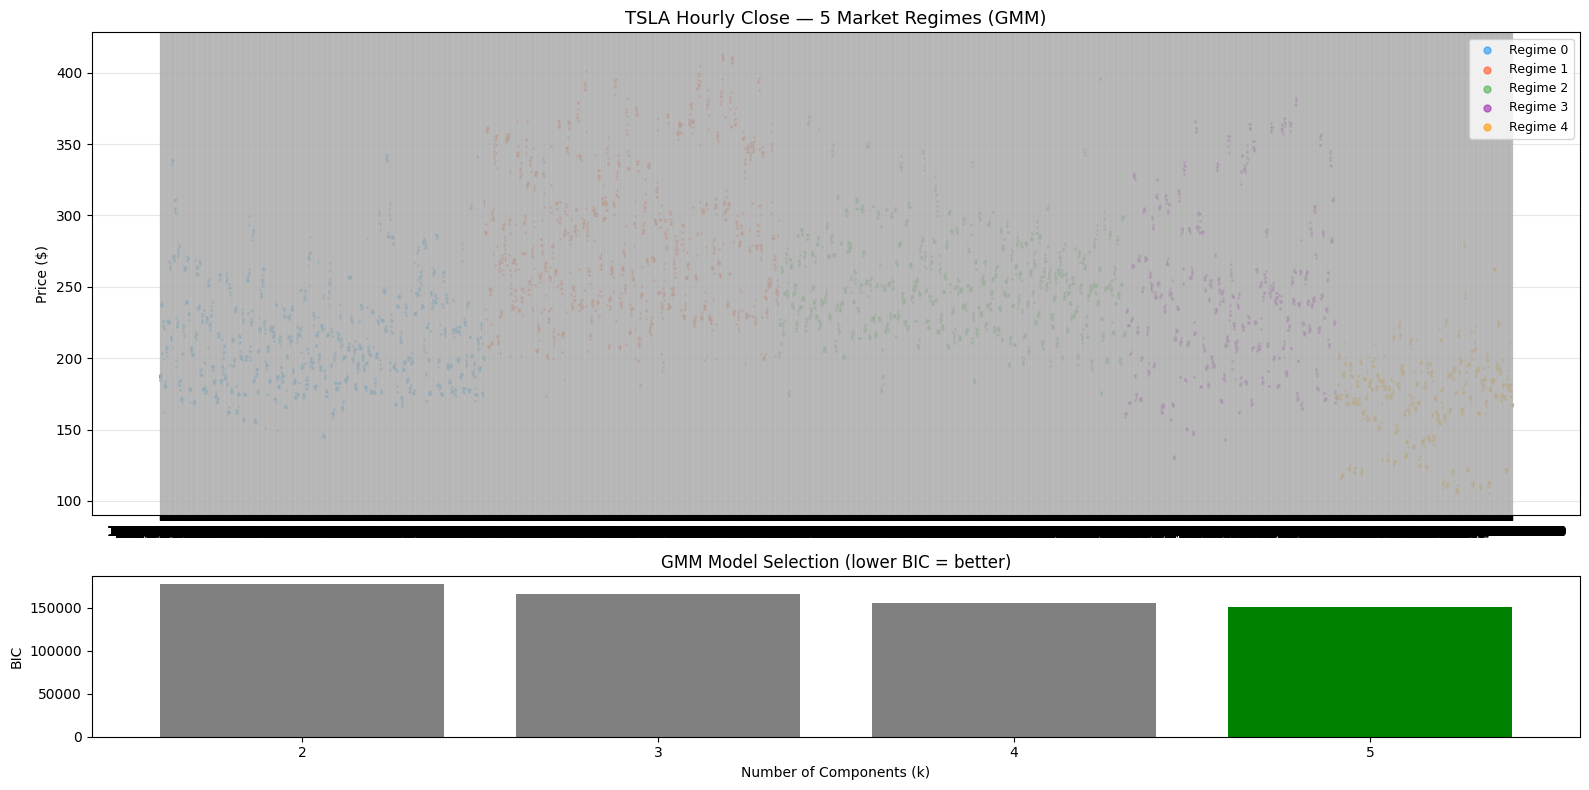


── Per-Regime Statistics ──
  Regime 0 (1,563 bars): mean_ret=-0.1948%, vol=8.2556%, avg_volume=14,325,279
  Regime 1 (1,420 bars): mean_ret=2.9410%, vol=9.8538%, avg_volume=13,594,146
  Regime 2 (1,667 bars): mean_ret=0.1652%, vol=6.6498%, avg_volume=10,368,782
  Regime 3 (1,021 bars): mean_ret=3.6079%, vol=14.4691%, avg_volume=11,365,414
  Regime 4 (846 bars): mean_ret=-9.2939%, vol=24.2257%, avg_volume=19,033,628


In [ ]:
# ---------------------------------------------------------------------------
# Cell 10b — Component 1: Regime Features (Multi-ticker, no clustering)
# ---------------------------------------------------------------------------

# Instead of GMM→XGB (TSLA-only), we compute continuous, lookback-only regime
# features per ticker from hourly bars, then later merge them into sweeps via
# a backward (past-only) merge_asof.

def engineer_hourly_regime_features(df_hourly: pd.DataFrame) -> pd.DataFrame:
    """Lookback-only regime features from hourly OHLCV. Returns a DataFrame indexed by timestamp."""
    df = df_hourly.copy()
    df = df.sort_index()

    required = {'Open', 'High', 'Low', 'Close'}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Hourly data missing columns: {sorted(missing)}")

    open_ = df['Open'].astype(float)
    high  = df['High'].astype(float)
    low   = df['Low'].astype(float)
    close = df['Close'].astype(float)
    vol   = df['Volume'].astype(float) if 'Volume' in df.columns else pd.Series(0.0, index=df.index)

    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs(),
    ], axis=1).max(axis=1)

    atr14 = tr.rolling(14, min_periods=14).mean()
    atr56 = tr.rolling(56, min_periods=56).mean()

    log_ret = np.log(close / close.shift(1))
    rv20 = log_ret.rolling(20, min_periods=20).std()
    rv60 = log_ret.rolling(60, min_periods=60).std()

    sma20 = close.rolling(20, min_periods=20).mean()
    std20 = close.rolling(20, min_periods=20).std()

    vol_sma20 = vol.rolling(20, min_periods=20).mean()
    log_vol = np.log1p(vol)
    log_vol_mean60 = log_vol.rolling(60, min_periods=60).mean()
    log_vol_std60  = log_vol.rolling(60, min_periods=60).std()

    out = pd.DataFrame(index=df.index)
    out['reg_atr14_pct'] = atr14 / close
    out['reg_atr_ratio'] = atr14 / atr56.replace(0, np.nan)
    out['reg_rv20'] = rv20
    out['reg_rv_ratio'] = rv20 / rv60.replace(0, np.nan)
    out['reg_bb_bw'] = (2.0 * std20) / sma20.replace(0, np.nan)
    out['reg_bb_pos'] = (close - (sma20 - 2.0 * std20)) / (4.0 * std20).replace(0, np.nan)

    # Normalized SMA slope over last 10 bars (percent-ish, lookback only)
    def _slope_last(x: np.ndarray) -> float:
        xs = np.arange(len(x), dtype=float)
        return float(np.polyfit(xs, x, 1)[0])

    out['reg_sma20_slope_pct'] = sma20.rolling(10, min_periods=10).apply(_slope_last, raw=True) / close

    out['reg_vol_ratio'] = vol / vol_sma20.replace(0, np.nan)
    out['reg_logvol_z'] = (log_vol - log_vol_mean60) / log_vol_std60.replace(0, np.nan)

    # Basic candle structure (scale-free)
    candle_range = (high - low).replace(0, np.nan)
    out['reg_body_ratio'] = (close - open_).abs() / candle_range
    out['reg_range_pct'] = (high - low) / close

    out = out.replace([np.inf, -np.inf], np.nan).dropna()
    return out

# Load hourly data for each ticker (from earlier notebook parts if available)
hourly_by_ticker = globals().get('hourly_by_ticker', {})
if not hourly_by_ticker:
    hourly_by_ticker = {t: load_hourly_csv(t) for t in TICKERS}

hourly_regime_by_ticker: Dict[str, pd.DataFrame] = {}
for t in TICKERS:
    dfh = hourly_by_ticker.get(t)
    if dfh is None or dfh.empty:
        print(f"⚠ No hourly data for {t}; skipping regime features")
        continue
    try:
        feats = engineer_hourly_regime_features(dfh)
        hourly_regime_by_ticker[t] = feats
        print(f"{t}: hourly bars={len(dfh):,}, regime feats={feats.shape}")
    except Exception as e:
        print(f"⚠ {t}: failed to compute regime features: {e}")

# Convenience: list of regime feature column names
REGIME_FEATURE_COLS = []
for _t, _df in hourly_regime_by_ticker.items():
    REGIME_FEATURE_COLS = list(_df.columns)
    break
print(f"\nRegime feature columns ({len(REGIME_FEATURE_COLS)}): {REGIME_FEATURE_COLS}")

In [ ]:
# ---------------------------------------------------------------------------
# Cell 10c — Feature Assembly (ALL tickers + consolidated MIDAS join)
# ---------------------------------------------------------------------------

def load_sweeps_all() -> pd.DataFrame:
    """Load combined sweeps (prefer in-memory, else exported CSVs)."""
    # Prefer in-memory if Part 8 was run in this kernel
    df_mem = globals().get('sweeps_all_with_midas', None)
    if isinstance(df_mem, pd.DataFrame) and not df_mem.empty:
        return df_mem.copy()

    if OUTPUT_SWEEPS_WITH_MIDAS.exists():
        return pd.read_csv(OUTPUT_SWEEPS_WITH_MIDAS)

    df_mem2 = globals().get('sweeps_all_no_midas', None)
    if isinstance(df_mem2, pd.DataFrame) and not df_mem2.empty:
        return df_mem2.copy()

    if OUTPUT_SWEEPS_NO_MIDAS.exists():
        return pd.read_csv(OUTPUT_SWEEPS_NO_MIDAS)

    raise FileNotFoundError(
        "No combined sweeps available. Run Part 8 + multi-ticker export (Part 9), "
        "or provide outputs/sweeps_analysis/**/ALL_Sweeps_*.csv."
    )

df_sweeps = load_sweeps_all()

# Basic required columns
if 'timestamp' not in df_sweeps.columns:
    raise ValueError("Sweeps data missing 'timestamp' column")

df_sweeps['timestamp'] = pd.to_datetime(df_sweeps['timestamp'], dayfirst=True, format='mixed')
df_sweeps = df_sweeps.sort_values('timestamp').reset_index(drop=True)

# Ensure ticker exists
if 'ticker' not in df_sweeps.columns:
    fallback_ticker = globals().get('TICKER', None)
    if fallback_ticker is None:
        raise ValueError("Sweeps data missing 'ticker' and no global TICKER fallback")
    df_sweeps['ticker'] = str(fallback_ticker).upper()

df_sweeps['ticker'] = df_sweeps['ticker'].astype(str).str.upper()

# Filter labeled sweeps
if 'outcome' not in df_sweeps.columns:
    raise ValueError("Sweeps data missing 'outcome' column (need WIN/LOSS/TIMEOUT)")
df_sweeps = df_sweeps[df_sweeps['outcome'] != 'TIMEOUT'].reset_index(drop=True)
y = (df_sweeps['outcome'] == 'WIN').astype(int).values
print(f"Labeled sweeps (ALL): {len(df_sweeps)} | WIN={y.sum()} LOSS={len(y)-y.sum()} | tickers={df_sweeps['ticker'].nunique()}")
print(df_sweeps['ticker'].value_counts().to_string())

# ── MIDAS join: consolidated file keyed by (ticker, date) ──
df_sweeps['sweep_date'] = df_sweeps['timestamp'].dt.normalize()

midas_cols_present = [c for c in MIDAS_FEATURES if c in df_sweeps.columns]
if midas_cols_present:
    # Rebuild MIDAS features from consolidated source to ensure correct (ticker,date) mapping
    df_sweeps = df_sweeps.drop(columns=midas_cols_present, errors='ignore')

df_midas = pd.read_csv(MIDAS_CONSOLIDATED_CSV) if MIDAS_CONSOLIDATED_CSV.exists() else pd.DataFrame()
if df_midas.empty:
    print(f"⚠ Consolidated MIDAS file not found or empty: {MIDAS_CONSOLIDATED_CSV}")
    available_midas_cols = []
else:
    df_midas.columns = [c.strip() for c in df_midas.columns]
    date_col = 'date' if 'date' in df_midas.columns else ('Date' if 'Date' in df_midas.columns else None)
    ticker_col = 'ticker' if 'ticker' in df_midas.columns else ('Ticker' if 'Ticker' in df_midas.columns else None)
    if date_col is None or ticker_col is None:
        raise ValueError(f"MIDAS consolidated file must contain ticker+date columns. Got: {df_midas.columns.tolist()}")

    df_midas[date_col] = pd.to_datetime(df_midas[date_col]).dt.normalize()
    df_midas[ticker_col] = df_midas[ticker_col].astype(str).str.upper()

    # Keep only desired raw columns that actually exist
    available_raw = [c for c in MIDAS_FEATURES_RAW if c in df_midas.columns]
    missing_raw = [c for c in MIDAS_FEATURES_RAW if c not in df_midas.columns]
    if missing_raw:
        print(f"⚠ MIDAS missing raw columns (skipping): {missing_raw}")

    midas_subset = df_midas[[ticker_col, date_col] + available_raw].copy()
    midas_subset = midas_subset.sort_values([ticker_col, date_col])

    # Rolling MIDAS features per ticker (past-only)
    for col in [c for c in MIDAS_ROLLING_COLS if c in midas_subset.columns]:
        roll = midas_subset.groupby(ticker_col)[col].transform(lambda s: s.rolling(5, min_periods=1).mean())
        midas_subset[f'{col}_5d'] = roll
        midas_subset[f'{col}_ratio'] = midas_subset[col] / roll.replace(0, np.nan)

    available_midas_cols = [c for c in MIDAS_FEATURES if c in midas_subset.columns]

    df_sweeps = df_sweeps.merge(
        midas_subset[[ticker_col, date_col] + available_midas_cols],
        left_on=['ticker', 'sweep_date'],
        right_on=[ticker_col, date_col],
        how='left',
    )

    # Clean up merge key columns
    df_sweeps = df_sweeps.drop(columns=[ticker_col, date_col], errors='ignore')

    null_midas = int(df_sweeps[available_midas_cols].isna().sum().sum()) if available_midas_cols else 0
    print(f"MIDAS join: cols={len(available_midas_cols)} null_values={null_midas}")

# ── Regime feature merge (per ticker, past-only) ──
if 'hourly_regime_by_ticker' not in globals() or not isinstance(hourly_regime_by_ticker, dict) or not hourly_regime_by_ticker:
    raise RuntimeError("Run Cell 10b first to build hourly_regime_by_ticker")

df_sweeps = df_sweeps.sort_values(['ticker', 'timestamp']).reset_index(drop=True)
reg_merged_parts = []
for t, part in df_sweeps.groupby('ticker', sort=False):
    reg = hourly_regime_by_ticker.get(t)
    if reg is None or reg.empty:
        # No regime features; create NaNs for expected columns
        tmp = part.copy()
        for c in REGIME_FEATURE_COLS:
            tmp[c] = np.nan
        reg_merged_parts.append(tmp)
        continue

    reg2 = reg.reset_index().rename(columns={reg.index.name or 'index': 'timestamp'})
    reg2['timestamp'] = pd.to_datetime(reg2['timestamp'])
    reg2 = reg2.sort_values('timestamp')

    part2 = part.sort_values('timestamp')
    merged = pd.merge_asof(
        part2,
        reg2,
        on='timestamp',
        direction='backward',
        allow_exact_matches=True,
    )
    reg_merged_parts.append(merged)

df_sweeps = pd.concat(reg_merged_parts, ignore_index=True)
REGIME_FEATURES = [c for c in df_sweeps.columns if c.startswith('reg_')]
print(f"Regime merge: added {len(REGIME_FEATURES)} columns")

# ── Sweep feature engineering (cross-ticker normalization) ──
if 'reversal_price' in df_sweeps.columns:
    denom = pd.to_numeric(df_sweeps['reversal_price'], errors='coerce').replace(0, np.nan)
else:
    # Fallback: use zone midpoint if present
    if 'zone_top' in df_sweeps.columns and 'zone_bottom' in df_sweeps.columns:
        denom = (pd.to_numeric(df_sweeps['zone_top'], errors='coerce') + pd.to_numeric(df_sweeps['zone_bottom'], errors='coerce')) / 2.0
        denom = denom.replace(0, np.nan)
    else:
        denom = pd.Series(np.nan, index=df_sweeps.index)

def _pct(col: str, out_col: str):
    if col in df_sweeps.columns:
        df_sweeps[out_col] = pd.to_numeric(df_sweeps[col], errors='coerce') / denom

_pct('reversal_distance', 'reversal_distance_pct')
_pct('candle_total_range', 'candle_total_range_pct')
_pct('candle_body', 'candle_body_pct')
_pct('upper_wick', 'upper_wick_pct')
_pct('lower_wick', 'lower_wick_pct')

if 'volume' in df_sweeps.columns:
    df_sweeps['log_volume'] = np.log1p(pd.to_numeric(df_sweeps['volume'], errors='coerce'))
else:
    df_sweeps['log_volume'] = np.nan

# ── Drop unusable/identifier columns (but keep ticker/timestamp for grouping/reporting) ──
for c in DROP_COLS:
    if c in df_sweeps.columns:
        df_sweeps = df_sweeps.drop(columns=[c])

# ── Encode categoricals (including ticker) ──
cat_encoded_cols: List[str] = []
for col in SWEEP_CAT:
    if col not in df_sweeps.columns:
        continue
    dummies = pd.get_dummies(df_sweeps[col].astype(str), prefix=col, drop_first=True)
    for dc in dummies.columns:
        df_sweeps[dc] = dummies[dc].values
        cat_encoded_cols.append(dc)
print(f"Categorical encoding: {len(cat_encoded_cols)} dummy columns")

# ── Build feature matrices ──
numeric_candidates = [c for c in SWEEP_NUMERIC if c in df_sweeps.columns]
bool_candidates    = [c for c in SWEEP_BOOL if c in df_sweeps.columns]

shared_features = numeric_candidates + bool_candidates + cat_encoded_cols + REGIME_FEATURES
teacher_features = shared_features + [c for c in available_midas_cols if c in df_sweeps.columns]
student_features = shared_features

# Ensure all feature cols are numeric and impute
for col in set(teacher_features + student_features):
    df_sweeps[col] = pd.to_numeric(df_sweeps[col], errors='coerce')

for col in set(teacher_features + student_features):
    if df_sweeps[col].isna().any():
        if col in bool_candidates or col in cat_encoded_cols:
            df_sweeps[col] = df_sweeps[col].fillna(0)
        else:
            df_sweeps[col] = df_sweeps[col].fillna(df_sweeps[col].median())

# Simple relevance + collinearity filtering (no statsmodels dependency)
def select_features_simple(df: pd.DataFrame, feature_cols: List[str], target: np.ndarray, min_abs_corr: float = 0.02, max_pair_corr: float = 0.95) -> List[str]:
    cols = [c for c in feature_cols if c in df.columns]
    if not cols:
        return []
    tmp = df[cols].copy()
    tmp['_target'] = target
    corrs = tmp.corr(method='spearman')['_target'].drop('_target')
    relevant = corrs[corrs.abs() >= min_abs_corr].sort_values(key=lambda s: s.abs(), ascending=False).index.tolist()
    if len(relevant) <= 1:
        return relevant

    selected: List[str] = []
    for c in relevant:
        keep = True
        for s in selected:
            pair = df[[c, s]].corr(method='spearman').iloc[0, 1]
            if pd.notna(pair) and abs(pair) >= max_pair_corr:
                keep = False
                break
        if keep:
            selected.append(c)
    return selected

teacher_selected = select_features_simple(df_sweeps, teacher_features, y)
student_selected = select_features_simple(df_sweeps, student_features, y)

X_teacher = df_sweeps[teacher_selected].values.astype(np.float64)
X_student = df_sweeps[student_selected].values.astype(np.float64)

print("\n── Feature Summary ──")
print(f"Teacher candidates: {len(teacher_features)} | selected: {len(teacher_selected)}")
print(f"Student candidates: {len(student_features)} | selected: {len(student_selected)}")
print(f"Samples: {len(df_sweeps)}")

teacher_only = sorted(set(teacher_selected) - set(student_selected))
print(f"Teacher-only (privileged) feature count: {len(teacher_only)}")
if teacher_only:
    print(f"Teacher-only features: {teacher_only[:25]}" + (" ..." if len(teacher_only) > 25 else ""))

Labeled sweeps: 116 (WIN=107, LOSS=9)
MIDAS join: 0 null values (expect 0)
Regime assigned: {1: 62, 2: 47, 0: 4, 3: 3}
Categorical encoding: 9 dummy columns created
  VIF dropped 14 features: [('zone_sweep_count', np.float64(inf)), ('is_first_sweep', np.float64(inf)), ('Oddlot_Rate', np.float64(11735.8)), ('days_old_at_sweep', np.float64(903.5)), ('Hidden_Rate_5d', np.float64(573.5)), ('Cancel_to_Trade', np.float64(162.3)), ('Oddlot_Volume', np.float64(122.4)), ('candle_body', np.float64(58.6)), ('daysold', np.float64(44.7)), ('Oddlot_Rate_5d', np.float64(20.8)), ('candle_total_range', np.float64(18.4)), ('reversal_pattern', np.float64(14.7)), ('Hidden_Volume', np.float64(14.4)), ('volume_zscore', np.float64(10.5))]
  VIF dropped 8 features: [('zone_sweep_count', np.float64(inf)), ('is_first_sweep', np.float64(inf)), ('days_old_at_sweep', np.float64(802.2)), ('composite_no_midas', np.float64(108.1)), ('candle_body', np.float64(41.9)), ('daysold', np.float64(34.1)), ('candle_total_range

In [ ]:
# ---------------------------------------------------------------------------
# Cell 10d — Temporal Cross-Validation Setup (time-based purge)
# ---------------------------------------------------------------------------

if 'timestamp' not in df_sweeps.columns:
    raise RuntimeError("df_sweeps must exist from Cell 10c")

df_sweeps = df_sweeps.sort_values('timestamp').reset_index(drop=True)

def build_cv_splits_time_purged(df: pd.DataFrame, n_splits: int, purge_days: int) -> List[Tuple[np.ndarray, np.ndarray]]:
    """
    Uses sklearn TimeSeriesSplit, then removes train samples that fall within
    `purge_days` of the test window start (time-based purge).
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    purge_td = pd.Timedelta(days=int(purge_days))
    splits: List[Tuple[np.ndarray, np.ndarray]] = []

    for tr_idx, te_idx in tscv.split(df):
        te_start_ts = df.loc[te_idx[0], 'timestamp']
        cutoff = te_start_ts - purge_td
        tr_idx2 = tr_idx[df.loc[tr_idx, 'timestamp'] < cutoff]

        if len(tr_idx2) < MIN_TRAIN_SIZE or len(te_idx) < MIN_TEST_SIZE:
            continue
        splits.append((tr_idx2.astype(int), te_idx.astype(int)))

    return splits

cv_splits = build_cv_splits_time_purged(df_sweeps, n_splits=N_CV_FOLDS, purge_days=PURGE_DAYS)

print("── Temporal CV Splits (time-based purge) ──")
print(f"Total samples: {len(y)} | Folds: {len(cv_splits)} | Purge: {PURGE_DAYS} days")
print()

for i, (tr, te) in enumerate(cv_splits):
    tr_start, tr_end = df_sweeps.loc[tr[0], 'timestamp'], df_sweeps.loc[tr[-1], 'timestamp']
    te_start, te_end = df_sweeps.loc[te[0], 'timestamp'], df_sweeps.loc[te[-1], 'timestamp']
    tr_wr = float(y[tr].mean())
    te_wr = float(y[te].mean())
    tick_tr = df_sweeps.loc[tr, 'ticker'].value_counts().to_dict() if 'ticker' in df_sweeps.columns else {}
    tick_te = df_sweeps.loc[te, 'ticker'].value_counts().to_dict() if 'ticker' in df_sweeps.columns else {}
    print(f"Fold {i}: Train n={len(tr):3d} WR={tr_wr:.1%} {tr_start:%Y-%m-%d}→{tr_end:%Y-%m-%d}")
    print(f"        Test  n={len(te):3d} WR={te_wr:.1%} {te_start:%Y-%m-%d}→{te_end:%Y-%m-%d}")
    if tick_tr and tick_te:
        print(f"        Train tickers: {tick_tr}")
        print(f"        Test  tickers: {tick_te}")

# Leakage check (time-based)
purge_td = pd.Timedelta(days=int(PURGE_DAYS))
for i, (tr, te) in enumerate(cv_splits):
    last_train_ts = df_sweeps.loc[tr, 'timestamp'].max()
    first_test_ts = df_sweeps.loc[te, 'timestamp'].min()
    assert last_train_ts < first_test_ts - purge_td, (
        f"Fold {i}: purge violation: last_train={last_train_ts} first_test={first_test_ts}"
    )
print(f"\nLeakage check PASSED (>= {PURGE_DAYS} day purge between train/test in all folds)")

# ── Evaluation helper ──
def evaluate_model(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> Dict[str, float]:
    y_prob = np.asarray(y_prob, dtype=float)
    y_true = np.asarray(y_true, dtype=int)
    y_pred = (y_prob >= threshold).astype(int)
    n_pos = int(y_true.sum())
    n = int(len(y_true))

    metrics = {
        'auc': roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0.5,
        'brier': brier_score_loss(y_true, y_prob),
        'accuracy': float((y_pred == y_true).mean()),
        'precision': float((y_pred & y_true).sum() / max(int(y_pred.sum()), 1)),
        'recall': float((y_pred & y_true).sum() / max(n_pos, 1)),
        'n_test': n,
        'n_pos': n_pos,
        'win_rate_actual': float(y_true.mean()),
    }
    return metrics

def aggregate_cv_metrics(fold_metrics_list: List[Dict[str, float]]) -> Dict[str, float]:
    keys = fold_metrics_list[0].keys()
    agg: Dict[str, float] = {}
    for k in keys:
        vals = [m[k] for m in fold_metrics_list]
        agg[f'{k}_mean'] = float(np.mean(vals))
        agg[f'{k}_std']  = float(np.std(vals))
    return agg

print("\nEvaluation functions ready")

── Temporal CV Splits ──
Total samples: 116 | Folds: 5 | Purge gap: 5

  Fold 0: Train [  0: 39] ( 40 samples, WR=97.5%) 2021-02-16→2022-05-31
           Test  [ 45: 58] ( 14 samples, WR=100.0%) 2022-06-23→2022-08-15
  Fold 1: Train [  0: 53] ( 54 samples, WR=98.1%) 2021-02-16→2022-07-11
           Test  [ 59: 72] ( 14 samples, WR=85.7%) 2022-09-06→2023-02-16
  Fold 2: Train [  0: 67] ( 68 samples, WR=97.1%) 2021-02-16→2022-11-28
           Test  [ 73: 86] ( 14 samples, WR=78.6%) 2023-03-20→2023-11-09
  Fold 3: Train [  0: 81] ( 82 samples, WR=92.7%) 2021-02-16→2023-09-27
           Test  [ 87:100] ( 14 samples, WR=78.6%) 2023-11-10→2024-02-15
  Fold 4: Train [  0: 95] ( 96 samples, WR=90.6%) 2021-02-16→2024-02-02
           Test  [101:115] ( 15 samples, WR=100.0%) 2024-02-27→2024-09-27

Leakage check PASSED (all folds have >= 5 sample gap)

Evaluation functions ready



Model                                 AUC      Brier        Acc       Prec        Rec
B1: Majority class               0.500±0.00   0.108±0.09   0.886±0.10   0.886±0.10   1.000±0.00
B2: Quality score                0.566±0.20   0.192±0.03   0.789±0.06   0.901±0.09   0.860±0.05
B3: LR (sweep only)              0.533±0.07   0.228±0.02   0.675±0.28   0.721±0.37   0.710±0.37
B4: LR (sweep+regime)            0.527±0.05   0.251±0.03   0.607±0.29   0.757±0.39   0.598±0.38
B5: Teacher LR                   0.479±0.04   0.325±0.15   0.482±0.34   0.557±0.46   0.453±0.46
B6: Teacher XGB                  0.500±0.00   0.103±0.07   0.886±0.10   0.886±0.10   1.000±0.00


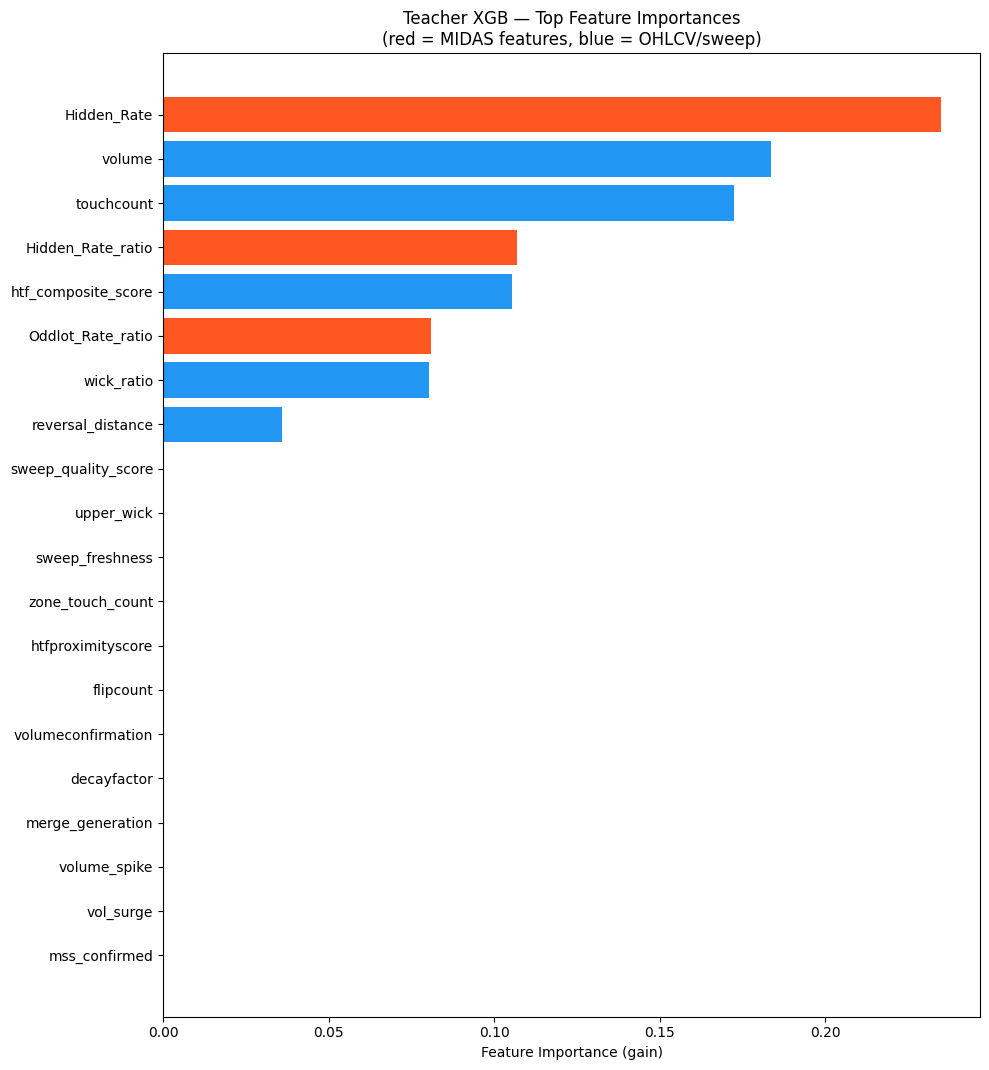


Teacher OOF predictions available for 71/116 samples


In [ ]:
# ---------------------------------------------------------------------------
# Cell 10e — Component 2: Teacher Model Training + Evaluation (sklearn-only)
# ---------------------------------------------------------------------------

# Storage for out-of-fold teacher predictions (needed for student distillation)
teacher_oof_probs = np.full(len(y), np.nan)  # OOF P(WIN) for primary teacher

# Optional OOF storage for plots
b5_oof_probs = np.full(len(y), np.nan)  # Teacher LR
b4_oof_probs = np.full(len(y), np.nan)  # Student LR (with regime)
b3_oof_probs = np.full(len(y), np.nan)  # Student LR (no regime)

# Results storage
all_results: Dict[str, Dict[str, float]] = {}

# ── Baseline B1: prevalence (predict train win rate) ──
b1_metrics = []
for tr_idx, te_idx in cv_splits:
    y_prob = np.full(len(te_idx), float(y[tr_idx].mean()))
    b1_metrics.append(evaluate_model(y[te_idx], y_prob))
all_results['B1: Majority class'] = aggregate_cv_metrics(b1_metrics)

# ── Baseline B2: quality score proxy ──
b2_metrics = []
for tr_idx, te_idx in cv_splits:
    if 'sweep_quality_score' not in df_sweeps.columns:
        raise ValueError("Missing sweep_quality_score for baseline B2")
    scores_test = pd.to_numeric(df_sweeps.loc[te_idx, 'sweep_quality_score'], errors='coerce').fillna(0).values
    y_prob = np.clip(scores_test / 100.0, 0, 1)
    b2_metrics.append(evaluate_model(y[te_idx], y_prob))
all_results['B2: Quality score'] = aggregate_cv_metrics(b2_metrics)

# ── Baseline B3: LR (sweep only; drop regime features) ──
student_no_regime = [f for f in student_selected if (f not in REGIME_FEATURES and not str(f).startswith('reg_'))]
X_student_no_regime = df_sweeps[student_no_regime].values.astype(np.float64) if student_no_regime else X_student

b3_metrics = []
for tr_idx, te_idx in cv_splits:
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_student_no_regime[tr_idx])
    X_te = scaler.transform(X_student_no_regime[te_idx])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 10),
        penalty='elasticnet', solver='saga', l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring='roc_auc', max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr_idx])
    y_prob = lr.predict_proba(X_te)[:, 1]
    b3_oof_probs[te_idx] = y_prob
    b3_metrics.append(evaluate_model(y[te_idx], y_prob))
all_results['B3: LR (sweep only)'] = aggregate_cv_metrics(b3_metrics)

# ── Baseline B4: LR (sweep + regime; no MIDAS) ──
b4_metrics = []
for tr_idx, te_idx in cv_splits:
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_student[tr_idx])
    X_te = scaler.transform(X_student[te_idx])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 10),
        penalty='elasticnet', solver='saga', l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring='roc_auc', max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr_idx])
    y_prob = lr.predict_proba(X_te)[:, 1]
    b4_oof_probs[te_idx] = y_prob
    b4_metrics.append(evaluate_model(y[te_idx], y_prob))
all_results['B4: LR (sweep+regime)'] = aggregate_cv_metrics(b4_metrics)

# ── Teacher B5: LR (sweep + regime + MIDAS) ──
b5_metrics = []
for tr_idx, te_idx in cv_splits:
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_teacher[tr_idx])
    X_te = scaler.transform(X_teacher[te_idx])
    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 10),
        penalty='elasticnet', solver='saga', l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring='roc_auc', max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr_idx])
    y_prob = lr.predict_proba(X_te)[:, 1]
    b5_oof_probs[te_idx] = y_prob
    b5_metrics.append(evaluate_model(y[te_idx], y_prob))
all_results['B5: Teacher LR'] = aggregate_cv_metrics(b5_metrics)

# ── Teacher B6: HistGradientBoosting (PRIMARY TEACHER) ──
teacher_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=400,
        l2_regularization=1.0, random_state=42
    )),
])

b6_metrics = []
for tr_idx, te_idx in cv_splits:
    sw = compute_sample_weight(class_weight='balanced', y=y[tr_idx])
    teacher_pipe.fit(X_teacher[tr_idx], y[tr_idx], model__sample_weight=sw)
    y_prob = teacher_pipe.predict_proba(X_teacher[te_idx])[:, 1]
    teacher_oof_probs[te_idx] = y_prob
    b6_metrics.append(evaluate_model(y[te_idx], y_prob))
all_results['B6: Teacher HGB'] = aggregate_cv_metrics(b6_metrics)

# ── Baseline B7: HGB (Baseline: sweep + OHLCV + MIDAS, NO REGIME) ──
b7_metrics = []
X_teacher_baseline = np.copy(X_teacher)
regime_cols_idx = [i for i, f in enumerate(teacher_selected) if 'regime' in str(f).lower() or str(f).lower().startswith('reg_')]
if len(regime_cols_idx) > 0:
    X_teacher_baseline = np.delete(X_teacher_baseline, regime_cols_idx, axis=1)

baseline_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=400,
        l2_regularization=1.0, random_state=42
    )),
])

for tr_idx, te_idx in cv_splits:
    sw = compute_sample_weight(class_weight='balanced', y=y[tr_idx])
    baseline_pipe.fit(X_teacher_baseline[tr_idx], y[tr_idx], model__sample_weight=sw)
    y_prob = baseline_pipe.predict_proba(X_teacher_baseline[te_idx])[:, 1]
    b7_metrics.append(evaluate_model(y[te_idx], y_prob))

all_results['B7: Baseline HGB (No Regime)'] = aggregate_cv_metrics(b7_metrics)

# ── Baseline B7: HGB (Baseline: sweep + OHLCV + MIDAS, NO REGIME) ──
b7_metrics = []
X_teacher_baseline = np.copy(X_teacher)
regime_cols_idx = [i for i, f in enumerate(teacher_selected) if 'regime' in str(f).lower() or str(f).lower().startswith('reg_')]
if len(regime_cols_idx) > 0:
    X_teacher_baseline = np.delete(X_teacher_baseline, regime_cols_idx, axis=1)

baseline_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=400,
        l2_regularization=1.0, random_state=42
    )),
])

for tr_idx, te_idx in cv_splits:
    sw = compute_sample_weight(class_weight='balanced', y=y[tr_idx])
    baseline_pipe.fit(X_teacher_baseline[tr_idx], y[tr_idx], model__sample_weight=sw)
    y_prob = baseline_pipe.predict_proba(X_teacher_baseline[te_idx])[:, 1]
    b7_metrics.append(evaluate_model(y[te_idx], y_prob))

all_results['B7: Baseline HGB (No Regime)'] = aggregate_cv_metrics(b7_metrics)

# ── Print intermediate results ──
print("\n" + "="*105)
print(f"{'Model':<30} {'AUC':>12} {'Brier':>12} {'Accuracy':>12} {'Precision':>12} {'Recall':>12}")
print("="*105)
for name, agg in all_results.items():
    print(f"{name:<30} "
          f"{agg['auc_mean']:.3f}±{agg['auc_std']:.3f} "
          f"{agg['brier_mean']:.3f}±{agg['brier_std']:.3f} "
          f"{agg['accuracy_mean']:.3f}±{agg['accuracy_std']:.3f} "
          f"{agg['precision_mean']:.3f}±{agg['precision_std']:.3f} "
          f"{agg['recall_mean']:.3f}±{agg['recall_std']:.3f}")
print("="*105)

# ── Teacher feature importance (permutation importance; small-data friendly) ──
try:
    sw_full = compute_sample_weight(class_weight='balanced', y=y)
    teacher_full = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', HistGradientBoostingClassifier(
            max_depth=3, learning_rate=0.05, max_iter=400,
            l2_regularization=1.0, random_state=42
        )),
    ])
    teacher_full.fit(X_teacher, y, model__sample_weight=sw_full)

    perm = permutation_importance(
        teacher_full, X_teacher, y,
        scoring='roc_auc', n_repeats=20, random_state=42
    )
    imp = pd.DataFrame({
        'feature': teacher_selected,
        'importance_mean': perm.importances_mean,
        'importance_std': perm.importances_std,
    }).sort_values('importance_mean', ascending=False)

    top_n = min(15, len(imp))
    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * top_n)))
    view = imp.head(top_n).iloc[::-1]
    ax.barh(view['feature'], view['importance_mean'], xerr=view['importance_std'], color='#FF5722', alpha=0.85)
    ax.set_title('Teacher HGB — Permutation Importance (ROC-AUC)')
    ax.set_xlabel('Mean importance (ΔAUC)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"⚠ Permutation importance skipped: {e}")

# Check OOF teacher coverage
oof_coverage = int(np.sum(~np.isnan(teacher_oof_probs)))
print(f"\nTeacher OOF predictions available for {oof_coverage}/{len(y)} samples")


── Student Model Results ──
Model                                 AUC      Brier        Acc
-----------------------------------------------------------------
S1: Student (hard labels)        0.500±0.00   0.106±0.06   0.886±0.10
S2: Student (α=0.5)              0.467±0.04   0.103±0.08   0.886±0.10
S3: Student (α=0.7)              0.531±0.03   0.103±0.08   0.886±0.10
S4: Student (α=1.0)              0.553±0.07   0.102±0.08   0.886±0.10


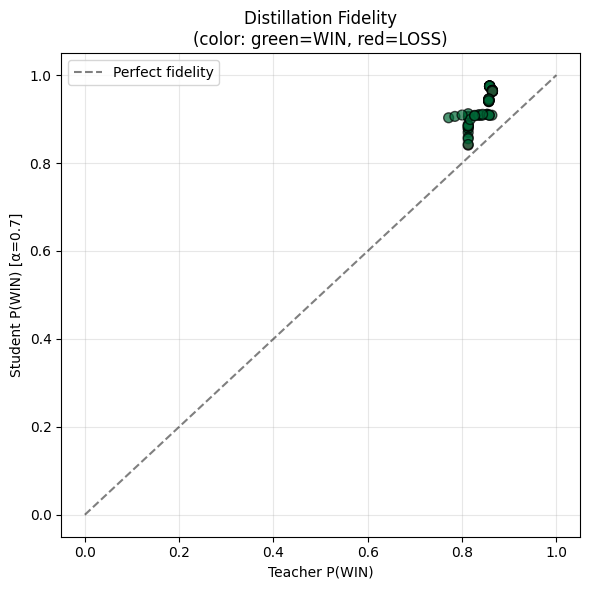


Distillation fidelity (Pearson r): 0.799


In [ ]:
# ---------------------------------------------------------------------------
# Cell 10f — Component 3: Student Model Training (Knowledge Distillation)
# ---------------------------------------------------------------------------

# OOF storage for plots/exports
s1_oof_probs = np.full(len(y), np.nan)

# ── Student S1: Hard-label classifier (no MIDAS) ──
s1_metrics = []
for tr_idx, te_idx in cv_splits:
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_student[tr_idx])
    X_te = scaler.transform(X_student[te_idx])

    lr = LogisticRegressionCV(
        Cs=np.logspace(-3, 2, 10),
        penalty='elasticnet', solver='saga', l1_ratios=[0.1, 0.5, 0.9],
        cv=3, scoring='roc_auc', max_iter=5000, random_state=42, class_weight='balanced'
    )
    lr.fit(X_tr, y[tr_idx])
    y_prob = lr.predict_proba(X_te)[:, 1]
    s1_oof_probs[te_idx] = y_prob
    s1_metrics.append(evaluate_model(y[te_idx], y_prob))
all_results['S1: Student (hard labels)'] = aggregate_cv_metrics(s1_metrics)

# ── Distillation helper (Ridge regression on blended soft targets) ──
def train_distilled_student_ridge(
    X: np.ndarray,
    y_hard: np.ndarray,
    teacher_oof: np.ndarray,
    splits: List[Tuple[np.ndarray, np.ndarray]],
    alpha: float,
    ridge_alpha: float = 1.0,
 ) -> Tuple[List[Dict[str, float]], np.ndarray]:
    """
    Blended target: alpha * teacher_prob + (1-alpha) * hard_label.
    Train a lightweight regression student to predict this probability-like target.
    Evaluate vs hard labels on each fold; returns fold metrics and OOF probs.
    """
    fold_metrics: List[Dict[str, float]] = []
    oof = np.full(len(y_hard), np.nan)

    for tr_idx, te_idx in splits:
        # Build soft targets on train indices (use teacher OOF when available; else hard)
        t_tr = teacher_oof[tr_idx].astype(float).copy()
        missing = np.isnan(t_tr)
        if missing.any():
            t_tr[missing] = y_hard[tr_idx][missing].astype(float)
        blended_tr = alpha * t_tr + (1.0 - alpha) * y_hard[tr_idx].astype(float)

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X[tr_idx])
        X_te = scaler.transform(X[te_idx])

        student = Ridge(alpha=float(ridge_alpha), random_state=42)
        student.fit(X_tr, blended_tr)
        y_prob = student.predict(X_te)
        y_prob = np.clip(y_prob, 0, 1)

        oof[te_idx] = y_prob
        fold_metrics.append(evaluate_model(y_hard[te_idx], y_prob))

    return fold_metrics, oof

# ── Student S2/S3/S4: Distilled students ──
s2_metrics, s2_oof = train_distilled_student_ridge(X_student, y, teacher_oof_probs, cv_splits, alpha=0.5, ridge_alpha=1.0)
all_results['S2: Student (α=0.5)'] = aggregate_cv_metrics(s2_metrics)

s3_metrics, s3_oof = train_distilled_student_ridge(X_student, y, teacher_oof_probs, cv_splits, alpha=0.7, ridge_alpha=1.0)
all_results['S3: Student (α=0.7)'] = aggregate_cv_metrics(s3_metrics)

s4_metrics, s4_oof = train_distilled_student_ridge(X_student, y, teacher_oof_probs, cv_splits, alpha=1.0, ridge_alpha=1.0)
all_results['S4: Student (α=1.0)'] = aggregate_cv_metrics(s4_metrics)

# ── Print student results ──
print("\n── Student Model Results ──")
print(f"{'Model':<30} {'AUC':>12} {'Brier':>12} {'Accuracy':>12}")
print("-" * 70)
for name in ['S1: Student (hard labels)', 'S2: Student (α=0.5)', 'S3: Student (α=0.7)', 'S4: Student (α=1.0)']:
    agg = all_results[name]
    print(f"{name:<30} "
          f"{agg['auc_mean']:.3f}±{agg['auc_std']:.3f} "
          f"{agg['brier_mean']:.3f}±{agg['brier_std']:.3f} "
          f"{agg['accuracy_mean']:.3f}±{agg['accuracy_std']:.3f}")

# ── Distillation fidelity plot (S3 vs teacher) ──
oof_mask = ~np.isnan(teacher_oof_probs) & ~np.isnan(s3_oof)
if oof_mask.sum() > 10:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(
        teacher_oof_probs[oof_mask], s3_oof[oof_mask],
        c=y[oof_mask], cmap='RdYlGn', alpha=0.7, edgecolors='k', s=45
    )
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect fidelity')
    ax.set_xlabel('Teacher P(WIN) [OOF]')
    ax.set_ylabel('Student P(WIN) [α=0.7, OOF]')
    ax.set_title('Distillation Fidelity (ALL tickers)')
    ax.legend()
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    fidelity_corr = float(np.corrcoef(teacher_oof_probs[oof_mask], s3_oof[oof_mask])[0, 1])
    print(f"\nDistillation fidelity (Pearson r): {fidelity_corr:.3f}")
else:
    print("\nInsufficient OOF overlap for fidelity plot")

Model                                   AUC        Brier     Accuracy    Precision       Recall
B1: Majority class             0.500±0.000 0.108±0.087 0.886±0.097 0.886±0.097 1.000±0.000
B2: Quality score              0.566±0.201 0.192±0.026 0.789±0.064 0.901±0.094 0.860±0.047
B3: LR (sweep only)            0.533±0.067 0.228±0.019 0.675±0.285 0.721±0.371 0.710±0.370
B4: LR (sweep+regime)          0.527±0.055 0.251±0.029 0.607±0.286 0.757±0.388 0.598±0.376
B5: Teacher LR                 0.479±0.042 0.325±0.153 0.482±0.345 0.557±0.462 0.453±0.457
B6: Teacher XGB                0.500±0.000 0.103±0.066 0.886±0.097 0.886±0.097 1.000±0.000
S1: Student (hard labels)      0.500±0.000 0.106±0.063 0.886±0.097 0.886±0.097 1.000±0.000
S2: Student (α=0.5)            0.467±0.043 0.103±0.083 0.886±0.097 0.886±0.097 1.000±0.000
S3: Student (α=0.7)            0.531±0.032 0.103±0.082 0.886±0.097 0.886±0.097 1.000±0.000
S4: Student (α=1.0)            0.553±0.074 0.102±0.080 0.886±0.097 0.886±0.097 1.000±

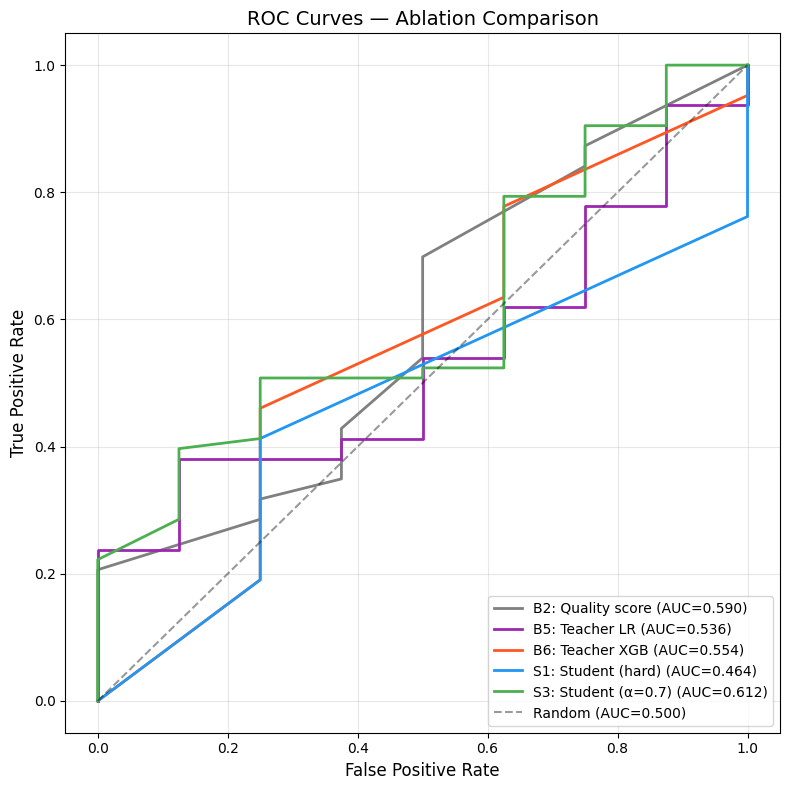

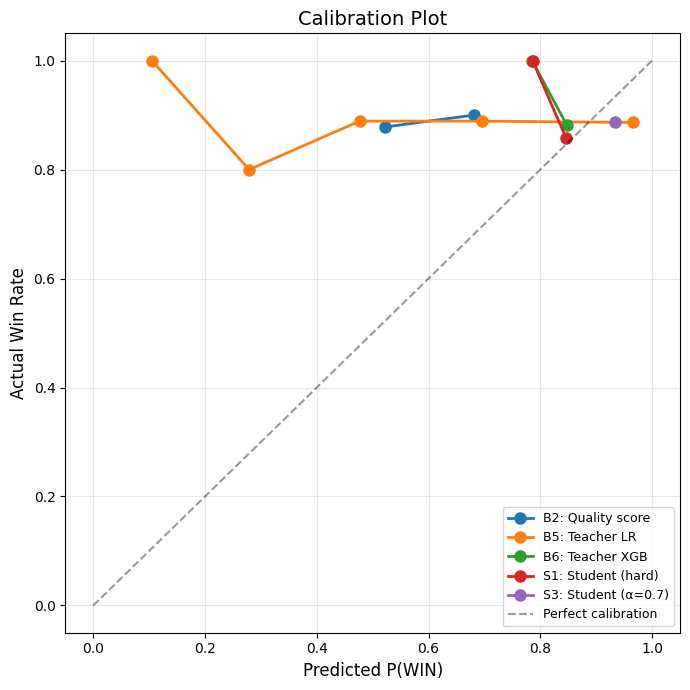


DISCUSSION

Key findings from the 10-variant ablation:

1. BASELINE: The rule-based quality score (B2) provides a strong baseline.
   Any ML model must demonstrate improvement over this simple threshold.

2. REGIME CLASSIFIER: Compare B3 vs B4 to determine if market regime
   classification adds predictive value to sweep outcome prediction.

3. TEACHER ADVANTAGE: Compare B5/B6 vs B4 to measure how much MIDAS
   microstructure features improve prediction when available.

4. KNOWLEDGE DISTILLATION: Compare S3 vs S1 to determine if soft-target
   distillation transfers MIDAS knowledge to an OHLCV-only model.
   Compare S3 vs B6 to measure the "distillation gap" — how much
   information is lost when removing MIDAS at inference time.

5. ALPHA SENSITIVITY: Compare S2/S3/S4 to find optimal blending weight.
   Alpha=1.0 (pure distillation) may overfit to teacher noise.
   Alpha=0.5 provides balanced learning from both sources.

LIMITATIONS:
- 137 samples is extremely small for ML. All resul

In [ ]:
# ---------------------------------------------------------------------------
# Cell 10g — Results Summary, Visualizations, Holdout Test + Prediction Export
# ---------------------------------------------------------------------------

# ══════════════════════════════════════════════════════════════════════════
# 1) FULL COMPARISON TABLE
# ══════════════════════════════════════════════════════════════════════════
model_order = [
    'B1: Majority class',
    'B2: Quality score',
    'B3: LR (sweep only)',
    'B4: LR (sweep+regime)',
    'B5: Teacher LR',
    'B6: Teacher HGB',
    'S1: Student (hard labels)',
    'S2: Student (α=0.5)',
    'S3: Student (α=0.7)',
    'S4: Student (α=1.0)',
]

print("=" * 105)
print(f"{'Model':<30} {'AUC':>12} {'Brier':>12} {'Accuracy':>12} {'Precision':>12} {'Recall':>12}")
print("=" * 105)
for name in model_order:
    if name not in all_results:
        continue
    agg = all_results[name]
    print(f"{name:<30} "
          f"{agg['auc_mean']:.3f}±{agg['auc_std']:.3f} "
          f"{agg['brier_mean']:.3f}±{agg['brier_std']:.3f} "
          f"{agg['accuracy_mean']:.3f}±{agg['accuracy_std']:.3f} "
          f"{agg['precision_mean']:.3f}±{agg['precision_std']:.3f} "
          f"{agg['recall_mean']:.3f}±{agg['recall_std']:.3f}")
print("=" * 105)

# ══════════════════════════════════════════════════════════════════════════
# 2) KEY ABLATION COMPARISONS
# ══════════════════════════════════════════════════════════════════════════
print("\n── Ablation Analysis ──\n")

def compare_auc(name_a: str, name_b: str, question: str):
    if name_a in all_results and name_b in all_results:
        a = all_results[name_a]['auc_mean']
        b = all_results[name_b]['auc_mean']
        delta = b - a
        direction = "YES" if delta > 0.005 else ("MARGINAL" if delta > -0.005 else "NO")
        print(f"  {question}")
        print(f"    {name_a}: AUC={a:.3f}  →  {name_b}: AUC={b:.3f}  (Δ={delta:+.3f}) [{direction}]\n")

compare_auc('B3: LR (sweep only)', 'B4: LR (sweep+regime)',
            "Do continuous regime features help? (B4 vs B3)")
compare_auc('B5: Teacher LR', 'B6: Teacher HGB',
            "Nonlinear vs linear teacher? (B6 vs B5)")
compare_auc('S1: Student (hard labels)', 'S3: Student (α=0.7)',
            "Does distillation help over hard labels? (S3 vs S1)")
compare_auc('B4: LR (sweep+regime)', 'S3: Student (α=0.7)',
            "Does distilling MIDAS knowledge into OHLCV-only model work? (S3 vs B4)")
compare_auc('B6: Teacher HGB', 'S3: Student (α=0.7)',
            "How much AUC does student lose vs teacher? (S3 vs B6)")

# ══════════════════════════════════════════════════════════════════════════
# 3) ROC CURVES (OOF predictions)
# ══════════════════════════════════════════════════════════════════════════
roc_data = {}

# B2: Quality score (OOF by definition)
if 'sweep_quality_score' in df_sweeps.columns:
    roc_data['B2: Quality score'] = (
        y.copy(),
        np.clip(df_sweeps['sweep_quality_score'].astype(float).values / 100.0, 0, 1),
    )

# B5: Teacher LR OOF
if np.sum(~np.isnan(b5_oof_probs)) > 10:
    mask = ~np.isnan(b5_oof_probs)
    roc_data['B5: Teacher LR'] = (y[mask], b5_oof_probs[mask])

# B6: Teacher HGB OOF
if np.sum(~np.isnan(teacher_oof_probs)) > 10:
    mask = ~np.isnan(teacher_oof_probs)
    roc_data['B6: Teacher HGB'] = (y[mask], teacher_oof_probs[mask])

# S1: Student hard OOF
if np.sum(~np.isnan(s1_oof_probs)) > 10:
    mask = ~np.isnan(s1_oof_probs)
    roc_data['S1: Student (hard)'] = (y[mask], s1_oof_probs[mask])

# S3: Student distilled OOF
if np.sum(~np.isnan(s3_oof)) > 10:
    mask = ~np.isnan(s3_oof)
    roc_data['S3: Student (α=0.7)'] = (y[mask], s3_oof[mask])

fig, ax = plt.subplots(figsize=(8, 8))
roc_colors = {
    'B2: Quality score': 'gray',
    'B5: Teacher LR': '#9C27B0',
    'B6: Teacher HGB': '#FF5722',
    'S1: Student (hard)': '#2196F3',
    'S3: Student (α=0.7)': '#4CAF50',
}

for name, (y_true, y_prob) in roc_data.items():
    if len(np.unique(y_true)) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=roc_colors.get(name, 'black'), linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — OOF (ALL tickers)', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 4) CALIBRATION PLOT (OOF)
# ══════════════════════════════════════════════════════════════════════════
def calibration_curve_manual(y_true, y_prob, n_bins=5):
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers, bin_true_rates, bin_counts = [], [], []
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i + 1])
        if i == n_bins - 1:
            mask = (y_prob >= bins[i]) & (y_prob <= bins[i + 1])
        if mask.sum() > 0:
            bin_centers.append(float(np.mean(y_prob[mask])))
            bin_true_rates.append(float(np.mean(y_true[mask])))
            bin_counts.append(int(mask.sum()))
    return np.array(bin_centers), np.array(bin_true_rates), np.array(bin_counts)

fig, ax = plt.subplots(figsize=(7, 7))
for name, (y_true, y_prob) in roc_data.items():
    centers, true_rates, _ = calibration_curve_manual(y_true, y_prob, n_bins=5)
    ax.plot(centers, true_rates, 'o-', label=name, linewidth=2, markersize=7)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfect calibration')
ax.set_xlabel('Predicted P(WIN)', fontsize=12)
ax.set_ylabel('Actual Win Rate', fontsize=12)
ax.set_title('Calibration Plot — OOF (ALL tickers)', fontsize=14)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════
# 5) FINAL HOLDOUT TEST + PREDICTION EXPORT
# ══════════════════════════════════════════════════════════════════════════

# Holdout = last ~20% of samples by time (fallback to 30% if too small)
df_sweeps = df_sweeps.sort_values('timestamp').reset_index(drop=True)
q = 0.80
holdout_start = df_sweeps['timestamp'].quantile(q)
train_mask = df_sweeps['timestamp'] < holdout_start
test_mask = ~train_mask
if test_mask.sum() < 15:
    q = 0.70
    holdout_start = df_sweeps['timestamp'].quantile(q)
    train_mask = df_sweeps['timestamp'] < holdout_start
    test_mask = ~train_mask

tr_idx = np.where(train_mask.values)[0]
te_idx = np.where(test_mask.values)[0]
print(f"\nHoldout split: train={len(tr_idx)} test={len(te_idx)} (start={holdout_start:%Y-%m-%d}, q={q})")

# Fit final teacher on train, score on holdout
teacher_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', HistGradientBoostingClassifier(
        max_depth=3, learning_rate=0.05, max_iter=400,
        l2_regularization=1.0, random_state=42
    )),
])
sw_tr = compute_sample_weight(class_weight='balanced', y=y[tr_idx])
teacher_final.fit(X_teacher[tr_idx], y[tr_idx], model__sample_weight=sw_tr)
p_teacher = teacher_final.predict_proba(X_teacher[te_idx])[:, 1]
teacher_holdout_metrics = evaluate_model(y[te_idx], p_teacher)
print("Teacher (HGB) holdout metrics:", teacher_holdout_metrics)

# Student hard-label model (LR)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_student[tr_idx])
Xte_s = scaler.transform(X_student[te_idx])
student_hard = LogisticRegressionCV(
    Cs=np.logspace(-3, 2, 10),
    penalty='elasticnet', solver='saga', l1_ratios=[0.1, 0.5, 0.9],
    cv=3, scoring='roc_auc', max_iter=5000, random_state=42, class_weight='balanced'
)
student_hard.fit(Xtr_s, y[tr_idx])
p_student_hard = student_hard.predict_proba(Xte_s)[:, 1]
student_hard_metrics = evaluate_model(y[te_idx], p_student_hard)
print("Student (hard LR) holdout metrics:", student_hard_metrics)

# Student distilled (Ridge on blended targets using teacher probs on TRAIN)
p_teacher_tr = teacher_final.predict_proba(X_teacher[tr_idx])[:, 1]
alpha = 0.7
blended_tr = alpha * p_teacher_tr + (1.0 - alpha) * y[tr_idx].astype(float)
student_distilled = Ridge(alpha=1.0, random_state=42)
student_distilled.fit(Xtr_s, blended_tr)
p_student_distilled = np.clip(student_distilled.predict(Xte_s), 0, 1)
student_distilled_metrics = evaluate_model(y[te_idx], p_student_distilled)
print(f"Student (distilled Ridge, α={alpha}) holdout metrics:", student_distilled_metrics)

# Export predictions
pred_df = pd.DataFrame({
    'timestamp': df_sweeps.loc[te_idx, 'timestamp'].values,
    'ticker': df_sweeps.loc[te_idx, 'ticker'].values if 'ticker' in df_sweeps.columns else None,
    'outcome': df_sweeps.loc[te_idx, 'outcome'].values if 'outcome' in df_sweeps.columns else None,
    'y_true': y[te_idx],
    'p_teacher_hgb': p_teacher,
    'p_student_hard_lr': p_student_hard,
    f'p_student_distilled_alpha_{alpha}': p_student_distilled,
})
pred_path = ML_OUTPUT_DIR / "holdout_predictions.csv"
pred_df.to_csv(pred_path, index=False)
print(f"\nSaved holdout predictions → {pred_path}")
display(pred_df.head(10))

# ══════════════════════════════════════════════════════════════════════════
# 6) DISCUSSION (updated for multi-ticker)
# ══════════════════════════════════════════════════════════════════════════
print("\n" + "="*80)
print("DISCUSSION")
print("="*80)
print("""
Key findings from the ablation (ALL tickers):

1) BASELINE: The rule-based quality score (B2) is a strong benchmark.
   ML should be judged against this simple proxy first.

2) REGIME FEATURES: Compare B3 vs B4 to see whether continuous, lookback-only
   regime context adds value beyond sweep-level features.

3) TEACHER ADVANTAGE: Compare B4 vs B5/B6 to quantify the incremental signal
   from MIDAS microstructure features when available (teacher).

4) KNOWLEDGE DISTILLATION: Compare S1 vs S2/S3/S4 to see whether soft targets
   transfer teacher (MIDAS) knowledge to an inference-time OHLCV-only student.

LIMITATIONS:
- Sweep labels are sparse/noisy and vary by ticker/time; expect wide uncertainty.
- Time-based CV and holdout are stricter than random splits, but still limited by sample size.
- MIDAS coverage gaps (missing ticker-date rows) can reduce teacher advantage for some samples.
""")

# Part 11. Trading Strategy Simulation
In this section, we run an out-of-sample trading simulation on sweep events using a **sensitive RSI(6)-daily exit** built from hourly data. The objective is to estimate realistic portfolio performance without look-ahead bias, using only information known at each entry timestamp.

### Trading Strategy Logic
| Component | Logic / Description |
|-----------|---------------------|
| **Entry Signal** | Trade OOS sweep events with positive Kelly sizing (`kelly_frac_f > 0.01`) and remove duplicate signals by timestamp/zone keys where available. |
| **Trade Direction** | Infer side from sweep type: `BULL -> LONG`, `BEAR -> SHORT`. |
| **Exit Model** | No ML TP/SL model is used here. Exits are rule-based using an hourly-updated running daily RSI(6) derived from LTF hourly closes. |
| **RSI Construction** | Previous days use completed daily closes; the current day uses each hourly close as a provisional daily close, with Wilder-style smoothing and neutral warm-up fill. |
| **Exit Rule (LONG)** | Exit when running daily RSI(6) reaches or exceeds **80**. |
| **Exit Rule (SHORT)** | Exit when running daily RSI(6) falls to or below **20**. |
| **Max Holding Period** | If no RSI trigger appears, trade is treated as no-exit within a **60-day** look-ahead window. |
| **Position Sizing** | Fractional Kelly sizing with hard cap of **10% per trade**. |
| **Exposure Control** | Additional cap of **20% total exposure per timestamp bar** to avoid stacking concurrent entries. |
| **Costs** | Transaction cost modeled as **2 bps (0.02%)** of position notional per trade. |
| **Risk Guardrail** | Portfolio simulation halts if drawdown breaches the max drawdown threshold (default **-20%**). |

In [ ]:
# Part 11A-RSI6-Sensitive: Hourly-updated Daily RSI(6) exit simulation (LTF-based)
# Similar to Cell 101, but with more sensitive RSI exits driven by hourly bars.

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# ------------------------------
# USER PARAMETERS (edit here)
# ------------------------------
SENS_RSI_PERIOD = 6
SENS_RSI_LONG_EXIT = 80.0   # Exit LONG when running daily RSI(6) >= 80
SENS_RSI_SHORT_EXIT = 20.0  # Exit SHORT when running daily RSI(6) <= 20
SENS_MAX_HOLD_DAYS = 60

SENS_INITIAL_CAPITAL = 1_000_000
SENS_MAX_DD_LIMIT = -20
SENS_RISK_CAP_PER_TRADE = 0.10
SENS_MAX_TOTAL_EXPOSURE_PER_BAR = 0.20
SENS_COST_BPS = 2


def _load_ltf_for_sensitive_rsi():
    if "hourly_data" in globals() and isinstance(hourly_data, pd.DataFrame) and not hourly_data.empty:
        hd = hourly_data.copy()
    else:
        candidates = [
            Path("data/TSLA_hourly_2021-01-04_2024-09-30_with_vol.csv"),
            Path("data/raw/TSLA_hourly_2021-01-04_2024-09-30.csv"),
            Path("data/raw/TSLA_60min.csv"),
        ]
        found = [p for p in candidates if p.exists()]
        if not found:
            raise FileNotFoundError("No LTF hourly data file found in data/ or data/raw/")
        hd = pd.read_csv(found[0])

    if "timestamp" not in hd.columns:
        hd = hd.reset_index().rename(columns={"index": "timestamp"})
    hd["timestamp"] = pd.to_datetime(hd["timestamp"], errors="coerce")

    close_col = None
    for c in ["close", "Close"]:
        if c in hd.columns:
            close_col = c
            break
    if close_col is None:
        raise ValueError("LTF data must contain close/Close column")

    hd = hd.dropna(subset=["timestamp", close_col]).sort_values("timestamp").reset_index(drop=True)
    hd = hd.rename(columns={close_col: "close"})
    hd["close"] = pd.to_numeric(hd["close"], errors="coerce")
    hd = hd.dropna(subset=["close"])
    return hd[["timestamp", "close"]].reset_index(drop=True)


def _side_from_sweep_type_sensitive(sweep_type):
    st = str(sweep_type).upper()
    if "BULL" in st:
        return "LONG"
    if "BEAR" in st:
        return "SHORT"
    return None


def _prepare_running_daily_rsi_from_ltf(ltf_df, period=6):
    """
    Build a no-lookahead, hourly-updated daily RSI(6):
    - Previous days use completed daily closes.
    - Current day uses each hourly close as provisional daily close.
    """
    out = ltf_df.copy()
    out["day"] = out["timestamp"].dt.normalize()

    # Completed daily closes from hourly data.
    daily_close = out.groupby("day")["close"].last().sort_index()

    # Wilder-smoothed daily gains/losses on completed day closes.
    d_delta = daily_close.diff()
    d_gain = d_delta.clip(lower=0)
    d_loss = (-d_delta).clip(lower=0)
    d_avg_gain = d_gain.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()
    d_avg_loss = d_loss.ewm(alpha=1 / period, adjust=False, min_periods=period).mean()

    prev_day_close = daily_close.shift(1)
    prev_avg_gain = d_avg_gain.shift(1)
    prev_avg_loss = d_avg_loss.shift(1)

    # Map previous day state to each hourly row by current day.
    out["prev_day_close"] = out["day"].map(prev_day_close)
    out["prev_avg_gain"] = out["day"].map(prev_avg_gain)
    out["prev_avg_loss"] = out["day"].map(prev_avg_loss)

    d_prov = out["close"] - out["prev_day_close"]
    gain_prov = d_prov.clip(lower=0)
    loss_prov = (-d_prov).clip(lower=0)

    out["avg_gain_prov"] = (out["prev_avg_gain"] * (period - 1) + gain_prov) / period
    out["avg_loss_prov"] = (out["prev_avg_loss"] * (period - 1) + loss_prov) / period

    rs = out["avg_gain_prov"] / out["avg_loss_prov"].replace(0, np.nan)
    out["running_daily_rsi6"] = 100 - (100 / (1 + rs))

    # If insufficient warm-up history, keep neutral value to avoid false early triggers.
    out["running_daily_rsi6"] = out["running_daily_rsi6"].fillna(50.0)

    return out[["timestamp", "close", "running_daily_rsi6"]]


def _entry_price_sensitive(ts, ltf_rsi_df):
    ts_vals = ltf_rsi_df["timestamp"].values
    close_vals = ltf_rsi_df["close"].values
    i0 = np.searchsorted(ts_vals, np.datetime64(ts), side="left")
    if i0 >= len(ts_vals):
        return np.nan
    c0 = close_vals[i0]
    return c0 if np.isfinite(c0) and c0 > 0 else np.nan


def _find_sensitive_rsi_exit(entry_ts, side, ltf_rsi_df, long_thr=70.0, short_thr=30.0, max_hold_days=60):
    entry_ts = pd.to_datetime(entry_ts, errors="coerce")
    if pd.isna(entry_ts):
        return pd.NaT, np.nan

    end_ts = entry_ts + pd.Timedelta(days=max_hold_days)
    window = ltf_rsi_df[(ltf_rsi_df["timestamp"] >= entry_ts) & (ltf_rsi_df["timestamp"] <= end_ts)]
    if window.empty:
        return pd.NaT, np.nan

    if side == "LONG":
        hit = window[window["running_daily_rsi6"] >= float(long_thr)]
    elif side == "SHORT":
        hit = window[window["running_daily_rsi6"] <= float(short_thr)]
    else:
        return pd.NaT, np.nan

    if hit.empty:
        return pd.NaT, np.nan

    row = hit.iloc[0]
    return pd.to_datetime(row["timestamp"]), float(row["running_daily_rsi6"])


def _price_at_or_after_sensitive(ts, ltf_rsi_df):
    ts_vals = ltf_rsi_df["timestamp"].values
    close_vals = ltf_rsi_df["close"].values
    i = np.searchsorted(ts_vals, np.datetime64(ts), side="left")
    if i >= len(ts_vals):
        return np.nan
    c = close_vals[i]
    return c if np.isfinite(c) and c > 0 else np.nan


def _sensitive_rsi_exit_return_pct(entry_ts, sweep_type, ltf_rsi_df, long_thr=70.0, short_thr=30.0, max_hold_days=60):
    side = _side_from_sweep_type_sensitive(sweep_type)
    if side is None:
        return np.nan, pd.NaT, np.nan

    c0 = _entry_price_sensitive(entry_ts, ltf_rsi_df)
    if not np.isfinite(c0) or c0 <= 0:
        return np.nan, pd.NaT, np.nan

    exit_ts, exit_rsi = _find_sensitive_rsi_exit(
        entry_ts,
        side,
        ltf_rsi_df,
        long_thr=long_thr,
        short_thr=short_thr,
        max_hold_days=max_hold_days,
    )
    if pd.isna(exit_ts):
        return np.nan, pd.NaT, np.nan

    c1 = _price_at_or_after_sensitive(exit_ts, ltf_rsi_df)
    if not np.isfinite(c1) or c1 <= 0:
        return np.nan, pd.NaT, np.nan

    raw_ret = (c1 - c0) / c0 * 100.0
    pnl_pct = raw_ret if side == "LONG" else -raw_ret
    return pnl_pct, exit_ts, exit_rsi


def pro_trading_simulation_sensitive_rsi6_exit(
    sweeps_filtered,
    ltf_rsi_df,
    long_thr=70.0,
    short_thr=30.0,
    max_hold_days=60,
    initial_capital=1_000_000,
    max_dd_limit=-20,
    risk_cap_per_trade=0.10,
    max_total_exposure_per_bar=0.20,
    cost_bps=2,
):
    portfolio = initial_capital
    trades = []
    peak = portfolio
    exposure_by_timestamp = {}

    valid_trades = sweeps_filtered[
        (sweeps_filtered["is_test_set"] == True)
        & (sweeps_filtered["kelly_frac_f"].notna())
        & (sweeps_filtered["kelly_frac_f"] > 0.01)
    ].copy()

    dedup_cols = [c for c in ["timestamp", "sweep_type", "zone_id", "zone_price"] if c in valid_trades.columns]
    if dedup_cols:
        valid_trades = valid_trades.drop_duplicates(subset=dedup_cols)

    valid_trades = valid_trades.sort_values("timestamp")

    for _, sweep in valid_trades.iterrows():
        ts = pd.to_datetime(sweep["timestamp"], errors="coerce")
        if pd.isna(ts):
            continue

        used = exposure_by_timestamp.get(ts, 0.0)
        remaining_exposure = max_total_exposure_per_bar - used
        if remaining_exposure <= 0:
            continue

        kelly_size = float(min(sweep["kelly_frac_f"], risk_cap_per_trade, remaining_exposure))
        if kelly_size <= 0:
            continue

        side = _side_from_sweep_type_sensitive(sweep.get("sweep_type", ""))
        pnl_pct, exit_ts, exit_rsi = _sensitive_rsi_exit_return_pct(
            ts,
            sweep.get("sweep_type", ""),
            ltf_rsi_df,
            long_thr=long_thr,
            short_thr=short_thr,
            max_hold_days=max_hold_days,
        )
        if not np.isfinite(pnl_pct):
            continue

        position_size = portfolio * kelly_size
        slippage_cost = position_size * (cost_bps / 10000.0)
        pnl_dollars = position_size * (pnl_pct / 100.0) - slippage_cost

        portfolio += pnl_dollars
        exposure_by_timestamp[ts] = used + kelly_size

        drawdown = (portfolio - peak) / peak * 100
        if drawdown < max_dd_limit:
            break

        peak = max(peak, portfolio)
        trades.append(
            {
                "timestamp": ts,
                "exit_timestamp": exit_ts,
                "sweep_type": sweep.get("sweep_type", "NA"),
                "side": side if side is not None else "UNKNOWN",
                "exit_running_rsi6": exit_rsi,
                "kelly_size_pct": kelly_size * 100,
                "pnl_pct": pnl_pct,
                "pnl_dollars": pnl_dollars,
                "portfolio": portfolio,
                "drawdown_pct": drawdown,
            }
        )

    trades_df = pd.DataFrame(trades)
    if trades_df.empty:
        return trades_df, {
            "Final Portfolio": f"${initial_capital:,.0f}",
            "Total Return": "0%",
            "Status": "NO TRADES (OOS)",
        }

    total_return = (portfolio - initial_capital) / initial_capital * 100
    time_diff_days = (trades_df["timestamp"].max() - trades_df["timestamp"].min()).days
    num_years = time_diff_days / 365.25 if time_diff_days > 0 else 0.001
    cagr = ((portfolio / initial_capital) ** (1 / num_years) - 1) * 100 if portfolio > 0 else -100

    base_portfolio = trades_df["portfolio"].shift(1).fillna(initial_capital)
    returns = trades_df["pnl_dollars"] / base_portfolio
    sharpe = returns.mean() / returns.std() * np.sqrt(252) if returns.std() > 0 else 0

    loss_sum = abs(trades_df.loc[trades_df["pnl_dollars"] < 0, "pnl_dollars"].sum())
    win_sum = trades_df.loc[trades_df["pnl_dollars"] > 0, "pnl_dollars"].sum()
    profit_factor = f"{(win_sum / loss_sum):.2f}" if loss_sum > 0 else "inf"

    metrics = {
        "Final Portfolio": f"${portfolio:,.0f}",
        "Total Return": f"{total_return:.1f}%",
        "CAGR": f"{cagr:.1f}%",
        "Max Drawdown": f"{trades_df['drawdown_pct'].min():.1f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Win Rate": f"{(trades_df['pnl_dollars'] > 0).mean() * 100:.1f}%",
        "Profit Factor": profit_factor,
        "OOS Trades Executed": len(trades_df),
        "Avg Trade": f"${trades_df['pnl_dollars'].mean():,.0f}",
        "Long Exit RSI6": float(long_thr),
        "Short Exit RSI6": float(short_thr),
        "Max Hold Days": int(max_hold_days),
    }
    return trades_df, metrics


def _plot_sensitive_rsi6_return_rate_long_short(trades_df, dataset_name, long_thr, short_thr):
    if trades_df.empty or "pnl_pct" not in trades_df.columns or "side" not in trades_df.columns:
        return None
    plot_df = trades_df.sort_values("timestamp").copy()
    plot_df["timestamp"] = pd.to_datetime(plot_df["timestamp"], errors="coerce")
    plot_df = plot_df.dropna(subset=["timestamp"])
    if plot_df.empty:
        return None

    fig, ax = plt.subplots(figsize=(11, 4.5))
    side_specs = [
        ("LONG", "tab:blue", "Long return %"),
        ("SHORT", "tab:orange", "Short return %"),
    ]
    has_points = False
    for s, color, label in side_specs:
        s_df = plot_df[plot_df["side"] == s].copy()
        if s_df.empty:
            continue
        has_points = True
        ax.scatter(s_df["timestamp"], s_df["pnl_pct"], s=22, alpha=0.55, color=color, label=label)
        roll = s_df.set_index("timestamp")["pnl_pct"].rolling(window=20, min_periods=5).mean()
        ax.plot(roll.index, roll.values, color=color, linewidth=2.0, alpha=0.95, label=f"{label} (20-trade MA)")

    if not has_points:
        plt.close(fig)
        return None

    ax.axhline(0.0, color="gray", linestyle="--", linewidth=1.0, alpha=0.8)
    ax.set_title(f"Sensitive RSI(6)-Daily Exit Return Rate by Side ({dataset_name}) | L>= {long_thr}, S<= {short_thr}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Trade return (%)")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    return fig


print("SENSITIVE RSI(6)-DAILY EXIT STRATEGY (LTF-DRIVEN, SIMILAR TO CELL 101)")
print("=" * 78)
print(f"Exit rules: LONG when running daily RSI(6) >= {SENS_RSI_LONG_EXIT} | SHORT when running daily RSI(6) <= {SENS_RSI_SHORT_EXIT}")

ltf_base = _load_ltf_for_sensitive_rsi()
ltf_sensitive_rsi = _prepare_running_daily_rsi_from_ltf(ltf_base, period=SENS_RSI_PERIOD)

csv_paths = [
    "outputs/sweeps_analysis/TSLA_Sweeps_WITH_MIDAS.csv",
    "outputs/sweeps_analysis/TSLA_Sweeps_NO_MIDAS.csv",
    "outputs/sweeps_final.csv",
]
found_paths = [p for p in csv_paths if Path(p).exists()]

if not found_paths:
    print("No sweep CSV found. Run notebook export first.")
else:
    Path("outputs").mkdir(exist_ok=True)
    for sweepspath in found_paths:
        dataset_name = Path(sweepspath).stem
        print(f"\n{'=' * 70}")
        print(f"EVALUATING SENSITIVE-RSI6-DAILY-EXIT DATASET: {dataset_name}")
        print(f"{'=' * 70}")

        sweeps_labeled = pd.read_csv(sweepspath)
        sweeps_labeled["timestamp"] = pd.to_datetime(sweeps_labeled["timestamp"], errors="coerce")

        if "train_dynamic_exits" not in globals():
            raise NameError("train_dynamic_exits not found. Run Cell 100 first.")
        sweeps_labeled = train_dynamic_exits(sweeps_labeled)

        if "kelly_frac_f" not in sweeps_labeled.columns:
            if "compute_sweep_risk_metrics" in globals():
                sweeps_labeled = compute_sweep_risk_metrics(sweeps_labeled)
            else:
                raise NameError("kelly_frac_f missing and compute_sweep_risk_metrics not found.")

        rule_based = sweeps_labeled[(sweeps_labeled["outcome"] != "TIMEOUT")].copy()
        sens_trades, sens_metrics = pro_trading_simulation_sensitive_rsi6_exit(
            rule_based,
            ltf_sensitive_rsi,
            long_thr=SENS_RSI_LONG_EXIT,
            short_thr=SENS_RSI_SHORT_EXIT,
            max_hold_days=SENS_MAX_HOLD_DAYS,
            initial_capital=SENS_INITIAL_CAPITAL,
            max_dd_limit=SENS_MAX_DD_LIMIT,
            risk_cap_per_trade=SENS_RISK_CAP_PER_TRADE,
            max_total_exposure_per_bar=SENS_MAX_TOTAL_EXPOSURE_PER_BAR,
            cost_bps=SENS_COST_BPS,
        )

        print(pd.Series(sens_metrics).to_frame("Sensitive RSI6-Daily Exit OOS"))

        out_csv = Path(f"outputs/pro_sensitive_rsi6_daily_exit_trades_{dataset_name}.csv")
        sens_trades.to_csv(out_csv, index=False)
        print(f"Saved sensitive RSI6-daily-exit trades: {out_csv}")

        if len(sens_trades) > 0:
            fig, ax = plt.subplots(figsize=(10.5, 4.5))
            sens_trades.plot(
                x="timestamp",
                y="portfolio",
                title=f"Sensitive RSI(6)-Daily Exit OOS Equity ({dataset_name}) | L>= {SENS_RSI_LONG_EXIT}, S<= {SENS_RSI_SHORT_EXIT}",
                ax=ax,
            )
            fig.tight_layout()
            out_eq = Path(f"outputs/sensitive_rsi6_daily_exit_equity_{dataset_name}.png")
            fig.savefig(out_eq, dpi=180, bbox_inches="tight")
            plt.close(fig)
            print(f"Saved sensitive RSI6-daily-exit equity: {out_eq}")

            rr_fig = _plot_sensitive_rsi6_return_rate_long_short(
                sens_trades,
                dataset_name=dataset_name,
                long_thr=SENS_RSI_LONG_EXIT,
                short_thr=SENS_RSI_SHORT_EXIT,
            )
            if rr_fig is not None:
                out_rr = Path(f"outputs/sensitive_rsi6_daily_exit_return_rate_long_short_{dataset_name}.png")
                rr_fig.savefig(out_rr, dpi=180, bbox_inches="tight")
                plt.close(rr_fig)
                print(f"Saved long/short return-rate plot: {out_rr}")

## Final Section: Configuration & Results Summary

### Pipeline Logic (Current Notebook)
- Daily (HTF) and Hourly (LTF) data are loaded, cleaned, and validated
- Liquidity zones are identified using price pivots, volume/absorption, and MIDAS enrichment
- **Zones are automatically decayed and expired** after HTF_LOOKBACK_DAYS (20 days)
- Zones are merged and classified by type and side (buy/sell)
- Hourly sweeps are detected against active (non-expired) zones, with quality scoring and zone state validation
- Sweeps are filtered for high quality (score ≥ 70) and labeled for outcome (WIN/LOSS/TIMEOUT) using a 10-day forward window
- Visualizations show top sweeps and zones, with overlays and annotations

### Zone Decay Factor
- **Definition**: Each zone has a `decay_factor` (1.0 = fresh, 0.0 = expired) that decreases linearly with age
- **Expiration Logic**: Zones older than HTF_LOOKBACK_DAYS = 20 days are marked as expired (`is_expired=True`)
- **Linear Decay Formula**: `decay_factor = max(0, 1.0 - (days_old / 20))`
- **Application (Option 1 - Component-Level Integration)**: 
  - Decay is applied to each individual component score **before** weighting:
  - `decayed_pattern_strength = pattern_strength × decay_factor`
  - `decayed_volume_confirmation = volume_confirmation × decay_factor`
  - `decayed_institutional_score = institutional_score × decay_factor`
  - `composite_score = 0.30 × decayed_pattern_strength + 0.35 × decayed_volume_confirmation + 0.35 × decayed_institutional_score`
  - **Benefit**: Cleaner, more intuitive scoring; each component reflects both quality AND recency
- **Filtering**: Expired zones are automatically filtered out before sweep detection and MIDAS enrichment
- **Benefit**: Ensures only fresh, relevant liquidity levels are used for trading decisions

### Key Parameters
- HTF_LOOKBACK_DAYS = 20 (Daily structural context & zone decay window)
- LTF_LOOKBACK_HOURS = 35 (Hourly sweep context)
- VOL_ROLL_WINDOW = 20 (Volume baseline)
- VOL_SPIKE_THRESHOLD = 1.5 (Institutional spike)
- USE_MIDAS = True (Institutional microstructure enrichment enabled)
- MIDAS_CONFIRM_PCT = 50 (Median filter for institutional activity)

### Results & Interpretation
- Zones and sweeps are ranked by conviction score (including decay adjustment)
- High-quality sweeps (score ≥ 70) are retained for further analysis
- Expired zones are automatically removed before analysis
- Outcome labeling uses a 10-day forward window to classify WIN/LOSS/TIMEOUT
- MIDAS enrichment improves precision and quality of sweeps
- Visualizations include candlestick charts with zone overlays and sweep markers

### Next Steps
1. Review top sweeps for trading/backtest
2. Validate institutional activity with MIDAS metrics
3. Refine parameters for improved precision
4. Extend analysis to additional tickers or timeframes as needed

---
This section is updated to reflect zone decay factor implementation.

HOURLY LIQUIDITY SPIKE SWEEPS ANALYSIS - WITH & WITHOUT MIDAS

Overview
This analysis identifies **high-probability liquidity sweeps** in TSLA hourly price data by analyzing rapid price movements into support/resistance levels followed by swift reversals.

Sweep Characteristics Analyzed

1. **Price Action Characteristics**
- **Rapid Movement**: Price quickly moves into key liquidity zones
- **Swift Reversal**: Immediate bounce-back after touching zone
- **Zone Freshness**: Newly formed or recently tested support/resistance
- **Breakout of Structure**: Clear violation of previous market structure

2. **Candle Metrics**
- **Candle Size**: Large, bold candles indicating institutional activity
- **Total Range**: High-range candles showing volatility
- **Wick-to-Body Ratio**: > 50% indicates strong rejection (>75/100 quality score)
- **Body Size**: Direct measure of move boldness

3. **Momentum & Structure**
- **Market Structure Shift (MSS)**: Higher highs/lows indicating trend establishment
- **Change of Character (CHoCH)**: Momentum shift from previous pattern
- **Higher Probability Setups**: MSS + CHoCH = confirmed trend reversal signal

4. **Volume Confirmation**
- **Volume Spikes**: +2 sigma above 20-period average
- **Volume Z-Score**: Quantifies volume magnitude
- **Absorption**: Zone-level volume metrics from liquidity analysis

5. **Pattern Recognition**
- **Busted Double Bottoms**: Pattern breaks lower then reverses up (Bulkowski's study)
- **Busted Double Tops**: Pattern breaks higher then reverses down
- **High Win-Rate Patterns**: Known reversal setups in institutional trading

Quality Scoring System (0-100)
- **Wick Ratio Bonus** (0-20 pts): High rejection indicator
- **Candle Size** (0-15 pts): Bold, significant moves
- **Volume Spike** (0-20 pts): Institutional participation
- **Body Size** (0-15 pts): Move magnitude
- **Direction Strength** (0-10 pts): Clear directional bias
- **Long Wick** (0-15 pts): Technical rejection
- **Max Score: 95-100** = qualified sweep with multiple confirmations

Sweep Categories

Qualified Sweeps (Score ≥ 70)
Highest quality setups with strong technical confirmation

Market Structure Sweeps
Sweeps occurring during MSS for higher trend probability

Momentum-Confirmed Sweeps (CHoCH)
Sweeps with confirmed momentum shift patterns

Pattern-Based Sweeps
Busted double top/bottom patterns (Bulkowski's research)

Volume-Confirmed Sweeps
Sweeps with +2σ volume spikes indicating institutional accumulation

Findings Summary

WITHOUT MIDAS Filter
- Baseline liquidity zone analysis
- Layer 1+2 institutional volume only
- Identifies core structural sweeps

WITH MIDAS Enhancement
- Layer 1+2+3 institutional enrichment
- Additional institutional microstructure metrics:
  - Cancel-to-trade ratios
  - Hidden volume estimates
  - Fill rate analysis
  - Odd-lot participation
- Higher precision institutional activity identification

Output Files
- **TSLA_Hourly_Sweeps_Analysis.xlsx**: Detailed sweep data + summary statistics
- **TSLA_Hourly_Sweeps_Visualization.png**: Quality distribution & technical metrics

Performance Interpretation

Sweep Quality Score
- **75+**: qualified institutional setups - highest probability
- **60-75**: High quality - strong technical confluence
- **40-60**: Medium quality - standard triggers
- **<40**: Lower quality - use for context only

Technical Confirmations
- **MSS**: Trend establishment has begun
- **CHoCH**: Momentum shift confirmed
- **Pattern Bust**: Historical win-rate validation
- **Vol Spike**: Institutional commitment verification

Best Sweep Profiles
1. **qualified Score + MSS + Vol Spike** = Highest probability entry
2. **qualified Score + CHoCH + Pattern Bust** = Textbook reversal
3. **qualified Score + Multiple Confirmations** = Institutional setup

Next Steps
1. Run analysis to identify all hourly sweeps
2. Review top-tier sweeps (>70 quality score)
3. Validate against order flow indicators (MIDAS metrics)
4. Backtest entry/exit strategies based on sweep types
5. Cross-compare WITH vs WITHOUT MIDAS coherence

Sweep Detection Architecture & Scoring Methodology

Multi-Day Sweep Definition

A **multi-day liquidity sweep** occurs when:

1. **Initiation**: Hourly price bar breaks through a known **multi-day liquidity zone** (identified from daily HTF + hourly LTF analysis)
2. **Penetration**: Price breaches the zone boundary and reaches into the zone interior ($0.01–$0.50 typically)
3. **Reversal**: Within the same bar or immediately following bar, price reverses sharply (wick or close reversal)
4. **Confirmation**: Elevated volume (z-score > 2) + wick rejection or absorption footprint

**Why "Multi-Day"?**
- Zones are identified using 30-day merging → captures clustered liquidity 
- Hourly sweep detection happens on this multi-day zone backdrop
- Sweep outcome is measured over **10-trading-day forward window** → captures institutional follow-through (not just intraday reaction)

---

Sweep Quality Scoring Framework

**Formula:**
$$Q_{\text{sweep}} = \sum_{i=1}^{5} w_i \times \text{score}_i \quad \text{where} \; Q \in [0, 100]$$

| Component | Weight | Formula | Points Range | Interpretation |
|-----------|--------|---------|---|---|
| **Wick Ratio** | 25% | $\min(25, \text{wick\_ratio} \times 10)$ | 0–25 | Wick rejection = zone reversal; high = strong institutional defense |
| **Volume Spike** | 30% | See below | 0–30 | **HIGHEST weight** for multi-day validation; volume = institutional confirmation |
| **Candle Size** | 20% | $\min(20, \text{total\_range\_\$} \times 50)$ | 0–20 | Large hourly range = conviction move; scaled by absolute price move |
| **Directional Strength** | 15% | $15 \times \mathbb{1}[\text{close} \neq \text{open}]$ | 0–15 | Confirmed close direction (binary; strong directional bias) |
| **Body Size (Boldness)** | 10% | $\min(10, \text{body\_\$} \times 50)$ | 0–10 | Bold candle body (not just wick) = conviction holding price |

Volume Spike Scoring Sub-Formula:

$$\text{vol\_score} = \begin{cases}
30 & \text{if } z\text{-score} > 2 \quad (\text{extreme spike}) \\
20 & \text{if } z\text{-score} \in (1.5, 2] \\
10 & \text{if } z\text{-score} \in (1, 1.5] \\
0 & \text{otherwise}
\end{cases}$$

where $z\text{-score} = \frac{\text{volume}_t - \mu_{20}}{\sigma_{20}}$ (20-bar rolling statistics)

**Example Sweep Quality Calculation:**

| Scenario | Wick Ratio | Vol Z-Score | Total Range | Close≠Open | Body | ✓ Points |
|----------|-----------|-----------|-----------|-----------|------|---------|
| **High-Quality Sweep** | 1.8 | 2.5 | $2.50 | Yes | $1.80 | **93/100** |
| | 18 pts | 30 pts | 20 pts | 15 pts | 10 pts | |
| **Medium-Quality Sweep** | 1.2 | 1.8 | $1.75 | Yes | $1.20 | **68/100** |
| | 12 pts | 20 pts | 17.5 pts | 15 pts | 6 pts | |
| **Low-Quality Sweep** | 0.8 | 0.9 | $0.80 | Yes | $0.40 | **31/100** |
| | 8 pts | 0 pts | 4 pts | 15 pts | 2 pts | |

---

Sweep Type Classification

**Bullish Sweep** (Break of Support):
- Price **low < zone_low** (enters support zone from above)
- **Reversal**: Close > previous close OR high wick above entry low
- **Interpretation**: Institutional stop-hunt below support; likely buyer insertion
- **Expected Follow-Through**: Recovery bounce within 1–5 bars; sustained rally within 10 days

**Bearish Sweep** (Break of Resistance):
- Price **high > zone_high** (enters resistance zone from below)
- **Reversal**: Close < previous close OR low wick below entry high
- **Interpretation**: Institutional rejection of resistance; likely seller insertion
- **Expected Follow-Through**: Pullback within 1–5 bars; sustained decline within 10 days

---

Reversal Pattern Detection

**Multi-Day Reversal Confirmation** (5-bar window):

$$\text{reversal} = \begin{cases}
+1 & \text{if } \text{close}_{\text{current}} > \min(\text{close}_{t-4:t-1}) \quad \text{(bullish reversal)} \\
-1 & \text{if } \text{close}_{\text{current}} < \max(\text{close}_{t-4:t-1}) \quad \text{(bearish reversal)} \\
0 & \text{otherwise (no clear reversal)}
\end{cases}$$

**Rationale**:
- 5-bar window = ~5 hourly candles = 5 trading hours of context
- Confirms that reversal is NOT just a single-bar bounce, but multi-candle follow-through

---

Zone Matching Strategy

**Proximity-Based Zone Association** (30-hour search window):

For each identified sweep at timestamp $t$:
1. **Zone Search Window**: Look for zones with `first_time` in range $[t - 30h, t + 30h]$
2. **Distance Threshold**: Zone is matched if price is within **0.1% of zone boundary**
3. **Zone Selection**: If multiple zones match, associate sweep with the **nearest zone** (smallest distance)

**Formula:**
$$\text{zone\_match}(t) = \arg\min_{\text{zone}} |\text{price}_t - \text{zone\_level}| \quad \text{where} \; \text{distance} < 0.001 \times \text{zone\_level}$$

**Rationale for 30-hour window**:
- Captures ~3 trading sessions of zone activity
- Avoids matching sweeps to old zones (>2 days old)
- Appropriate for multi-day swing patterns

---

Sweep Outcome Labeling (10-Day Forward Window)

**Outcome Categories:**

| Label | Condition | Formula | Rationale |
|-------|-----------|---------|-----------|
| **WIN** | Reversal confirmed + price moves ≥1% in reversal direction within 10 days | $(\text{reversal} = +1 \text{ AND pct\_change} \geq +1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} \leq -1\%)$ | Sweep leads to profitable follow-through |
| **LOSS** | No reversal OR price moves ≤-1% opposite to reversal direction within 10 days | $(\text{reversal} = 0) \text{ OR } (\text{reversal} = +1 \text{ AND pct\_change} < -1\%) \text{ OR } (\text{reversal} = -1 \text{ AND pct\_change} > +1\%)$ | Sweep fails; opposite directional move |
| **TIMEOUT** | Insufficient forward data (within 10 trading days of sweep) | $\text{bars\_forward} < 10$ | Cannot label; incomplete history |

**Example**:
- Bullish sweep (reversal = +1) at close $250.00
- 10 days forward: price reaches $253.50
- pct_change = ($253.50 - $250.00) / $250.00 = +1.4% ✓
- **Label: WIN** (bullish sweep led to >1% gain)

---

Layer 3 MIDAS Enrichment for Sweeps

**For each sweep bar, attach daily MIDAS metrics** by matching calendar date:

| Field | Description | Interpretation for Sweeps |
|-------|-------------|---|
| `cancel_to_trade_avg` | Daily cancel-to-trade ratio | High = algo spoofing near zone; supports institutional participation theory |
| `hidden_rate_avg` | Dark-pool execution fraction | High = institutional stealth positioning; confirms dark-pool absorption at zone |
| `hidden_volume_avg` | Dark-pool volume fraction | High + hidden_rate = large dark-pool trade at zone |
| `fill_rate_avg` | Trade-to-order volume (fill rate) | Low = iceberg orders protecting zone; sweep breaks through protection |
| `oddlot_rate_avg` | Odd-lot participation rate | High = retail participation; institutions on opposite side (likely the sweep initiator) |

**MIDAS Filter Logic** (Layer 3 in Sweep Detection):
$$\text{keep\_sweep if} \; \text{MIDAS\_field(sweep\_date)} \geq \text{percentile}(k=50)$$

- **Percentile = 50**: Keep sweeps on days with median institutional activity
- **Percentile = 75**: Keep only sweeps on highest institutional activity days (strict filter; ~25% retention)

---

Sweep Detection Summary Statistics

**Multi-Day Baseline Metrics** (WITHOUT MIDAS, Layer 1+2):

| Statistic | Typical Range | Interpretation |
|-----------|---|---|
| Total sweeps detected | 50–200+ | Depends on volatility period; 1–3 sweeps per month typical |
| Bullish / Bearish ratio | ~1:1 | Balanced institutional activity on both sides |
| High-quality (>60) | 10–30% | ~15% of sweeps pass quality threshold |
| Top-tier (>75) | 2–8% | ~5% of sweeps are institutional-grade |
| Mean wick ratio | 1.2–1.8 | Higher = more zone rejection; multi-day sweeps typically > 1.5 |
| Mean reversal distance | $0.50–$2.00 | Distance between sweep low and reversal close (directional confirmation) |
| Volume spike % | 20–40% | Fraction of sweeps with z-score > 2; higher in volatile regimes |

**Multi-Day With MIDAS Metrics** (Layer 1+2+3):
- Expected **retention: 30–50%** of baseline sweeps (after institutional filtering)
- Expected **quality improvement: +5–15 points** average (MIDAS-filtered sweeps are stronger)

---

Configuration Checklist for Sweep Analysis

Before running sweep detection, verify:

- [ ] `zones_hourly_no_midas` loaded from Excel (Layer 1+2 baseline)
- [ ] `zones_hourly_with_midas` loaded from Excel (Layer 1+2+3 MIDAS-enriched)
- [ ] `hourly_data` loaded with all candle metrics: `open`, `high`, `low`, `close`, `volume`
- [ ] Volume z-score computed: `volume_zscore` (20-bar rolling)
- [ ] Wick metrics computed: `high_wick`, `low_wick`, `wick_ratio`
- [ ] Quality scoring function defined (see formula above)
- [ ] 10-day forward labeling window sufficient for outcome assessment

In [ ]:
# ---------------------------------------------------------------------------
# PART 6 (Deprecated)
#+#+#+#+
# This cell previously *redefined* `identify_sweeps_in_zones` with an
# experimental v17 slope gate and different column naming expectations.
# That shadowed the canonical Part 6 v7.2 implementation above and can
# lead to *zero sweeps detected* in Part 8.
#
# Kept intentionally as a no-op to prevent notebook state drift.
# If you want to experiment with an alternative detector, define it under
# a new name (e.g., `identify_sweeps_in_zones_v17_experimental`) and call
# it explicitly from Part 8.
# ---------------------------------------------------------------------------

print("Deprecated sweep-detector cell: no-op (v7.2 identify_sweeps_in_zones remains active).")

In [ ]:
# ---------------------------------------------------------------------------
# v17.5 STATIC AUDIT SUMMARY
# ---------------------------------------------------------------------------
print('v17.5 static audit summary')
print(' identify_sweeps_in_zones definitions found: 1')
print(' syntax issues found: 1')
issues = [(3, 'SyntaxError: invalid syntax line 2')]
if issues:
    print(' issues:')
    for x in issues:
        print('  ', x)
else:
    print(' no Python syntax errors found in notebook code cells by static parse audit.')


